In [ ]:

import json
import zipfile
import os
import re
from pathlib import Path
from torch.utils.data import WeightedRandomSampler
from collections import Counter

# Traducir los lables de etnicidad a Ingles

In [ ]:
labels_zip = r"/content/results.zip"

ethnicities = []
json_filenames = []

with zipfile.ZipFile(labels_zip, "r") as z:
    json_files = sorted([
        name for name in z.namelist()
        if name.lower().endswith(".json")
    ])

    print(f"JSON files found: {len(json_files)}")

    for json_name in json_files:
        with z.open(json_name) as f:
            data = json.load(f)

        ethnicity = data["global"]["ethnicity"]

        ethnicities.append(ethnicity)
        json_filenames.append(json_name)

print("Number of ethnicities:", len(ethnicities))
print(ethnicities)

JSON files found: 56
Number of ethnicities: 56
['Hombre Blanco Adulto Sennior', 'Hombre Adulto Grande Caucasico', 'Mujer asiatica blanca', 'Hombre Blanco Adulto Mayor', 'Hombre Adulto Viejo Blanco', 'Mujer Afroamericana Adulta', 'Mujer Africana Adulta Vieja', 'Hombre Blanco Europeo Adulto Avanzado', 'Mujer Blanca Adulta Joven', 'Mujer Asiatica Adulta Joven', 'Mujer Asiatica Blanca Adulta Joven', 'Mujer Blanca Americana Vieja', 'Hombre Blanco Adulto', 'Niña blanca americana', 'Hombre Blanco Europeo Adulto', 'Mujer Blanca Europea Adulta', 'Mujer Rubia Americana Joven', 'Niña Joven Blanca Europea', 'Hombre Adulto Viejo Blanco', 'Hombre Blanco Adulto Avanazado', 'Mujer Blanca Americana Adulta Avanzada', 'Mujer Adulta Morena Africana', 'Niña Blanca Europea', 'Mujer Blanca Vieja', 'Mujer Asiatica Pelinegra Joven', 'Mujer Pelinegra Joven', 'Mujer americana rubia blanca', 'Hombre Blanco Americano Muy viejo', 'Mujer Blanca Vieja', 'Mujer India Adulta Morena', 'Mujer Blanca Americana Vieja', 'Mu

In [ ]:
translated_ethnicities = [
    "A portrait of an older white man, clearly senior, with visible facial signs of aging.",
    "A portrait of a large-built Caucasian adult man.",
    "A portrait of an adult Asian woman with fair skin.",
    "A portrait of an older white man with noticeable signs of aging.",
    "A portrait of an elderly white man with pronounced facial signs of aging.",
    "A portrait of an adult African American woman.",
    "A portrait of an older African woman with clear visible signs of aging.",
    "A portrait of an older European white man with visible facial aging.",
    "A portrait of a young adult white woman.",
    "A portrait of a young adult Asian woman.",
    "A portrait of a young adult Asian woman with fair skin.",
    "A portrait of an elderly white American woman with pronounced signs of aging.",
    "A portrait of a white adult man.",
    "A portrait of a young white American girl.",
    "A portrait of a European white adult man.",
    "A portrait of a European white adult woman.",
    "A portrait of a young blonde American woman.",
    "A portrait of a young white European girl.",
    "A portrait of an elderly white man with pronounced facial signs of aging.",
    "A portrait of an older white man with visible signs of aging.",
    "A portrait of an older white American woman with visible facial aging.",
    "A portrait of an adult African woman with dark skin.",
    "A portrait of a white European girl.",
    "A portrait of an elderly white woman with clear visible signs of aging.",
    "A portrait of a young Asian woman with dark hair.",
    "A portrait of a young woman with dark hair.",
    "A portrait of a white blonde American woman.",
    "A portrait of a very elderly white American man with strong visible signs of aging.",
    "A portrait of an elderly white woman with clear visible signs of aging.",
    "A portrait of an adult Indian woman with a brown complexion.",
    "A portrait of an elderly white American woman with pronounced signs of aging.",
    "A portrait of an elderly white woman with pronounced facial aging.",
    "A portrait of a white adult man.",
    "A portrait of an adult Asian woman with fair skin.",
    "A portrait of an older white man with noticeable signs of aging.",
    "A portrait of a middle-aged white man.",
    "A portrait of a young adult white blonde woman.",
    "A portrait of a young adult white blonde American woman.",
    "A portrait of an older white brunette woman with visible facial aging.",
    "A portrait of an adult Asian woman with dark hair.",
    "A portrait of a young adult white American man.",
    "A portrait of a young adult Asian woman.",
    "A portrait of a European adult man.",
    "A portrait of a European white adult woman.",
    "A portrait of a very young white American girl.",
    "A portrait of an adult Indian man with a brown complexion.",
    "A portrait of an elderly white man with visible signs of aging.",
    "A portrait of a young adult white American woman.",
    "A portrait of a young Indian boy with dark hair.",
    "A portrait of a young adult white American man.",
    "A portrait of a white adult man with dark hair.",
    "A portrait of a young adult Asian man.",
    "A portrait of a young adult African American woman.",
    "A portrait of a young Asian woman with fair skin.",
    "A portrait of an elderly white woman with clear visible signs of aging.",
    "A portrait of a young adult American woman with dark hair."
]

In [ ]:
labels_zip = r"/content/results.zip"
output_dir = Path("/content/results_translated_json")
output_dir.mkdir(parents=True, exist_ok=True)


def to_region_ethnicity(global_description: str) -> str:
    """
    Convierte:
    'A portrait of an older white man...'
    en:
    'an older white man...'

    Esto sirve para luego concatenar:
    'Forehead of an older white man...'
    """
    text = global_description.strip()

    # quitamos solo el inicio
    patterns = [
        r"^A portrait of an\s+",
        r"^A portrait of a\s+",
        r"^A portrait of\s+",]

    for pattern in patterns:
        if re.match(pattern, text, flags=re.IGNORECASE):
            text = re.sub(pattern, "", text, count=1, flags=re.IGNORECASE)
            break

    # opcional: asegurar primera letra minúscula si quieres concatenar más natural
    # "Forehead of an older..." queda bien
    if text:
        text = text[0].lower() + text[1:]

    return text

# =========================
# LEER ZIP Y MODIFICAR JSONS
# =========================
with zipfile.ZipFile(labels_zip, "r") as z:
    json_files = sorted([
        name for name in z.namelist()
        if name.lower().endswith(".json")])

    print(f"Found {len(json_files)} JSON files.")

    if len(json_files) != len(translated_ethnicities):
        raise ValueError(
            f"Number of JSON files ({len(json_files)}) != "
            f"number of translated descriptions ({len(translated_ethnicities)}).")

    for json_name, global_ethnicity in zip(json_files, translated_ethnicities):
        region_ethnicity = to_region_ethnicity(global_ethnicity)

        with z.open(json_name) as f:
            data = json.load(f)

        # -------------------------
        # 1) GLOBAL -> full sentence
        # -------------------------
        if "global" in data and isinstance(data["global"], dict):
            data["global"]["ethnicity"] = global_ethnicity

        # -------------------------
        # REGIONS -> slots -> no "A portrait..."
        # -------------------------
        if "regions" in data and isinstance(data["regions"], dict):
            for region_key, region_data in data["regions"].items():
                if isinstance(region_data, dict) and "slots" in region_data:
                    for slot in region_data["slots"]:
                        if isinstance(slot, dict) and "ethnicity" in slot:
                            slot["ethnicity"] = region_ethnicity

        # -------------------------
        # ALL_SLOTS -> no "A portrait..."
        # -------------------------
        if "all_slots" in data and isinstance(data["all_slots"], list):
            for slot in data["all_slots"]:
                if isinstance(slot, dict) and "ethnicity" in slot:
                    slot["ethnicity"] = region_ethnicity

        # -------------------------
        # GUARDAR JSON NUEVO
        # -------------------------
        output_path = output_dir / Path(json_name).name
        with open(output_path, "w", encoding="utf-8") as f:
            json.dump(data, f, ensure_ascii=False, indent=2)

print(f"\nDone. Modified JSONs saved in: {output_dir}")

Found 56 JSON files.

Done. Modified JSONs saved in: /content/results_translated_json


---

# Crear Data Loaders Stage 2 (LOCAL)


In [ ]:
# ============================================================
# LOCAL FACE AGING DATASET + DATALOADER
# Complete Colab-ready implementation
# UPDATED LOCAL PROMPTS:
#   "a tightly cropped, centered close-up of the {region}..."
# ============================================================

import os
import re
import json
import math
import random
import zipfile
from pathlib import Path
from typing import Dict, Any, List, Optional, Tuple
from collections import Counter, defaultdict

import torch
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt


# ============================================================
# Paths
# ============================================================

JSON_DIR = Path("/content/results_translated_json")
ZIP_PATH = Path("/content/subset_50.zip")
IMAGE_DIR = Path("/content/subset_50_extracted")

LOCAL_RESOLUTION = 256


# ============================================================
# Reproducibility
# ============================================================

def seed_everything(seed: int = 42):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)


# ============================================================
# Extract images
# ============================================================

def extract_zip_if_needed(zip_path: Path, out_dir: Path) -> Path:
    """
    Extracts the image zip only if the output folder does not already
    contain images.
    """
    out_dir.mkdir(parents=True, exist_ok=True)

    existing_images = []
    for ext in ["*.png", "*.jpg", "*.jpeg", "*.webp"]:
        existing_images.extend(out_dir.rglob(ext))

    if len(existing_images) > 0:
        print(f"[OK] Images already extracted: {len(existing_images)}")
        return out_dir

    if not zip_path.exists():
        raise FileNotFoundError(f"ZIP file not found: {zip_path}")

    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(out_dir)

    extracted_images = []
    for ext in ["*.png", "*.jpg", "*.jpeg", "*.webp"]:
        extracted_images.extend(out_dir.rglob(ext))

    print(f"[OK] Extracted images: {len(extracted_images)}")
    return out_dir


IMAGE_DIR = extract_zip_if_needed(ZIP_PATH, IMAGE_DIR)


# ============================================================
# Image index
# ============================================================

def build_image_index(image_root: Path) -> Dict[str, Path]:
    """
    Builds an index:
        stem -> image path

    Example:
        '00632' -> /content/subset_50_extracted/.../00632.png
    """
    image_paths = []
    for ext in ["*.png", "*.jpg", "*.jpeg", "*.webp"]:
        image_paths.extend(image_root.rglob(ext))

    index = {}
    duplicates = defaultdict(list)

    for path in image_paths:
        stem = path.stem
        duplicates[stem].append(path)
        if stem not in index:
            index[stem] = path

    duplicated_stems = {k: v for k, v in duplicates.items() if len(v) > 1}
    if duplicated_stems:
        print(f"[WARN] Duplicated image stems found: {len(duplicated_stems)}")
        first_key = next(iter(duplicated_stems))
        print(f"Example duplicate stem: {first_key} -> {duplicated_stems[first_key]}")

    print(f"[OK] Indexed unique images: {len(index)}")
    return index


IMAGE_INDEX = build_image_index(IMAGE_DIR)


# ============================================================
# Region names
# ============================================================

REGION_TO_ENGLISH = {
    "frente": "forehead wrinkles",
    "glabela_entrecejo": "glabellar lines between the eyebrows",
    "patas_de_gallo": "crow's feet wrinkles",
    "bajo_ojo_ojeras": "under-eye wrinkles",
    "surcos_nasogenianos": "nasolabial folds",
    "labio_superior": "upper lip wrinkles",
    "comisuras_lineas_marioneta": "mouth corner marionette lines",
    "puente_nasal": "inter-ocular nasal bridge aging signs",
}

# More local/crop-aware descriptions for prompts.
REGION_TO_LOCAL_PROMPT_TEXT = {
    "frente": "forehead region",
    "glabela_entrecejo": "glabellar region between the eyebrows",
    "patas_de_gallo": "crow's feet region at the outer eye corner",
    "bajo_ojo_ojeras": "under-eye region",
    "surcos_nasogenianos": "nasolabial fold region",
    "labio_superior": "upper lip region",
    "comisuras_lineas_marioneta": "mouth corner and marionette line region",
    "puente_nasal": "nasal bridge and inter-ocular region",
}

REGION_ORDER = [
    "frente",
    "glabela_entrecejo",
    "patas_de_gallo",
    "bajo_ojo_ojeras",
    "surcos_nasogenianos",
    "labio_superior",
    "comisuras_lineas_marioneta",
    "puente_nasal",
]


# ============================================================
# Prompt cleaning
# ============================================================

AGE_WORDS_TO_REMOVE = [
    "very young",
    "young adult",
    "young",
    "middle-aged",
    "middle aged",
    "older",
    "elderly",
    "very elderly",
    "clearly senior",
    "senior",
    "adult",
]

HAIR_WORDS_TO_REMOVE = [
    "with dark hair",
    "with fair skin",
    "with noticeable signs of aging",
    "with visible facial signs of aging",
    "with pronounced facial signs of aging",
    "with pronounced signs of aging",
    "with clear visible signs of aging",
    "with visible facial aging",
    "with visible signs of aging",
    "with strong visible signs of aging",
    "with pronounced facial aging",
    "with a brown complexion",
    "with dark skin",
]

GENDER_WORDS = {
    "man": "man",
    "woman": "woman",
    "girl": "person",
    "boy": "person",
}

ETHNICITY_RULES = [
    ("african american", "African American"),
    ("african", "African"),
    ("asian", "Asian"),
    ("indian", "Indian"),
    ("caucasian", "Caucasian"),
    ("european white", "white European"),
    ("white european", "white European"),
    ("white american", "white American"),
    ("american", "American"),
    ("european", "European"),
    ("white", "white"),
]


def strip_portrait_prefix(text: str) -> str:
    t = str(text).strip()

    prefixes = [
        "A portrait of an ",
        "A portrait of a ",
        "A portrait of ",
        "a portrait of an ",
        "a portrait of a ",
        "a portrait of ",
    ]

    for p in prefixes:
        if t.startswith(p):
            t = t[len(p):]

    t = t.strip()
    if t.endswith("."):
        t = t[:-1].strip()

    return t


def clean_local_demographic_context(text: Optional[str]) -> str:
    """
    Converts long full-face descriptions into a stable crop-level demographic context.

    Input examples:
        "A portrait of a young Asian woman with dark hair."
        "A portrait of an elderly white man with pronounced facial signs of aging."

    Output examples:
        "Asian person"
        "white person"
        "African American person"

    Why:
        Local crops often do not show hair, global age, or full gender cues.
        The local score should carry the aging signal, not words like elderly/young.
    """
    if text is None:
        return "person"

    t = strip_portrait_prefix(text)
    t_low = t.lower()

    # Remove visual/global attributes that are not reliable in local skin crops.
    for phrase in HAIR_WORDS_TO_REMOVE:
        t_low = t_low.replace(phrase, "")

    for phrase in AGE_WORDS_TO_REMOVE:
        t_low = t_low.replace(phrase, "")

    # Normalize spaces and punctuation.
    t_low = re.sub(r"[,\.]", " ", t_low)
    t_low = re.sub(r"\s+", " ", t_low).strip()

    ethnicity = None
    for key, value in ETHNICITY_RULES:
        if key in t_low:
            ethnicity = value
            break

    if ethnicity is None:
        return "person"

    # Keep gender out by default. Safer for local crops.
    return f"{ethnicity} person"


def add_article_for_context(demographic_context: str) -> str:
    """
    Converts:
        'Asian person' -> 'an Asian person'
        'white person' -> 'a white person'
    """
    context = str(demographic_context).strip()

    if len(context) == 0:
        return "a person"

    first = context[0].lower()
    article = "an" if first in ["a", "e", "i", "o", "u"] else "a"

    return f"{article} {context}"


def make_local_prompt(region_key: str, score: float, ethnicity_text: Optional[str]) -> str:
    """
    Main P_full-like prompt for local branch.

    Updated logic:
    - Explicitly tells Stable Diffusion this is a local crop.
    - Avoids "image of ..." because it can trigger full-image/full-face priors.
    - Uses "tightly cropped, centered close-up".
    - Keeps demographic context but removes global age/hair/portrait words.
    - Score controls local aging.
    """
    region_text = REGION_TO_LOCAL_PROMPT_TEXT.get(region_key, "facial skin region")
    demographic_context = clean_local_demographic_context(ethnicity_text)
    demographic_phrase = add_article_for_context(demographic_context)

    score_int = int(round(float(score)))
    score_int = max(0, min(100, score_int))

    prompt = (
        f"a tightly cropped, centered close-up of the {region_text}, "
        f"showing facial skin texture and local aging details, "
        f"with an aging score of {score_int}%, "
        f"for {demographic_phrase}"
    )

    return prompt


def make_zone_prompt(region_key: str) -> str:
    """
    P_zone-like prompt for zone-specific loss.

    Updated:
    - Also tells the model this is a local crop/close-up.
    """
    region_text = REGION_TO_LOCAL_PROMPT_TEXT.get(region_key, "facial skin region")

    return (
        f"a tightly cropped, centered close-up of the {region_text}, "
        f"showing facial skin texture"
    )


if "translated_ethnicities" in globals():
    print("[Prompt cleaning examples]")
    for x in translated_ethnicities[:8]:
        print("RAW:   ", x)
        print("CLEAN: ", clean_local_demographic_context(x))
        print()


# ============================================================
# Score jitter: edge-aware and high-aging biased
# ============================================================

def score_jitter_sigma(score: float) -> float:
    """
    Heteroscedastic annotation-noise model.

    Interpretation:
        The manual score is an imperfect observation of a latent local-aging
        severity. Middle scores are more uncertain. Very low and very high
        scores are semantically clearer.

    Important:
        This sigma is only for local noise around the observed score.
        Edge-biased sampling is handled separately in jitter_score().
    """
    s = float(score)

    if s <= 10:
        return 1.5
    elif s <= 25:
        return 3.0
    elif s <= 45:
        return 5.0
    elif s <= 60:
        return 8.0       # middle scores are more subjective
    elif s <= 75:
        return 7.0
    elif s <= 90:
        return 5.0
    else:
        return 3.0       # very high scores should stay high


def clamp_score(score: float) -> float:
    return float(max(0.0, min(100.0, score)))


def sample_near_low_edge(score: float) -> float:
    """
    Push low-aging samples closer to the low edge, without destroying
    the original annotation.
    """
    s = float(score)

    # Mostly stay near the original low score.
    sampled = random.gauss(mu=min(s, 10.0), sigma=3.0)

    return clamp_score(round(sampled))


def sample_near_high_edge(score: float) -> float:
    """
    Push high-aging samples closer to the high edge.

    This is the important part for your setting:
    the model must learn to say "large" when aging evidence is strong.
    """
    s = float(score)

    # For already high labels, bias toward the upper tail.
    # Example:
    #   score 70 -> center around 80
    #   score 85 -> center around 92
    #   score 95 -> center around 97
    edge_center = 100.0 - 0.45 * (100.0 - s)

    sampled = random.gauss(mu=edge_center, sigma=5.0)

    return clamp_score(round(sampled))


def sample_middle_uncertain(score: float) -> float:
    """
    Middle scores are annotation-uncertain.

    But we do NOT want to randomly throw them to 0 or 100.
    That would create label noise. Instead, we allow a wider interval
    around the original score.
    """
    s = float(score)

    sampled = random.gauss(mu=s, sigma=score_jitter_sigma(s))

    # Keep middle labels from becoming artificial extremes.
    if 35.0 <= s <= 65.0:
        sampled = max(20.0, min(80.0, sampled))

    return clamp_score(round(sampled))


def jitter_score(
    score: float,
    enabled: bool = True,
    high_edge_prob: float = 0.45,
    low_edge_prob: float = 0.20,
    local_prob: float = 0.55,
) -> float:
    """
    Edge-aware score jitter.

    Design:
        - Low scores can be sampled closer to 0, but mildly.
        - High scores are sampled more aggressively toward 100.
        - Middle scores receive wider uncertainty but are not randomly
          converted into extremes.
        - This is intentionally asymmetric because the downstream task
          is mainly aging, not rejuvenation.

    Args:
        score:
            Original manual local aging score in [0, 100].

        enabled:
            Whether to apply jitter.

        high_edge_prob:
            Probability of high-edge biased sampling for already-high scores.

        low_edge_prob:
            Probability of low-edge biased sampling for already-low scores.

        local_prob:
            Probability of ordinary local Gaussian jitter.
            Kept for readability; the residual probability is assigned
            to the relevant edge behavior.
    """
    score = float(score)

    if not enabled:
        return clamp_score(round(score))

    u = random.random()

    # Very low local aging evidence.
    if score <= 15.0:
        if u < low_edge_prob:
            return sample_near_low_edge(score)
        else:
            sampled = random.gauss(score, score_jitter_sigma(score))
            return clamp_score(round(sampled))

    # Low-to-mild aging.
    elif score <= 35.0:
        sampled = random.gauss(score, score_jitter_sigma(score))
        return clamp_score(round(sampled))

    # Ambiguous middle region.
    elif score <= 65.0:
        return sample_middle_uncertain(score)

    # High local aging evidence.
    elif score <= 85.0:
      if u < high_edge_prob:
          return sample_near_high_edge(score)
      else:
          sampled = random.gauss(score, score_jitter_sigma(score))

          # Important:
          # Once a score is already high, do not allow jitter to move it
          # back into a weak/mid-aging target.
          if score >= 75.0:
              sampled = max(70.0, sampled)
          elif score >= 65.0:
              sampled = max(60.0, sampled)

          return clamp_score(round(sampled))

    # Very high local aging evidence.
    else:
      if u < 0.70:
          return sample_near_high_edge(score)
      else:
          sampled = random.gauss(score, score_jitter_sigma(score))
          sampled = max(85.0, sampled)
          return clamp_score(round(sampled))


# ============================================================
# BBox utilities
# ============================================================

def clamp(v: int, low: int, high: int) -> int:
    return max(low, min(v, high))


def square_crop_from_center(
    cx: float,
    cy: float,
    side: float,
    image_width: int,
    image_height: int,
) -> Tuple[int, int, int, int]:
    """
    Creates a square crop around center, shifting instead of padding
    when it goes outside the image.
    """
    left = int(round(cx - side / 2.0))
    top = int(round(cy - side / 2.0))
    right = int(round(cx + side / 2.0))
    bottom = int(round(cy + side / 2.0))

    if left < 0:
        right += -left
        left = 0

    if top < 0:
        bottom += -top
        top = 0

    if right > image_width:
        shift = right - image_width
        left -= shift
        right = image_width

    if bottom > image_height:
        shift = bottom - image_height
        top -= shift
        bottom = image_height

    left = clamp(left, 0, image_width - 1)
    top = clamp(top, 0, image_height - 1)
    right = clamp(right, left + 1, image_width)
    bottom = clamp(bottom, top + 1, image_height)

    return left, top, right, bottom


def region_aware_bbox_to_square(
    bbox: Dict[str, int],
    region_key: str,
    image_width: int,
    image_height: int,
    context_scale: float = 1.20,
) -> Tuple[int, int, int, int]:
    """
    Converts each annotated bbox into a square crop.

    Why square?
        Stable Diffusion training expects fixed square image resolution.

    Why region-aware?
        Some zones should not be expanded the same way:
        - upper lip must avoid full mouth/teeth.
        - forehead is naturally wide.
        - marionette lines are vertical.
    """
    x = float(bbox["x"])
    y = float(bbox["y"])
    w = float(bbox["w"])
    h = float(bbox["h"])

    cx = x + w / 2.0
    cy = y + h / 2.0

    if region_key == "frente":
        side = max(w * 1.02, h * 1.55)

    elif region_key == "glabela_entrecejo":
        side = max(w, h) * 1.35

    elif region_key == "patas_de_gallo":
        side = max(w, h) * 1.35

    elif region_key == "bajo_ojo_ojeras":
        side = max(w, h) * 1.40
        cy = y + 0.48 * h

    elif region_key == "surcos_nasogenianos":
        side = max(w, h) * 1.35

    elif region_key == "labio_superior":
        # Target is skin between nose and upper lip, not teeth/full mouth.
        cy = y + 0.32 * h
        side = max(w * 1.10, h * 0.50)

    elif region_key == "comisuras_lineas_marioneta":
        side = max(w * 1.35, h * 1.03)

    elif region_key == "puente_nasal":
        side = max(w, h) * 1.20

    else:
        side = max(w, h) * context_scale

    return square_crop_from_center(
        cx=cx,
        cy=cy,
        side=side,
        image_width=image_width,
        image_height=image_height,
    )


# ============================================================
# Load annotations and build local samples
# ============================================================

def load_json(path: Path) -> Dict[str, Any]:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def get_image_stem_from_annotation(ann: Dict[str, Any]) -> str:
    """
    Robust extraction of image stem.
    """
    if "image_id" in ann and ann["image_id"] is not None:
        return Path(ann["image_id"]).stem

    if "image_meta" in ann and "stem" in ann["image_meta"]:
        return str(ann["image_meta"]["stem"])

    if "image_path" in ann and ann["image_path"] is not None:
        return Path(ann["image_path"]).stem

    raise ValueError("Could not infer image stem from annotation.")


def make_local_score_sampler(
    dataset,
    # Score-bin weights.
    w_00_10: float = 0.70,
    w_10_25: float = 0.85,
    w_25_40: float = 1.00,
    w_40_60: float = 0.90,
    w_60_75: float = 1.10,
    w_75_90: float = 3.50,
    w_90_100: float = 3.00,

    # Region-aware correction for scarcity of high scores.
    region_balance_strength: float = 0.35,

    # Anatomical prior.
    use_anatomical_prior: bool = True,

    # Safety clamp.
    min_weight: float = 0.50,
    max_weight: float = 5.50,

    verbose: bool = True,
):
    """
    Weighted sampler for LocalAgingCropDataset.

    Design:
        1. Oversample high-aging local crops.
        2. Mildly downweight overrepresented low/mid ranges.
        3. Mildly compensate regions with scarce high-aging examples.
        4. Add anatomical prior: visually important aging regions are shown more often.

    Important:
        This does not modify the raw dataset. It only modifies the probability
        of sampling each crop during training.
    """

    n_real = len(dataset.samples)

    # ------------------------------------------------------------
    # Anatomical prior
    # ------------------------------------------------------------
    # These are not labels. They are sampling priors.
    # Keep values moderate: too large can make the model region-biased.
    anatomical_region_weight = {
        # Strong visible aging zones.
        "bajo_ojo_ojeras": 1.25,
        "surcos_nasogenianos": 1.25,
        "comisuras_lineas_marioneta": 1.25,

        # Important, but currently under-sampled in high scores.
        "frente": 1.35,
        "patas_de_gallo": 1.20,

        # Medium.
        "glabela_entrecejo": 1.05,

        # Lower priority / delicate zones.
        "labio_superior": 0.85,
        "puente_nasal": 0.85,
    }

    # ------------------------------------------------------------
    # Region-level high-score scarcity correction
    # ------------------------------------------------------------
    region_counts = Counter()
    region_high_counts = Counter()

    for sample in dataset.samples:
        region = sample["region_key"]
        score = float(sample["score_raw"])

        region_counts[region] += 1

        if score >= 75:
            region_high_counts[region] += 1

    region_high_share = {}

    for region, n in region_counts.items():
        n_high = region_high_counts[region]
        region_high_share[region] = n_high / max(n, 1)

    total_n = sum(region_counts.values())
    total_high = sum(region_high_counts.values())
    global_high_share = total_high / max(total_n, 1)

    region_factor = {}

    for region, share in region_high_share.items():
        if share <= 0:
            factor = 1.0 + region_balance_strength
        else:
            relative_gap = max(
                0.0,
                (global_high_share - share) / max(global_high_share, 1e-8),
            )
            factor = 1.0 + region_balance_strength * relative_gap

        region_factor[region] = factor

    # ------------------------------------------------------------
    # Score-bin base weight
    # ------------------------------------------------------------
    def score_bin_weight(score):
        s = float(score)

        if s < 10:
            return w_00_10
        elif s < 25:
            return w_10_25
        elif s < 40:
            return w_25_40
        elif s < 60:
            return w_40_60
        elif s < 75:
            return w_60_75
        elif s < 90:
            return w_75_90
        else:
            return w_90_100

    # ------------------------------------------------------------
    # Build virtual-index weights
    # ------------------------------------------------------------
    weights = []

    for idx in range(len(dataset)):
        real_idx = idx % n_real
        sample = dataset.samples[real_idx]

        score = float(sample["score_raw"])
        region = sample["region_key"]

        w = score_bin_weight(score)

        # Scarcity correction mostly matters for medium/high aging.
        if score >= 60:
            w = w * region_factor.get(region, 1.0)

        # Anatomical prior applies to all samples, but is intentionally mild.
        if use_anatomical_prior:
            w = w * anatomical_region_weight.get(region, 1.0)

        w = max(min_weight, min(max_weight, w))
        weights.append(w)

    weights = torch.DoubleTensor(weights)

    sampler = WeightedRandomSampler(
        weights=weights,
        num_samples=len(weights),
        replacement=True,
    )

    # ------------------------------------------------------------
    # Diagnostics
    # ------------------------------------------------------------
    if verbose:
        print("\n========== LOCAL SCORE SAMPLER ==========")
        print(f"Dataset virtual length: {len(dataset)}")
        print(f"Real samples:           {n_real}")
        print(f"Global high share >=75: {100.0 * global_high_share:.2f}%")
        print(f"Anatomical prior:       {use_anatomical_prior}")

        print("\n[Region high-score shares]")
        for region in sorted(region_counts.keys()):
            n = region_counts[region]
            n_high = region_high_counts[region]
            share = 100.0 * region_high_share[region]
            factor = region_factor[region]
            anat = anatomical_region_weight.get(region, 1.0)

            print(
                f"{region:32s} "
                f"n={n:4d} "
                f">=75={n_high:3d} "
                f"share={share:6.2f}% "
                f"scarcity_factor={factor:.3f} "
                f"anatomical_factor={anat:.3f}"
            )

        print("\n[Weight stats]")
        print(f"min weight:  {weights.min().item():.3f}")
        print(f"mean weight: {weights.mean().item():.3f}")
        print(f"max weight:  {weights.max().item():.3f}")

    return sampler



def build_local_samples(
    json_dir: Path,
    image_index: Dict[str, Path],
    keep_missing_labio: bool = False,
    require_existing_image: bool = True,
) -> List[Dict[str, Any]]:
    """
    Creates one sample per annotated region slot.

    Skips:
        - omitted slots
        - bbox = None
        - score = None
        - missing images
    """
    if not json_dir.exists():
        raise FileNotFoundError(f"JSON directory not found: {json_dir}")

    json_paths = sorted(json_dir.glob("*.json"))
    if len(json_paths) == 0:
        raise FileNotFoundError(f"No JSON files found in: {json_dir}")

    samples = []
    missing_images = []

    for json_path in json_paths:
        ann = load_json(json_path)

        stem = get_image_stem_from_annotation(ann)
        image_path = image_index.get(stem)

        if image_path is None:
            missing_images.append(stem)
            if require_existing_image:
                continue
            else:
                raise FileNotFoundError(f"No image found for stem={stem}")

        image_id = ann.get("image_id", f"{stem}.png")
        all_slots = ann.get("all_slots", [])

        for slot in all_slots:
            region_key = slot.get("region_key")
            bbox = slot.get("bbox")
            score = slot.get("score")
            omitted = bool(slot.get("omitted", False))

            if omitted:
                continue

            if bbox is None or score is None:
                if region_key == "labio_superior" and keep_missing_labio:
                    pass
                else:
                    continue

            if region_key not in REGION_TO_ENGLISH:
                print(f"[WARN] Unknown region_key={region_key} in {json_path.name}")
                continue

            ethnicity_text = slot.get("ethnicity", None)
            demographic_context = clean_local_demographic_context(ethnicity_text)

            sample = {
                "image_id": image_id,
                "image_stem": stem,
                "image_path": str(image_path),
                "json_path": str(json_path),

                "region_key": region_key,
                "region_name": slot.get("region_name"),
                "region_alias": slot.get("region_alias"),
                "label_id": slot.get("label_id"),
                "box_index": slot.get("box_index"),

                "bbox": bbox,
                "score_raw": float(score),
                "score_norm": float(score) / 100.0,

                "ethnicity_raw": ethnicity_text,
                "demographic_context": demographic_context,

                "prompt": make_local_prompt(region_key, float(score), ethnicity_text),
                "zone_prompt": make_zone_prompt(region_key),
            }
            samples.append(sample)

    print(f"[OK] JSON files found: {len(json_paths)}")
    print(f"[OK] Local annotated crop samples: {len(samples)}")

    if missing_images:
        print(f"[WARN] Missing images for {len(missing_images)} JSON files.")
        print("First missing stems:", missing_images[:20])

    return samples


local_samples = build_local_samples(JSON_DIR, IMAGE_INDEX)

print("\n[Counts by region]")
print(Counter([s["region_key"] for s in local_samples]))

print("\n[Example sample]")
for k, v in local_samples[0].items():
    if k not in ["bbox"]:
        print(k, ":", v)
print("bbox:", local_samples[0]["bbox"])


# ============================================================
# Image augmentation
# ============================================================

class GentleLocalAugment:
    """
    PIL-based augmentation designed for local facial crops.

    Goals:
        - Make the same zone appear under slightly different local geometry.
        - Preserve the semantics of the annotated zone.
        - Avoid aggressive transformations that break reinsertion logic.

    We avoid horizontal flip by default because left/right facial geometry
    matters later for fusion, even if diffusion itself could learn from flips.
    """

    def __init__(
        self,
        resolution: int = 256,
        train: bool = True,
        enable_horizontal_flip: bool = False,
        normalize_for_diffusion: bool = True):

        self.resolution = resolution
        self.train = train
        self.enable_horizontal_flip = enable_horizontal_flip
        self.normalize_for_diffusion = normalize_for_diffusion

        if train:
            aug_list = [
                transforms.RandomResizedCrop(
                    size=resolution,
                    scale=(0.90, 1.00),
                    ratio=(0.96, 1.04),
                    interpolation=transforms.InterpolationMode.BICUBIC,
                ),
                transforms.RandomApply(
                    [
                        transforms.RandomAffine(
                            degrees=4,
                            translate=(0.025, 0.025),
                            scale=(0.97, 1.04),
                            shear=1.5,
                            interpolation=transforms.InterpolationMode.BICUBIC,
                            fill=128,
                        )
                    ],
                    p=0.45,
                ),
                transforms.RandomApply(
                    [
                        transforms.ColorJitter(
                            brightness=0.045,
                            contrast=0.055,
                            saturation=0.025,
                            hue=0.005,
                        )
                    ],
                    p=0.35,
                ),
            ]

            if enable_horizontal_flip:
                aug_list.insert(1, transforms.RandomHorizontalFlip(p=0.35))

        else:
            aug_list = [
                transforms.Resize(
                    (resolution, resolution),
                    interpolation=transforms.InterpolationMode.BICUBIC,
                )
            ]

        aug_list.append(transforms.ToTensor())

        if normalize_for_diffusion:
            aug_list.append(
                transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
            )

        self.transform = transforms.Compose(aug_list)

    def __call__(self, image: Image.Image) -> torch.Tensor:
        return self.transform(image)


# ============================================================
# Dataset
# ============================================================

class LocalAgingCropDataset(Dataset):
    """
    Dataset for local face aging diffusion.

    One item = one local crop.

    Returned fields:
        pixel_values: Tensor [3, resolution, resolution], normalized to [-1, 1]
        score: Tensor scalar in [0, 1], possibly jittered
        score_raw: Tensor scalar in [0, 100], possibly jittered
        score_original: original manual score
        prompt: P_full-like prompt with zone + score + demographic context
        zone_prompt: P_zone-like prompt
        metadata: image_id, region_key, bbox, etc.
    """

    def __init__(
        self,
        samples: List[Dict[str, Any]],
        resolution: int = 256,
        context_scale: float = 1.20,
        virtual_repeats: int = 8,
        train: bool = True,
        jitter_scores_enabled: bool = True,
        enable_horizontal_flip: bool = False,
        normalize_for_diffusion: bool = True,
        drop_regions: Optional[List[str]] = None):

        self.resolution = int(resolution)
        self.context_scale = float(context_scale)
        self.virtual_repeats = max(1, int(virtual_repeats))
        self.train = bool(train)
        self.jitter_scores_enabled = bool(jitter_scores_enabled)

        drop_regions = set(drop_regions or [])
        self.samples = [s for s in samples if s["region_key"] not in drop_regions]

        if len(self.samples) == 0:
            raise ValueError("Dataset has zero samples after filtering.")

        self.transform = GentleLocalAugment(
            resolution=self.resolution,
            train=self.train,
            enable_horizontal_flip=enable_horizontal_flip,
            normalize_for_diffusion=normalize_for_diffusion,
        )

    def __len__(self):
        return len(self.samples) * self.virtual_repeats

    def __getitem__(self, idx: int) -> Dict[str, Any]:
        real_idx = idx % len(self.samples)
        sample = self.samples[real_idx]

        image = Image.open(sample["image_path"]).convert("RGB")
        W, H = image.size

        left, top, right, bottom = region_aware_bbox_to_square(
            bbox=sample["bbox"],
            region_key=sample["region_key"],
            image_width=W,
            image_height=H,
            context_scale=self.context_scale,
        )

        crop = image.crop((left, top, right, bottom))

        score_original = float(sample["score_raw"])
        score_aug = jitter_score(
            score_original,
            enabled=(self.train and self.jitter_scores_enabled),
        )

        prompt = make_local_prompt(
            region_key=sample["region_key"],
            score=score_aug,
            ethnicity_text=sample.get("ethnicity_raw", None),
        )

        zone_prompt = make_zone_prompt(sample["region_key"])

        pixel_values = self.transform(crop)

        return {
            "pixel_values": pixel_values,

            "score": torch.tensor(score_aug / 100.0, dtype=torch.float32),
            "score_raw": torch.tensor(score_aug, dtype=torch.float32),
            "score_original": torch.tensor(score_original, dtype=torch.float32),

            "prompt": prompt,
            "zone_prompt": zone_prompt,

            "region_key": sample["region_key"],
            "region_name": sample["region_name"],
            "region_alias": sample["region_alias"],
            "image_id": sample["image_id"],
            "image_stem": sample["image_stem"],
            "box_index": sample["box_index"],
            "demographic_context": sample["demographic_context"],

            "bbox_original": sample["bbox"],
            "bbox_crop": torch.tensor([left, top, right, bottom], dtype=torch.long),
            "json_path": sample["json_path"],
        }


def local_collate_fn(batch: List[Dict[str, Any]]) -> Dict[str, Any]:
    return {
        "pixel_values": torch.stack([b["pixel_values"] for b in batch], dim=0),

        "score": torch.stack([b["score"] for b in batch], dim=0),
        "score_raw": torch.stack([b["score_raw"] for b in batch], dim=0),
        "score_original": torch.stack([b["score_original"] for b in batch], dim=0),

        "prompt": [b["prompt"] for b in batch],
        "zone_prompt": [b["zone_prompt"] for b in batch],

        "region_key": [b["region_key"] for b in batch],
        "region_name": [b["region_name"] for b in batch],
        "region_alias": [b["region_alias"] for b in batch],
        "image_id": [b["image_id"] for b in batch],
        "image_stem": [b["image_stem"] for b in batch],
        "box_index": [b["box_index"] for b in batch],
        "demographic_context": [b["demographic_context"] for b in batch],

        "bbox_original": [b["bbox_original"] for b in batch],
        "bbox_crop": torch.stack([b["bbox_crop"] for b in batch], dim=0),
        "json_path": [b["json_path"] for b in batch],
    }


# ============================================================
# Optional split by image_id
# ============================================================

def split_samples_by_image_id(
    samples: List[Dict[str, Any]],
    val_fraction: float = 0.15,
    seed: int = 42) -> Tuple[List[Dict[str, Any]], List[Dict[str, Any]]]:
    """
    Splits by image_id, not by crop.

    This prevents leakage:
        same person/image in train and validation.
    """
    rng = random.Random(seed)

    image_ids = sorted(list(set(s["image_id"] for s in samples)))
    rng.shuffle(image_ids)

    n_val = max(1, int(round(len(image_ids) * val_fraction)))
    val_ids = set(image_ids[:n_val])
    train_ids = set(image_ids[n_val:])

    train_samples = [s for s in samples if s["image_id"] in train_ids]
    val_samples = [s for s in samples if s["image_id"] in val_ids]

    print(f"[OK] Unique images: {len(image_ids)}")
    print(f"[OK] Train images: {len(train_ids)} | train crops: {len(train_samples)}")
    print(f"[OK] Val images:   {len(val_ids)} | val crops:   {len(val_samples)}")

    return train_samples, val_samples


train_samples, val_samples = split_samples_by_image_id(
    local_samples,
    val_fraction=0.15,
    seed=42,
)

[OK] Extracted images: 56
[OK] Indexed unique images: 56
[Prompt cleaning examples]
RAW:    A portrait of an older white man, clearly senior, with visible facial signs of aging.
CLEAN:  white person

RAW:    A portrait of a large-built Caucasian adult man.
CLEAN:  Asian person

RAW:    A portrait of an adult Asian woman with fair skin.
CLEAN:  Asian person

RAW:    A portrait of an older white man with noticeable signs of aging.
CLEAN:  white person

RAW:    A portrait of an elderly white man with pronounced facial signs of aging.
CLEAN:  white person

RAW:    A portrait of an adult African American woman.
CLEAN:  African American person

RAW:    A portrait of an older African woman with clear visible signs of aging.
CLEAN:  African person

RAW:    A portrait of an older European white man with visible facial aging.
CLEAN:  white European person

[OK] JSON files found: 56
[OK] Local annotated crop samples: 591

[Counts by region]
Counter({'surcos_nasogenianos': 109, 'bajo_ojo_ojeras': 

In [ ]:

# ============================================================
# Datasets
# ============================================================

train_dataset = LocalAgingCropDataset(
    samples=train_samples,
    resolution=LOCAL_RESOLUTION,
    context_scale=1.20,
    virtual_repeats=10,
    train=True,
    jitter_scores_enabled=True,
    enable_horizontal_flip=False,
    normalize_for_diffusion=True,
    drop_regions=None,
)

val_dataset = LocalAgingCropDataset(
    samples=val_samples,
    resolution=LOCAL_RESOLUTION,
    context_scale=1.20,
    virtual_repeats=1,
    train=False,
    jitter_scores_enabled=False,
    enable_horizontal_flip=False,
    normalize_for_diffusion=True,
    drop_regions=None,
)


# ============================================================
# Weighted sampler for train
# ============================================================

train_sampler = make_local_score_sampler(
    train_dataset,

    # Score distribution correction.
    w_00_10=0.70,
    w_10_25=0.85,
    w_25_40=1.00,
    w_40_60=0.90,
    w_60_75=1.10,
    w_75_90=3.50,
    w_90_100=3.00,

    # Region corrections.
    region_balance_strength=0.35,
    use_anatomical_prior=True,

    min_weight=0.50,
    max_weight=5.50,
    verbose=True,
)


# ============================================================
# Dataloaders
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    sampler=train_sampler,
    shuffle=False,
    num_workers=2,
    collate_fn=local_collate_fn,
    pin_memory=True,
    drop_last=False)


val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    collate_fn=local_collate_fn,
    pin_memory=True,
    drop_last=False,
)


print("\n[Dataset sizes]")
print("train_dataset virtual size:", len(train_dataset))
print("val_dataset size:", len(val_dataset))

batch = next(iter(train_loader))
print("\n[Batch check]")
print("pixel_values:", batch["pixel_values"].shape)
print("score:", batch["score"].shape)
print("prompt[0]:", batch["prompt"][0])
print("zone_prompt[0]:", batch["zone_prompt"][0])
print("region_key[0]:", batch["region_key"][0])
print("score original -> augmented:", batch["score_original"][0].item(), "->", batch["score_raw"][0].item())


========== LOCAL SCORE SAMPLER ==========
Dataset virtual length: 5030
Real samples:           503
Global high share >=75: 9.94%
Anatomical prior:       True

[Region high-score shares]
bajo_ojo_ojeras                  n=  92 >=75=  7 share=  7.61% scarcity_factor=1.082 anatomical_factor=1.250
comisuras_lineas_marioneta       n=  85 >=75= 11 share= 12.94% scarcity_factor=1.000 anatomical_factor=1.250
frente                           n=  44 >=75=  2 share=  4.55% scarcity_factor=1.190 anatomical_factor=1.350
glabela_entrecejo                n=  47 >=75=  6 share= 12.77% scarcity_factor=1.000 anatomical_factor=1.050
labio_superior                   n=  39 >=75=  5 share= 12.82% scarcity_factor=1.000 anatomical_factor=0.850
patas_de_gallo                   n=  59 >=75=  7 share= 11.86% scarcity_factor=1.000 anatomical_factor=1.200
puente_nasal                     n=  44 >=75=  5 share= 11.36% scarcity_factor=1.000 anatomical_factor=0.850
surcos_nasogenianos              n=  93 >=75=  7 s

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



[Batch check]
pixel_values: torch.Size([8, 3, 256, 256])
score: torch.Size([8])
prompt[0]: a tightly cropped, centered close-up of the nasolabial fold region, showing facial skin texture and local aging details, with an aging score of 19%, for a white person
zone_prompt[0]: a tightly cropped, centered close-up of the nasolabial fold region, showing facial skin texture
region_key[0]: surcos_nasogenianos
score original -> augmented: 20.0 -> 19.0


# Aduti Augmented Dataset

In [ ]:
def audit_sampled_loader_distribution(loader, n_batches=100):
    all_scores_aug = []
    all_scores_original = []
    all_regions = []

    for i, batch in enumerate(loader):
        if i >= n_batches:
            break

        all_scores_aug.extend(batch["score_raw"].detach().cpu().tolist())
        all_scores_original.extend(batch["score_original"].detach().cpu().tolist())
        all_regions.extend(batch["region_key"])

    scores_aug = torch.tensor(all_scores_aug, dtype=torch.float32)
    scores_original = torch.tensor(all_scores_original, dtype=torch.float32)

    def print_bins(scores, title):
        print(f"\n[{title}]")

        bins = [
            (0, 10),
            (10, 25),
            (25, 40),
            (40, 60),
            (60, 75),
            (75, 90),
            (90, 101)]

        total = len(scores)

        for low, high in bins:
            if high == 101:
                mask = (scores >= low) & (scores <= 100)
                label = f"{low:02d}-100"
            else:
                mask = (scores >= low) & (scores < high)
                label = f"{low:02d}-{high:02d}"

            count = int(mask.sum().item())
            pct = 100.0 * count / max(total, 1)
            bar = "█" * int(round(pct / 2.0))
            print(f"{label:8s}: {count:4d} | {pct:6.2f}% | {bar}")

    print("\n========== SAMPLED LOADER AUDIT ==========")
    print("Inspected samples:", len(scores_aug))

    print(
        "\n[Original score stats inside sampled loader]"
        f"\nmin/mean/median/max/std: "
        f"{scores_original.min().item():.1f} / "
        f"{scores_original.mean().item():.1f} / "
        f"{scores_original.median().item():.1f} / "
        f"{scores_original.max().item():.1f} / "
        f"{scores_original.std(unbiased=False).item():.1f}")

    print(
        "\n[Augmented score stats inside sampled loader]"
        f"\nmin/mean/median/max/std: "
        f"{scores_aug.min().item():.1f} / "
        f"{scores_aug.mean().item():.1f} / "
        f"{scores_aug.median().item():.1f} / "
        f"{scores_aug.max().item():.1f} / "
        f"{scores_aug.std(unbiased=False).item():.1f}")

    print_bins(scores_original, "Original scores sampled by loader")
    print_bins(scores_aug, "Augmented/jittered scores seen by model")

    print("\n[Important ranges: augmented scores]")
    for label, mask in {
        "score <= 10": scores_aug <= 10,
        "score < 25": scores_aug < 25,
        "score >= 75": scores_aug >= 75,
        "score >= 90": scores_aug >= 90,
        "score == 0": scores_aug == 0,
        "score == 100": scores_aug == 100}.items():

        count = int(mask.sum().item())
        pct = 100.0 * count / max(len(scores_aug), 1)
        print(f"{label:15s}: {count:4d} | {pct:6.2f}%")

    print("\n[Sampled regions]")
    region_counts = Counter(all_regions)

    for region, count in region_counts.most_common():
        pct = 100.0 * count / max(len(all_regions), 1)
        print(f"{region:32s}: {count:4d} | {pct:6.2f}%")

In [ ]:
audit_sampled_loader_distribution(train_loader, n_batches=100)


========== SAMPLED LOADER AUDIT ==========
Inspected samples: 800

[Original score stats inside sampled loader]
min/mean/median/max/std: 0.0 / 49.9 / 55.0 / 100.0 / 32.0

[Augmented score stats inside sampled loader]
min/mean/median/max/std: 0.0 / 51.3 / 52.0 / 100.0 / 33.7

[Original scores sampled by loader]
00-10   :  110 |  13.75% | ███████
10-25   :   97 |  12.12% | ██████
25-40   :   89 |  11.12% | ██████
40-60   :  119 |  14.88% | ███████
60-75   :  164 |  20.50% | ██████████
75-90   :   94 |  11.75% | ██████
90-100  :  127 |  15.88% | ████████

[Augmented/jittered scores seen by model]
00-10   :  124 |  15.50% | ████████
10-25   :  101 |  12.62% | ██████
25-40   :  100 |  12.50% | ██████
40-60   :  121 |  15.12% | ████████
60-75   :   91 |  11.38% | ██████
75-90   :  107 |  13.38% | ███████
90-100  :  156 |  19.50% | ██████████

[Important ranges: augmented scores]
score <= 10    :  134 |  16.75%
score < 25     :  225 |  28.12%
score >= 75    :  263 |  32.88%
score >= 90    : 

# Audit Real Data (real labeled)

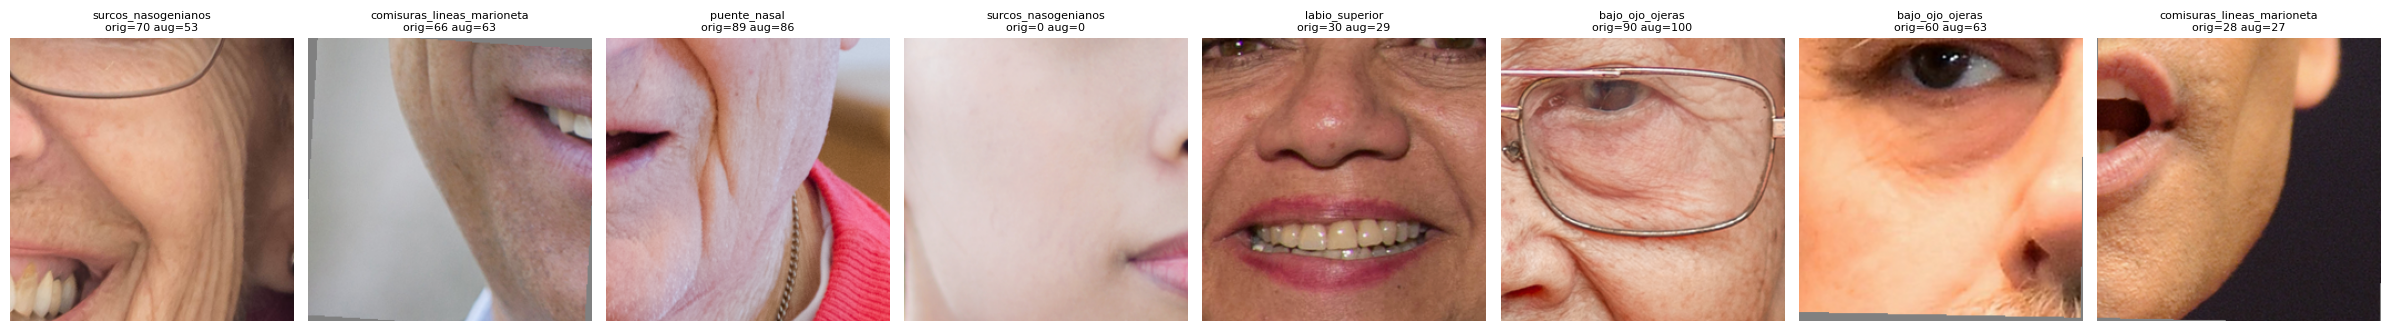


[Prompts]
0: a tightly cropped, centered close-up of the nasolabial fold region, showing facial skin texture and local aging details, with an aging score of 53%, for a white person
1: a tightly cropped, centered close-up of the mouth corner and marionette line region, showing facial skin texture and local aging details, with an aging score of 63%, for a white European person
2: a tightly cropped, centered close-up of the nasal bridge and inter-ocular region, showing facial skin texture and local aging details, with an aging score of 86%, for a white American person
3: a tightly cropped, centered close-up of the nasolabial fold region, showing facial skin texture and local aging details, with an aging score of 0%, for an Asian person
4: a tightly cropped, centered close-up of the upper lip region, showing facial skin texture and local aging details, with an aging score of 29%, for a white person
5: a tightly cropped, centered close-up of the under-eye region, showing facial skin textur

In [ ]:
# ============================================================
# Visualization
# ============================================================

def denorm_for_plot(x: torch.Tensor) -> torch.Tensor:
    """
    Converts image tensor from [-1, 1] to [0, 1].
    """
    return (x * 0.5 + 0.5).clamp(0, 1)


def show_local_batch(batch: Dict[str, Any], n: int = 8, print_prompts: bool = True):
    n = min(n, batch["pixel_values"].shape[0])

    fig, axes = plt.subplots(1, n, figsize=(3.0 * n, 3.4))
    if n == 1:
        axes = [axes]

    for i in range(n):
        img = denorm_for_plot(batch["pixel_values"][i]).permute(1, 2, 0).cpu().numpy()
        region = batch["region_key"][i]
        score_o = batch["score_original"][i].item()
        score_a = batch["score_raw"][i].item()

        axes[i].imshow(img)
        axes[i].axis("off")
        axes[i].set_title(
            f"{region}\norig={score_o:.0f} aug={score_a:.0f}",
            fontsize=8,
        )

    plt.tight_layout()
    plt.show()

    if print_prompts:
        print("\n[Prompts]")
        for i in range(n):
            print(f"{i}: {batch['prompt'][i]}")


show_local_batch(batch, n=8, print_prompts=True)


# ============================================================
# Visual audit by specific region
# ============================================================

def make_region_loader(
    samples: List[Dict[str, Any]],
    region_key: str,
    batch_size: int = 8,
    train: bool = False,
    virtual_repeats: int = 1):
    region_samples = [s for s in samples if s["region_key"] == region_key]

    if len(region_samples) == 0:
        raise ValueError(f"No samples for region_key={region_key}")

    dataset = LocalAgingCropDataset(
        samples=region_samples,
        resolution=LOCAL_RESOLUTION,
        context_scale=1.20,
        virtual_repeats=virtual_repeats,
        train=train,
        jitter_scores_enabled=train,
        enable_horizontal_flip=False,
        normalize_for_diffusion=True,
        drop_regions=None)

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=train,
        num_workers=2,
        collate_fn=local_collate_fn,
        pin_memory=True,
        drop_last=False)

    return loader


def audit_all_regions(samples: List[Dict[str, Any]], n: int = 8):
    for region_key in REGION_ORDER:
        region_samples = [s for s in samples if s["region_key"] == region_key]
        if len(region_samples) == 0:
            print(f"[SKIP] {region_key}: no samples")
            continue

        print(f"\n========== REGION: {region_key} | samples={len(region_samples)} ==========")
        loader = make_region_loader(
            samples=samples,
            region_key=region_key,
            batch_size=n,
            train=False,
            virtual_repeats=1)

        region_batch = next(iter(loader))
        show_local_batch(region_batch, n=n, print_prompts=True)

# ============================================================
#  Dataset audit summary
# ============================================================

def dataset_audit(samples: List[Dict[str, Any]]):
    print("\n========== DATASET AUDIT ==========")

    print("\n[Samples]")
    print("Total crop samples:", len(samples))
    print("Unique images:", len(set(s["image_id"] for s in samples)))

    # ============================================================
    # Counts by region
    # ============================================================

    print("\n[Counts by region]")
    region_counts = Counter(s["region_key"] for s in samples)
    for region_key in REGION_ORDER:
        print(f"{region_key:32s}: {region_counts.get(region_key, 0)}")

    # ============================================================
    # Global score distribution
    # ============================================================

    all_scores = torch.tensor(
        [float(s["score_raw"]) for s in samples],
        dtype=torch.float32,
    )

    print("\n[Global score stats]")
    print(f"n:      {len(all_scores)}")
    print(f"min:    {all_scores.min().item():6.2f}")
    print(f"mean:   {all_scores.mean().item():6.2f}")
    print(f"median: {all_scores.median().item():6.2f}")
    print(f"max:    {all_scores.max().item():6.2f}")
    print(f"std:    {all_scores.std(unbiased=False).item():6.2f}")

    quantiles = torch.quantile(
        all_scores,
        torch.tensor([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]),
    )

    print("\n[Global score percentiles]")
    for q, v in zip([1, 5, 10, 25, 50, 75, 90, 95, 99], quantiles):
        print(f"p{q:02d}: {v.item():6.2f}")

    # ============================================================
    # Score bins
    # ============================================================

    bins = [
        (0, 10),
        (10, 25),
        (25, 40),
        (40, 60),
        (60, 75),
        (75, 90),
        (90, 101),
    ]

    print("\n[Global score bins]")
    total = len(all_scores)

    global_bin_counts = {}

    for low, high in bins:
        if high == 101:
            mask = (all_scores >= low) & (all_scores <= 100)
            label = f"{low:02d}-100"
        else:
            mask = (all_scores >= low) & (all_scores < high)
            label = f"{low:02d}-{high:02d}"

        count = int(mask.sum().item())
        pct = 100.0 * count / max(total, 1)
        global_bin_counts[label] = count

        bar = "█" * int(round(pct / 2.0))
        print(f"{label:8s}: {count:4d} | {pct:6.2f}% | {bar}")

    # ============================================================
    # Important aging ranges
    # ============================================================

    print("\n[Important score ranges]")
    ranges = {
        "very_low     score <= 10": all_scores <= 10,
        "low          score <  25": all_scores < 25,
        "middle       40 <= score < 60": (all_scores >= 40) & (all_scores < 60),
        "high         score >= 75": all_scores >= 75,
        "very_high    score >= 90": all_scores >= 90,
        "exact_zero   score == 0": all_scores == 0,
        "exact_100    score == 100": all_scores == 100,
    }

    for name, mask in ranges.items():
        count = int(mask.sum().item())
        pct = 100.0 * count / max(total, 1)
        print(f"{name:30s}: {count:4d} | {pct:6.2f}%")

    # ============================================================
    # Score stats by region
    # ============================================================

    print("\n[Score stats by region]")
    by_region = defaultdict(list)

    for s in samples:
        by_region[s["region_key"]].append(float(s["score_raw"]))

    for region_key in REGION_ORDER:
        values = by_region.get(region_key, [])
        if not values:
            continue

        values_t = torch.tensor(values, dtype=torch.float32)

        q25 = torch.quantile(values_t, 0.25).item()
        q50 = torch.quantile(values_t, 0.50).item()
        q75 = torch.quantile(values_t, 0.75).item()

        print(
            f"{region_key:32s} "
            f"n={len(values):3d} "
            f"min={values_t.min().item():5.1f} "
            f"mean={values_t.mean().item():5.1f} "
            f"p25={q25:5.1f} "
            f"p50={q50:5.1f} "
            f"p75={q75:5.1f} "
            f"max={values_t.max().item():5.1f}"
        )

    # ============================================================
    # Score bins by region
    # ============================================================

    print("\n[Score bins by region]")
    bin_labels = []
    for low, high in bins:
        if high == 101:
            bin_labels.append(f"{low:02d}-100")
        else:
            bin_labels.append(f"{low:02d}-{high:02d}")

    header = f"{'region':32s} " + " ".join([f"{b:>8s}" for b in bin_labels])
    print(header)
    print("-" * len(header))

    for region_key in REGION_ORDER:
        values = by_region.get(region_key, [])
        if not values:
            continue

        values_t = torch.tensor(values, dtype=torch.float32)

        row_counts = []

        for low, high in bins:
            if high == 101:
                mask = (values_t >= low) & (values_t <= 100)
            else:
                mask = (values_t >= low) & (values_t < high)

            row_counts.append(int(mask.sum().item()))

        row = f"{region_key:32s} " + " ".join([f"{c:8d}" for c in row_counts])
        print(row)

    # ============================================================
    # High-score concentration by region
    # ============================================================

    print("\n[High-score concentration by region]")
    print(f"{'region':32s} {'n':>5s} {'>=75':>6s} {'>=90':>6s} {'>=75 %':>8s} {'>=90 %':>8s}")
    print("-" * 72)

    for region_key in REGION_ORDER:
        values = by_region.get(region_key, [])
        if not values:
            continue

        values_t = torch.tensor(values, dtype=torch.float32)
        n = len(values_t)

        n75 = int((values_t >= 75).sum().item())
        n90 = int((values_t >= 90).sum().item())

        p75 = 100.0 * n75 / max(n, 1)
        p90 = 100.0 * n90 / max(n, 1)

        print(f"{region_key:32s} {n:5d} {n75:6d} {n90:6d} {p75:8.2f} {p90:8.2f}")

    # ============================================================
    # Demographic contexts
    # ============================================================

    print("\n[Demographic contexts]")
    demo_counts = Counter(s["demographic_context"] for s in samples)

    for k, v in demo_counts.most_common():
        print(f"{k:30s}: {v}")


dataset_audit(local_samples)

# See artifical images created

In [ ]:

from collections import Counter

def count_dataset_sizes(local_samples, train_samples=None, val_samples=None, train_dataset=None, val_dataset=None):
    print("========== SIZE AUDIT ==========")

    # Real full images
    unique_images_all = sorted(set(s["image_id"] for s in local_samples))
    print(f"Real unique images total: {len(unique_images_all)}")

    # Real annotated crops
    print(f"Real annotated local crops total: {len(local_samples)}")

    # Counts by region before virtual augmentation
    print("\nReal crops by region:")
    region_counts = Counter(s["region_key"] for s in local_samples)
    for k, v in region_counts.items():
        print(f"  {k:32s}: {v}")

    if train_samples is not None:
        train_images = sorted(set(s["image_id"] for s in train_samples))
        print("\nTrain split:")
        print(f"  Real unique images: {len(train_images)}")
        print(f"  Real crops:         {len(train_samples)}")

    if val_samples is not None:
        val_images = sorted(set(s["image_id"] for s in val_samples))
        print("\nValidation split:")
        print(f"  Real unique images: {len(val_images)}")
        print(f"  Real crops:         {len(val_samples)}")

    if train_dataset is not None:
        print("\nVirtual train dataset:")
        print(f"  virtual_repeats:    {train_dataset.virtual_repeats}")
        print(f"  Virtual crops/epoch:{len(train_dataset)}")

    if val_dataset is not None:
        print("\nVirtual validation dataset:")
        print(f"  virtual_repeats:    {val_dataset.virtual_repeats}")
        print(f"  Virtual crops/epoch:{len(val_dataset)}")

    print("\nImportant:")
    print("  No augmented images were saved to disk.")
    print("  Augmentations are generated online every time __getitem__ is called.")


count_dataset_sizes(
    local_samples=local_samples,
    train_samples=train_samples,
    val_samples=val_samples,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
)

========== SIZE AUDIT ==========
Real unique images total: 56
Real annotated local crops total: 591

Real crops by region:
  frente                          : 51
  glabela_entrecejo               : 55
  patas_de_gallo                  : 70
  bajo_ojo_ojeras                 : 108
  surcos_nasogenianos             : 109
  comisuras_lineas_marioneta      : 100
  puente_nasal                    : 52
  labio_superior                  : 46

Train split:
  Real unique images: 48
  Real crops:         503

Validation split:
  Real unique images: 8
  Real crops:         88

Virtual train dataset:
  virtual_repeats:    10
  Virtual crops/epoch:5030

Virtual validation dataset:
  virtual_repeats:    1
  Virtual crops/epoch:88

Important:
  No augmented images were saved to disk.
  Augmentations are generated online every time __getitem__ is called.


In [ ]:
real_train_crops = len(train_samples)
virtual_train_crops = len(train_dataset)
artificial_train_views = virtual_train_crops - real_train_crops

print("Real train crops:", real_train_crops)
print("Virtual train crops per epoch:", virtual_train_crops)
print("Artificial augmented views per epoch:", artificial_train_views)

Real train crops: 503
Virtual train crops per epoch: 5030
Artificial augmented views per epoch: 4527


## Ver que trae el data_laoder_local

In [ ]:
batch = next(iter(train_loader))

print(batch.keys())

for k, v in batch.items():
    if torch.is_tensor(v):
        print(k, v.shape, v.dtype)
    elif isinstance(v, list):
        print(k, type(v), len(v), "example:", v[0])
    else:
        print(k, type(v))

dict_keys(['pixel_values', 'score', 'score_raw', 'score_original', 'prompt', 'zone_prompt', 'region_key', 'region_name', 'region_alias', 'image_id', 'image_stem', 'box_index', 'demographic_context', 'bbox_original', 'bbox_crop', 'json_path'])
pixel_values torch.Size([8, 3, 256, 256]) torch.float32
score torch.Size([8]) torch.float32
score_raw torch.Size([8]) torch.float32
score_original torch.Size([8]) torch.float32
prompt <class 'list'> 8 example: a tightly cropped, centered close-up of the nasolabial fold region, showing facial skin texture and local aging details, with an aging score of 50%, for a white person
zone_prompt <class 'list'> 8 example: a tightly cropped, centered close-up of the nasolabial fold region, showing facial skin texture
region_key <class 'list'> 8 example: surcos_nasogenianos
region_name <class 'list'> 8 example: Surcos Nasogenianos
region_alias <class 'list'> 8 example: Surcos nasogenianos
image_id <class 'list'> 8 example: 00632.png
image_stem <class 'list'> 

---

# Crear Data Loaders Stage 1 (Global)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# DataLoaders

In [ ]:
# ============================================================
# GLOBAL FACE AGING DATASET + DATALOADER
# Final portable version
#
# Requirements:
#   1. Drive mounted
#   2. /content/ffhq_face_attribute_prompts.csv exists
#   3. The four zip files exist in /content/drive/MyDrive/
# ============================================================

import random
import shutil
import zipfile
from pathlib import Path
from typing import Dict, Any, List, Optional
from collections import Counter

import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt


# ============================================================
# Paths
# ============================================================

DRIVE_ZIPS = [
    Path("/content/drive/MyDrive/ffhq_subset_6k_extremes-001.zip"),
    Path("/content/drive/MyDrive/ffhq_subset_6k_extremes-002.zip"),
    Path("/content/drive/MyDrive/ffhq_subset_6k_extremes-003.zip"),
    Path("/content/drive/MyDrive/ffhq_subset_6k_extremes-004.zip"),
]

GLOBAL_IMAGE_DIR = Path("/content/ffhq_subset_6k_extremes_local")
GLOBAL_CSV_PATH = Path("/content/ffhq_face_attribute_prompts.csv")

GLOBAL_RESOLUTION = 512
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".webp", ".bmp", ".tif", ".tiff"}


# ============================================================
# Reproducibility
# ============================================================

def seed_everything(seed: int = 42):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)


# ============================================================
# Extract images from Drive ZIPs if needed
# ============================================================

def ensure_images_available(
    zip_paths: List[Path],
    output_dir: Path,
    force_reextract: bool = False,
) -> Path:
    """
    Ensures images are available locally.

    If output_dir already exists and contains images, it does nothing.
    Otherwise, it extracts all ZIP files into output_dir.
    """
    if output_dir.exists() and not force_reextract:
        existing_images = [
            p for p in output_dir.rglob("*")
            if p.is_file()
            and p.suffix.lower() in IMAGE_EXTS
            and not p.name.startswith("._")
            and "__MACOSX" not in str(p)
        ]

        if len(existing_images) > 0:
            print("[Images already available]")
            print("Local image dir:", output_dir)
            print("Local images:", len(existing_images))
            return output_dir

    missing_zips = [str(p) for p in zip_paths if not p.exists()]
    if len(missing_zips) > 0:
        raise FileNotFoundError(
            "Missing ZIP files. Make sure Drive is mounted and paths are correct:\n"
            + "\n".join(missing_zips)
        )

    if output_dir.exists():
        shutil.rmtree(output_dir)

    output_dir.mkdir(parents=True, exist_ok=True)

    print("[Extracting ZIP files]")
    for zip_path in zip_paths:
        print("Extracting:", zip_path.name)

        with zipfile.ZipFile(zip_path, "r") as z:
            bad_file = z.testzip()
            if bad_file is not None:
                raise RuntimeError(f"Corrupted file inside {zip_path}: {bad_file}")

            z.extractall(output_dir)

    all_files = [
        p for p in output_dir.rglob("*")
        if p.is_file()
        and not p.name.startswith("._")
        and "__MACOSX" not in str(p)
    ]

    image_files = [
        p for p in all_files
        if p.suffix.lower() in IMAGE_EXTS
    ]

    print("\n[Extraction summary]")
    print("Extracted to:", output_dir)
    print("Total files:", len(all_files))
    print("Total images:", len(image_files))

    ext_counts = Counter(p.suffix.lower() for p in all_files)
    print("\n[Extension counts]")
    for ext, count in ext_counts.most_common(15):
        print(f"{ext if ext else '[no extension]'}: {count}")

    if len(image_files) == 0:
        raise FileNotFoundError(f"No images found after extraction in: {output_dir}")

    return output_dir


GLOBAL_IMAGE_DIR = ensure_images_available(
    zip_paths=DRIVE_ZIPS,
    output_dir=GLOBAL_IMAGE_DIR,
    force_reextract=False,
)


# ============================================================
# Basic helpers
# ============================================================

def valid_text(x: Any) -> bool:
    return (
        isinstance(x, str)
        and len(x.strip()) > 0
        and x.strip().lower() not in ["nan", "none", "null"]
    )


def safe_float(x: Any, default: Optional[float] = None) -> Optional[float]:
    try:
        if pd.isna(x):
            return default
        return float(x)
    except Exception:
        return default


def clean_gender_label(x: Any) -> Optional[str]:
    if x is None or pd.isna(x):
        return None

    label = str(x).strip().lower()

    if label in ["male", "man", "masculino", "m", "0", "label_0"]:
        return "male"

    if label in ["female", "woman", "femenino", "f", "1", "label_1"]:
        return "female"

    if "female" in label or "woman" in label:
        return "female"

    if "male" in label or "man" in label:
        return "male"

    return None


# ============================================================
# Image index
# ============================================================

def build_image_index(image_root: Path) -> Dict[str, Path]:
    """
    Builds an index:
        filename -> path
        stem     -> path
    """
    if not image_root.exists():
        raise FileNotFoundError(f"Image directory not found: {image_root}")

    image_paths = [
        p for p in image_root.rglob("*")
        if p.is_file()
        and p.suffix.lower() in IMAGE_EXTS
        and not p.name.startswith("._")
        and "__MACOSX" not in str(p)
    ]

    if len(image_paths) == 0:
        raise FileNotFoundError(f"No images found in: {image_root}")

    index = {}
    duplicate_keys = []

    for path in image_paths:
        for key in [path.name, path.stem]:
            if key in index:
                duplicate_keys.append(key)
            index[key] = path

    print("\n[Image index]")
    print("Found image files:", len(image_paths))
    print("Index keys:", len(index))
    print("Duplicate keys overwritten:", len(duplicate_keys))

    if len(duplicate_keys) > 0:
        print("First duplicate keys:", duplicate_keys[:10])

    return index


global_image_index = build_image_index(GLOBAL_IMAGE_DIR)


# ============================================================
# Prompt builder
# ============================================================

def make_global_prompt_from_attributes(
    age: float,
    gender_label: Any = None,
    gender_confidence: Any = None,
    skin_tone_label: Any = None,
    skin_tone_confidence: Any = None,
    hair_label: Any = None,
    hair_confidence: Any = None,
    glasses_label: Any = None,
    glasses_confidence: Any = None,
    gender_threshold: float = 0.65,
    skin_threshold: float = 0.40,
    hair_threshold: float = 0.35,
    glasses_threshold: float = 0.55,
) -> str:
    """
    Builds final global prompt.

    Gender is included only if gender_confidence >= 0.65.
    Other visual attributes are included only if confidence is high enough.
    """
    age_int = int(round(float(age)))
    age_int = max(0, min(100, age_int))

    gender_confidence = safe_float(gender_confidence, default=None)
    gender_label = clean_gender_label(gender_label)

    if (
        gender_label == "male"
        and gender_confidence is not None
        and gender_confidence >= gender_threshold
    ):
        person_phrase = f"a {age_int}-year-old man"

    elif (
        gender_label == "female"
        and gender_confidence is not None
        and gender_confidence >= gender_threshold
    ):
        person_phrase = f"a {age_int}-year-old woman"

    else:
        person_phrase = f"a {age_int}-year-old person"

    attr_parts = []

    skin_confidence = safe_float(skin_tone_confidence, default=None)
    if (
        valid_text(skin_tone_label)
        and skin_confidence is not None
        and skin_confidence >= skin_threshold
    ):
        attr_parts.append(str(skin_tone_label).strip())

    hair_confidence = safe_float(hair_confidence, default=None)
    if (
        valid_text(hair_label)
        and hair_confidence is not None
        and hair_confidence >= hair_threshold
    ):
        attr_parts.append(str(hair_label).strip())

    glasses_confidence = safe_float(glasses_confidence, default=None)
    if (
        valid_text(glasses_label)
        and glasses_confidence is not None
        and glasses_confidence >= glasses_threshold
        and str(glasses_label).strip().lower() == "wearing glasses"
    ):
        attr_parts.append("wearing glasses")

    if len(attr_parts) > 0:
        return "a portrait photo of " + person_phrase + ", " + ", ".join(attr_parts)

    return "a portrait photo of " + person_phrase


# ============================================================
# Build samples from final CSV
# ============================================================

def build_global_samples_from_attribute_csv(
    csv_path: Path,
    image_index: Dict[str, Path],
    filename_col: str = "filename",
    age_col: str = "age_pred",
    min_age: Optional[float] = None,
    max_age: Optional[float] = None,
    require_existing_image: bool = True,
) -> List[Dict[str, Any]]:

    if not csv_path.exists():
        raise FileNotFoundError(f"CSV not found: {csv_path}")

    df = pd.read_csv(csv_path).copy()

    required_cols = [
        filename_col,
        age_col,
        "gender_label",
        "gender_confidence",
        "skin_tone_label",
        "skin_tone_confidence",
        "hair_label",
        "hair_confidence",
        "glasses_label",
        "glasses_confidence",
    ]

    for col in required_cols:
        if col not in df.columns:
            raise ValueError(
                f"Required column '{col}' not found. "
                f"Available columns: {list(df.columns)}"
            )

    df[age_col] = pd.to_numeric(df[age_col], errors="coerce")
    df = df.dropna(subset=[filename_col, age_col]).reset_index(drop=True)

    if min_age is not None:
        df = df[df[age_col] >= min_age]

    if max_age is not None:
        df = df[df[age_col] <= max_age]

    samples = []
    missing_images = []

    for _, row in df.iterrows():
        filename = str(row[filename_col])
        filename_name = Path(filename).name
        stem = Path(filename).stem
        age = float(row[age_col])

        image_path = image_index.get(filename, None)
        if image_path is None:
            image_path = image_index.get(filename_name, None)
        if image_path is None:
            image_path = image_index.get(stem, None)

        if image_path is None:
            missing_images.append(filename)

            if require_existing_image:
                continue
            else:
                raise FileNotFoundError(f"Image not found for filename={filename}")

        prompt = make_global_prompt_from_attributes(
            age=age,
            gender_label=row.get("gender_label", None),
            gender_confidence=row.get("gender_confidence", None),
            skin_tone_label=row.get("skin_tone_label", None),
            skin_tone_confidence=row.get("skin_tone_confidence", None),
            hair_label=row.get("hair_label", None),
            hair_confidence=row.get("hair_confidence", None),
            glasses_label=row.get("glasses_label", None),
            glasses_confidence=row.get("glasses_confidence", None),
            gender_threshold=0.65,
            skin_threshold=0.40,
            hair_threshold=0.35,
            glasses_threshold=0.55,
        )

        sample = {
            "filename": filename,
            "stem": stem,
            "image_path": str(image_path),
            "age": age,
            "age_rounded": int(round(age)),
            "age_norm": age / 100.0,
            "prompt": prompt,

            # Metadata for debugging
            "gender_pred": row.get("gender_pred", None),
            "gender_label": row.get("gender_label", None),
            "gender_confidence": row.get("gender_confidence", None),
            "skin_tone_label": row.get("skin_tone_label", None),
            "skin_tone_confidence": row.get("skin_tone_confidence", None),
            "hair_label": row.get("hair_label", None),
            "hair_confidence": row.get("hair_confidence", None),
            "glasses_label": row.get("glasses_label", None),
            "glasses_confidence": row.get("glasses_confidence", None),
            "face_attribute_phrase": row.get("face_attribute_phrase", None),
            "enriched_prompt_original": row.get("enriched_prompt", None),
            "error": row.get("error", None),
        }

        samples.append(sample)

    print("\n[Dataset build summary]")
    print("CSV rows after filtering:", len(df))
    print("Matched global samples:", len(samples))
    print("Missing images:", len(missing_images))

    if len(missing_images) > 0:
        print("First missing images:", missing_images[:20])

    print("\n[Prompt check: first 10]")
    for s in samples[:10]:
        print(
            f"{s['filename']} | "
            f"gender={s['gender_label']} | "
            f"conf={s['gender_confidence']} | "
            f"{s['prompt']}"
        )

    if len(samples) == 0:
        raise ValueError("No valid global samples were created.")

    return samples


global_samples = build_global_samples_from_attribute_csv(
    csv_path=GLOBAL_CSV_PATH,
    image_index=global_image_index,
    filename_col="filename",
    age_col="age_pred",
    min_age=None,
    max_age=None,
    require_existing_image=True,
)


# ============================================================
# Dataset
# ============================================================

class GlobalAgingFaceDataset(Dataset):
    """
    Dataset for global face aging branch.

    One item = one full-face image.

    Returned:
        pixel_values: [3, resolution, resolution], normalized to [-1, 1]
        age: apparent age, float
        age_norm: apparent age / 100
        prompt: final controlled prompt
        filename: image filename
    """

    def __init__(
        self,
        samples: List[Dict[str, Any]],
        resolution: int = 512,
        train: bool = True,
        normalize_for_diffusion: bool = True,
    ):
        self.samples = samples
        self.resolution = int(resolution)
        self.train = bool(train)
        self.normalize_for_diffusion = bool(normalize_for_diffusion)

        if len(self.samples) == 0:
            raise ValueError("Global dataset has zero samples.")

        if train:
            transform_list = [
                transforms.Resize(
                    (self.resolution, self.resolution),
                    interpolation=transforms.InterpolationMode.BICUBIC,
                ),
                transforms.RandomApply(
                    [
                        transforms.ColorJitter(
                            brightness=0.035,
                            contrast=0.035,
                            saturation=0.025,
                            hue=0.004,
                        )
                    ],
                    p=0.25,
                ),
                transforms.ToTensor(),
            ]
        else:
            transform_list = [
                transforms.Resize(
                    (self.resolution, self.resolution),
                    interpolation=transforms.InterpolationMode.BICUBIC,
                ),
                transforms.ToTensor(),
            ]

        if self.normalize_for_diffusion:
            transform_list.append(
                transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
            )

        self.transform = transforms.Compose(transform_list)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx: int) -> Dict[str, Any]:
        sample = self.samples[idx]

        image = Image.open(sample["image_path"]).convert("RGB")
        pixel_values = self.transform(image)

        age = float(sample["age"])
        prompt = sample["prompt"]

        return {
            "pixel_values": pixel_values,
            "age": torch.tensor(age, dtype=torch.float32),
            "age_norm": torch.tensor(age / 100.0, dtype=torch.float32),
            "prompt": prompt,
            "filename": sample["filename"],
            "stem": sample["stem"],
            "image_path": sample["image_path"],
            "gender_label": sample.get("gender_label", None),
            "gender_confidence": sample.get("gender_confidence", None),
        }


# ============================================================
# Collate functions
# ============================================================

def global_train_collate_fn(batch: List[Dict[str, Any]]) -> Dict[str, Any]:
    return {
        "pixel_values": torch.stack([b["pixel_values"] for b in batch], dim=0),
        "age": torch.stack([b["age"] for b in batch], dim=0),
        "age_norm": torch.stack([b["age_norm"] for b in batch], dim=0),
        "prompt": [b["prompt"] for b in batch]}


def global_debug_collate_fn(batch: List[Dict[str, Any]]) -> Dict[str, Any]:
    return {
        "pixel_values": torch.stack([b["pixel_values"] for b in batch], dim=0),
        "age": torch.stack([b["age"] for b in batch], dim=0),
        "age_norm": torch.stack([b["age_norm"] for b in batch], dim=0),
        "prompt": [b["prompt"] for b in batch],
        "filename": [b["filename"] for b in batch],
        "stem": [b["stem"] for b in batch],
        "image_path": [b["image_path"] for b in batch],
        "gender_label": [b["gender_label"] for b in batch],
        "gender_confidence": [b["gender_confidence"] for b in batch]}


[Images already available]
Local image dir: /content/ffhq_subset_6k_extremes_local
Local images: 5542

[Image index]
Found image files: 5542
Index keys: 11084
Duplicate keys overwritten: 0

[Dataset build summary]
CSV rows after filtering: 5542
Matched global samples: 5542
Missing images: 0

[Prompt check: first 10]
00032.png | gender=male | conf=0.5404380559921265 | a portrait photo of a 47-year-old person, medium skin tone, blonde hair
00044.png | gender=male | conf=0.5135192275047302 | a portrait photo of a 52-year-old person, medium skin tone, blonde hair
00055.png | gender=male | conf=0.5169636607170105 | a portrait photo of a 19-year-old person, medium skin tone, brown hair
00075.png | gender=male | conf=0.7086560130119324 | a portrait photo of a 46-year-old man, medium skin tone, black hair
00084.png | gender=female | conf=0.5428204536437988 | a portrait photo of a 70-year-old person, medium skin tone, blonde hair, wearing glasses
00088.png | gender=female | conf=0.5988095402717

In [ ]:
# ============================================================
# Create datasets and loaders
# ============================================================

global_train_dataset = GlobalAgingFaceDataset(
    samples=global_samples,
    resolution=GLOBAL_RESOLUTION,
    train=True,
    normalize_for_diffusion=True,
)

global_debug_dataset = GlobalAgingFaceDataset(
    samples=global_samples,
    resolution=GLOBAL_RESOLUTION,
    train=False,
    normalize_for_diffusion=True,
)

global_train_loader = DataLoader(
    global_train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2,
    collate_fn=global_train_collate_fn,
    pin_memory=True,
)

global_val_loader = DataLoader(
    global_debug_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    collate_fn=global_debug_collate_fn,
    pin_memory=True)


# ============================================================
# Sanity check
# ============================================================

debug_batch = next(iter(global_val_loader))

print("\n[Batch check]")
print("pixel_values:", debug_batch["pixel_values"].shape)
print("age:", debug_batch["age"].shape)
print("age_norm:", debug_batch["age_norm"].shape)
print("prompt example:", debug_batch["prompt"][0])
print("gender label example:", debug_batch["gender_label"][0])
print("gender confidence example:", debug_batch["gender_confidence"][0])
print("filename example:", debug_batch["filename"][0])

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



[Batch check]
pixel_values: torch.Size([4, 3, 512, 512])
age: torch.Size([4])
age_norm: torch.Size([4])
prompt example: a portrait photo of a 47-year-old person, medium skin tone, blonde hair
gender label example: male
gender confidence example: 0.5404380559921265
filename example: 00032.png


## See data global

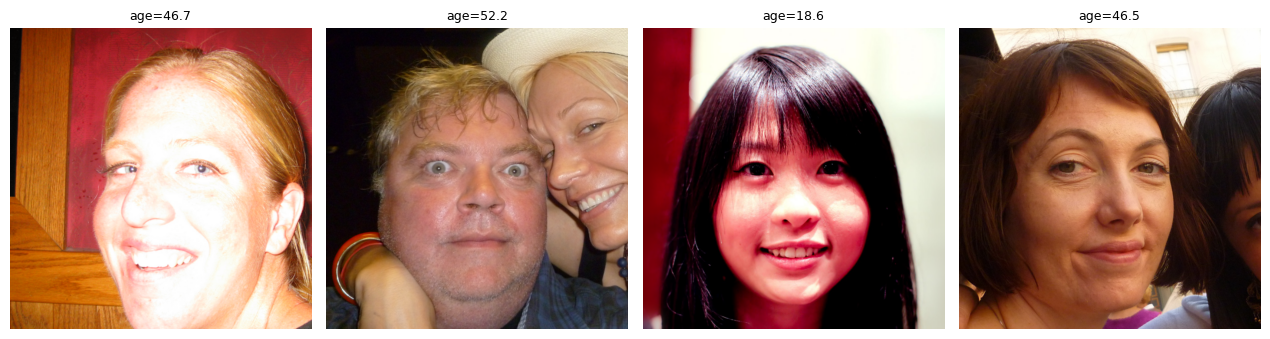


[Prompts]
0: a portrait photo of a 47-year-old person, medium skin tone, blonde hair
1: a portrait photo of a 52-year-old person, medium skin tone, blonde hair
2: a portrait photo of a 19-year-old person, medium skin tone, brown hair
3: a portrait photo of a 46-year-old man, medium skin tone, black hair


In [ ]:
# ============================================================
# Visualization
# ============================================================

def denorm_for_plot(x: torch.Tensor) -> torch.Tensor:
    return (x * 0.5 + 0.5).clamp(0, 1)


def show_global_batch(batch: Dict[str, Any], n: int = 4):
    n = min(n, batch["pixel_values"].shape[0])

    fig, axes = plt.subplots(1, n, figsize=(3.2 * n, 3.5))
    if n == 1:
        axes = [axes]

    for i in range(n):
        img = denorm_for_plot(batch["pixel_values"][i]).permute(1, 2, 0).cpu().numpy()
        age = batch["age"][i].item()
        prompt = batch["prompt"][i]

        axes[i].imshow(img)
        axes[i].axis("off")
        axes[i].set_title(f"age={age:.1f}", fontsize=9)

    plt.tight_layout()
    plt.show()

    print("\n[Prompts]")
    for i in range(n):
        print(f"{i}: {batch['prompt'][i]}")


debug_batch = next(iter(global_val_loader))
show_global_batch(debug_batch, n=4)

# Model Full Pipeline

## CLIP MODEL

In [ ]:
import torch
from typing import List, Dict, Any, Union
from transformers import CLIPTokenizer, CLIPTextModel

CLIP_MODEL_ID = "openai/clip-vit-large-patch14"

device = "cuda" if torch.cuda.is_available() else "cpu"

# Para embeddings, fp16 en GPU es suficiente y ahorra memoria.
clip_dtype = torch.float16 if device == "cuda" else torch.float32

clip_tokenizer = CLIPTokenizer.from_pretrained(CLIP_MODEL_ID)

clip_text_encoder = CLIPTextModel.from_pretrained(
    CLIP_MODEL_ID,
    torch_dtype=clip_dtype,)

clip_text_encoder = clip_text_encoder.to(device)
clip_text_encoder.eval()

# Freeze completely.
for p in clip_text_encoder.parameters():
    p.requires_grad_(False)

print("[OK] Loaded frozen CLIP text encoder")
print("Model:", CLIP_MODEL_ID)
print("Device:", device)
print("Dtype:", clip_dtype)
print("Hidden size:", clip_text_encoder.config.hidden_size)
print("Max position embeddings:", clip_text_encoder.config.max_position_embeddings)
print("Vocab size:", clip_text_encoder.config.vocab_size)

In [ ]:
@torch.no_grad()
def encode_prompts_with_clip(
    prompts: Union[str, List[str]],
    tokenizer=clip_tokenizer,
    text_encoder=clip_text_encoder,
    device: str = device,
    dtype: torch.dtype = clip_dtype,
    max_length: int = 77,
    normalize_pooled: bool = False) -> Dict[str, torch.Tensor]:
    """
    Encodes one prompt or a list of prompts using frozen CLIP.

    Returns:
        input_ids:
            [B, 77]
        attention_mask:
            [B, 77]
        last_hidden_state:
            [B, 77, hidden_dim]
            This is the sequence embedding used by Stable Diffusion cross-attention.
        pooled_output:
            [B, hidden_dim]
            This is the global text embedding from CLIP.
        pooled_output_norm:
            [B, hidden_dim]
            Optional normalized pooled embedding.

    For Stable Diffusion-style UNet conditioning, the most important output is:
        last_hidden_state
    """

    if isinstance(prompts, str):
        prompts = [prompts]

    tokenized = tokenizer(
        prompts,
        padding="max_length",
        truncation=True,
        max_length=max_length,
        return_tensors="pt")

    input_ids = tokenized.input_ids.to(device)
    attention_mask = tokenized.attention_mask.to(device)

    outputs = text_encoder(
        input_ids=input_ids,
        attention_mask=attention_mask,
        output_hidden_states=False,
        return_dict=True)

    last_hidden_state = outputs.last_hidden_state
    pooled_output = outputs.pooler_output

    if dtype is not None:
        last_hidden_state = last_hidden_state.to(dtype)
        pooled_output = pooled_output.to(dtype)

    if normalize_pooled:
        pooled_output_norm = torch.nn.functional.normalize(
            pooled_output.float(),
            dim=-1,
        ).to(dtype)
    else:
        pooled_output_norm = pooled_output

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "last_hidden_state": last_hidden_state,
        "pooled_output": pooled_output,
        "pooled_output_norm": pooled_output_norm}

In [ ]:
test_prompts = [
    "a portrait of a 65-year-old person",
    "image of forehead wrinkles with an aging score of 80% for a white person",
    "image of under-eye wrinkles with an aging score of 20% for a Asian person",
    "image of nasolabial folds with an aging score of 50% for a white European person",
]

clip_out = encode_prompts_with_clip(test_prompts)

print("========== CLIP OUTPUT SHAPES ==========")
print("input_ids:", clip_out["input_ids"].shape)
print("attention_mask:", clip_out["attention_mask"].shape)
print("last_hidden_state:", clip_out["last_hidden_state"].shape)
print("pooled_output:", clip_out["pooled_output"].shape)

print("\n========== DTYPES ==========")
print("last_hidden_state:", clip_out["last_hidden_state"].dtype)
print("pooled_output:", clip_out["pooled_output"].dtype)

print("\n========== PROMPT EXAMPLE ==========")
idx = 1
print("prompt:", test_prompts[idx])

print("\n========== EMBEDDING EXAMPLE ==========")
print("last_hidden_state for this prompt:", clip_out["last_hidden_state"][idx].shape)
print("pooled_output for this prompt:", clip_out["pooled_output"][idx].shape)

print("\nFirst 10 values of pooled_output:")
print(clip_out["pooled_output"][idx][:10])

print("\nFirst token embedding, first 10 values:")
print(clip_out["last_hidden_state"][idx, 0, :10])

========== CLIP OUTPUT SHAPES ==========
input_ids: torch.Size([4, 77])
attention_mask: torch.Size([4, 77])
last_hidden_state: torch.Size([4, 77, 768])
pooled_output: torch.Size([4, 768])

========== DTYPES ==========
last_hidden_state: torch.float16
pooled_output: torch.float16

========== PROMPT EXAMPLE ==========
prompt: image of forehead wrinkles with an aging score of 80% for a white person

========== EMBEDDING EXAMPLE ==========
last_hidden_state for this prompt: torch.Size([77, 768])
pooled_output for this prompt: torch.Size([768])

First 10 values of pooled_output:
tensor([-1.0391, -0.3569,  0.4331, -1.5186,  1.4248, -0.1250,  0.0566,  0.2947,
         1.2617, -0.1919], device='cuda:0', dtype=torch.float16)

First token embedding, first 10 values:
tensor([-0.3887,  0.0229, -0.0522, -0.1842, -0.0274, -0.3357, -0.0175, -0.1871,
         0.1877, -0.0907], device='cuda:0', dtype=torch.float16)


---

In [ ]:
import gc
import torch

def print_gpu_mem(prefix=""):
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated() / 1024**3
        reserved = torch.cuda.memory_reserved() / 1024**3
        print(f"{prefix}GPU allocated: {allocated:.2f} GB | reserved: {reserved:.2f} GB")
    else:
        print(f"{prefix}CUDA not available.")

def clear_old_models_from_memory():
    names_to_delete = [
        "vae",
        "unet",
        "tokenizer",
        "text_encoder",
        "noise_scheduler",
        "clip_tokenizer",
        "clip_text_encoder",
        "wrapper",
        "global_train_loader",
        "global_val_loader",
        "train_loader",
        "val_loader",
        "local_batch",
        "global_batch",
        "clip_out",
        "x256", "x512", "z256", "z512",
        "x256_hat", "x512_hat",
        "text_inputs", "encoder_hidden_states",
        "latents", "noise", "timesteps", "noisy_latents", "noise_pred"
    ]

    for name in names_to_delete:
        if name in globals():
            del globals()[name]

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

print_gpu_mem(prefix="[Before clear] ")
clear_old_models_from_memory()
print_gpu_mem(prefix="[After clear] ")

[Before clear] CUDA not available.
[After clear] CUDA not available.


In [ ]:
def print_gpu_mem(prefix=""):
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated() / 1024**3
        reserved = torch.cuda.memory_reserved() / 1024**3
        print(f"{prefix}GPU allocated: {allocated:.2f} GB | reserved: {reserved:.2f} GB")
    else:
        print(f"{prefix}CUDA not available.")

print_gpu_mem(prefix="[Initial memory] ")

[Initial memory] CUDA not available.


---

# LoRa

In [ ]:
# ============================================================
# MANUAL LoRA FOR DIFFUSERS UNet
# No PEFT. No torchao. No add_adapter.
# Applies LoRA to attention Linear layers:
#   to_q, to_k, to_v, to_out.0
# ============================================================

import gc
import math
import torch
import torch.nn as nn
from diffusers import UNet2DConditionModel


# ============================================================
# 0. Memory helpers
# ============================================================

def print_gpu_mem(prefix=""):
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated() / 1024**3
        reserved = torch.cuda.memory_reserved() / 1024**3
        max_allocated = torch.cuda.max_memory_allocated() / 1024**3
        print(
            f"{prefix}allocated={allocated:.2f} GB | "
            f"reserved={reserved:.2f} GB | "
            f"max={max_allocated:.2f} GB"
        )
    else:
        print(f"{prefix}CUDA not available.")


def cleanup_cuda():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()


def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen = total - trainable
    return total, trainable, frozen


def print_trainable_report(name, model):
    total, trainable, frozen = count_params(model)
    print(f"\n========== {name} ==========")
    print(f"Total params:     {total:,}")
    print(f"Trainable params: {trainable:,}")
    print(f"Frozen params:    {frozen:,}")
    if total > 0:
        print(f"Trainable %:      {100 * trainable / total:.6f}%")


def list_trainable_names(model, max_items=50):
    names = [n for n, p in model.named_parameters() if p.requires_grad]
    print(f"\nTrainable tensors: {len(names)}")
    for n in names[:max_items]:
        print("  ", n)
    if len(names) > max_items:
        print(f"  ... {len(names) - max_items} more")


print_gpu_mem("[Before clean reload] ")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


[Before clean reload] CUDA not available.


In [ ]:
# ============================================================
# Manual LoRA Linear wrapper
# ============================================================

class LoRALinear(nn.Module):
    """
    Manual LoRA wrapper around nn.Linear.

    Original:
        y = W x + b

    LoRA:
        y = W x + b + scale * B(A(dropout(x)))

    Where:
        A: in_features  -> r
        B: r            -> out_features

    Base layer is frozen.
    Only A and B are trainable.
    """

    def __init__(
        self,
        base_layer: nn.Linear,
        rank: int = 8,
        alpha: int = 8,
        dropout: float = 0.0,
    ):
        super().__init__()

        if not isinstance(base_layer, nn.Linear):
            raise TypeError(f"LoRALinear expects nn.Linear, got {type(base_layer)}")

        self.base_layer = base_layer
        self.rank = int(rank)
        self.alpha = float(alpha)
        self.scale = self.alpha / self.rank

        in_features = base_layer.in_features
        out_features = base_layer.out_features

        # Freeze base layer
        for p in self.base_layer.parameters():
            p.requires_grad_(False)

        self.dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

        self.lora_down = nn.Linear(in_features, self.rank, bias=False)
        self.lora_up = nn.Linear(self.rank, out_features, bias=False)

        # Standard LoRA init:
        # A random, B zero, so initial function equals base model.
        nn.init.kaiming_uniform_(self.lora_down.weight, a=math.sqrt(5))
        nn.init.zeros_(self.lora_up.weight)

    def forward(self, x):
        base_out = self.base_layer(x)
        lora_out = self.lora_up(self.lora_down(self.dropout(x))) * self.scale
        return base_out + lora_out


def freeze_all_params(model):
    for p in model.parameters():
        p.requires_grad_(False)


def get_parent_module(root: nn.Module, module_name: str):
    """
    Given:
        module_name = 'down_blocks.0.attentions.0...to_q'

    Returns:
        parent module and child attribute name.
    """
    parts = module_name.split(".")
    parent = root

    for p in parts[:-1]:
        if p.isdigit():
            parent = parent[int(p)]
        else:
            parent = getattr(parent, p)

    child_name = parts[-1]
    return parent, child_name


def replace_module(root: nn.Module, module_name: str, new_module: nn.Module):
    parent, child_name = get_parent_module(root, module_name)

    if child_name.isdigit():
        parent[int(child_name)] = new_module
    else:
        setattr(parent, child_name, new_module)


def module_matches_targets(module_name: str, target_suffixes):
    """
    Matches endings:
        'to_q'
        'to_k'
        'to_v'
        'to_out.0'
    """
    for suffix in target_suffixes:
        if module_name == suffix or module_name.endswith("." + suffix):
            return True
    return False


def inject_manual_lora_unet(
    unet: nn.Module,
    rank: int,
    alpha: int,
    dropout: float,
    target_suffixes=None,
    verbose: bool = True,
):
    """
    Freezes entire UNet and replaces target nn.Linear modules with LoRALinear.
    """

    if target_suffixes is None:
        target_suffixes = ["to_q", "to_k", "to_v", "to_out.0"]

    freeze_all_params(unet)

    # Collect first, replace after.
    modules_to_replace = []
    for name, module in unet.named_modules():
        if module_matches_targets(name, target_suffixes) and isinstance(module, nn.Linear):
            modules_to_replace.append((name, module))

    if verbose:
        print(f"\nFound Linear modules to LoRA-wrap: {len(modules_to_replace)}")
        for name, module in modules_to_replace[:30]:
            print(f"  {name:90s} | {module.in_features}->{module.out_features}")
        if len(modules_to_replace) > 30:
            print(f"  ... {len(modules_to_replace) - 30} more")

    for name, module in modules_to_replace:
        lora_module = LoRALinear(
            base_layer=module,
            rank=rank,
            alpha=alpha,
            dropout=dropout,
        ).to(device=device, dtype=dtype)

        replace_module(unet, name, lora_module)

    # Safety: make sure only LoRA params are trainable.
    for name, p in unet.named_parameters():
        if ("lora_down" in name) or ("lora_up" in name):
            p.requires_grad_(True)
        else:
            p.requires_grad_(False)

    return unet

In [ ]:
# ============================================================
#  Quick sanity forward after LoRA injection
# ============================================================

@torch.no_grad()
def encode_prompt_bundle(bundle, prompts):
    tokenizer = bundle["tokenizer"]
    text_encoder = bundle["text_encoder"]

    text_inputs = tokenizer(
        prompts,
        padding="max_length",
        max_length=tokenizer.model_max_length,
        truncation=True,
        return_tensors="pt",
    )

    input_ids = text_inputs.input_ids.to(device)
    attention_mask = text_inputs.attention_mask.to(device)

    out = text_encoder(
        input_ids=input_ids,
        attention_mask=attention_mask,
        return_dict=True,
    )

    return out.last_hidden_state


@torch.no_grad()
def encode_latents_bundle(bundle, x):
    vae = bundle["vae"]
    x = x.to(device=device, dtype=dtype)
    latents = vae.encode(x).latent_dist.mean
    latents = latents * vae.config.scaling_factor
    return latents


def lora_forward_shape_test(bundle, H, W, prompt):
    unet = bundle["unet"]
    scheduler = bundle["scheduler_train"]

    B = 2
    x = torch.rand(B, 3, H, W, device=device, dtype=dtype) * 2 - 1

    with torch.no_grad():
        latents = encode_latents_bundle(bundle, x)
        encoder_hidden_states = encode_prompt_bundle(bundle, [prompt] * B)

    noise = torch.randn_like(latents)
    timesteps = torch.randint(
        0,
        scheduler.config.num_train_timesteps,
        (B,),
        device=device,
    ).long()

    noisy_latents = scheduler.add_noise(latents, noise, timesteps)

    with torch.no_grad():
        noise_pred = unet(
            noisy_latents,
            timesteps,
            encoder_hidden_states=encoder_hidden_states.to(dtype=dtype),
            return_dict=True,
        ).sample

    print(f"\n{bundle['name']} shape test")
    print("x:", x.shape)
    print("latents:", latents.shape)
    print("encoder_hidden_states:", encoder_hidden_states.shape)
    print("noise_pred:", noise_pred.shape)

# DoRa

In [ ]:
class DoRALinear(nn.Module):
    """
    Manual DoRA wrapper around nn.Linear.

    Base Linear:
        y = x W^T + b

    DoRA:
        W_eff = m * normalize(W + scale * DeltaW)

        DeltaW = B @ A

    Where:
        W: frozen base weight [out_features, in_features]
        A: lora_down weight [rank, in_features]
        B: lora_up weight [out_features, rank]
        m: trainable magnitude [out_features]

    Initial state:
        lora_up = 0
        m = ||W|| per output row

    Therefore:
        W_eff starts exactly equal to W.
    """

    def __init__(
        self,
        base_layer: nn.Linear,
        rank: int = 8,
        alpha: int = 8,
        dropout: float = 0.0,
        eps: float = 1e-6):

        super().__init__()

        if not isinstance(base_layer, nn.Linear):
            raise TypeError(f"DoRALinear expects nn.Linear, got {type(base_layer)}")

        self.base_layer = base_layer
        self.rank = int(rank)
        self.alpha = float(alpha)
        self.scale = self.alpha / self.rank
        self.eps = eps

        in_features = base_layer.in_features
        out_features = base_layer.out_features

        # Freeze original layer.
        for p in self.base_layer.parameters():
            p.requires_grad_(False)

        self.dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

        # Low-rank direction update.
        self.lora_down = nn.Linear(in_features, self.rank, bias=False)
        self.lora_up = nn.Linear(self.rank, out_features, bias=False)

        nn.init.kaiming_uniform_(self.lora_down.weight, a=math.sqrt(5))
        nn.init.zeros_(self.lora_up.weight)

        # Magnitude vector initialized as row norm of base weight.
        with torch.no_grad():
            base_weight = self.base_layer.weight.detach().float()
            magnitude = torch.linalg.norm(base_weight, dim=1)

        self.magnitude = nn.Parameter(magnitude)

    def get_delta_weight(self):
        """
        Returns DeltaW with shape [out_features, in_features].
        """
        delta = self.lora_up.weight @ self.lora_down.weight
        delta = delta * self.scale
        return delta

    def get_effective_weight(self):
        """
        Computes DoRA effective weight:
            W_eff = m * normalize(W + DeltaW)
        """
        base_weight = self.base_layer.weight
        delta_weight = self.get_delta_weight().to(dtype=base_weight.dtype, device=base_weight.device)

        direction = base_weight + delta_weight

        direction_norm = torch.linalg.norm(direction.float(), dim=1, keepdim=True)
        direction_norm = direction_norm.clamp(min=self.eps).to(dtype=direction.dtype)

        magnitude = self.magnitude.to(dtype=direction.dtype, device=direction.device).view(-1, 1)

        effective_weight = magnitude * (direction / direction_norm)
        return effective_weight

    def forward(self, x):
        effective_weight = self.get_effective_weight()
        bias = self.base_layer.bias
        return F.linear(x, effective_weight, bias)

In [ ]:
import torch.nn as nn

def inject_manual_dora_unet(
    unet: nn.Module,
    rank: int,
    alpha: int,
    dropout: float,
    target_suffixes=None,
    verbose: bool = True):

    """
    Freezes entire UNet and replaces target nn.Linear modules with DoRALinear.

    Trainable parameters:
        lora_down.weight
        lora_up.weight
        magnitude
    """

    if target_suffixes is None:
        target_suffixes = ["to_q", "to_k", "to_v", "to_out.0"]

    freeze_all_params(unet)

    modules_to_replace = []

    for name, module in unet.named_modules():
        if module_matches_targets(name, target_suffixes) and isinstance(module, nn.Linear):
            modules_to_replace.append((name, module))

    if verbose:
        print(f"\nFound Linear modules to DoRA-wrap: {len(modules_to_replace)}")
        for name, module in modules_to_replace[:30]:
            print(f"  {name:90s} | {module.in_features}->{module.out_features}")
        if len(modules_to_replace) > 30:
            print(f"  ... {len(modules_to_replace) - 30} more")

    for name, module in modules_to_replace:
        dora_module = DoRALinear(
            base_layer=module,
            rank=rank,
            alpha=alpha,
            dropout=dropout,
        ).to(device=device, dtype=dtype)

        replace_module(unet, name, dora_module)

    # Safety: only DoRA parameters trainable.
    for name, p in unet.named_parameters():
        if (
            ("lora_down" in name)
            or ("lora_up" in name)
            or ("magnitude" in name)
        ):
            p.requires_grad_(True)
        else:
            p.requires_grad_(False)

    return unet

# Load Difussion Models

In [ ]:
# ============================================================
# MODULAR DIFFUSION BUNDLE BUILDER + MIXED ADAPTER SETUP
#
# GLOBAL = RealisticVision or any SD-compatible checkpoint
# LOCAL  = SD1.5 or RealisticVision noVAE
#
# ADAPTERS:
#   GLOBAL -> LoRA
#   LOCAL  -> DoRA
#
# IMPORTANT:
#   - This code loads the base GLOBAL and LOCAL bundles once.
#   - The mixed setup DOES NOT reload UNets.
#   - The mixed setup injects LoRA/DoRA into the already-instantiated UNets.
#   - If LOCAL_MODEL_ID is a noVAE checkpoint, it automatically uses GLOBAL_VAE_ID.
#
# Assumes already defined:
#   - inject_manual_lora_unet
#   - inject_manual_dora_unet
#   - print_gpu_mem
#   - print_trainable_report
#   - list_trainable_names
# ============================================================

import torch
from diffusers import AutoencoderKL, UNet2DConditionModel, DDPMScheduler, DDIMScheduler
from transformers import CLIPTokenizer, CLIPTextModel


# ============================================================
# DEFAULT MODEL IDS
# ============================================================

GLOBAL_MODEL_ID = "SG161222/Realistic_Vision_V6.0_B1_noVAE"
GLOBAL_VAE_ID = "stabilityai/sd-vae-ft-mse"

# You can now safely change this to:
# LOCAL_MODEL_ID = "SG161222/Realistic_Vision_V6.0_B1_noVAE"
LOCAL_MODEL_ID = "runwayml/stable-diffusion-v1-5"


# ============================================================
# DEVICE / DTYPE
# ============================================================

def get_device_and_dtype():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    dtype = torch.float16 if device == "cuda" else torch.float32

    print("Device:", device)
    print("Dtype:", dtype)

    return device, dtype


# ============================================================
# PARAMETER UTILITIES
# ============================================================

def count_parameters(model):
    total_params = 0
    trainable_params = 0
    total_tensors = 0
    trainable_tensors = 0

    for _, p in model.named_parameters():
        n = p.numel()

        total_params += n
        total_tensors += 1

        if p.requires_grad:
            trainable_params += n
            trainable_tensors += 1

    frozen_params = total_params - trainable_params
    trainable_pct = 100.0 * trainable_params / total_params if total_params > 0 else 0.0

    return {
        "total_params": total_params,
        "trainable_params": trainable_params,
        "frozen_params": frozen_params,
        "trainable_pct": trainable_pct,
        "total_tensors": total_tensors,
        "trainable_tensors": trainable_tensors,
    }


def print_parameter_report(title, model):
    stats = count_parameters(model)

    print(f"\n[{title}]")
    print(f"Total params:      {stats['total_params']:,}")
    print(f"Trainable params:  {stats['trainable_params']:,}")
    print(f"Frozen params:     {stats['frozen_params']:,}")
    print(f"Trainable %:       {stats['trainable_pct']:.6f}%")
    print(f"Total tensors:     {stats['total_tensors']:,}")
    print(f"Trainable tensors: {stats['trainable_tensors']:,}")

    return stats


def get_trainable_params_and_names(model):
    params = []
    names = []

    for name, p in model.named_parameters():
        if p.requires_grad:
            params.append(p)
            names.append(name)

    return params, names


# ============================================================
# FREEZE UTILITIES
# ============================================================

def freeze_model(model):
    model.eval()

    for p in model.parameters():
        p.requires_grad_(False)

    return model


def freeze_all_parameters(model):
    for p in model.parameters():
        p.requires_grad_(False)

    return model


# ============================================================
# VAE RESOLUTION HELPERS
# ============================================================

def is_no_vae_checkpoint(model_id):
    """
    Detects checkpoints that are expected not to contain a VAE subfolder.

    Example:
        SG161222/Realistic_Vision_V6.0_B1_noVAE
    """
    if model_id is None:
        return False

    model_id_lower = str(model_id).lower()

    return (
        "novae" in model_id_lower
        or "no_vae" in model_id_lower
        or "no-vae" in model_id_lower
    )


def resolve_vae_loading_policy(
    model_id,
    vae_id=None,
    force_external_vae=None,
):
    """
    Decides whether to load the VAE from the checkpoint itself or from vae_id.

    Rules:
        1. If force_external_vae is explicitly provided, obey it.
        2. If model_id looks like noVAE, use external VAE.
        3. Otherwise, use the checkpoint's internal VAE.

    This is what allows:
        LOCAL_MODEL_ID = "SG161222/Realistic_Vision_V6.0_B1_noVAE"

    without changing anything else.
    """
    if force_external_vae is not None:
        load_external_vae = bool(force_external_vae)
    else:
        load_external_vae = is_no_vae_checkpoint(model_id)

    if load_external_vae and vae_id is None:
        raise ValueError(
            f"Model appears to require an external VAE, but vae_id=None.\n"
            f"model_id={model_id}"
        )

    return load_external_vae


def make_bundle_name(branch_name, model_id, adapter_name=None):
    """
    Creates readable bundle names without hardcoding SD1.5 or RealisticVision.
    """
    short_model_name = str(model_id).split("/")[-1]

    if adapter_name is None:
        return f"{branch_name}_{short_model_name}"

    return f"{branch_name}_{adapter_name}_{short_model_name}"


# ============================================================
# LOAD DIFFUSION COMPONENTS
# ============================================================

def load_diffusion_components(
    model_id,
    vae_id=None,
    device=None,
    dtype=None,
    load_external_vae=None,
    scheduler_cls=DDPMScheduler,
):
    if device is None or dtype is None:
        device, dtype = get_device_and_dtype()

    load_external_vae = resolve_vae_loading_policy(
        model_id=model_id,
        vae_id=vae_id,
        force_external_vae=load_external_vae,
    )

    print("\n[Loading diffusion components]")
    print("Model id:", model_id)
    print("Use external VAE:", load_external_vae)

    tokenizer = CLIPTokenizer.from_pretrained(
        model_id,
        subfolder="tokenizer",
    )

    text_encoder = CLIPTextModel.from_pretrained(
        model_id,
        subfolder="text_encoder",
        torch_dtype=dtype,
    ).to(device)

    unet = UNet2DConditionModel.from_pretrained(
        model_id,
        subfolder="unet",
        torch_dtype=dtype,
    ).to(device)

    scheduler_train = scheduler_cls.from_pretrained(
        model_id,
        subfolder="scheduler",
    )

    if load_external_vae:
        if vae_id is None:
            raise ValueError("vae_id must be provided when load_external_vae=True.")

        print("Loading external VAE:", vae_id)

        vae = AutoencoderKL.from_pretrained(
            vae_id,
            torch_dtype=dtype,
        ).to(device)

    else:
        print("Loading checkpoint VAE from:", model_id)

        vae = AutoencoderKL.from_pretrained(
            model_id,
            subfolder="vae",
            torch_dtype=dtype,
        ).to(device)

    vae = freeze_model(vae)
    text_encoder = freeze_model(text_encoder)
    unet = freeze_model(unet)

    scheduler_infer = DDIMScheduler.from_config(scheduler_train.config)

    components = {
        "vae": vae,
        "unet": unet,
        "tokenizer": tokenizer,
        "text_encoder": text_encoder,
        "scheduler_train": scheduler_train,
        "scheduler_infer": scheduler_infer,
    }

    print("\n[Loaded Components]")
    print("Tokenizer:", type(tokenizer))
    print("Text encoder:", type(text_encoder))
    print("UNet:", type(unet))
    print("Scheduler train:", type(scheduler_train))
    print("Scheduler infer:", type(scheduler_infer))
    print("VAE:", type(vae))

    print("\n[Config Checks]")
    print("Bundle model id:", model_id)
    print("Bundle VAE id:", vae_id if load_external_vae else f"{model_id}/vae")
    print("VAE scaling factor:", vae.config.scaling_factor)
    print("UNet in_channels:", unet.config.in_channels)
    print("UNet cross_attention_dim:", unet.config.cross_attention_dim)
    print("Scheduler num_train_timesteps:", scheduler_train.config.num_train_timesteps)

    return components


# ============================================================
# BUILD SINGLE DIFFUSION BUNDLE
# ============================================================

def build_diffusion_bundle(
    name,
    model_id,
    vae_id=None,
    device=None,
    dtype=None,
    load_external_vae=None,
):
    components = load_diffusion_components(
        model_id=model_id,
        vae_id=vae_id,
        device=device,
        dtype=dtype,
        load_external_vae=load_external_vae,
    )

    bundle = {
        "name": name,
        "model_id": model_id,
        "vae_id": vae_id,
        "uses_external_vae": resolve_vae_loading_policy(
            model_id=model_id,
            vae_id=vae_id,
            force_external_vae=load_external_vae,
        ),
        **components,
    }

    return bundle


# ============================================================
# BUILD GLOBAL + LOCAL BUNDLES
# ============================================================

def build_global_local_bundles(
    global_model_id=GLOBAL_MODEL_ID,
    global_vae_id=GLOBAL_VAE_ID,
    local_model_id=LOCAL_MODEL_ID,
    local_vae_id=None,
    device=None,
    dtype=None,
    print_memory=True,
):
    """
    Builds both bundles.

    Key behavior:
        - GLOBAL always uses global_vae_id if global_model_id is noVAE.
        - LOCAL automatically uses an external VAE if local_model_id is noVAE.
        - If local_vae_id is None and LOCAL is noVAE, it reuses global_vae_id.
        - Therefore, changing only LOCAL_MODEL_ID to RealisticVision noVAE works.

    Example:
        LOCAL_MODEL_ID = "SG161222/Realistic_Vision_V6.0_B1_noVAE"

        global_bundle, local_bundle = build_global_local_bundles(
            global_model_id=GLOBAL_MODEL_ID,
            global_vae_id=GLOBAL_VAE_ID,
            local_model_id=LOCAL_MODEL_ID,
            device=device,
            dtype=dtype,
            print_memory=True,
        )
    """
    if device is None or dtype is None:
        device, dtype = get_device_and_dtype()

    global_uses_external_vae = resolve_vae_loading_policy(
        model_id=global_model_id,
        vae_id=global_vae_id,
        force_external_vae=None,
    )

    if local_vae_id is None and is_no_vae_checkpoint(local_model_id):
        local_vae_id = global_vae_id

    local_uses_external_vae = resolve_vae_loading_policy(
        model_id=local_model_id,
        vae_id=local_vae_id,
        force_external_vae=None,
    )

    print("\n" + "=" * 80)
    print("BUILDING GLOBAL + LOCAL BUNDLES")
    print("=" * 80)
    print("Global model id:", global_model_id)
    print("Global VAE id:", global_vae_id)
    print("Global uses external VAE:", global_uses_external_vae)
    print("-" * 80)
    print("Local model id:", local_model_id)
    print("Local VAE id:", local_vae_id)
    print("Local uses external VAE:", local_uses_external_vae)
    print("=" * 80)

    global_bundle = build_diffusion_bundle(
        name=make_bundle_name("Global", global_model_id),
        model_id=global_model_id,
        vae_id=global_vae_id,
        device=device,
        dtype=dtype,
        load_external_vae=global_uses_external_vae,
    )

    if print_memory:
        print_gpu_mem(prefix="[After loading GLOBAL bundle] ")

    local_bundle = build_diffusion_bundle(
        name=make_bundle_name("Local", local_model_id),
        model_id=local_model_id,
        vae_id=local_vae_id,
        device=device,
        dtype=dtype,
        load_external_vae=local_uses_external_vae,
    )

    if print_memory:
        print_gpu_mem(prefix="[After loading LOCAL bundle] ")

    print("\n[OK] Built global_bundle and local_bundle")
    print("Global bundle name:", global_bundle["name"])
    print("Local bundle name:", local_bundle["name"])

    return global_bundle, local_bundle


# ============================================================
# APPLY ADAPTER TO EXISTING BUNDLE
# ============================================================

def apply_adapter_to_existing_bundle(
    bundle,
    adapter_type,
    rank,
    alpha,
    dropout,
    target_suffixes=("to_q", "to_k", "to_v", "to_out.0"),
    freeze_before_injection=True,
    train_mode=True,
    verbose=True,
):
    """
    Applies LoRA or DoRA to an already instantiated bundle.

    IMPORTANT:
        - This function DOES NOT reload the UNet.
        - This function DOES NOT call from_pretrained.
        - It modifies bundle["unet"] in-place.
    """

    if "unet" not in bundle:
        raise KeyError("bundle must contain key 'unet'.")

    adapter_type = adapter_type.lower().strip()

    if adapter_type not in {"lora", "dora"}:
        raise ValueError(
            f"Unsupported adapter_type: {adapter_type}. "
            "Use 'lora' or 'dora'."
        )

    print(f"\n[Applying {adapter_type.upper()} to existing UNet]")
    print("Bundle:", bundle.get("name", "Unnamed bundle"))
    print("Model id:", bundle.get("model_id", None))
    print("Rank:", rank)
    print("Alpha:", alpha)
    print("Dropout:", dropout)
    print("Targets:", list(target_suffixes))

    if freeze_before_injection:
        freeze_all_parameters(bundle["unet"])

    if adapter_type == "lora":
        bundle["unet"] = inject_manual_lora_unet(
            unet=bundle["unet"],
            rank=rank,
            alpha=alpha,
            dropout=dropout,
            target_suffixes=list(target_suffixes),
            verbose=verbose,
        )

    elif adapter_type == "dora":
        bundle["unet"] = inject_manual_dora_unet(
            unet=bundle["unet"],
            rank=rank,
            alpha=alpha,
            dropout=dropout,
            target_suffixes=list(target_suffixes),
            verbose=verbose,
        )

    if train_mode:
        bundle["unet"].train()
    else:
        bundle["unet"].eval()

    bundle["adapter_type"] = adapter_type
    bundle["adapter_config"] = {
        "rank": rank,
        "alpha": alpha,
        "dropout": dropout,
        "target_suffixes": list(target_suffixes),
    }

    return bundle


# ============================================================
# BUILD OPTIMIZER FOR EXISTING BUNDLE
# ============================================================

def build_optimizer_for_existing_bundle(
    bundle,
    lr=1e-4,
    betas=(0.9, 0.999),
    weight_decay=1e-2,
    optimizer_cls=torch.optim.AdamW,
):
    """
    Builds optimizer only over trainable parameters.

    If LoRA/DoRA injection is correct, this optimizer only sees adapter params.
    """

    if "unet" not in bundle:
        raise KeyError("bundle must contain key 'unet'.")

    params, names = get_trainable_params_and_names(bundle["unet"])

    if len(params) == 0:
        raise ValueError(
            f"No trainable parameters found for bundle: "
            f"{bundle.get('name', 'Unnamed bundle')}. "
            "Check adapter injection."
        )

    optimizer = optimizer_cls(
        params,
        lr=lr,
        betas=betas,
        weight_decay=weight_decay,
    )

    bundle["optimizer"] = optimizer
    bundle["trainable_param_names"] = names

    print("\n[Optimizer created]")
    print("Bundle:", bundle.get("name", "Unnamed bundle"))
    print("Adapter:", bundle.get("adapter_type", None))
    print("Trainable tensors:", len(params))
    print("LR:", lr)
    print("Weight decay:", weight_decay)

    return optimizer, names


# ============================================================
# PRINT BUNDLE REPORT
# ============================================================

def print_bundle_report(
    bundle,
    title=None,
    max_items=40,
    print_names=True,
):
    if title is None:
        title = bundle.get("name", "Unnamed bundle")

    stats = print_parameter_report(
        title=title,
        model=bundle["unet"],
    )

    if print_names:
        print_trainable_report(
            f"{title} trainable report",
            bundle["unet"],
        )

        list_trainable_names(
            bundle["unet"],
            max_items=max_items,
        )

    bundle["param_stats"] = stats

    return stats


# ============================================================
# FULL MIXED SETUP WITHOUT RELOADING ANY UNET
# ============================================================

def build_mixed_lora_dora_training_setup(
    global_bundle,
    local_bundle,
    global_adapter_config=None,
    local_adapter_config=None,
    optimizer_config=None,
    freeze_before_injection=True,
    print_memory=True,
    print_reports=True,
    verbose=True,
):
    """
    Builds the full mixed regime:

        GLOBAL branch:
            Existing global_bundle["unet"] + LoRA

        LOCAL branch:
            Existing local_bundle["unet"] + DoRA

    IMPORTANT:
        - This function DOES NOT reload any UNet.
        - This function DOES NOT call from_pretrained.
        - This function DOES NOT create new UNet objects.
        - It modifies the already-instantiated UNets in-place.
    """

    if global_adapter_config is None:
        global_adapter_config = {
            "adapter_type": "lora",
            "rank": 8,
            "alpha": 8,
            "dropout": 0.0,
            "target_suffixes": ["to_q", "to_k", "to_v", "to_out.0"],
        }

    if local_adapter_config is None:
        local_adapter_config = {
            "adapter_type": "dora",
            "rank": 16,
            "alpha": 16,
            "dropout": 0.05,
            "target_suffixes": ["to_q", "to_k", "to_v", "to_out.0"],
        }

    if optimizer_config is None:
        optimizer_config = {
            "lr": 1e-4,
            "betas": (0.9, 0.999),
            "weight_decay": 1e-2,
        }

    global_adapter_name = global_adapter_config["adapter_type"].upper()
    local_adapter_name = local_adapter_config["adapter_type"].upper()

    global_bundle["name"] = make_bundle_name(
        branch_name="Mixed_Global",
        model_id=global_bundle["model_id"],
        adapter_name=global_adapter_name,
    )

    local_bundle["name"] = make_bundle_name(
        branch_name="Mixed_Local",
        model_id=local_bundle["model_id"],
        adapter_name=local_adapter_name,
    )

    if print_memory:
        print_gpu_mem(prefix="[Before adapter injection] ")

    # --------------------------------------------------------
    # GLOBAL: adapter on existing UNet
    # --------------------------------------------------------
    global_bundle = apply_adapter_to_existing_bundle(
        bundle=global_bundle,
        adapter_type=global_adapter_config["adapter_type"],
        rank=global_adapter_config["rank"],
        alpha=global_adapter_config["alpha"],
        dropout=global_adapter_config["dropout"],
        target_suffixes=global_adapter_config["target_suffixes"],
        freeze_before_injection=freeze_before_injection,
        train_mode=True,
        verbose=verbose,
    )

    if print_memory:
        print_gpu_mem(prefix="[After GLOBAL adapter injection] ")

    # --------------------------------------------------------
    # LOCAL: adapter on existing UNet
    # --------------------------------------------------------
    local_bundle = apply_adapter_to_existing_bundle(
        bundle=local_bundle,
        adapter_type=local_adapter_config["adapter_type"],
        rank=local_adapter_config["rank"],
        alpha=local_adapter_config["alpha"],
        dropout=local_adapter_config["dropout"],
        target_suffixes=local_adapter_config["target_suffixes"],
        freeze_before_injection=freeze_before_injection,
        train_mode=True,
        verbose=verbose,
    )

    if print_memory:
        print_gpu_mem(prefix="[After LOCAL adapter injection] ")

    # --------------------------------------------------------
    # Optimizers
    # --------------------------------------------------------
    global_optimizer, global_trainable_names = build_optimizer_for_existing_bundle(
        bundle=global_bundle,
        lr=optimizer_config["lr"],
        betas=optimizer_config["betas"],
        weight_decay=optimizer_config["weight_decay"],
    )

    local_optimizer, local_trainable_names = build_optimizer_for_existing_bundle(
        bundle=local_bundle,
        lr=optimizer_config["lr"],
        betas=optimizer_config["betas"],
        weight_decay=optimizer_config["weight_decay"],
    )

    # --------------------------------------------------------
    # Final reports
    # --------------------------------------------------------
    if print_reports:
        print("\n" + "=" * 80)
        print("FINAL PARAMETER REPORT")
        print("=" * 80)

        global_stats = print_bundle_report(
            bundle=global_bundle,
            title=f"GLOBAL UNet / {global_bundle['model_id']} / {global_adapter_name}",
            max_items=40,
            print_names=True,
        )

        local_stats = print_bundle_report(
            bundle=local_bundle,
            title=f"LOCAL UNet / {local_bundle['model_id']} / {local_adapter_name}",
            max_items=40,
            print_names=True,
        )

        global_bundle["param_stats"] = global_stats
        local_bundle["param_stats"] = local_stats

    print("\n[OK] Mixed LoRA/DoRA setup built WITHOUT reloading UNets")
    print("  mixed_global_bundle['optimizer'] -> GLOBAL optimizer")
    print("  mixed_local_bundle['optimizer']  -> LOCAL optimizer")

    return global_bundle, local_bundle

In [ ]:
device, dtype = get_device_and_dtype()

global_bundle, local_bundle = build_global_local_bundles(
    global_model_id=GLOBAL_MODEL_ID,
    global_vae_id=GLOBAL_VAE_ID,
    local_model_id=LOCAL_MODEL_ID,
    device=device,
    dtype=dtype,
    print_memory=True,
)


Device: cuda
Dtype: torch.float16

[Loading diffusion components]
Model id: SG161222/Realistic_Vision_V6.0_B1_noVAE


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/737 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]


[Loaded Components]
Tokenizer: <class 'transformers.models.clip.tokenization_clip.CLIPTokenizer'>
Text encoder: <class 'transformers.models.clip.modeling_clip.CLIPTextModel'>
UNet: <class 'diffusers.models.unets.unet_2d_condition.UNet2DConditionModel'>
Scheduler train: <class 'diffusers.schedulers.scheduling_ddpm.DDPMScheduler'>
Scheduler infer: <class 'diffusers.schedulers.scheduling_ddim.DDIMScheduler'>
VAE: <class 'diffusers.models.autoencoders.autoencoder_kl.AutoencoderKL'>

[Config Checks]
VAE scaling factor: 0.18215
UNet in_channels: 4
UNet cross_attention_dim: 768
Scheduler num_train_timesteps: 1000
[After loading LOCAL bundle] allocated=4.03 GB | reserved=4.08 GB | max=4.03 GB

[OK] Built global_bundle and local_bundle


In [ ]:
mixed_global_bundle, mixed_local_bundle = build_mixed_lora_dora_training_setup(
    global_bundle=global_bundle,
    local_bundle=local_bundle,
    global_adapter_config={
        "adapter_type": "lora",
        "rank": 8,
        "alpha": 8,
        "dropout": 0.0,
        "target_suffixes": ["to_q", "to_k", "to_v", "to_out.0"],
    },
    local_adapter_config={
        "adapter_type": "dora",
        "rank": 16,
        "alpha": 16,
        "dropout": 0.05,
        "target_suffixes": ["to_q", "to_k", "to_v", "to_out.0"],
    },
    optimizer_config={
        "lr": 1e-4,
        "betas": (0.9, 0.999),
        "weight_decay": 1e-2,
    },
    freeze_before_injection=True,
    print_memory=True,
    print_reports=True,
    verbose=True,
)

[Before adapter injection] allocated=4.03 GB | reserved=4.08 GB | max=4.03 GB

[Applying LORA to existing UNet]
Bundle: Mixed_Global_LoRA_RealisticVision
Rank: 8
Alpha: 8
Dropout: 0.0
Targets: ['to_q', 'to_k', 'to_v', 'to_out.0']

Found Linear modules to LoRA-wrap: 128
  down_blocks.0.attentions.0.transformer_blocks.0.attn1.to_q                                 | 320->320
  down_blocks.0.attentions.0.transformer_blocks.0.attn1.to_k                                 | 320->320
  down_blocks.0.attentions.0.transformer_blocks.0.attn1.to_v                                 | 320->320
  down_blocks.0.attentions.0.transformer_blocks.0.attn1.to_out.0                             | 320->320
  down_blocks.0.attentions.0.transformer_blocks.0.attn2.to_q                                 | 320->320
  down_blocks.0.attentions.0.transformer_blocks.0.attn2.to_k                                 | 768->320
  down_blocks.0.attentions.0.transformer_blocks.0.attn2.to_v                                 | 768->320
  

In [ ]:
mixed_global_optimizer = mixed_global_bundle["optimizer"]
mixed_local_optimizer = mixed_local_bundle["optimizer"]

print(mixed_global_bundle["param_stats"])
print(mixed_local_bundle["param_stats"])

{'total_params': 861115332, 'trainable_params': 1594368, 'frozen_params': 859520964, 'trainable_pct': 0.18515150535027286, 'total_tensors': 942, 'trainable_tensors': 256}
{'total_params': 862809540, 'trainable_params': 3288576, 'frozen_params': 859520964, 'trainable_pct': 0.38114738508802304, 'total_tensors': 1070, 'trainable_tensors': 384}


# Test Both Models

In [ ]:
# ============================================================
# GENERIC HELPERS FOR ANY BUNDLE
# ============================================================

@torch.no_grad()
def encode_prompt_cfg_bundle(bundle, prompt, negative_prompt=""):
    tokenizer = bundle["tokenizer"]
    text_encoder = bundle["text_encoder"]

    prompts = [negative_prompt, prompt]

    text_inputs = tokenizer(
        prompts,
        padding="max_length",
        max_length=tokenizer.model_max_length,
        truncation=True,
        return_tensors="pt",
    )

    input_ids = text_inputs.input_ids.to(device)
    attention_mask = text_inputs.attention_mask.to(device)

    outputs = text_encoder(
        input_ids=input_ids,
        attention_mask=attention_mask,
        return_dict=True,
    )

    encoder_hidden_states = outputs.last_hidden_state
    uncond_emb = encoder_hidden_states[0:1]
    cond_emb = encoder_hidden_states[1:2]

    return uncond_emb, cond_emb


@torch.no_grad()
def encode_image_to_latent_bundle(bundle, image_tensor):
    vae = bundle["vae"]

    if image_tensor.ndim == 3:
        image_tensor = image_tensor.unsqueeze(0)

    image_tensor = image_tensor.to(device=device, dtype=dtype)

    posterior = vae.encode(image_tensor).latent_dist
    latents = posterior.mean * vae.config.scaling_factor
    return latents


@torch.no_grad()
def decode_latent_to_image_bundle(bundle, latents):
    vae = bundle["vae"]

    latents = latents.to(device=device, dtype=dtype)
    latents = latents / vae.config.scaling_factor

    image = vae.decode(latents).sample
    image = image.clamp(-1, 1).float()
    return image


@torch.no_grad()
def img2img_single_bundle(
    bundle,
    image_tensor,
    prompt,
    negative_prompt="",
    strength=0.45,
    guidance_scale=7.5,
    num_inference_steps=40,
    seed=123,
):
    """
    Generic img2img for one bundle.
    image_tensor: [3,H,W] or [1,3,H,W], normalized in [-1,1]
    """
    unet = bundle["unet"]
    scheduler = bundle["scheduler_infer"]

    if image_tensor.ndim == 3:
        image_tensor = image_tensor.unsqueeze(0)

    image_tensor = image_tensor.to(device=device, dtype=dtype)

    generator = torch.Generator(device=device)
    generator.manual_seed(seed)

    # 1. Encode image
    init_latents = encode_image_to_latent_bundle(bundle, image_tensor)

    # 2. Prepare scheduler
    scheduler.set_timesteps(num_inference_steps, device=device)

    init_timestep = min(int(num_inference_steps * strength), num_inference_steps)
    t_start = max(num_inference_steps - init_timestep, 0)
    timesteps = scheduler.timesteps[t_start:]

    # 3. Add noise
    noise = torch.randn(
        init_latents.shape,
        generator=generator,
        device=device,
        dtype=dtype,
    )

    first_timestep = timesteps[0].repeat(init_latents.shape[0])
    latents = scheduler.add_noise(init_latents, noise, first_timestep)

    # 4. Text embeddings
    uncond_emb, cond_emb = encode_prompt_cfg_bundle(
        bundle=bundle,
        prompt=prompt,
        negative_prompt=negative_prompt,
    )
    text_embeds = torch.cat([uncond_emb, cond_emb], dim=0).to(dtype=dtype)

    # 5. Denoising loop
    for t in timesteps:
        latent_model_input = torch.cat([latents] * 2, dim=0)
        latent_model_input = scheduler.scale_model_input(latent_model_input, t)

        noise_pred = unet(
            latent_model_input,
            t,
            encoder_hidden_states=text_embeds,
            return_dict=True,
        ).sample

        noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
        noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_text - noise_pred_uncond)

        latents = scheduler.step(
            noise_pred,
            t,
            latents,
            return_dict=True,
        ).prev_sample

    # 6. Decode
    image = decode_latent_to_image_bundle(bundle, latents)
    return image


def tensor_to_img(x):
    if x.ndim == 4:
        x = x[0]
    return ((x.detach().cpu() + 1) / 2).clamp(0, 1).permute(1, 2, 0).numpy()


def show_score_sweep(input_crop, outputs, prompts, title_prefix=""):
    n = 1 + len(outputs)

    plt.figure(figsize=(4 * n, 4))

    plt.subplot(1, n, 1)
    plt.imshow(tensor_to_img(input_crop))
    plt.title(f"{title_prefix}Original")
    plt.axis("off")

    for i, (out, prompt) in enumerate(zip(outputs, prompts), start=2):
        plt.subplot(1, n, i)
        plt.imshow(tensor_to_img(out))
        plt.axis("off")

        if "aging score of " in prompt:
            score_text = prompt.split("aging score of ")[-1].split("%")[0]
            plt.title(f"{title_prefix}score {score_text}%")
        elif "-year-old" in prompt:
            age_text = prompt.split("a ")[-1].split("-year-old")[0]
            plt.title(f"{title_prefix}age {age_text}")
        else:
            plt.title(f"{title_prefix}{i-2}")

    plt.tight_layout()
    plt.show()

    print("\nPrompts:")
    for p in prompts:
        print("-", p)

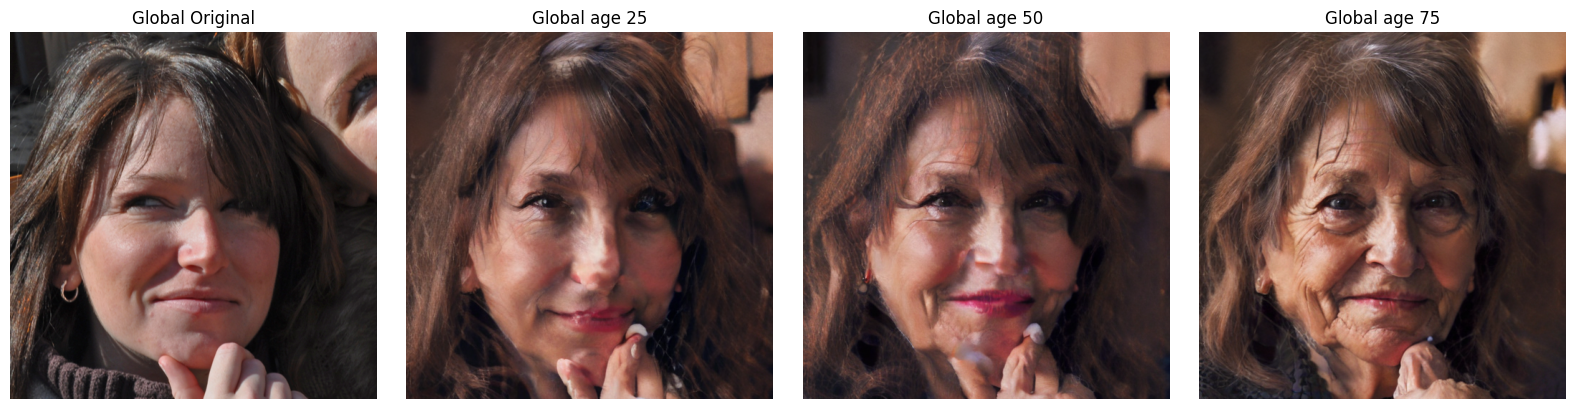


Prompts:
- a portrait of a 25-year-old person
- a portrait of a 50-year-old person
- a portrait of a 75-year-old person


In [ ]:
global_batch = next(iter(global_train_loader))
global_input = global_batch["pixel_values"][0:1]   # [1,3,512,512]

global_prompts = [
    "a portrait of a 25-year-old person",
    "a portrait of a 50-year-old person",
    "a portrait of a 75-year-old person",
]

global_negative_prompt = (
    "blurry, distorted, deformed, bad anatomy, extra eyes, extra nose, "
    "extra mouth, artifacts, low quality"
)

global_outputs = []
for prompt in global_prompts:
    out = img2img_single_bundle(
        bundle=global_bundle,
        image_tensor=global_input,
        prompt=prompt,
        negative_prompt=global_negative_prompt,
        strength=0.45,
        guidance_scale=7.5,
        num_inference_steps=40,
        seed=123,
    )
    global_outputs.append(out)

show_score_sweep(
    input_crop=global_input,
    outputs=global_outputs,
    prompts=global_prompts,
    title_prefix="Global "
)

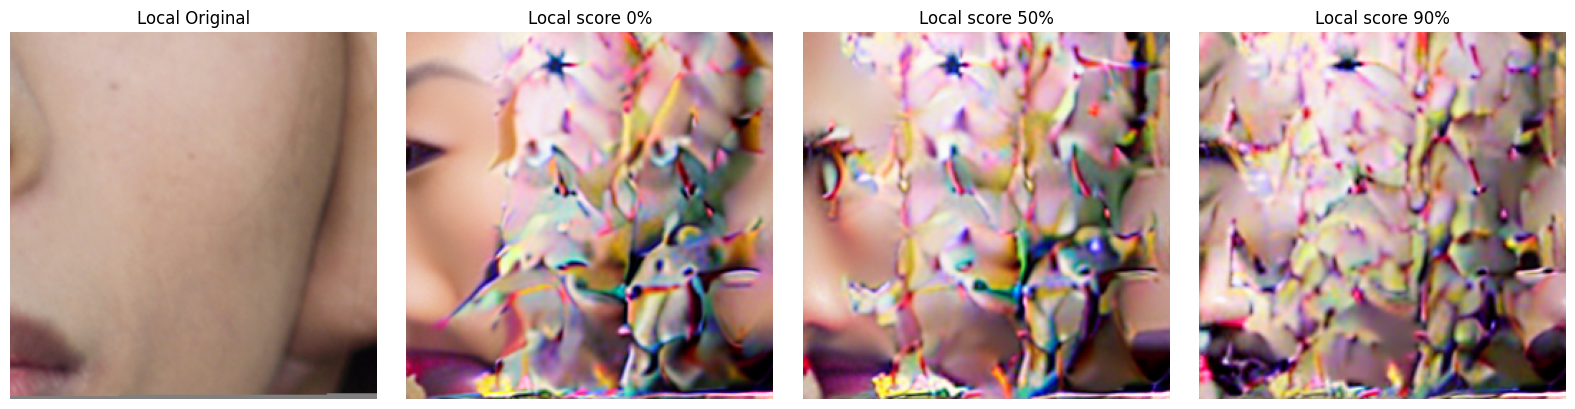


Prompts:
- image of under-eye wrinkles with an aging score of 0% for a Asian person
- image of under-eye wrinkles with an aging score of 50% for a Asian person
- image of under-eye wrinkles with an aging score of 90% for a Asian person


In [ ]:
local_batch = next(iter(train_loader))
local_input = local_batch["pixel_values"][0:1]   # [1,3,256,256]

# Si tu train_loader minimalista no trae zone/demographic, aquí lo fijamos manual.
# Puedes cambiar zone_text según el crop que quieras probar.
zone_text = "under-eye wrinkles"
demographic_text = "Asian person"

local_prompts = [
    f"image of {zone_text} with an aging score of 0% for a {demographic_text}",
    f"image of {zone_text} with an aging score of 50% for a {demographic_text}",
    f"image of {zone_text} with an aging score of 90% for a {demographic_text}",
]

local_negative_prompt = (
    "blurry, distorted, deformed, bad anatomy, extra eyes, extra nose, "
    "extra mouth, artifacts, low quality"
)

local_outputs = []
for prompt in local_prompts:
    out = img2img_single_bundle(
        bundle=local_bundle,
        image_tensor=local_input,
        prompt=prompt,
        negative_prompt=local_negative_prompt,
        strength=0.45,
        guidance_scale=7.5,
        num_inference_steps=40,
        seed=123,
    )
    local_outputs.append(out)

show_score_sweep(
    input_crop=local_input,
    outputs=local_outputs,
    prompts=local_prompts,
    title_prefix="Local "
)

---

# CNN corrector

In [ ]:
# ============================================================
# LOCAL SCORENET / MINI EFFICIENTNET-LIKE CNN
# Predicts local aging score from crop image
#
# Input:
#   x: [B, 3, 256, 256] in [-1, 1]
#
# Output:
#   score_pred: [B] in [0, 1]
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

class SqueezeExcitation(nn.Module):
    def __init__(self, channels, reduction=4):
        super().__init__()

        hidden = max(8, channels // reduction)

        self.net = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, hidden, kernel_size=1),
            nn.SiLU(),
            nn.Conv2d(hidden, channels, kernel_size=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        scale = self.net(x)
        return x * scale


class DepthwiseSeparableConv(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        stride=1,
        expansion=2,
        use_se=True,
        dropout=0.0,
    ):
        super().__init__()

        hidden_channels = in_channels * expansion
        self.use_residual = (stride == 1 and in_channels == out_channels)

        self.expand = nn.Sequential(
            nn.Conv2d(in_channels, hidden_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(hidden_channels),
            nn.SiLU(),
        )

        self.depthwise = nn.Sequential(
            nn.Conv2d(
                hidden_channels,
                hidden_channels,
                kernel_size=3,
                stride=stride,
                padding=1,
                groups=hidden_channels,
                bias=False,
            ),
            nn.BatchNorm2d(hidden_channels),
            nn.SiLU(),
        )

        self.se = SqueezeExcitation(hidden_channels) if use_se else nn.Identity()

        self.project = nn.Sequential(
            nn.Conv2d(hidden_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
        )

        self.dropout = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()

    def forward(self, x):
        out = self.expand(x)
        out = self.depthwise(out)
        out = self.se(out)
        out = self.project(out)
        out = self.dropout(out)

        if self.use_residual:
            out = out + x

        return out

In [ ]:
class LocalScoreNet(nn.Module):
    """
    Lightweight CNN regressor for local aging score.

    Input:
        crop image [B, 3, 256, 256] in [-1, 1]

    Output:
        score_pred [B] in [0, 1]
    """

    def __init__(
        self,
        in_channels=3,
        base_channels=32,
        dropout=0.15,
    ):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(
                in_channels,
                base_channels,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(base_channels),
            nn.SiLU(),
        )

        self.blocks = nn.Sequential(
            # 256 -> 128
            DepthwiseSeparableConv(base_channels, 48, stride=1, expansion=2, dropout=0.00),

            # 128 -> 64
            DepthwiseSeparableConv(48, 64, stride=2, expansion=2, dropout=0.02),
            DepthwiseSeparableConv(64, 64, stride=1, expansion=2, dropout=0.02),

            # 64 -> 32
            DepthwiseSeparableConv(64, 96, stride=2, expansion=2, dropout=0.04),
            DepthwiseSeparableConv(96, 96, stride=1, expansion=2, dropout=0.04),

            # 32 -> 16
            DepthwiseSeparableConv(96, 128, stride=2, expansion=2, dropout=0.06),
            DepthwiseSeparableConv(128, 128, stride=1, expansion=2, dropout=0.06),

            # 16 -> 8
            DepthwiseSeparableConv(128, 192, stride=2, expansion=2, dropout=0.08),
        )

        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.LayerNorm(192),
            nn.Dropout(dropout),
            nn.Linear(192, 64),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        # x comes in [-1, 1].
        # CNNs are okay with this, but mapping to [0, 1] can stabilize early training.
        x = (x + 1.0) / 2.0
        x = x.clamp(0, 1)

        x = self.stem(x)
        x = self.blocks(x)
        logits = self.head(x).squeeze(-1)

        # score in [0, 1]
        score_pred = torch.sigmoid(logits)

        return score_pred

---

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    sampler=train_sampler,
    shuffle=False,
    num_workers=2,
    collate_fn=local_collate_fn,
    pin_memory=True,
    drop_last=False)


val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    collate_fn=local_collate_fn,
    pin_memory=True,
    drop_last=False,
)

print("\n[Dataset sizes]")
print("train_dataset virtual size:", len(train_dataset))
print("val_dataset size:", len(val_dataset))

batch = next(iter(train_loader))
print("\n[Batch check]")
print("pixel_values:", batch["pixel_values"].shape)
print("score:", batch["score"].shape)
print("prompt[0]:", batch["prompt"][0])
print("zone_prompt[0]:", batch["zone_prompt"][0])
print("region_key[0]:", batch["region_key"][0])
print("score original -> augmented:", batch["score_original"][0].item(), "->", batch["score_raw"][0].item())


[Dataset sizes]
train_dataset virtual size: 5030
val_dataset size: 88

[Batch check]
pixel_values: torch.Size([64, 3, 256, 256])
score: torch.Size([64])
prompt[0]: a tightly cropped, centered close-up of the nasolabial fold region, showing facial skin texture and local aging details, with an aging score of 19%, for a white person
zone_prompt[0]: a tightly cropped, centered close-up of the nasolabial fold region, showing facial skin texture
region_key[0]: surcos_nasogenianos
score original -> augmented: 20.0 -> 19.0


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
score_dtype = torch.float32

score_net = LocalScoreNet(
    in_channels=3,
    base_channels=32,
    dropout=0.15,
).to(device=device, dtype=score_dtype)

print_trainable_report("LocalScoreNet", score_net)
print_gpu_mem("[After ScoreNet init] ")

score_optimizer = torch.optim.AdamW(
    score_net.parameters(),
    lr=3e-4,
    betas=(0.9, 0.999),
    weight_decay=1e-4,
)

print("[OK] Created score_optimizer")


========== LocalScoreNet ==========
Total params:     439,561
Trainable params: 439,561
Frozen params:    0
Trainable %:      100.000000%
[After ScoreNet init] allocated=0.07 GB | reserved=0.10 GB | max=0.07 GB
[OK] Created score_optimizer


In [ ]:
score_net.train()

batch = next(iter(train_loader))

x = batch["pixel_values"].to(device=device, dtype=score_dtype)
y = batch["score"].to(device=device, dtype=score_dtype)

score_pred = score_net(x)

loss_score = F.mse_loss(score_pred, y)

print("x:", x.shape)
print("y:", y.shape)
print("score_pred:", score_pred.shape)
print("score_pred min/max:", score_pred.min().item(), score_pred.max().item())
print("loss_score:", loss_score.item())

x: torch.Size([64, 3, 256, 256])
y: torch.Size([64])
score_pred: torch.Size([64])
score_pred min/max: 0.41835981607437134 0.6247450709342957
loss_score: 0.10718640685081482


---

# Training Score Net

In [ ]:
# ============================================================
# BASIC BUT SOLID SCORENET TRAINING LOOP
# Training by epochs, printing/evaluating by optimizer steps.
#
# Assumes already defined:
#   - score_net
#   - train_loader
#   - val_loader
#   - device
#   - print_gpu_mem
# ============================================================

import math
import torch
import torch.nn.functional as F

# ============================================================
# Helpers
# ============================================================

def batch_corrcoef(pred, target, eps=1e-8):
    pred = pred.view(-1).float()
    target = target.view(-1).float()

    pred_centered = pred - pred.mean()
    target_centered = target - target.mean()

    cov = (pred_centered * target_centered).mean()
    pred_std = pred_centered.std(unbiased=False)
    target_std = target_centered.std(unbiased=False)

    return cov / (pred_std * target_std + eps)


def batch_r2_score(pred, target, eps=1e-8):
    pred = pred.view(-1).float()
    target = target.view(-1).float()

    ss_res = ((target - pred) ** 2).sum()
    ss_tot = ((target - target.mean()) ** 2).sum()

    return 1.0 - ss_res / (ss_tot + eps)


def scorenet_extreme_aware_loss(
    pred,
    y,
    mae_weight=0.25,
    std_weight=0.05,
    high_tail_weight=4.0,
    high_under_weight=3.0,
    high_threshold=0.70,
    high_power=2.0,
    eps=1e-8,
):
    """
    Extreme-aware regression loss for local aging scores in [0, 1].

    Components:
    1. Weighted MSE:
       Gives larger weight to high aging scores.

    2. MAE:
       Stabilizes absolute calibration.

    3. STD loss:
       Penalizes range compression, encouraging pred std to match target std.

    4. High-underprediction loss:
       Strongly penalizes cases where y is high but pred is too low.
       This is useful because the model was regressing high scores toward the mean.
    """

    pred = pred.view(-1).float()
    y = y.view(-1).float()

    # ------------------------------------------------------------
    # Weighted MSE: high targets matter more.
    # ------------------------------------------------------------
    # Smooth weighting across the whole [0, 1] range.
    # y=0   -> weight approx 1
    # y=1   -> weight approx 1 + high_tail_weight
    target_weight = 1.0 + high_tail_weight * torch.clamp(y, 0.0, 1.0).pow(high_power)

    weighted_mse = (target_weight * (pred - y).pow(2)).mean()

    # ------------------------------------------------------------
    #  MAE: improves calibration.
    # ------------------------------------------------------------
    mae = F.l1_loss(pred, y)

    # ------------------------------------------------------------
    # STD loss: prevents prediction collapse toward the mean.
    # ------------------------------------------------------------
    pred_std = pred.std(unbiased=False)
    y_std = y.std(unbiased=False)
    std_loss = torch.abs(pred_std - y_std)

    # ------------------------------------------------------------
    # High-underprediction penalty.
    # ------------------------------------------------------------
    # Only activates strongly for y >= high_threshold.
    # Penalizes pred < y, but does not punish overprediction here.
    high_mask = (y >= high_threshold).float()

    under_error = F.relu(y - pred).pow(2)

    high_under_loss = (high_mask * under_error).sum() / (high_mask.sum() + eps)

    # ------------------------------------------------------------
    # Total loss.
    # ------------------------------------------------------------
    loss = (
        weighted_mse
        + mae_weight * mae
        + std_weight * std_loss
        + high_under_weight * high_under_loss
    )

    loss_parts = {
        "loss": loss.detach(),
        "weighted_mse": weighted_mse.detach(),
        "mae": mae.detach(),
        "std_loss": std_loss.detach(),
        "high_under_loss": high_under_loss.detach(),
        "pred_std": pred_std.detach(),
        "target_std": y_std.detach(),
        "mean_weight": target_weight.mean().detach(),
        "max_weight": target_weight.max().detach(),
        "n_high": high_mask.sum().detach(),
    }

    return loss, loss_parts


@torch.no_grad()
def evaluate_score_net(
    score_net,
    loader,
    device,
    max_batches=None,
):
    score_net.eval()

    all_preds = []
    all_targets = []

    for batch_idx, batch in enumerate(loader, start=1):
        if max_batches is not None and batch_idx > max_batches:
            break

        x = batch["pixel_values"].to(device=device, dtype=torch.float32)
        y = batch["score"].to(device=device, dtype=torch.float32).view(-1)

        pred = score_net(x).view(-1)

        all_preds.append(pred.detach().cpu())
        all_targets.append(y.detach().cpu())

    pred = torch.cat(all_preds, dim=0).float()
    y = torch.cat(all_targets, dim=0).float()

    mse = F.mse_loss(pred, y)
    rmse = torch.sqrt(mse)
    mae = F.l1_loss(pred, y)
    corr = batch_corrcoef(pred, y)
    r2 = batch_r2_score(pred, y)

    high_mask = y >= 0.70

    if high_mask.any():
        high_mae = F.l1_loss(pred[high_mask], y[high_mask])
        high_mse = F.mse_loss(pred[high_mask], y[high_mask])
        high_under_mae = F.relu(y[high_mask] - pred[high_mask]).mean()
    else:
        high_mae = torch.tensor(float("nan"))
        high_mse = torch.tensor(float("nan"))
        high_under_mae = torch.tensor(float("nan"))

    metrics = {
        "mse": mse.item(),
        "rmse": rmse.item(),
        "mae": mae.item(),
        "corr": corr.item(),
        "r2": r2.item(),

        "target_min": y.min().item(),
        "target_mean": y.mean().item(),
        "target_max": y.max().item(),
        "target_std": y.std(unbiased=False).item(),

        "pred_min": pred.min().item(),
        "pred_mean": pred.mean().item(),
        "pred_max": pred.max().item(),
        "pred_std": pred.std(unbiased=False).item(),

        "std_ratio": (pred.std(unbiased=False) / (y.std(unbiased=False) + 1e-8)).item(),

        "high_mae": high_mae.item(),
        "high_mse": high_mse.item(),
        "high_under_mae": high_under_mae.item(),
        "n_high": int(high_mask.sum().item()),
    }

    return metrics


def print_score_metrics(prefix, metrics):
    print(f"{prefix}_mse:        {metrics['mse']:.6f}")
    print(f"{prefix}_rmse:       {metrics['rmse']:.6f}")
    print(f"{prefix}_mae:        {metrics['mae']:.6f}")
    print(f"{prefix}_corr:       {metrics['corr']:.4f}")
    print(f"{prefix}_r2:         {metrics['r2']:.4f}")

    print(
        f"{prefix}_target min/mean/max/std: "
        f"{metrics['target_min']:.4f} / "
        f"{metrics['target_mean']:.4f} / "
        f"{metrics['target_max']:.4f} / "
        f"{metrics['target_std']:.4f}"
    )

    print(
        f"{prefix}_pred   min/mean/max/std: "
        f"{metrics['pred_min']:.4f} / "
        f"{metrics['pred_mean']:.4f} / "
        f"{metrics['pred_max']:.4f} / "
        f"{metrics['pred_std']:.4f}"
    )

    print(f"{prefix}_std_ratio pred/target: {metrics['std_ratio']:.4f}")

    print(
        f"{prefix}_high_targets y>=0.70 | "
        f"n={metrics['n_high']} | "
        f"high_mae={metrics['high_mae']:.6f} | "
        f"high_mse={metrics['high_mse']:.6f} | "
        f"high_under_mae={metrics['high_under_mae']:.6f}"
    )

def compute_score_selection_metric(metrics):
    """
    Composite metric for selecting the best ScoreNet checkpoint.

    Higher is better.

    We care about:
        - high correlation
        - high R2
        - low MAE
        - low high-score underprediction
        - reasonable prediction variance

    This is not a pure validation-generalization criterion.
    It is designed for selecting a useful auxiliary signal model.
    """
    corr = float(metrics["corr"])
    r2 = float(metrics["r2"])
    mae = float(metrics["mae"])
    high_under_mae = float(metrics["high_under_mae"])
    std_ratio = float(metrics["std_ratio"])

    # Penalize strong variance collapse or excessive variance.
    std_penalty = abs(1.0 - std_ratio)

    score = (
        1.00 * corr
        + 0.50 * r2
        - 0.75 * mae
        - 0.75 * high_under_mae
        - 0.25 * std_penalty
    )

    return float(score)


def merge_train_val_selection_score(train_metrics, val_metrics):
    """
    Best-overall criterion.

    Since this ScoreNet is an auxiliary teacher/signal model, we do not want
    to select only by validation. We want a model that is strong on train while
    not being terrible on validation.

    Higher is better.
    """
    train_score = compute_score_selection_metric(train_metrics)

    if val_metrics is not None:
        val_score = compute_score_selection_metric(val_metrics)

        # Weighted toward train because the model is not intended as a
        # standalone general-purpose inference model.
        overall_score = 0.65 * train_score + 0.35 * val_score
    else:
        val_score = None
        overall_score = train_score

    return {
        "overall_score": float(overall_score),
        "train_score": float(train_score),
        "val_score": None if val_score is None else float(val_score),
    }


def save_score_net_weights_only(
    path,
    score_net,
    epoch,
    global_step,
    train_metrics=None,
    val_metrics=None,
    selection_scores=None,
):
    """
    Saves only what we need for forward later:
        - model state_dict
        - minimal metadata

    No optimizer.
    No scheduler.
    No giant training state.
    """
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    payload = {
        "model_state_dict": score_net.state_dict(),
        "epoch": int(epoch),
        "global_step": int(global_step),
        "train_metrics": train_metrics,
        "val_metrics": val_metrics,
        "selection_scores": selection_scores,
    }

    torch.save(payload, path)



def train_score_net_epochs(
    score_net,
    train_loader,
    val_loader,
    optimizer,
    scheduler,
    device,
    num_epochs=20,
    print_every=25,
    eval_every=100,
    grad_clip=1.0,

    # Loss hyperparameters.
    mae_weight=0.25,
    std_weight=0.05,
    high_tail_weight=4.0,
    high_under_weight=3.0,
    high_threshold=0.70,
    high_power=2.0,

    # Checkpointing.
    checkpoint_dir="/content/score_net_checkpoints",
    best_filename="score_net_best_overall.pt",
    last_filename="score_net_last.pt",

    # For best-overall selection.
    # If None, evaluates the whole train_loader.
    # If train_loader is too slow, use e.g. 30 or 50.
    train_eval_max_batches=None,
):
    score_net.to(device=device, dtype=torch.float32)

    checkpoint_dir = Path(checkpoint_dir)
    checkpoint_dir.mkdir(parents=True, exist_ok=True)

    best_path = checkpoint_dir / best_filename
    last_path = checkpoint_dir / last_filename

    global_step = 0
    best_overall_score = -float("inf")

    running_loss = 0.0
    running_weighted_mse = 0.0
    running_mae_loss = 0.0
    running_std_loss = 0.0
    running_high_under_loss = 0.0

    running_mae = 0.0
    running_corr = 0.0
    running_r2 = 0.0
    running_batches = 0

    print("\n========== START SCORENET TRAINING ==========")
    print("Training mode: epochs")
    print("num_epochs:", num_epochs)
    print("print_every steps:", print_every)
    print("eval_every steps:", eval_every)
    print("device:", device)

    print("\n[Checkpointing]")
    print("checkpoint_dir:", str(checkpoint_dir))
    print("best_overall:", str(best_path))
    print("last:", str(last_path))
    print("train_eval_max_batches:", train_eval_max_batches)

    print("\n[Loss config]")
    print(f"mae_weight:        {mae_weight}")
    print(f"std_weight:        {std_weight}")
    print(f"high_tail_weight:  {high_tail_weight}")
    print(f"high_under_weight: {high_under_weight}")
    print(f"high_threshold:    {high_threshold}")
    print(f"high_power:        {high_power}")

    for epoch in range(1, num_epochs + 1):
        score_net.train()

        print("\n==================================================")
        print(f"EPOCH {epoch}/{num_epochs}")
        print("==================================================")

        for batch_idx, batch in enumerate(train_loader, start=1):
            global_step += 1

            x = batch["pixel_values"].to(device=device, dtype=torch.float32)
            y = batch["score"].to(device=device, dtype=torch.float32).view(-1)

            optimizer.zero_grad(set_to_none=True)

            pred = score_net(x).view(-1)

            loss, loss_parts = scorenet_extreme_aware_loss(
                pred=pred,
                y=y,
                mae_weight=mae_weight,
                std_weight=std_weight,
                high_tail_weight=high_tail_weight,
                high_under_weight=high_under_weight,
                high_threshold=high_threshold,
                high_power=high_power,
            )

            # Diagnostics.
            plain_mse = F.mse_loss(pred.detach(), y.detach())
            mae = F.l1_loss(pred.detach(), y.detach())
            corr = batch_corrcoef(pred.detach(), y.detach())
            r2 = batch_r2_score(pred.detach(), y.detach())

            loss.backward()

            if grad_clip is not None:
                grad_norm = torch.nn.utils.clip_grad_norm_(
                    score_net.parameters(),
                    max_norm=grad_clip,
                )
            else:
                grad_norm = torch.tensor(float("nan"))

            optimizer.step()

            if scheduler is not None:
                scheduler.step()

            running_loss += loss.item()
            running_weighted_mse += loss_parts["weighted_mse"].item()
            running_mae_loss += loss_parts["mae"].item()
            running_std_loss += loss_parts["std_loss"].item()
            running_high_under_loss += loss_parts["high_under_loss"].item()

            running_mae += mae.item()
            running_corr += corr.item()
            running_r2 += r2.item()
            running_batches += 1

            if global_step == 1 or global_step % print_every == 0:
                lr = optimizer.param_groups[0]["lr"]

                avg_loss = running_loss / max(running_batches, 1)
                avg_weighted_mse = running_weighted_mse / max(running_batches, 1)
                avg_mae_loss = running_mae_loss / max(running_batches, 1)
                avg_std_loss = running_std_loss / max(running_batches, 1)
                avg_high_under_loss = running_high_under_loss / max(running_batches, 1)

                avg_mae = running_mae / max(running_batches, 1)
                avg_corr = running_corr / max(running_batches, 1)
                avg_r2 = running_r2 / max(running_batches, 1)

                print("\n--------------------------------------------------")
                print(f"[Step {global_step:05d} | Epoch {epoch}/{num_epochs} | Batch {batch_idx}/{len(train_loader)}]")
                print(f"lr:                    {lr:.8f}")

                print("\n[Train objective]")
                print(f"avg_total_loss:        {avg_loss:.6f}")
                print(f"avg_weighted_mse:      {avg_weighted_mse:.6f}")
                print(f"avg_mae_loss:          {avg_mae_loss:.6f}")
                print(f"avg_std_loss:          {avg_std_loss:.6f}")
                print(f"avg_high_under_loss:   {avg_high_under_loss:.6f}")

                print("\n[Train diagnostics]")
                print(f"last_plain_mse:        {plain_mse.item():.6f}")
                print(f"last_plain_rmse:       {math.sqrt(plain_mse.item()):.6f}")
                print(f"avg_mae:               {avg_mae:.6f}")
                print(f"avg_corr:              {avg_corr:.4f}")
                print(f"avg_r2:                {avg_r2:.4f}")
                print(f"last_mae:              {mae.item():.6f}")
                print(f"last_corr:             {corr.item():.4f}")
                print(f"last_r2:               {r2.item():.4f}")
                print(f"grad_norm:             {float(grad_norm):.4f}")

                print("\n[Loss internals - current batch]")
                print(f"mean_weight:           {loss_parts['mean_weight'].item():.4f}")
                print(f"max_weight:            {loss_parts['max_weight'].item():.4f}")
                print(f"n_high y>={high_threshold}:       {int(loss_parts['n_high'].item())}")

                print("\n[Current batch ranges]")
                print(
                    f"target min/mean/max/std: "
                    f"{y.min().item():.4f} / "
                    f"{y.mean().item():.4f} / "
                    f"{y.max().item():.4f} / "
                    f"{y.std(unbiased=False).item():.4f}"
                )
                print(
                    f"pred   min/mean/max/std: "
                    f"{pred.min().item():.4f} / "
                    f"{pred.mean().item():.4f} / "
                    f"{pred.max().item():.4f} / "
                    f"{pred.std(unbiased=False).item():.4f}"
                )

                std_ratio = pred.detach().std(unbiased=False) / (y.detach().std(unbiased=False) + 1e-8)
                print(f"std_ratio pred/target: {std_ratio.item():.4f}")

                high_mask = y >= high_threshold
                if high_mask.any():
                    high_mae = F.l1_loss(pred.detach()[high_mask], y.detach()[high_mask])
                    high_under_mae = F.relu(y.detach()[high_mask] - pred.detach()[high_mask]).mean()
                    print(
                        f"high targets y>={high_threshold} | "
                        f"n={int(high_mask.sum().item())} | "
                        f"high_mae={high_mae.item():.6f} | "
                        f"high_under_mae={high_under_mae.item():.6f}"
                    )

                print("\n[First predictions]")
                n_show = min(8, y.shape[0])
                for i in range(n_show):
                    print(f"  y={y[i].item():.3f} | pred={pred[i].item():.3f}")

                running_loss = 0.0
                running_weighted_mse = 0.0
                running_mae_loss = 0.0
                running_std_loss = 0.0
                running_high_under_loss = 0.0

                running_mae = 0.0
                running_corr = 0.0
                running_r2 = 0.0
                running_batches = 0

            if val_loader is not None and (global_step == 1 or global_step % eval_every == 0):
                print("\n================ VALIDATION ================")
                val_metrics = evaluate_score_net(
                    score_net=score_net,
                    loader=val_loader,
                    device=device,
                    max_batches=None,
                )
                print(f"[Validation at step {global_step:05d}]")
                print_score_metrics("val", val_metrics)

                score_net.train()

        # ========================================================
        # End-of-epoch evaluation + checkpointing
        # ========================================================

        print("\n================ END OF EPOCH TRAIN EVAL ================")
        train_metrics_epoch = evaluate_score_net(
            score_net=score_net,
            loader=train_loader,
            device=device,
            max_batches=train_eval_max_batches,
        )
        print(f"[Train eval epoch {epoch}/{num_epochs} | step {global_step:05d}]")
        print_score_metrics("train_eval", train_metrics_epoch)

        if val_loader is not None:
            print("\n================ END OF EPOCH VALIDATION ================")
            val_metrics_epoch = evaluate_score_net(
                score_net=score_net,
                loader=val_loader,
                device=device,
                max_batches=None,
            )
            print(f"[Val eval epoch {epoch}/{num_epochs} | step {global_step:05d}]")
            print_score_metrics("val", val_metrics_epoch)
        else:
            val_metrics_epoch = None

        selection_scores = merge_train_val_selection_score(
            train_metrics=train_metrics_epoch,
            val_metrics=val_metrics_epoch,
        )

        overall_score = selection_scores["overall_score"]

        print("\n[Checkpoint selection scores]")
        print(f"overall_score: {selection_scores['overall_score']:.6f}")
        print(f"train_score:   {selection_scores['train_score']:.6f}")
        if selection_scores["val_score"] is not None:
            print(f"val_score:     {selection_scores['val_score']:.6f}")
        print(f"best_so_far:   {best_overall_score:.6f}")

        # Always overwrite last.
        save_score_net_weights_only(
            path=last_path,
            score_net=score_net,
            epoch=epoch,
            global_step=global_step,
            train_metrics=train_metrics_epoch,
            val_metrics=val_metrics_epoch,
            selection_scores=selection_scores,
        )
        print(f"[Saved last] {last_path}")

        # Overwrite best only if better.
        if overall_score > best_overall_score:
            best_overall_score = overall_score

            save_score_net_weights_only(
                path=best_path,
                score_net=score_net,
                epoch=epoch,
                global_step=global_step,
                train_metrics=train_metrics_epoch,
                val_metrics=val_metrics_epoch,
                selection_scores=selection_scores,
            )
            print(f"[Saved BEST overall] {best_path}")
        else:
            print("[BEST unchanged]")

        score_net.train()

    print("\n========== DONE SCORENET TRAINING ==========")
    print("Final global_step:", global_step)
    print("Best overall score:", best_overall_score)
    print("Best checkpoint:", str(best_path))
    print("Last checkpoint:", str(last_path))

    try:
        print_gpu_mem("[After ScoreNet training] ")
    except NameError:
        pass

In [ ]:
score_lr = 3e-4
score_weight_decay = 1e-4
num_epochs = 25

score_optimizer = torch.optim.AdamW(
    score_net.parameters(),
    lr=3e-4,
    betas=(0.9, 0.999),
    weight_decay=1e-4,
)

total_steps = num_epochs * len(train_loader)

score_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    score_optimizer,
    T_max=total_steps,
    eta_min=3e-5,
)


train_score_net_epochs(
    score_net=score_net,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=score_optimizer,
    scheduler=score_scheduler,
    device=device,
    num_epochs=25,
    print_every=50,
    eval_every=1000,
    grad_clip=1.0,

    checkpoint_dir="/content/score_net_checkpoints",
    best_filename="score_net_best_overall.pt",
    last_filename="score_net_last.pt",

    # Use None for full train eval.
    # Use 50 or 80 if you want faster epoch-end evaluation.
    train_eval_max_batches=None,
)



========== START SCORENET TRAINING ==========
Training mode: epochs
num_epochs: 25
print_every steps: 50
eval_every steps: 1000
device: cuda

[Checkpointing]
checkpoint_dir: /content/score_net_checkpoints
best_overall: /content/score_net_checkpoints/score_net_best_overall.pt
last: /content/score_net_checkpoints/score_net_last.pt
train_eval_max_batches: None

[Loss config]
mae_weight:        0.25
std_weight:        0.05
high_tail_weight:  4.0
high_under_weight: 3.0
high_threshold:    0.7
high_power:        2.0

EPOCH 1/25

--------------------------------------------------
[Step 00001 | Epoch 1/25 | Batch 1/79]
lr:                    0.00030000

[Train objective]
avg_total_loss:        0.915811
avg_weighted_mse:      0.319353
avg_mae_loss:          0.303536
avg_std_loss:          0.290791
avg_high_under_loss:   0.168678

[Train diagnostics]
last_plain_mse:        0.120213
last_plain_rmse:       0.346717
avg_mae:               0.303536
avg_corr:              -0.1544
avg_r2:             

---

# Loss For Local Path

In [ ]:
import gc
import sys
import torch

def hard_cleanup_after_oom():
    # --------------------------------------------------------
    # Delete likely graph/tensor variables from globals
    # --------------------------------------------------------
    names_to_delete = [
        # outputs / losses
        "loss_out", "loss", "total_loss",
        "loss_full", "loss_zone", "loss_score", "loss_cycle",

        # batches / targets
        "batch", "batch_small", "small_batch",
        "target_prompts", "target_scores",
        "source_prompts", "zone_prompts",

        # latent/image intermediates
        "pixel_values", "x", "y", "pred",
        "z0", "zt", "zt_score",
        "noise", "noise_score",
        "timesteps", "timesteps_score",
        "noise_pred", "noise_pred_full", "noise_pred_zone", "noise_pred_target",
        "x0_hat_latents", "x0_hat_target_latents",
        "decoded_score_image", "decoded_crop",

        # hidden states
        "encoder_hidden_states", "target_hidden",
        "text_inputs", "input_ids", "attention_mask",
    ]

    for name in names_to_delete:
        if name in globals():
            try:
                del globals()[name]
            except Exception:
                pass

    # --------------------------------------------------------
    # Clear Python exception traceback references
    # This is important after CUDA OOM in notebooks.
    # --------------------------------------------------------
    sys.last_type = None
    sys.last_value = None
    sys.last_traceback = None

    # --------------------------------------------------------
    # Clear IPython output cache if available
    # The variables _, __, ___ and Out can keep tensors alive.
    # --------------------------------------------------------
    try:
        ip = get_ipython()
        ip.user_ns["_"] = None
        ip.user_ns["__"] = None
        ip.user_ns["___"] = None
        ip.user_ns["_i"] = None
        ip.user_ns["_ii"] = None
        ip.user_ns["_iii"] = None
        ip.run_line_magic("reset", "-f out")
    except Exception as e:
        print("[WARN] Could not clear IPython output cache:", e)

    # --------------------------------------------------------
    #  Python + CUDA cleanup
    # --------------------------------------------------------
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
        torch.cuda.reset_peak_memory_stats()

    # --------------------------------------------------------
    #  Report
    # --------------------------------------------------------
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated() / 1024**3
        reserved = torch.cuda.memory_reserved() / 1024**3
        max_allocated = torch.cuda.max_memory_allocated() / 1024**3

        print("========== CUDA MEMORY AFTER CLEANUP ==========")
        print(f"allocated:     {allocated:.3f} GB")
        print(f"reserved:      {reserved:.3f} GB")
        print(f"max_allocated: {max_allocated:.3f} GB")


hard_cleanup_after_oom()

Flushing output cache (0 entries)
========== CUDA MEMORY AFTER CLEANUP ==========
allocated:     13.915 GB
reserved:      14.289 GB
max_allocated: 13.915 GB


In [ ]:
# ============================================================
# LOCAL LDLA-STYLE LOSS FOR LOCAL FACE AGING BRANCH
#
# Implements:
#   L_local = λ_full  * L_full
#           + λ_zone  * L_zone
#           + λ_score * L_score
#           + λ_cycle * L_cycle
#
# Main inputs expected from batch:
#   batch["pixel_values"] : Tensor [B, 3, 256, 256] in [-1, 1]
#   batch["score"]        : Tensor [B] in [0, 1]
#   batch["prompt"]       : List[str] full prompts P_full
#   batch["zone_prompt"]  : List[str] zone prompts P_zone
#
# Optional:
#   batch["target_prompt"] : List[str] P_target for cycle loss
#
# Assumes local_bundle has:
#   local_bundle["vae"]
#   local_bundle["unet"]
#   local_bundle["tokenizer"]
#   local_bundle["text_encoder"]
#   local_bundle["scheduler_train"]
#
# Important:
#   - ScoreNet receives decoded RGB images [B, 3, 256, 256], not latents.
#   - VAE/text_encoder are frozen.
#   - ScoreNet may be frozen, but its forward must NOT be under torch.no_grad()
#     if we want gradients to flow back to decoded images and then to the UNet.
# ============================================================

import math
from typing import Dict, Any, List, Optional

import torch
import torch.nn as nn
import torch.nn.functional as F


class LDLALocalAgingLoss(nn.Module):
    def __init__(
        self,
        local_bundle: Dict[str, Any],
        score_net: Optional[nn.Module] = None,
        lambda_full: float = 1.0,
        lambda_zone: float = 0.25,
        lambda_score: float = 0.05,
        lambda_cycle: float = 0.0,
        freeze_score_net: bool = True,
        score_net_input_dtype: torch.dtype = torch.float32,
        device: Optional[str] = None,
        score_timestep_min: int = 20,
        score_timestep_max: int = 400,

        unet_dtype: Optional[torch.dtype] = None):

        super().__init__()

        self.local_bundle = local_bundle
        self.score_timestep_min = int(score_timestep_min)
        self.score_timestep_max = int(score_timestep_max)
        self.vae = local_bundle["vae"]
        self.unet = local_bundle["unet"]
        self.tokenizer = local_bundle["tokenizer"]
        self.text_encoder = local_bundle["text_encoder"]
        self.scheduler = local_bundle["scheduler_train"]

        self.score_net = score_net

        self.lambda_full = float(lambda_full)
        self.lambda_zone = float(lambda_zone)
        self.lambda_score = float(lambda_score)
        self.lambda_cycle = float(lambda_cycle)

        self.score_net_input_dtype = score_net_input_dtype

        if device is None:
            device = next(self.unet.parameters()).device
        self.device = torch.device(device)

        if unet_dtype is None:
            unet_dtype = next(self.unet.parameters()).dtype
        self.unet_dtype = unet_dtype

        # Frozen modules.
        self.vae.eval()
        self.text_encoder.eval()

        for p in self.vae.parameters():
            p.requires_grad_(False)

        for p in self.text_encoder.parameters():
            p.requires_grad_(False)

        if self.score_net is not None:
            if freeze_score_net:
                self.score_net.eval()
                for p in self.score_net.parameters():
                    p.requires_grad_(False)
            else:
                self.score_net.train()

        # Safety checks.
        if self.lambda_score > 0 and self.score_net is None:
            raise ValueError("lambda_score > 0 but score_net is None.")

        if self.lambda_cycle > 0:
            print(
                "[WARN] lambda_cycle > 0: cycle loss is expensive because it uses "
                "extra UNet passes. For the first local training run, consider "
                "lambda_cycle=0.0."
            )

    # --------------------------------------------------------
    # Text conditioning
    # --------------------------------------------------------

    @torch.no_grad()
    def encode_prompts(self, prompts: List[str]) -> torch.Tensor:
        """
        Encodes prompts using the checkpoint's own tokenizer/text_encoder.

        Returns:
            encoder_hidden_states: [B, 77, cross_attention_dim]
        """
        text_inputs = self.tokenizer(
            prompts,
            padding="max_length",
            max_length=self.tokenizer.model_max_length,
            truncation=True,
            return_tensors="pt",
        )

        input_ids = text_inputs.input_ids.to(self.device)

        attention_mask = None
        if hasattr(text_inputs, "attention_mask"):
            attention_mask = text_inputs.attention_mask.to(self.device)

        outputs = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True,
        )

        return outputs.last_hidden_state.to(device=self.device, dtype=self.unet_dtype)

    # --------------------------------------------------------
    # VAE helpers
    # --------------------------------------------------------

    @torch.no_grad()
    def encode_images_to_latents(self, pixel_values: torch.Tensor) -> torch.Tensor:
        """
        pixel_values:
            [B, 3, 256, 256] in [-1, 1]

        returns:
            latents [B, 4, 32, 32]
        """
        x = pixel_values.to(device=self.device, dtype=self.unet_dtype)

        latents = self.vae.encode(x).latent_dist.mean
        latents = latents * self.vae.config.scaling_factor

        return latents.to(dtype=self.unet_dtype)

    def decode_latents_to_images(self, latents: torch.Tensor) -> torch.Tensor:
        """
        latents:
            [B, 4, 32, 32]

        returns:
            decoded images [B, 3, 256, 256] approximately in [-1, 1]

        Important:
            No torch.no_grad() here.
            We want gradients from ScoreNet(image) to flow back to latents
            and then to the UNet prediction.
        """
        latents_for_vae = latents / self.vae.config.scaling_factor
        latents_for_vae = latents_for_vae.to(device=self.device, dtype=self.unet_dtype)

        decoded = self.vae.decode(latents_for_vae, return_dict=True).sample
        decoded = decoded.clamp(-1.0, 1.0)

        return decoded

    # --------------------------------------------------------
    # Diffusion helpers
    # --------------------------------------------------------

    def sample_timesteps(self, batch_size: int) -> torch.Tensor:
        timesteps = torch.randint(
            low=0,
            high=self.scheduler.config.num_train_timesteps,
            size=(batch_size,),
            device=self.device,
        ).long()

        return timesteps

    def add_noise(
        self,
        latents: torch.Tensor,
        noise: torch.Tensor,
        timesteps: torch.Tensor) -> torch.Tensor:

        noisy_latents = self.scheduler.add_noise(latents, noise, timesteps)
        return noisy_latents.to(dtype=self.unet_dtype)

    def predict_noise(
        self,
        noisy_latents: torch.Tensor,
        timesteps: torch.Tensor,
        encoder_hidden_states: torch.Tensor) -> torch.Tensor:
        noise_pred = self.unet(
            noisy_latents.to(dtype=self.unet_dtype),
            timesteps,
            encoder_hidden_states=encoder_hidden_states.to(dtype=self.unet_dtype),
            return_dict=True,
        ).sample

        return noise_pred

    def predict_x0_from_noise(
        self,
        noisy_latents: torch.Tensor,
        timesteps: torch.Tensor,
        noise_pred: torch.Tensor) -> torch.Tensor:

        """
        DDPM one-step x0 estimate:

            x0_hat = (x_t - sqrt(1 - alpha_bar_t) * eps_pred) / sqrt(alpha_bar_t)

        Returns:
            x0_hat latent [B, 4, 32, 32]
        """
        alphas_cumprod = self.scheduler.alphas_cumprod.to(
            device=self.device,
            dtype=noisy_latents.dtype)

        alpha_bar_t = alphas_cumprod[timesteps].view(-1, 1, 1, 1)

        sqrt_alpha_bar_t = torch.sqrt(alpha_bar_t)
        sqrt_one_minus_alpha_bar_t = torch.sqrt(1.0 - alpha_bar_t)

        x0_hat = (
            noisy_latents - sqrt_one_minus_alpha_bar_t * noise_pred) / sqrt_alpha_bar_t.clamp_min(1e-8)

        return x0_hat

    # --------------------------------------------------------
    # Individual losses
    # --------------------------------------------------------

    def diffusion_prompt_loss(
        self,
        latents: torch.Tensor,
        noise: torch.Tensor,
        timesteps: torch.Tensor,
        noisy_latents: torch.Tensor,
        prompts: List[str]):

        """
        Standard diffusion noise-prediction loss for one prompt type.
        """
        encoder_hidden_states = self.encode_prompts(prompts)

        noise_pred = self.predict_noise(
            noisy_latents=noisy_latents,
            timesteps=timesteps,
            encoder_hidden_states=encoder_hidden_states)

        loss = F.mse_loss(noise_pred.float(), noise.float())

        return loss, noise_pred

    def score_loss_from_x0_hat(
        self,
        x0_hat_latents: torch.Tensor,
        target_scores: torch.Tensor):

        """
        Computes:
            L_score = MSE(S(VAE.decode(x0_hat)), target_score)

        ScoreNet receives:
            decoded_crop: [B, 3, 256, 256] in [-1, 1]
        """
        if self.score_net is None:
            raise ValueError("score_net is None, cannot compute score loss.")

        decoded_crop = self.decode_latents_to_images(x0_hat_latents)

        # ScoreNet was trained in fp32 on RGB image tensors.
        decoded_for_score = decoded_crop.to(
            device=self.device,
            dtype=self.score_net_input_dtype,)

        target_scores = target_scores.to(
            device=self.device,
            dtype=self.score_net_input_dtype).view(-1)

        # No torch.no_grad() here: gradient must flow to decoded_for_score.
        score_pred = self.score_net(decoded_for_score).view(-1)

        loss_score = F.mse_loss(score_pred.float(), target_scores.float())

        return loss_score, score_pred, decoded_crop

    def latent_cycle_loss(
        self,
        z0: torch.Tensor,
        source_prompts: List[str],
        target_prompts: List[str]):

        """
        Approximate LDLA latent cycle consistency.

        Concept:
            z0 --target prompt--> z0_target_hat
            z0_target_hat --source prompt--> z0_recon_hat
            L_cycle = MSE(z0_recon_hat, z0)

        This is an operational one-step approximation using DDPM x0 estimates.
        It is expensive: two extra UNet calls.
        """
        B = z0.shape[0]

        timesteps = self.sample_timesteps(B)
        noise = torch.randn_like(z0)

        zt = self.add_noise(z0, noise, timesteps)

        target_hidden = self.encode_prompts(target_prompts)
        eps_target = self.predict_noise(
            noisy_latents=zt,
            timesteps=timesteps,
            encoder_hidden_states=target_hidden,
        )

        z0_target_hat = self.predict_x0_from_noise(
            noisy_latents=zt,
            timesteps=timesteps,
            noise_pred=eps_target,
        )

        # Re-noise the target estimate and reconstruct back to source.
        noise_back = torch.randn_like(z0_target_hat)
        zt_back = self.add_noise(z0_target_hat, noise_back, timesteps)

        source_hidden = self.encode_prompts(source_prompts)
        eps_source = self.predict_noise(
            noisy_latents=zt_back,
            timesteps=timesteps,
            encoder_hidden_states=source_hidden,
        )

        z0_recon_hat = self.predict_x0_from_noise(
            noisy_latents=zt_back,
            timesteps=timesteps,
            noise_pred=eps_source,
        )

        loss_cycle = F.mse_loss(z0_recon_hat.float(), z0.float())

        return loss_cycle

    # --------------------------------------------------------
    # Main forward
    # --------------------------------------------------------

    def forward(
        self,
        batch: Dict[str, Any],

        # Which part of the local objective to compute.
        # Recommended for training:
        #   "full", "score", "zone"
        #
        # Debug / larger GPU:
        #   "full_score", "full_zone", "all"
        loss_mode: str = "all",

        # Prompts selected by the training chunk.
        # If None, defaults to batch["prompt"] and batch["zone_prompt"].
        source_prompts: Optional[List[str]] = None,
        zone_prompts: Optional[List[str]] = None,

        # Target conditioning for score/cycle.
        # These should be built in the local training chunk.
        target_prompts: Optional[List[str]] = None,
        target_scores: Optional[torch.Tensor] = None,

        return_decoded_score_image: bool = False) -> Dict[str, Any]:

        """
        Memory-aware LDLA-style local loss forward.

        Instead of always computing:
            L_full + L_zone + L_score + L_cycle

        this forward can compute only selected components via loss_mode.

        Valid loss_mode values:
            "full":
                only L_full

            "zone":
                only L_zone

            "score":
                only L_score

            "cycle":
                only L_cycle

            "full_zone":
                L_full + L_zone

            "full_score":
                L_full + L_score

            "score_zone":
                L_score + L_zone

            "all":
                all active components according to lambdas

        Recommended training on limited VRAM:
            sample loss_mode stochastically in the training wrapper:
                50% "full"
                35% "score"
                15% "zone"
        """

        # --------------------------------------------------------
        # Parse loss mode
        # --------------------------------------------------------
        loss_mode = str(loss_mode).lower().strip()

        valid_modes = {
            "full",
            "zone",
            "score",
            "cycle",
            "full_zone",
            "full_score",
            "score_zone",
            "all"}

        if loss_mode not in valid_modes:
            raise ValueError(
                f"Invalid loss_mode='{loss_mode}'. "
                f"Valid modes are: {sorted(valid_modes)}")

        compute_full = loss_mode in {"full", "full_zone", "full_score", "all"}
        compute_zone = loss_mode in {"zone", "full_zone", "score_zone", "all"}
        compute_score = loss_mode in {"score", "full_score", "score_zone", "all"}
        compute_cycle = loss_mode in {"cycle", "all"}

        # Respect lambdas too.
        compute_full = compute_full and (self.lambda_full > 0.0)
        compute_zone = compute_zone and (self.lambda_zone > 0.0)
        compute_score = compute_score and (self.lambda_score > 0.0)
        compute_cycle = compute_cycle and (self.lambda_cycle > 0.0)

        # --------------------------------------------------------
        # Inputs
        # --------------------------------------------------------
        pixel_values = batch["pixel_values"].to(
            device=self.device,
            dtype=self.unet_dtype,)

        source_scores = batch["score"].to(
            device=self.device,
            dtype=torch.float32).view(-1)

        B = pixel_values.shape[0]

        # --------------------------------------------------------
        # Prompt defaults
        # --------------------------------------------------------
        if source_prompts is None:
            source_prompts = batch["prompt"]

        if zone_prompts is None:
            zone_prompts = batch["zone_prompt"]

        if len(source_prompts) != B:
            raise ValueError(
                f"len(source_prompts)={len(source_prompts)} but batch size={B}."
            )

        if len(zone_prompts) != B:
            raise ValueError(
                f"len(zone_prompts)={len(zone_prompts)} but batch size={B}.")

        # --------------------------------------------------------
        # Target conditioning checks
        # --------------------------------------------------------
        needs_target = compute_score or compute_cycle

        if needs_target:
            if target_prompts is None:
                raise ValueError(
                    "target_prompts must be passed when loss_mode requires "
                    "L_score or L_cycle."
                )

            if target_scores is None:
                raise ValueError(
                    "target_scores must be passed when loss_mode requires "
                    "L_score or L_cycle."
                )

            if len(target_prompts) != B:
                raise ValueError(
                    f"len(target_prompts)={len(target_prompts)} but batch size={B}."
                )

            target_scores = target_scores.to(
                device=self.device,
                dtype=torch.float32,
            ).view(-1)

            if target_scores.shape[0] != B:
                raise ValueError(
                    f"target_scores has shape {target_scores.shape}, "
                    f"but batch size is {B}."
                )

            target_scores = target_scores.clamp(0.0, 1.0)

        else:
            target_scores = None

        # --------------------------------------------------------
        # Encode source crop to latent z0
        # --------------------------------------------------------
        # z0: [B, 4, 32, 32] for 256x256 crops.
        z0 = self.encode_images_to_latents(pixel_values)

        # --------------------------------------------------------
        # Initialize default outputs
        # --------------------------------------------------------
        loss_full = torch.zeros((), device=self.device)
        loss_zone = torch.zeros((), device=self.device)
        loss_score = torch.zeros((), device=self.device)
        loss_cycle = torch.zeros((), device=self.device)

        noise_pred_full = None
        noise_pred_zone = None
        noise_pred_target = None

        score_pred = None
        decoded_score_image = None
        x0_hat_target_latents = None

        timesteps_full_zone = None
        timesteps_score = None

        # --------------------------------------------------------
        # L_full and/or L_zone
        # --------------------------------------------------------
        # If both are requested, they share zt/noise/timesteps.
        # This is still two UNet forwards because prompts differ.
        # --------------------------------------------------------
        if compute_full or compute_zone:
            noise = torch.randn_like(z0)
            timesteps_full_zone = self.sample_timesteps(B)
            zt = self.add_noise(z0, noise, timesteps_full_zone)

            if compute_full:
                loss_full, noise_pred_full = self.diffusion_prompt_loss(
                    latents=z0,
                    noise=noise,
                    timesteps=timesteps_full_zone,
                    noisy_latents=zt,
                    prompts=source_prompts,
                )

            if compute_zone:
                loss_zone, noise_pred_zone = self.diffusion_prompt_loss(
                    latents=z0,
                    noise=noise,
                    timesteps=timesteps_full_zone,
                    noisy_latents=zt,
                    prompts=zone_prompts,
                )

        # --------------------------------------------------------
        # L_score
        # --------------------------------------------------------
        # Uses target prompt and target score.
        # This is the expensive branch:
        #   UNet target forward + one-step x0 + VAE decode + ScoreNet.
        # --------------------------------------------------------
        if compute_score:
            if not hasattr(self, "score_timestep_min"):
                raise AttributeError(
                    "self.score_timestep_min is missing. Add it in __init__."
                )

            if not hasattr(self, "score_timestep_max"):
                raise AttributeError(
                    "self.score_timestep_max is missing. Add it in __init__."
                )

            noise_score = torch.randn_like(z0)

            timesteps_score = torch.randint(
                low=int(self.score_timestep_min),
                high=int(self.score_timestep_max) + 1,
                size=(B,),
                device=self.device,
            ).long()

            zt_score = self.add_noise(
                latents=z0,
                noise=noise_score,
                timesteps=timesteps_score,
            )

            target_hidden = self.encode_prompts(target_prompts)

            noise_pred_target = self.predict_noise(
                noisy_latents=zt_score,
                timesteps=timesteps_score,
                encoder_hidden_states=target_hidden,
            )

            x0_hat_target_latents = self.predict_x0_from_noise(
                noisy_latents=zt_score,
                timesteps=timesteps_score,
                noise_pred=noise_pred_target,
            )

            loss_score, score_pred, decoded_score_image = self.score_loss_from_x0_hat(
                x0_hat_latents=x0_hat_target_latents,
                target_scores=target_scores,
            )

        # --------------------------------------------------------
        # L_cycle
        # --------------------------------------------------------
        # Very expensive. Keep disabled for early training.
        # --------------------------------------------------------
        if compute_cycle:
            loss_cycle = self.latent_cycle_loss(
                z0=z0,
                source_prompts=source_prompts,
                target_prompts=target_prompts)

        # --------------------------------------------------------
        # Total loss
        # --------------------------------------------------------
        total_loss = (
            self.lambda_full * loss_full
            + self.lambda_zone * loss_zone
            + self.lambda_score * loss_score
            + self.lambda_cycle * loss_cycle
        )

        # --------------------------------------------------------
        #  Output dictionary
        # --------------------------------------------------------
        out = {
            "loss": total_loss,
            "loss_mode": loss_mode,

            # Component losses.
            "loss_full": loss_full.detach(),
            "loss_zone": loss_zone.detach(),
            "loss_score": loss_score.detach(),
            "loss_cycle": loss_cycle.detach(),

            # Active flags.
            "compute_full": compute_full,
            "compute_zone": compute_zone,
            "compute_score": compute_score,
            "compute_cycle": compute_cycle,

            # Lambdas.
            "lambda_full": self.lambda_full,
            "lambda_zone": self.lambda_zone,
            "lambda_score": self.lambda_score,
            "lambda_cycle": self.lambda_cycle,

            # Scores.
            "source_score": source_scores.detach(),
            "target_score": target_scores.detach() if target_scores is not None else None,
            "score_pred": score_pred.detach() if score_pred is not None else None,

            # Timesteps.
            "timesteps_full_zone": (
                timesteps_full_zone.detach()
                if timesteps_full_zone is not None
                else None
            ),
            "timesteps_score": (
                timesteps_score.detach()
                if timesteps_score is not None
                else None
            ),

            # Optional diagnostics.
            "noise_pred_full": (
                noise_pred_full.detach()
                if noise_pred_full is not None
                else None
            ),
            "noise_pred_zone": (
                noise_pred_zone.detach()
                if noise_pred_zone is not None
                else None
            ),
            "noise_pred_target": (
                noise_pred_target.detach()
                if noise_pred_target is not None
                else None
            ),
            "x0_hat_target_latents": (
                x0_hat_target_latents.detach()
                if x0_hat_target_latents is not None
                else None
            ),
        }

        if return_decoded_score_image and decoded_score_image is not None:
            out["decoded_score_image"] = decoded_score_image.detach()

        return out

# Load Score Net from Chekpoint

In [ ]:
import gc
from pathlib import Path
from typing import Optional, Dict, Any

import torch


def cleanup_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

def extract_state_dict_from_checkpoint(checkpoint: Any) -> Dict[str, torch.Tensor]:
    """
    Robustly extracts a model state_dict from common checkpoint formats.

    Supported formats:
        1. raw state_dict
        2. {"model_state_dict": ...}
        3. {"state_dict": ...}
        4. {"score_net_state_dict": ...}
        5. {"model": ...}
    """
    if not isinstance(checkpoint, dict):
        raise TypeError(
            f"Checkpoint must be a dict or state_dict-like object. Got {type(checkpoint)}"
        )

    candidate_keys = [
        "model_state_dict",
        "state_dict",
        "score_net_state_dict",
        "score_net",
        "model",
        "net",
    ]

    for key in candidate_keys:
        if key in checkpoint and isinstance(checkpoint[key], dict):
            return checkpoint[key]

    # If all values look like tensors, assume this is already a raw state_dict.
    if all(torch.is_tensor(v) for v in checkpoint.values()):
        return checkpoint

    raise KeyError(
        "Could not find a valid state_dict inside checkpoint. "
        f"Available keys: {list(checkpoint.keys())}"
    )


def strip_common_prefixes_from_state_dict(
    state_dict: Dict[str, torch.Tensor],
    prefixes=("module.", "score_net.", "model.", "net."),
) -> Dict[str, torch.Tensor]:
    """
    Removes common prefixes caused by DataParallel or wrapper modules.
    """
    cleaned = {}

    for key, value in state_dict.items():
        new_key = key

        changed = True
        while changed:
            changed = False
            for prefix in prefixes:
                if new_key.startswith(prefix):
                    new_key = new_key[len(prefix):]
                    changed = True

        cleaned[new_key] = value

    return cleaned


def load_score_net_safely(
    checkpoint_path: str,
    device: Optional[str] = None,
    dtype: torch.dtype = torch.float32,
    in_channels: int = 3,
    base_channels: int = 32,
    dropout: float = 0.15,
    strict: bool = True,
    freeze: bool = True,
    eval_mode: bool = True,
    print_report: bool = True,
):
    """
    Safely creates and loads LocalScoreNet.

    Args:
        checkpoint_path:
            Path to .pt/.pth checkpoint.

        device:
            "cuda" or "cpu". If None, auto-detects.

        dtype:
            Usually torch.float32 for ScoreNet.

        strict:
            If True, requires exact state_dict match.
            If False, allows missing/unexpected keys.

        freeze:
            If True, disables gradients for all ScoreNet parameters.
            Recommended when using ScoreNet only as frozen loss model.

        eval_mode:
            If True, puts ScoreNet in eval mode.
            Recommended for loss/evaluation.

    Returns:
        score_net
    """
    checkpoint_path = Path(checkpoint_path)

    if not checkpoint_path.exists():
        raise FileNotFoundError(f"ScoreNet checkpoint not found: {checkpoint_path}")

    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    device = torch.device(device)

    if print_report:
        print("\n========== SAFE SCORENET LOAD ==========")
        print("checkpoint_path:", checkpoint_path)
        print("target device:", device)
        print("dtype:", dtype)
        if torch.cuda.is_available():
            print_gpu_mem("[Before loading ScoreNet] ")

    # --------------------------------------------------------
    # Cleanup before loading
    # --------------------------------------------------------
    cleanup_memory()

    # --------------------------------------------------------
    #  Load checkpoint on CPU only
    # --------------------------------------------------------
    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu")

    state_dict = extract_state_dict_from_checkpoint(checkpoint)
    state_dict = strip_common_prefixes_from_state_dict(state_dict)

    # --------------------------------------------------------
    # Instantiate model on CPU
    # --------------------------------------------------------
    score_net = LocalScoreNet(
        in_channels=in_channels,
        base_channels=base_channels,
        dropout=dropout,)

    # --------------------------------------------------------
    # Load weights on CPU
    # --------------------------------------------------------
    load_result = score_net.load_state_dict(
        state_dict,
        strict=strict,)

    # --------------------------------------------------------
    # Delete checkpoint before moving model to GPU
    # --------------------------------------------------------
    del checkpoint
    del state_dict
    cleanup_memory()

    # --------------------------------------------------------
    # Move model to target device
    # --------------------------------------------------------
    score_net = score_net.to(
        device=device,
        dtype=dtype)

    # --------------------------------------------------------
    # Freeze/eval if requested
    # --------------------------------------------------------
    if freeze:
        for p in score_net.parameters():
            p.requires_grad_(False)

    if eval_mode:
        score_net.eval()
    else:
        score_net.train()

    # --------------------------------------------------------
    # Report
    # --------------------------------------------------------
    if print_report:
        print("\n[OK] ScoreNet loaded safely")
        print("freeze:", freeze)
        print("eval_mode:", eval_mode)

        if not strict:
            print("\n[Non-strict load result]")
            print("missing_keys:", load_result.missing_keys)
            print("unexpected_keys:", load_result.unexpected_keys)

        total_params = sum(p.numel() for p in score_net.parameters())
        trainable_params = sum(p.numel() for p in score_net.parameters() if p.requires_grad)

        print("\n[ScoreNet params]")
        print(f"total params:     {total_params:,}")
        print(f"trainable params: {trainable_params:,}")
        print(f"frozen params:    {total_params - trainable_params:,}")

        if torch.cuda.is_available():
            print_gpu_mem("[After loading ScoreNet] ")

    return score_net

In [ ]:
score_net_path = "/content/score_net_last (1).pt"

score_net = load_score_net_safely(
    checkpoint_path=score_net_path,
    device=device,
    dtype=torch.float32,
    in_channels=3,
    base_channels=32,
    dropout=0.15,
    strict=True,
    freeze=True,
    eval_mode=True,
    print_report=True,
)


========== SAFE SCORENET LOAD ==========
checkpoint_path: /content/score_net_last (1).pt
target device: cuda
dtype: torch.float32
[Before loading ScoreNet] allocated=4.04 GB | reserved=4.09 GB | max=4.05 GB

[OK] ScoreNet loaded safely
freeze: True
eval_mode: True

[ScoreNet params]
total params:     439,561
trainable params: 0
frozen params:    439,561
[After loading ScoreNet] allocated=4.04 GB | reserved=4.09 GB | max=4.05 GB


In [ ]:
batch = next(iter(train_loader))

x = batch["pixel_values"][:8].to(device=device, dtype=torch.float32)

with torch.no_grad():
    score_pred = score_net(x).view(-1)

print("score_pred:", score_pred.shape)
print("score_pred min/mean/max:", score_pred.min().item(), score_pred.mean().item(), score_pred.max().item())
print_gpu_mem("[After ScoreNet forward test] ")

score_pred: torch.Size([8])
score_pred min/mean/max: 0.012394322082400322 0.3721279501914978 0.8751798272132874
[After ScoreNet forward test] allocated=4.06 GB | reserved=4.33 GB | max=4.18 GB


In [ ]:
# ============================================================
# Instantiate local LDLA-style loss
# ============================================================

local_loss_fn = LDLALocalAgingLoss(
    local_bundle=local_bundle,
    score_net=score_net,
    lambda_full=1.0,
    lambda_zone=0.25,
    lambda_score=0.05,
    lambda_cycle=0.0,
    freeze_score_net=True,
    device=device,
    unet_dtype=dtype)

batch = next(iter(train_loader))



target_prompts = batch["prompt"]
target_scores = batch["score"].to(device=device, dtype=torch.float32)

loss_out = local_loss_fn(
    batch=batch,
    source_prompts=batch["prompt"],
    zone_prompts=batch["zone_prompt"],
    target_prompts=target_prompts,
    target_scores=target_scores,
    return_decoded_score_image=True)

print("========== LOCAL LOSS TEST ==========")
print("total loss:", loss_out["loss"].item())
print("loss_full:", loss_out["loss_full"].item())
print("loss_zone:", loss_out["loss_zone"].item())
print("loss_score:", loss_out["loss_score"].item())
print("loss_cycle:", loss_out["loss_cycle"].item())

if loss_out["score_pred"] is not None:
    print("\n[Score]")
    print("target_score shape:", loss_out["target_score"].shape)
    print("score_pred shape:", loss_out["score_pred"].shape)

    print(
        "target min/mean/max:",
        loss_out["target_score"].min().item(),
        loss_out["target_score"].mean().item(),
        loss_out["target_score"].max().item())

    print(
        "pred   min/mean/max:",
        loss_out["score_pred"].min().item(),
        loss_out["score_pred"].mean().item(),
        loss_out["score_pred"].max().item())

if "decoded_score_image" in loss_out:
    print("\n[Decoded image for ScoreNet]")
    print("decoded_score_image:", loss_out["decoded_score_image"].shape)
    print(
        "decoded min/max:",
        loss_out["decoded_score_image"].min().item(),
        loss_out["decoded_score_image"].max().item())

# Global Loss

In [ ]:
# ============================================================
# GLOBAL LOSS AUXILIARY BUNDLE
#
# Frozen auxiliary models for GlobalAgingLoss:
#   1. Age estimator A(x)
#   2. Identity encoder F(x)
#   3. Optional perceptual model P(x_src, x_gen)
#
# Expected image input:
#   Tensor [B, 3, H, W] in [-1, 1]
#
# Important:
#   - Models are frozen.
#   - For generated images, DO NOT use torch.no_grad(),
#     because gradients must flow to generated image.
#   - For source images, use no_grad to save memory.
#   - This bundle does NOT decide which losses are active.
#     That belongs to GlobalAgingLoss via loss_mode.
# ============================================================

import re
import gc
from typing import Dict, Any, Optional, List

import torch
import torch.nn as nn
import torch.nn.functional as F


# ============================================================
# Basic helpers
# ============================================================

def freeze_module(module: nn.Module) -> nn.Module:
    module.eval()
    for p in module.parameters():
        p.requires_grad_(False)
    return module


def image_minus1_1_to_0_1(x: torch.Tensor) -> torch.Tensor:
    """
    Converts images from [-1, 1] to [0, 1].
    """
    return (x.float() * 0.5 + 0.5).clamp(0.0, 1.0)


def normalize_with_mean_std(
    x_01: torch.Tensor,
    mean: List[float],
    std: List[float],
) -> torch.Tensor:
    """
    x_01: [B, 3, H, W] in [0, 1]
    """
    device = x_01.device
    dtype = x_01.dtype

    mean_t = torch.tensor(mean, device=device, dtype=dtype).view(1, 3, 1, 1)
    std_t = torch.tensor(std, device=device, dtype=dtype).view(1, 3, 1, 1)

    return (x_01 - mean_t) / std_t


def parse_age_value_from_label(label: str, fallback: float) -> float:
    """
    Converts labels like:
        "0-2"          -> 1.0
        "3-9"          -> 6.0
        "10-19"        -> 14.5
        "60-69"        -> 64.5
        "more than 70" -> 70.0
        "45"           -> 45.0

    If parsing fails, returns fallback.
    """
    if label is None:
        return float(fallback)

    text = str(label).lower().strip()

    nums = re.findall(r"\d+\.?\d*", text)
    nums = [float(n) for n in nums]

    if len(nums) >= 2:
        return float(sum(nums[:2]) / 2.0)

    if len(nums) == 1:
        return float(nums[0])

    return float(fallback)


def build_age_values_from_id2label(id2label: Dict[Any, Any]) -> torch.Tensor:
    """
    Builds a tensor of age values from a classification head id2label.

    Example:
        {0: "0-2", 1: "3-9", 2: "10-19"}
        -> tensor([1.0, 6.0, 14.5])
    """
    keys = sorted([int(k) for k in id2label.keys()])
    values = []

    for idx in keys:
        label = id2label[idx]
        values.append(parse_age_value_from_label(label, fallback=float(idx)))

    return torch.tensor(values, dtype=torch.float32)


def cleanup_cuda_cache_only():
    """
    Safe cleanup. Does not delete variables.
    """
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()


# ============================================================
# HF Age Estimator
# ============================================================

class HFAgeEstimator(nn.Module):
    """
    Hugging Face image-classification age estimator.

    Converts classifier logits into continuous apparent age:

        age_pred = sum_k softmax(logits)_k * age_value_k

    This works for age-bin classifiers.
    """

    def __init__(
        self,
        model_id: str = "nateraw/vit-age-classifier",
        device: str = "cuda",
        dtype: torch.dtype = torch.float32,
        image_size: int = 224,
    ):
        super().__init__()

        from transformers import AutoImageProcessor, AutoModelForImageClassification

        self.model_id = model_id
        self.device = torch.device(device)
        self.dtype = dtype
        self.image_size = int(image_size)

        self.processor = AutoImageProcessor.from_pretrained(model_id)
        self.model = AutoModelForImageClassification.from_pretrained(model_id)

        self.model = self.model.to(device=self.device, dtype=self.dtype)
        freeze_module(self.model)

        id2label = self.model.config.id2label
        age_values = build_age_values_from_id2label(id2label)

        self.register_buffer(
            "age_values",
            age_values.to(device=self.device, dtype=torch.float32),
            persistent=False,
        )

        self.image_mean = getattr(
            self.processor,
            "image_mean",
            [0.485, 0.456, 0.406],
        )

        self.image_std = getattr(
            self.processor,
            "image_std",
            [0.229, 0.224, 0.225],
        )

        print("[OK] Loaded HFAgeEstimator")
        print("model_id:", model_id)
        print("num age classes:", len(self.age_values))
        print("age values:", self.age_values.detach().cpu().tolist())

    def move_to(
        self,
        device: str,
        dtype: Optional[torch.dtype] = None,
    ):
        """
        Safely move model and internal device/dtype fields.
        """
        self.device = torch.device(device)

        if dtype is not None:
            self.dtype = dtype

        self.model = self.model.to(device=self.device, dtype=self.dtype)

        if hasattr(self, "age_values"):
            self.age_values = self.age_values.to(
                device=self.device,
                dtype=torch.float32,
            )

        self.model.eval()
        return self

    def preprocess(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: [B, 3, H, W] in [-1, 1]

        returns:
            normalized [B, 3, image_size, image_size]
        """
        x_01 = image_minus1_1_to_0_1(x)

        x_resized = F.interpolate(
            x_01,
            size=(self.image_size, self.image_size),
            mode="bilinear",
            align_corners=False,
        )

        x_norm = normalize_with_mean_std(
            x_resized,
            mean=self.image_mean,
            std=self.image_std,
        )

        return x_norm.to(device=self.device, dtype=self.dtype)

    def forward(
        self,
        x: torch.Tensor,
        return_logits: bool = False,
    ):
        """
        x: [B, 3, H, W] in [-1, 1]

        Returns:
            age_pred: [B] in years
        """
        x_in = self.preprocess(x)

        outputs = self.model(
            pixel_values=x_in,
            return_dict=True,
        )

        logits = outputs.logits.float()
        probs = torch.softmax(logits, dim=-1)

        age_pred = probs @ self.age_values.float()

        if return_logits:
            return age_pred, logits

        return age_pred


# ============================================================
# FaceNet Identity Encoder
# ============================================================

class FaceNetIdentityEncoder(nn.Module):
    """
    Identity encoder using facenet-pytorch InceptionResnetV1.

    Assumes FFHQ-style aligned/centered faces.
    For first version, we do not run detection/alignment here.
    """

    def __init__(
        self,
        pretrained: str = "vggface2",
        device: str = "cuda",
        dtype: torch.dtype = torch.float32,
        image_size: int = 160,
    ):
        super().__init__()

        try:
            from facenet_pytorch import InceptionResnetV1
        except ImportError as e:
            raise ImportError(
                "facenet-pytorch is required for FaceNetIdentityEncoder.\n"
                "Install in Colab with:\n"
                "!pip -q install facenet-pytorch"
            ) from e

        self.device = torch.device(device)
        self.dtype = dtype
        self.image_size = int(image_size)

        self.model = InceptionResnetV1(pretrained=pretrained).eval()
        self.model = self.model.to(device=self.device, dtype=self.dtype)
        freeze_module(self.model)

        print("[OK] Loaded FaceNetIdentityEncoder")
        print("pretrained:", pretrained)

    def move_to(
        self,
        device: str,
        dtype: Optional[torch.dtype] = None,
    ):
        """
        Safely move model and internal device/dtype fields.
        """
        self.device = torch.device(device)

        if dtype is not None:
            self.dtype = dtype

        self.model = self.model.to(device=self.device, dtype=self.dtype)
        self.model.eval()

        return self

    def preprocess(self, x: torch.Tensor) -> torch.Tensor:
        """
        FaceNet commonly receives images in [-1, 1].
        We keep that range and resize to 160x160.
        """
        x = x.float().clamp(-1.0, 1.0)

        x_resized = F.interpolate(
            x,
            size=(self.image_size, self.image_size),
            mode="bilinear",
            align_corners=False,
        )

        return x_resized.to(device=self.device, dtype=self.dtype)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: [B, 3, H, W] in [-1, 1]

        Returns:
            normalized identity embedding [B, D]
        """
        x_in = self.preprocess(x)
        emb = self.model(x_in)
        emb = F.normalize(emb.float(), dim=-1)

        return emb


# ============================================================
# Optional LPIPS perceptual model
# ============================================================

class LPIPSPerceptual(nn.Module):
    """
    LPIPS perceptual distance.

    Input expected:
        x_src, x_gen in [-1, 1]

    Output:
        distance [B]
    """

    def __init__(
        self,
        net: str = "alex",
        device: str = "cuda",
    ):
        super().__init__()

        try:
            import lpips
        except ImportError as e:
            raise ImportError(
                "lpips is required for LPIPSPerceptual.\n"
                "Install in Colab with:\n"
                "!pip -q install lpips"
            ) from e

        self.device = torch.device(device)

        self.model = lpips.LPIPS(net=net).to(self.device)
        freeze_module(self.model)

        print("[OK] Loaded LPIPSPerceptual")
        print("net:", net)

    def move_to(self, device: str):
        """
        Safely move model and internal device field.
        """
        self.device = torch.device(device)
        self.model = self.model.to(self.device)
        self.model.eval()
        return self

    def forward(
        self,
        x_src: torch.Tensor,
        x_gen: torch.Tensor,
    ) -> torch.Tensor:
        x_src = x_src.to(self.device).float().clamp(-1.0, 1.0)
        x_gen = x_gen.to(self.device).float().clamp(-1.0, 1.0)

        d = self.model(x_src, x_gen)
        return d.view(-1)


# ============================================================
# Global loss auxiliary bundle
# ============================================================

class GlobalLossAuxBundle(nn.Module):
    """
    Bundle of frozen auxiliary models used by GlobalAgingLoss.

    It does NOT compute final global loss.

    Exposes:
        - predict_age(...)
        - identity_embedding(...)
        - identity_similarity(...)
        - perceptual_distance(...)

    Important:
        Calling .to(device) alone is not enough because wrapper classes
        store self.device internally. Use .move_to(device).
    """

    def __init__(
        self,
        device: str = "cuda",
        dtype: torch.dtype = torch.float32,

        use_age: bool = True,
        age_model_id: str = "nateraw/vit-age-classifier",
        age_image_size: int = 224,

        use_identity: bool = True,
        identity_pretrained: str = "vggface2",
        identity_image_size: int = 160,

        use_lpips: bool = False,
        lpips_net: str = "alex",
    ):
        super().__init__()

        self.device = torch.device(device)
        self.dtype = dtype

        self.use_age = bool(use_age)
        self.use_identity = bool(use_identity)
        self.use_lpips = bool(use_lpips)

        if self.use_age:
            self.age_estimator = HFAgeEstimator(
                model_id=age_model_id,
                device=device,
                dtype=dtype,
                image_size=age_image_size,
            )
        else:
            self.age_estimator = None

        if self.use_identity:
            self.identity_encoder = FaceNetIdentityEncoder(
                pretrained=identity_pretrained,
                device=device,
                dtype=dtype,
                image_size=identity_image_size,
            )
        else:
            self.identity_encoder = None

        if self.use_lpips:
            self.perceptual_model = LPIPSPerceptual(
                net=lpips_net,
                device=device,
            )
        else:
            self.perceptual_model = None

        self.eval()

        print("\n========== GLOBAL LOSS AUX BUNDLE ==========")
        print("use_age:", self.use_age)
        print("use_identity:", self.use_identity)
        print("use_lpips:", self.use_lpips)
        print("device:", self.device)
        print("dtype:", self.dtype)

    # --------------------------------------------------------
    # Availability checks
    # --------------------------------------------------------

    def has_age(self) -> bool:
        return self.use_age and self.age_estimator is not None

    def has_identity(self) -> bool:
        return self.use_identity and self.identity_encoder is not None

    def has_lpips(self) -> bool:
        return self.use_lpips and self.perceptual_model is not None

    # --------------------------------------------------------
    # Safe device movement
    # --------------------------------------------------------

    def move_to(
        self,
        device: str,
        dtype: Optional[torch.dtype] = None,
    ):
        """
        Safely moves all auxiliary models and updates internal device fields.

        Use this instead of .to(device).
        """
        self.device = torch.device(device)

        if dtype is not None:
            self.dtype = dtype

        if self.age_estimator is not None:
            self.age_estimator.move_to(
                device=device,
                dtype=self.dtype,
            )

        if self.identity_encoder is not None:
            self.identity_encoder.move_to(
                device=device,
                dtype=self.dtype,
            )

        if self.perceptual_model is not None:
            self.perceptual_model.move_to(device=device)

        self.eval()
        cleanup_cuda_cache_only()

        return self

    # --------------------------------------------------------
    # Age
    # --------------------------------------------------------

    def predict_age(
        self,
        images: torch.Tensor,
        grad_to_input: bool = True,
        return_logits: bool = False,
    ):
        """
        images: [B, 3, H, W] in [-1, 1]

        grad_to_input:
            True for generated images, so gradients flow to image.
            False for source images, to save memory.
        """
        if self.age_estimator is None:
            raise RuntimeError("Age estimator is disabled.")

        with torch.set_grad_enabled(grad_to_input):
            return self.age_estimator(
                images,
                return_logits=return_logits,
            )

    # --------------------------------------------------------
    # Identity
    # --------------------------------------------------------

    def identity_embedding(
        self,
        images: torch.Tensor,
        grad_to_input: bool = True,
    ) -> torch.Tensor:
        """
        images: [B, 3, H, W] in [-1, 1]
        """
        if self.identity_encoder is None:
            raise RuntimeError("Identity encoder is disabled.")

        with torch.set_grad_enabled(grad_to_input):
            emb = self.identity_encoder(images)

        return emb

    def identity_similarity(
        self,
        source_images: torch.Tensor,
        generated_images: torch.Tensor,
    ) -> torch.Tensor:
        """
        Returns cosine similarity [B].

        Source embedding is computed without grad.
        Generated embedding keeps grad to image.
        """
        src_emb = self.identity_embedding(
            source_images,
            grad_to_input=False,
        )

        gen_emb = self.identity_embedding(
            generated_images,
            grad_to_input=True,
        )

        sim = (src_emb * gen_emb).sum(dim=-1)
        return sim

    # --------------------------------------------------------
    # Perceptual
    # --------------------------------------------------------

    def perceptual_distance(
        self,
        source_images: torch.Tensor,
        generated_images: torch.Tensor,
    ) -> torch.Tensor:
        """
        Returns perceptual distance [B].

        Requires use_lpips=True.
        """
        if self.perceptual_model is None:
            raise RuntimeError("Perceptual model is disabled.")

        source_detached = source_images.detach()

        with torch.set_grad_enabled(True):
            d = self.perceptual_model(
                source_detached,
                generated_images,
            )

        return d

    # --------------------------------------------------------
    # Audit
    # --------------------------------------------------------

    @torch.no_grad()
    def audit_on_real_batch(
        self,
        images: torch.Tensor,
        max_items: int = 4,
    ) -> Dict[str, Any]:
        """
        Quick sanity audit on real images.
        No gradients.
        """
        images = images[:max_items].to(self.device).float()

        out = {}

        if self.has_age():
            age_pred = self.predict_age(
                images,
                grad_to_input=False,
            )
            out["age_pred"] = age_pred.detach().cpu()

        if self.has_identity():
            emb = self.identity_embedding(
                images,
                grad_to_input=False,
            )
            out["identity_embedding_shape"] = tuple(emb.shape)
            out["identity_embedding_norm"] = emb.norm(dim=-1).detach().cpu()

        if self.has_lpips():
            d = self.perceptual_distance(images, images)
            out["lpips_self"] = d.detach().cpu()

        return out

In [ ]:
global_loss_bundle = GlobalLossAuxBundle(
    device=device,
    dtype=torch.float32,

    use_age=True,
    age_model_id="nateraw/vit-age-classifier",
    age_image_size=224,

    use_identity=True,
    identity_pretrained="vggface2",
    identity_image_size=160,

    # Keep disabled until global loss is stable.
    use_lpips=False,
    lpips_net="alex")

print("[OK] Created global_loss_bundle")

In [ ]:
batch = next(iter(global_val_loader))
x = batch["pixel_values"].to(device=device, dtype=torch.float32)

audit = global_loss_bundle.audit_on_real_batch(
    images=x,
    max_items=4)

print("\n========== GLOBAL LOSS BUNDLE AUDIT ==========")
for k, v in audit.items():
    print(k, ":", v)

if "age_pred" in audit:
    print("\nDataset ages:")
    print(batch["age"][:4])

    print("\nPredicted ages:")
    print(audit["age_pred"])

In [ ]:
# ============================================================
# GLOBAL AGING LOSS
#
# Memory-aware version.
#
# Main modes:
#   loss_mode="diff":
#       L_diff only.
#       1 UNet source forward.
#       No VAE decode.
#       No age/id/perceptual models.
#
#   loss_mode="semantic":
#       Semantic losses only.
#       1 UNet target forward.
#       1 VAE decode.
#       Age / delta-age / identity / perceptual can share the same generated image.
#
#   loss_mode="all":
#       L_diff + semantic losses.
#       2 UNet forwards.
#       Use only for debugging or large VRAM.
#
# Uses:
#   global_bundle:
#       - vae
#       - unet
#       - tokenizer
#       - text_encoder
#       - scheduler_train
#
#   global_loss_bundle:
#       - predict_age(...)
#       - identity_similarity(...)
#       - perceptual_distance(...) optional
# ============================================================

from typing import Dict, Any, List, Optional, Tuple

import torch
import torch.nn as nn
import torch.nn.functional as F


class GlobalAgingLoss(nn.Module):
    def __init__(
        self,
        global_bundle: Dict[str, Any],
        global_loss_bundle: nn.Module,

        lambda_diff: float = 1.0,
        lambda_id: float = 0.5,
        lambda_age: float = 0.25,
        lambda_delta_age: float = 0.25,
        lambda_perc: float = 0.0,

        # Age losses are normalized to avoid huge gradients.
        # Example: 10 years error -> 0.10 loss if age_loss_scale=100.
        age_loss_scale: float = 100.0,

        # Timestep weighting for semantic losses.
        gamma_timestep: float = 1.0,

        # Full diffusion timestep range.
        timestep_min: int = 0,
        timestep_max: Optional[int] = None,

        # Semantic one-step x0 estimate timestep range.
        # Usually lower than full range for more stable decoded images.
        semantic_timestep_min: int = 20,
        semantic_timestep_max: int = 300,

        # Which semantic losses are active by default in semantic mode.
        # Forward can override this.
        default_semantic_components: Tuple[str, ...] = ("age", "delta_age", "id"),

        device: Optional[str] = None,
        unet_dtype: Optional[torch.dtype] = None,
    ):
        super().__init__()

        self.global_bundle = global_bundle
        self.global_loss_bundle = global_loss_bundle

        self.vae = global_bundle["vae"]
        self.unet = global_bundle["unet"]
        self.tokenizer = global_bundle["tokenizer"]
        self.text_encoder = global_bundle["text_encoder"]
        self.scheduler = global_bundle["scheduler_train"]

        if device is None:
            device = next(self.unet.parameters()).device
        self.device = torch.device(device)

        if unet_dtype is None:
            unet_dtype = next(self.unet.parameters()).dtype
        self.unet_dtype = unet_dtype

        self.lambda_diff = float(lambda_diff)
        self.lambda_id = float(lambda_id)
        self.lambda_age = float(lambda_age)
        self.lambda_delta_age = float(lambda_delta_age)
        self.lambda_perc = float(lambda_perc)

        self.age_loss_scale = float(age_loss_scale)
        self.gamma_timestep = float(gamma_timestep)

        self.timestep_min = int(timestep_min)

        if timestep_max is None:
            timestep_max = int(self.scheduler.config.num_train_timesteps) - 1

        self.timestep_max = int(timestep_max)

        self.semantic_timestep_min = int(semantic_timestep_min)
        self.semantic_timestep_max = int(semantic_timestep_max)

        if self.semantic_timestep_max > self.timestep_max:
            self.semantic_timestep_max = self.timestep_max

        self.default_semantic_components = tuple(default_semantic_components)

        valid_components = {"age", "delta_age", "id", "perc"}
        for comp in self.default_semantic_components:
            if comp not in valid_components:
                raise ValueError(
                    f"Invalid semantic component '{comp}'. "
                    f"Valid components: {sorted(valid_components)}"
                )

        # Freeze VAE and text encoder.
        self.vae.eval()
        self.text_encoder.eval()

        for p in self.vae.parameters():
            p.requires_grad_(False)

        for p in self.text_encoder.parameters():
            p.requires_grad_(False)

        # Aux bundle is frozen internally, but gradients to generated image
        # must remain enabled when calling generated-image forwards.
        self.global_loss_bundle.eval()

        # Availability checks.
        if self.lambda_age > 0.0 or self.lambda_delta_age > 0.0:
            if hasattr(self.global_loss_bundle, "has_age"):
                if not self.global_loss_bundle.has_age():
                    raise ValueError(
                        "lambda_age/lambda_delta_age > 0 but global_loss_bundle has no age estimator."
                    )

        if self.lambda_id > 0.0:
            if hasattr(self.global_loss_bundle, "has_identity"):
                if not self.global_loss_bundle.has_identity():
                    raise ValueError(
                        "lambda_id > 0 but global_loss_bundle has no identity encoder."
                    )

        if self.lambda_perc > 0.0:
            if hasattr(self.global_loss_bundle, "has_lpips"):
                if not self.global_loss_bundle.has_lpips():
                    raise ValueError(
                        "lambda_perc > 0 but global_loss_bundle has no LPIPS model. "
                        "Create GlobalLossAuxBundle(use_lpips=True) or set lambda_perc=0."
                    )

        print("\n========== GLOBAL AGING LOSS ==========")
        print("lambda_diff:", self.lambda_diff)
        print("lambda_id:", self.lambda_id)
        print("lambda_age:", self.lambda_age)
        print("lambda_delta_age:", self.lambda_delta_age)
        print("lambda_perc:", self.lambda_perc)
        print("age_loss_scale:", self.age_loss_scale)
        print("gamma_timestep:", self.gamma_timestep)
        print("timestep range:", self.timestep_min, self.timestep_max)
        print("semantic timestep range:", self.semantic_timestep_min, self.semantic_timestep_max)
        print("default_semantic_components:", self.default_semantic_components)
        print("device:", self.device)
        print("unet_dtype:", self.unet_dtype)

    # --------------------------------------------------------
    # Text conditioning
    # --------------------------------------------------------

    @torch.no_grad()
    def encode_prompts(self, prompts: List[str]) -> torch.Tensor:
        text_inputs = self.tokenizer(
            prompts,
            padding="max_length",
            max_length=self.tokenizer.model_max_length,
            truncation=True,
            return_tensors="pt",
        )

        input_ids = text_inputs.input_ids.to(self.device)

        attention_mask = None
        if hasattr(text_inputs, "attention_mask"):
            attention_mask = text_inputs.attention_mask.to(self.device)

        outputs = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True,
        )

        return outputs.last_hidden_state.to(
            device=self.device,
            dtype=self.unet_dtype,
        )

    # --------------------------------------------------------
    # VAE helpers
    # --------------------------------------------------------

    @torch.no_grad()
    def encode_images_to_latents(self, pixel_values: torch.Tensor) -> torch.Tensor:
        """
        pixel_values:
            [B, 3, 512, 512] in [-1, 1]

        returns:
            latents [B, 4, 64, 64]
        """
        x = pixel_values.to(device=self.device, dtype=self.unet_dtype)

        latents = self.vae.encode(x).latent_dist.mean
        latents = latents * self.vae.config.scaling_factor

        return latents.detach().to(dtype=self.unet_dtype)

    def decode_latents_to_images(self, latents: torch.Tensor) -> torch.Tensor:
        """
        latents:
            [B, 4, 64, 64]

        returns:
            decoded images [B, 3, 512, 512] in approx [-1, 1]

        No torch.no_grad():
            semantic losses need gradients to flow from aux models
            -> decoded image -> latents -> UNet adapters.
        """
        latents_for_vae = latents / self.vae.config.scaling_factor
        latents_for_vae = latents_for_vae.to(
            device=self.device,
            dtype=self.unet_dtype,
        )

        decoded = self.vae.decode(
            latents_for_vae,
            return_dict=True,
        ).sample

        return decoded.clamp(-1.0, 1.0)

    # --------------------------------------------------------
    # Diffusion helpers
    # --------------------------------------------------------

    def sample_timesteps(
        self,
        batch_size: int,
        low: Optional[int] = None,
        high: Optional[int] = None,
    ) -> torch.Tensor:
        if low is None:
            low = self.timestep_min
        if high is None:
            high = self.timestep_max

        timesteps = torch.randint(
            low=int(low),
            high=int(high) + 1,
            size=(batch_size,),
            device=self.device,
        ).long()

        return timesteps

    def add_noise(
        self,
        latents: torch.Tensor,
        noise: torch.Tensor,
        timesteps: torch.Tensor,
    ) -> torch.Tensor:
        noisy_latents = self.scheduler.add_noise(
            latents,
            noise,
            timesteps,
        )
        return noisy_latents.to(dtype=self.unet_dtype)

    def predict_noise(
        self,
        noisy_latents: torch.Tensor,
        timesteps: torch.Tensor,
        encoder_hidden_states: torch.Tensor,
    ) -> torch.Tensor:
        noise_pred = self.unet(
            noisy_latents.to(dtype=self.unet_dtype),
            timesteps,
            encoder_hidden_states=encoder_hidden_states.to(dtype=self.unet_dtype),
            return_dict=True,
        ).sample

        return noise_pred

    def predict_x0_from_noise(
        self,
        noisy_latents: torch.Tensor,
        timesteps: torch.Tensor,
        noise_pred: torch.Tensor) -> torch.Tensor:

        """
        DDPM epsilon parameterization:

            x0_hat = (x_t - sqrt(1 - alpha_bar_t) * eps_pred)
                     / sqrt(alpha_bar_t)
        """
        alphas_cumprod = self.scheduler.alphas_cumprod.to(
            device=self.device,
            dtype=noisy_latents.dtype,
        )

        alpha_bar_t = alphas_cumprod[timesteps].view(-1, 1, 1, 1)

        sqrt_alpha_bar_t = torch.sqrt(alpha_bar_t).clamp_min(1e-8)
        sqrt_one_minus_alpha_bar_t = torch.sqrt(1.0 - alpha_bar_t)

        x0_hat = (
            noisy_latents - sqrt_one_minus_alpha_bar_t * noise_pred
        ) / sqrt_alpha_bar_t

        return x0_hat

    def semantic_timestep_weight(self, timesteps: torch.Tensor) -> torch.Tensor:
        """
        w(t) = alpha_bar_t ** gamma_timestep

        Returns:
            [B]
        """
        alphas_cumprod = self.scheduler.alphas_cumprod.to(
            device=self.device,
            dtype=torch.float32,
        )

        alpha_bar_t = alphas_cumprod[timesteps].float()
        weights = alpha_bar_t.clamp(0.0, 1.0) ** self.gamma_timestep

        return weights.view(-1)

    # --------------------------------------------------------
    # Branches
    # --------------------------------------------------------

    def diffusion_loss(
        self,
        z0: torch.Tensor,
        prompts: List[str]) -> Dict[str, torch.Tensor]:

        """
        L_diff with source/observed prompts.
        """
        B = z0.shape[0]

        noise = torch.randn_like(z0)
        timesteps = self.sample_timesteps(B)
        zt = self.add_noise(z0, noise, timesteps)

        hidden = self.encode_prompts(prompts)

        noise_pred = self.predict_noise(
            noisy_latents=zt,
            timesteps=timesteps,
            encoder_hidden_states=hidden,
        )

        loss_diff = F.mse_loss(
            noise_pred.float(),
            noise.float(),
            reduction="mean",
        )

        return {
            "loss_diff": loss_diff,
            "timesteps_diff": timesteps,
            "noise_pred_diff": noise_pred}

    def semantic_forward(
        self,
        z0: torch.Tensor,
        target_prompts: List[str]) -> Dict[str, torch.Tensor]:

        """
        One-step target-conditioned denoising for semantic losses.

        This branch is shared by:
            age loss
            delta-age loss
            identity loss
            perceptual loss
        """
        B = z0.shape[0]

        noise = torch.randn_like(z0)

        timesteps = self.sample_timesteps(
            B,
            low=self.semantic_timestep_min,
            high=self.semantic_timestep_max,
        )

        zt = self.add_noise(z0, noise, timesteps)

        target_hidden = self.encode_prompts(target_prompts)

        noise_pred_target = self.predict_noise(
            noisy_latents=zt,
            timesteps=timesteps,
            encoder_hidden_states=target_hidden,
        )

        x0_hat_latents = self.predict_x0_from_noise(
            noisy_latents=zt,
            timesteps=timesteps,
            noise_pred=noise_pred_target,
        )

        x0_hat_images = self.decode_latents_to_images(x0_hat_latents)

        weights = self.semantic_timestep_weight(timesteps)

        return {
            "timesteps_semantic": timesteps,
            "semantic_weights": weights,
            "noise_pred_target": noise_pred_target,
            "x0_hat_latents": x0_hat_latents,
            "x0_hat_images": x0_hat_images,
        }

    # --------------------------------------------------------
    # Semantic losses
    # --------------------------------------------------------

    def compute_semantic_losses(
        self,
        source_images: torch.Tensor,
        generated_images: torch.Tensor,
        source_ages: torch.Tensor,
        target_ages: torch.Tensor,
        semantic_weights: torch.Tensor,
        semantic_components: Tuple[str, ...]) -> Dict[str, torch.Tensor]:

        """
        Computes selected semantic losses on the same generated image.

        semantic_components can contain:
            "age"
            "delta_age"
            "id"
            "perc"
        """

        valid_components = {"age", "delta_age", "id", "perc"}
        semantic_components = tuple(semantic_components)

        for comp in semantic_components:
            if comp not in valid_components:
                raise ValueError(
                    f"Invalid semantic component '{comp}'. "
                    f"Valid components: {sorted(valid_components)}"
                )

        B = source_images.shape[0]
        device = self.device

        source_ages = source_ages.to(device=device, dtype=torch.float32).view(-1)
        target_ages = target_ages.to(device=device, dtype=torch.float32).view(-1)
        semantic_weights = semantic_weights.to(device=device, dtype=torch.float32).view(-1)

        if source_ages.shape[0] != B:
            raise ValueError(
                f"source_ages shape {source_ages.shape} incompatible with B={B}"
            )

        if target_ages.shape[0] != B:
            raise ValueError(
                f"target_ages shape {target_ages.shape} incompatible with B={B}"
            )

        compute_age = ("age" in semantic_components) and (self.lambda_age > 0.0)
        compute_delta_age = ("delta_age" in semantic_components) and (self.lambda_delta_age > 0.0)
        compute_id = ("id" in semantic_components) and (self.lambda_id > 0.0)
        compute_perc = ("perc" in semantic_components) and (self.lambda_perc > 0.0)

        # Defaults.
        loss_id_per = torch.zeros(B, device=device)
        loss_age_per = torch.zeros(B, device=device)
        loss_delta_age_per = torch.zeros(B, device=device)
        loss_perc_per = torch.zeros(B, device=device)

        identity_similarity = None
        age_src_pred = None
        age_gen_pred = None
        lpips_score = None

        # ------------------------------
        # Identity loss
        # ------------------------------
        if compute_id:
            identity_similarity = self.global_loss_bundle.identity_similarity(
                source_images=source_images,
                generated_images=generated_images,
            )

            loss_id_per = 1.0 - identity_similarity.float()

        # ------------------------------
        # Age / delta-age losses
        # ------------------------------
        if compute_age or compute_delta_age:
            # Generated prediction must keep grad to generated image.
            age_gen_pred = self.global_loss_bundle.predict_age(
                generated_images,
                grad_to_input=True,
            ).float().view(-1)

            if compute_age:
                loss_age_per = torch.abs(age_gen_pred - target_ages) / self.age_loss_scale

            if compute_delta_age:
                # Source prediction does not need grad.
                age_src_pred = self.global_loss_bundle.predict_age(
                    source_images,
                    grad_to_input=False,
                ).float().view(-1)

                target_delta = target_ages - source_ages
                pred_delta = age_gen_pred - age_src_pred.detach()

                loss_delta_age_per = (
                    torch.abs(pred_delta - target_delta) / self.age_loss_scale
                )

        # ------------------------------
        # Perceptual loss
        # ------------------------------
        if compute_perc:
            lpips_score = self.global_loss_bundle.perceptual_distance(
                source_images=source_images,
                generated_images=generated_images,
            ).float().view(-1)

            loss_perc_per = lpips_score

        # ------------------------------
        # Apply timestep weighting
        # ------------------------------
        weighted_id = semantic_weights * loss_id_per
        weighted_age = semantic_weights * loss_age_per
        weighted_delta_age = semantic_weights * loss_delta_age_per
        weighted_perc = semantic_weights * loss_perc_per

        loss_id = weighted_id.mean()
        loss_age = weighted_age.mean()
        loss_delta_age = weighted_delta_age.mean()
        loss_perc = weighted_perc.mean()

        return {
            "loss_id": loss_id,
            "loss_age": loss_age,
            "loss_delta_age": loss_delta_age,
            "loss_perc": loss_perc,

            "loss_id_unweighted": loss_id_per.mean().detach(),
            "loss_age_unweighted": loss_age_per.mean().detach(),
            "loss_delta_age_unweighted": loss_delta_age_per.mean().detach(),
            "loss_perc_unweighted": loss_perc_per.mean().detach(),

            "identity_similarity": (
                identity_similarity.detach()
                if identity_similarity is not None
                else None
            ),
            "age_src_pred": (
                age_src_pred.detach()
                if age_src_pred is not None
                else None
            ),
            "age_gen_pred": (
                age_gen_pred.detach()
                if age_gen_pred is not None
                else None
            ),
            "lpips_score": (
                lpips_score.detach()
                if lpips_score is not None
                else None
            ),
        }

    # --------------------------------------------------------
    # Main forward
    # --------------------------------------------------------

    def forward(
        self,
        batch: Dict[str, Any],

        # Minimal mode set:
        #   "diff"     -> source denoising only
        #   "semantic" -> target semantic branch only
        #   "all"      -> diff + semantic, expensive
        loss_mode: str = "all",

        # Optional override for semantic components.
        # If None, uses self.default_semantic_components.
        semantic_components: Optional[Tuple[str, ...]] = None,

        # Source prompts for L_diff.
        # This is where CFG-style prompt dropout can be applied.
        source_prompts: Optional[List[str]] = None,

        # Target prompts and ages for semantic losses.
        target_prompts: Optional[List[str]] = None,
        target_ages: Optional[torch.Tensor] = None,

        # Optional override if batch key is not "age".
        source_ages: Optional[torch.Tensor] = None,

        return_generated_image: bool = False) -> Dict[str, Any]:


        loss_mode = str(loss_mode).lower().strip()

        valid_modes = {"diff", "semantic", "all"}

        if loss_mode not in valid_modes:
            raise ValueError(
                f"Invalid loss_mode='{loss_mode}'. "
                f"Valid modes are: {sorted(valid_modes)}")

        if semantic_components is None:
            semantic_components = self.default_semantic_components
        else:
            semantic_components = tuple(semantic_components)

        compute_diff = loss_mode in {"diff", "all"} and self.lambda_diff > 0.0
        compute_semantic = loss_mode in {"semantic", "all"}

        # Remove semantic components whose lambda is zero.
        active_semantic_components = []

        if "age" in semantic_components and self.lambda_age > 0.0:
            active_semantic_components.append("age")

        if "delta_age" in semantic_components and self.lambda_delta_age > 0.0:
            active_semantic_components.append("delta_age")

        if "id" in semantic_components and self.lambda_id > 0.0:
            active_semantic_components.append("id")

        if "perc" in semantic_components and self.lambda_perc > 0.0:
            active_semantic_components.append("perc")

        active_semantic_components = tuple(active_semantic_components)

        compute_semantic = compute_semantic and len(active_semantic_components) > 0

        # ----------------------------------------------------
        # Inputs
        # ----------------------------------------------------
        pixel_values = batch["pixel_values"].to(
            device=self.device,
            dtype=self.unet_dtype)

        B = pixel_values.shape[0]

        if source_prompts is None:
            source_prompts = batch["prompt"]

        if len(source_prompts) != B:
            raise ValueError(
                f"len(source_prompts)={len(source_prompts)} but batch size={B}.")

        # Source ages are only strictly necessary for semantic losses
        # involving delta-age, but they are useful for logging.
        if source_ages is None:
            if "age" in batch:
                source_ages = batch["age"]
            elif compute_semantic:
                raise ValueError(
                    "source_ages is None and batch does not contain batch['age']."
                )

        if source_ages is not None:
            source_ages = source_ages.to(
                device=self.device,
                dtype=torch.float32).view(-1)

            if source_ages.shape[0] != B:
                raise ValueError(
                    f"source_ages shape {source_ages.shape} but batch size={B}."
                )

        # Target checks only if semantic branch is active.
        if compute_semantic:
            if target_prompts is None:
                raise ValueError(
                    "target_prompts must be passed when loss_mode='semantic' or 'all' "
                    "with active semantic components."
                )

            if target_ages is None:
                raise ValueError(
                    "target_ages must be passed when loss_mode='semantic' or 'all' "
                    "with active semantic components."
                )

            if len(target_prompts) != B:
                raise ValueError(
                    f"len(target_prompts)={len(target_prompts)} but batch size={B}."
                )

            target_ages = target_ages.to(
                device=self.device,
                dtype=torch.float32,
            ).view(-1)

            if target_ages.shape[0] != B:
                raise ValueError(
                    f"target_ages shape {target_ages.shape} but batch size={B}."
                )

        else:
            target_ages = None

        # ----------------------------------------------------
        # Encode source image to z0
        # ----------------------------------------------------
        z0 = self.encode_images_to_latents(pixel_values)

        # ----------------------------------------------------
        # Defaults
        # ----------------------------------------------------
        loss_diff = torch.zeros((), device=self.device)
        loss_id = torch.zeros((), device=self.device)
        loss_age = torch.zeros((), device=self.device)
        loss_delta_age = torch.zeros((), device=self.device)
        loss_perc = torch.zeros((), device=self.device)

        timesteps_diff = None
        timesteps_semantic = None
        semantic_weights = None
        generated_images = None

        semantic_losses = {}

        # ----------------------------------------------------
        # Diff branch
        # ----------------------------------------------------
        if compute_diff:
            diff_out = self.diffusion_loss(
                z0=z0,
                prompts=source_prompts,)

            loss_diff = diff_out["loss_diff"]
            timesteps_diff = diff_out["timesteps_diff"]

        # ----------------------------------------------------
        # Semantic branch
        # ----------------------------------------------------
        if compute_semantic:
            sem_out = self.semantic_forward(
                z0=z0,
                target_prompts=target_prompts,)

            generated_images = sem_out["x0_hat_images"]
            semantic_weights = sem_out["semantic_weights"]
            timesteps_semantic = sem_out["timesteps_semantic"]

            semantic_losses = self.compute_semantic_losses(
                source_images=pixel_values.float(),
                generated_images=generated_images.float(),
                source_ages=source_ages,
                target_ages=target_ages,
                semantic_weights=semantic_weights,
                semantic_components=active_semantic_components,)

            loss_id = semantic_losses["loss_id"]
            loss_age = semantic_losses["loss_age"]
            loss_delta_age = semantic_losses["loss_delta_age"]
            loss_perc = semantic_losses["loss_perc"]

        # ----------------------------------------------------
        # Total loss
        # ----------------------------------------------------
        total_loss = (
            self.lambda_diff * loss_diff
            + self.lambda_id * loss_id
            + self.lambda_age * loss_age
            + self.lambda_delta_age * loss_delta_age
            + self.lambda_perc * loss_perc)

        # ----------------------------------------------------
        # Output dictionary
        # ----------------------------------------------------
        out = {
            "loss": total_loss,
            "loss_mode": loss_mode,
            "semantic_components": active_semantic_components,

            "loss_diff": loss_diff.detach(),
            "loss_id": loss_id.detach(),
            "loss_age": loss_age.detach(),
            "loss_delta_age": loss_delta_age.detach(),
            "loss_perc": loss_perc.detach(),

            "compute_diff": compute_diff,
            "compute_semantic": compute_semantic,

            "lambda_diff": self.lambda_diff,
            "lambda_id": self.lambda_id,
            "lambda_age": self.lambda_age,
            "lambda_delta_age": self.lambda_delta_age,
            "lambda_perc": self.lambda_perc,

            "source_age": source_ages.detach() if source_ages is not None else None,
            "target_age": target_ages.detach() if target_ages is not None else None,

            "timesteps_diff": (
                timesteps_diff.detach()
                if timesteps_diff is not None
                else None
            ),
            "timesteps_semantic": (
                timesteps_semantic.detach()
                if timesteps_semantic is not None
                else None
            ),
            "semantic_weights": (
                semantic_weights.detach()
                if semantic_weights is not None
                else None
            ),

            "loss_id_unweighted": semantic_losses.get("loss_id_unweighted", None),
            "loss_age_unweighted": semantic_losses.get("loss_age_unweighted", None),
            "loss_delta_age_unweighted": semantic_losses.get("loss_delta_age_unweighted", None),
            "loss_perc_unweighted": semantic_losses.get("loss_perc_unweighted", None),

            "identity_similarity": semantic_losses.get("identity_similarity", None),
            "age_src_pred": semantic_losses.get("age_src_pred", None),
            "age_gen_pred": semantic_losses.get("age_gen_pred", None),
            "lpips_score": semantic_losses.get("lpips_score", None),
        }

        if return_generated_image and generated_images is not None:
            out["generated_image"] = generated_images.detach()

        return out

In [ ]:
global_aging_loss = GlobalAgingLoss(
    global_bundle=global_bundle,
    global_loss_bundle=global_loss_bundle,

    lambda_diff=1.0,
    lambda_id=0.5,
    lambda_age=0.25,
    lambda_delta_age=0.25,
    lambda_perc=0.0,

    age_loss_scale=100.0,
    gamma_timestep=1.0,

    timestep_min=0,
    timestep_max=None,

    semantic_timestep_min=20,
    semantic_timestep_max=400,

    device=device,
    unet_dtype=dtype)


In [ ]:
batch = next(iter(global_train_loader))

source_ages = batch["age"].to(device=device, dtype=torch.float32)

target_ages = (source_ages + 20.0).clamp(18.0, 90.0)

target_prompts = [
    f"a portrait photo of a {int(round(a.item()))}-year-old person"
    for a in target_ages
]

loss_out = global_aging_loss(
    batch=batch,
    source_prompts=batch["prompt"],
    target_prompts=target_prompts,
    target_ages=target_ages,
    return_generated_image=True,
)

print("========== GLOBAL LOSS TEST ==========")
print("total:", loss_out["loss"].item())
print("diff:", loss_out["loss_diff"].item())
print("id:", loss_out["loss_id"].item())
print("age:", loss_out["loss_age"].item())
print("delta_age:", loss_out["loss_delta_age"].item())
print("perc:", loss_out["loss_perc"].item())

if loss_out["age_src_pred"] is not None:
    print("\n[source_age label]", loss_out["source_age"][:4])
    print("[target_age label]", loss_out["target_age"][:4])
    print("[age_src_pred]", loss_out["age_src_pred"][:4])
    print("[age_gen_pred]", loss_out["age_gen_pred"][:4])

if loss_out["identity_similarity"] is not None:
    print("\n[id sim]", loss_out["identity_similarity"][:4])

if "generated_image" in loss_out:
    print("\nGenerated image:", loss_out["generated_image"].shape)
    print(
        "generated min/max:",
        loss_out["generated_image"].min().item(),
        loss_out["generated_image"].max().item(),
    )

---

# Training


In [ ]:
# ============================================================
# PROMPT CONSTRUCTION HELPERS
# Global + Local
#
# Full replacement chunk.
#
# Main updates:
#   1. Global prompt builder remains aging-biased.
#   2. Local prompt builder now handles high source scores intelligently:
#        - high scores become severe-aging anchors most of the time.
#        - small probability of mild contrast for calibration.
#        - no aggressive rejuvenation.
#   3. Local target prompt wording changes by mode:
#        - aging
#        - anchor
#        - contrast
#   4. Neutral prompts are cleaner:
#        - global neutral removes explicit age and age-correlated attributes.
#        - local neutral removes score and "local aging details".
#
# Use inside training loop:
#
#   global_pack = build_global_prompt_pack_from_loader_prompts(
#       loader_prompts=batch["prompt"],
#       source_ages=batch["age"],
#       p_neutral=0.10,
#   )
#
#   local_pack = build_local_prompt_pack_from_loader_prompts(
#       loader_prompts=batch["prompt"],
#       source_scores=batch["score_raw"],
#       p_neutral=0.10,
#   )
# ============================================================

import re
import random
from typing import List, Dict, Any, Optional, Union

import torch


# ============================================================
# Generic utilities
# ============================================================

def _to_float_list(x):
    """
    Converts tensor/list/scalar into a Python list of floats.
    """
    if torch.is_tensor(x):
        return x.detach().cpu().float().view(-1).tolist()

    if isinstance(x, (list, tuple)):
        out = []
        for v in x:
            if torch.is_tensor(v):
                out.append(float(v.detach().cpu().item()))
            else:
                out.append(float(v))
        return out

    return [float(x)]


def _clamp_int(x, low, high):
    return int(max(low, min(high, round(float(x)))))


def _clean_spaces(text: str) -> str:
    text = re.sub(r"\s+", " ", str(text)).strip()
    text = re.sub(r"\s+,", ",", text)
    text = re.sub(r",\s*,", ",", text)
    text = re.sub(r"\s+\.", ".", text)
    text = re.sub(r"\s+%", "%", text)
    return text.strip()


def _choose_prompt(cond_prompt: str, neutral_prompt: str, p_neutral: float):
    """
    CFG-style prompt dropout.
    """
    if random.random() < float(p_neutral):
        return neutral_prompt
    return cond_prompt


def _article_for_phrase(phrase: str) -> str:
    phrase = str(phrase).strip()
    if len(phrase) == 0:
        return "a"
    return "an" if phrase[0].lower() in ["a", "e", "i", "o", "u"] else "a"


# ============================================================
# Gender / age token logic
# ============================================================

def infer_gender_word_from_prompt(prompt: str) -> str:
    """
    Conservative gender extraction from existing loader prompt.

    Returns:
        "man", "woman", or "person".

    We do not infer gender aggressively because accidental gender drift
    is harmful for identity preservation.
    """
    p = str(prompt).lower()

    # Match woman/female first because "male" is substring of "female".
    if re.search(r"\b(woman|female)\b", p):
        return "woman"

    if re.search(r"\b(man|male)\b", p):
        return "man"

    return "person"


def age_gender_person_token(age: Union[int, float], gender_word: str = "person") -> str:
    """
    Age-aware person token with smooth aging categories.

    Inspired by SelfAge-style prompt design, but made more conservative
    for identity preservation:
        < 5      -> baby
        5-14     -> boy/girl/child
        15-44    -> man/woman/person
        45-59    -> middle-aged ...
        60-69    -> older ...
        >=70     -> elderly ...

    For 65+ we preserve gender when known:
        "elderly man", "elderly woman", "elderly person".
    """
    age = float(age)
    gender_word = str(gender_word).lower().strip()

    if age < 5:
        return "baby"

    if age < 15:
        if gender_word == "man":
            return "boy"
        if gender_word == "woman":
            return "girl"
        return "child"

    if age < 45:
        if gender_word in ["man", "woman"]:
            return gender_word
        return "person"

    if age < 60:
        if gender_word == "man":
            return "middle-aged man"
        if gender_word == "woman":
            return "middle-aged woman"
        return "middle-aged person"

    if age < 70:
        if gender_word == "man":
            return "older man"
        if gender_word == "woman":
            return "older woman"
        return "older person"

    if gender_word == "man":
        return "elderly man"
    if gender_word == "woman":
        return "elderly woman"
    return "elderly person"


# ============================================================
# Global prompt helpers
# ============================================================

AGE_PATTERNS = [
    r"\b(\d{1,3})\s*-\s*year\s*-\s*old\b",
    r"\b(\d{1,3})\s+year\s+old\b",
    r"\b(\d{1,3})\s+years\s+old\b",
    r"\bas\s+(\d{1,3})\s*-\s*year\s*-\s*old\b",
    r"\bas\s+(\d{1,3})\s+year\s+old\b",
]


AGE_CORRELATED_ATTRIBUTE_PATTERNS = [
    r",?\s*gray hair",
    r",?\s*grey hair",
    r",?\s*white hair",
    r",?\s*silver hair",
    r",?\s*wrinkled skin",
    r",?\s*visible wrinkles",
    r",?\s*deep wrinkles",
    r",?\s*facial wrinkles",
    r",?\s*older",
    r",?\s*elderly",
    r",?\s*senior",
    r",?\s*middle-aged",
    r",?\s*middle aged",
]


def extract_age_from_prompt(prompt: str) -> Optional[int]:
    p = str(prompt)
    for pat in AGE_PATTERNS:
        m = re.search(pat, p, flags=re.IGNORECASE)
        if m:
            return _clamp_int(m.group(1), 0, 100)
    return None


def remove_age_correlated_attributes_from_neutral(prompt: str) -> str:
    """
    Removes global age-correlated words from neutral prompt.

    Important:
        The source prompt can keep attributes like gray hair.
        The neutral prompt should be cleaner for CFG-style dropout.
    """
    p = str(prompt)

    for pat in AGE_CORRELATED_ATTRIBUTE_PATTERNS:
        p = re.sub(pat, "", p, flags=re.IGNORECASE)

    return _clean_spaces(p)


def remove_age_from_global_prompt(
    prompt: str,
    remove_age_attributes: bool = True,
) -> str:
    """
    Removes explicit age expressions from a global prompt.

    Example:
        'a portrait photo of a 42-year-old man, medium skin tone, gray hair'
        -> 'a portrait photo of a man, medium skin tone'
    """
    p = str(prompt)

    # Remove 'as 42-year-old'
    p = re.sub(
        r"\s+as\s+\d{1,3}\s*-\s*year\s*-\s*old\b",
        "",
        p,
        flags=re.IGNORECASE,
    )
    p = re.sub(
        r"\s+as\s+\d{1,3}\s+years?\s+old\b",
        "",
        p,
        flags=re.IGNORECASE,
    )

    # Replace 'a 42-year-old man' -> 'a man'
    p = re.sub(
        r"\ba\s+\d{1,3}\s*-\s*year\s*-\s*old\s+",
        "a ",
        p,
        flags=re.IGNORECASE,
    )
    p = re.sub(
        r"\ban\s+\d{1,3}\s*-\s*year\s*-\s*old\s+",
        "an ",
        p,
        flags=re.IGNORECASE,
    )
    p = re.sub(
        r"\ba\s+\d{1,3}\s+years?\s+old\s+",
        "a ",
        p,
        flags=re.IGNORECASE,
    )
    p = re.sub(
        r"\ban\s+\d{1,3}\s+years?\s+old\s+",
        "an ",
        p,
        flags=re.IGNORECASE,
    )

    # Remove isolated age phrases.
    p = re.sub(
        r"\b\d{1,3}\s*-\s*year\s*-\s*old\b",
        "",
        p,
        flags=re.IGNORECASE,
    )
    p = re.sub(
        r"\b\d{1,3}\s+years?\s+old\b",
        "",
        p,
        flags=re.IGNORECASE,
    )

    if remove_age_attributes:
        p = remove_age_correlated_attributes_from_neutral(p)

    return _clean_spaces(p)


def build_global_target_prompt_from_base(
    base_prompt: str,
    target_age: int,
    preserve_attributes: bool = True,
) -> str:
    """
    Builds a target-age global prompt from the loader prompt.

    Design:
        - Uses alpha-year-old.
        - Uses age-aware person token.
        - Preserves stable visual attributes from the loader prompt when possible.
    """
    base_prompt = str(base_prompt)
    gender = infer_gender_word_from_prompt(base_prompt)
    person_token = age_gender_person_token(target_age, gender)
    article = _article_for_phrase(person_token)

    attr_tail = ""
    if preserve_attributes and "," in base_prompt:
        attr_tail = "," + ",".join(base_prompt.split(",")[1:])
        attr_tail = _clean_spaces(attr_tail)

    prompt = (
        f"a portrait photo of {article} {person_token} "
        f"as {int(target_age)}-year-old"
    )

    if attr_tail:
        prompt = prompt + " " + attr_tail

    return _clean_spaces(prompt)


def sample_global_target_mode(
    source_age: float,
    p_aging: float = 0.78,
    p_anchor: float = 0.17,
    p_mild_younger: float = 0.05,
) -> str:
    """
    Global training target mode.

    Most cases are forward aging.
    Anchor cases teach calibration/reconstruction around the same age.
    Mild younger cases are only a small regularizer.
    """
    u = random.random()

    if u < p_aging:
        return "aging"

    if u < p_aging + p_anchor:
        return "anchor"

    return "mild_younger"


def sample_global_target_age_by_mode(
    source_age: float,
    mode: str,
    min_age: int = 18,
    max_age: int = 90) -> int:
    """
    Samples target age conditional on mode.
    """
    s = float(source_age)

    if mode == "aging":
        if s < 35:
            delta = random.triangular(18, 50, 32)
        elif s < 55:
            delta = random.triangular(10, 38, 22)
        elif s < 70:
            delta = random.triangular(5, 25, 13)
        else:
            delta = random.triangular(2, 15, 7)

        target = s + delta

    elif mode == "anchor":
        target = s + random.triangular(-3, 3, 0)

    elif mode == "mild_younger":
        target = s + random.triangular(-15, -2, -7)

    else:
        raise ValueError(f"Unknown global target mode: {mode}")

    return _clamp_int(target, min_age, max_age)


def build_global_prompt_pack_from_loader_prompts(
    loader_prompts: List[str],
    source_ages,
    p_neutral: float = 0.10,
    min_target_age: int = 18,
    max_target_age: int = 90) -> Dict[str, Any]:
    """
    Main global prompt function.

    Returns:
        source_prompts
        neutral_prompts
        selected_source_prompts
        target_prompts
        target_ages
        target_modes
    """
    source_ages_list = _to_float_list(source_ages)

    if len(loader_prompts) != len(source_ages_list):
        raise ValueError(
            f"Length mismatch: prompts={len(loader_prompts)} "
            f"ages={len(source_ages_list)}"
        )

    source_prompts = [str(p) for p in loader_prompts]
    neutral_prompts = [remove_age_from_global_prompt(p) for p in source_prompts]

    target_modes = [
        sample_global_target_mode(source_age=a)
        for a in source_ages_list
    ]

    target_ages = [
        sample_global_target_age_by_mode(
            source_age=a,
            mode=m,
            min_age=min_target_age,
            max_age=max_target_age,
        )
        for a, m in zip(source_ages_list, target_modes)
    ]

    target_prompts = [
        build_global_target_prompt_from_base(
            base_prompt=p,
            target_age=t,
            preserve_attributes=True,
        )
        for p, t in zip(source_prompts, target_ages)
    ]

    selected_source_prompts = [
        _choose_prompt(src, neu, p_neutral=p_neutral)
        for src, neu in zip(source_prompts, neutral_prompts)
    ]

    return {
        "source_prompts": source_prompts,
        "neutral_prompts": neutral_prompts,
        "selected_source_prompts": selected_source_prompts,
        "target_prompts": target_prompts,
        "target_ages": torch.tensor(target_ages, dtype=torch.float32),
        "target_modes": target_modes,
    }


# ============================================================
# Local score / prompt helpers
# ============================================================

def extract_score_from_local_prompt(prompt: str) -> Optional[int]:
    """
    Extracts local aging score from prompt.

    Matches:
        'aging score of 70%'
        'aging score 70%'
        'score of 70%'
    """
    p = str(prompt)

    patterns = [
        r"aging\s+score\s+of\s+(\d{1,3})\s*%",
        r"aging\s+score\s+(\d{1,3})\s*%",
        r"score\s+of\s+(\d{1,3})\s*%"]

    for pat in patterns:
        m = re.search(pat, p, flags=re.IGNORECASE)
        if m:
            return _clamp_int(m.group(1), 0, 100)

    return None


def remove_score_from_local_prompt(prompt: str) -> str:
    """
    Removes local aging score and explicit aging semantics for neutral local prompt.

    Example:
        '..., showing facial skin texture and local aging details,
          with an aging score of 87%, for a white person'

        -> '..., showing facial skin texture, for a white person'
    """
    p = str(prompt)

    p = re.sub(
        r",?\s*with\s+an\s+aging\s+score\s+of\s+\d{1,3}\s*%",
        "",
        p,
        flags=re.IGNORECASE,
    )

    p = re.sub(
        r",?\s*with\s+aging\s+score\s+of\s+\d{1,3}\s*%",
        "",
        p,
        flags=re.IGNORECASE,
    )

    p = re.sub(
        r",?\s*aging\s+score\s+of\s+\d{1,3}\s*%",
        "",
        p,
        flags=re.IGNORECASE)

    p = p.replace(" and local aging details", "")
    p = p.replace("local aging details", "facial skin texture")
    p = p.replace("age-related facial texture", "facial skin texture")

    return _clean_spaces(p)


def _split_local_prompt_before_for(prompt: str):
    """
    Splits a local prompt into:
        left part before ', for ...'
        demographic part after ', for ...'

    If no ', for ' exists, returns full prompt and None.
    """
    p = str(prompt)

    if ", for " in p:
        left, demo = p.rsplit(", for ", 1)
        return left.strip(), demo.strip()

    return p.strip(), None


def remove_existing_local_score_phrase(prompt: str) -> str:
    """
    Removes score phrase but keeps 'local aging details' if present.
    Used for rebuilding target prompts.
    """
    p = str(prompt)

    p = re.sub(
        r",?\s*with\s+an\s+aging\s+score\s+of\s+\d{1,3}\s*%",
        "",
        p,
        flags=re.IGNORECASE)

    p = re.sub(
        r",?\s*with\s+aging\s+score\s+of\s+\d{1,3}\s*%",
        "",
        p,
        flags=re.IGNORECASE)

    p = re.sub(
        r",?\s*aging\s+score\s+of\s+\d{1,3}\s*%",
        "",
        p,
        flags=re.IGNORECASE)

    return _clean_spaces(p)


def local_score_descriptor(score: int, mode: str) -> str:
    """
    Produces coherent local score wording depending on mode and score.

    The goal is especially to handle high source/target scores coherently:
        - 95-100 should become explicit severe-aging anchors.
        - anchor mode should tell the model this is stable/severe evidence,
          not a useless no-op.
    """
    s = int(score)
    mode = str(mode)

    if mode == "aging":
        if s >= 95:
            return f"with a severe local aging score of {s}%"
        if s >= 85:
            return f"with a strong local aging score of {s}%"
        if s >= 65:
            return f"with a pronounced local aging score of {s}%"
        return f"with an aging score of {s}%"

    if mode == "anchor":
        if s >= 95:
            return f"with a stable severe local aging score of {s}%"
        if s >= 85:
            return f"with a stable strong local aging score of {s}%"
        if s >= 65:
            return f"with a stable pronounced local aging score of {s}%"
        return f"with a stable local aging score of {s}%"

    if mode == "contrast":
        # This is not strong rejuvenation. It is calibration.
        if s >= 75:
            return f"with a reduced but still realistic local aging score of {s}%"
        return f"with a milder local aging score of {s}%"

    return f"with an aging score of {s}%"


def build_local_target_prompt_from_base(
    base_prompt: str,
    target_score: int,
    target_mode: str) -> str:
    """
    Builds a target local prompt from the loader prompt.

    It keeps:
        - crop wording
        - region wording
        - demographic phrase

    It replaces:
        - score phrase
        - score wording depending on target mode
    """
    target_score = _clamp_int(target_score, 0, 100)
    target_mode = str(target_mode)

    p_no_score = remove_existing_local_score_phrase(base_prompt)
    left, demo = _split_local_prompt_before_for(p_no_score)

    descriptor = local_score_descriptor(target_score, target_mode)

    prompt = f"{left}, {descriptor}"

    if demo is not None and len(demo) > 0:
        prompt = f"{prompt}, for {demo}"

    return _clean_spaces(prompt)


# ============================================================
# Local target mode and score sampling
# ============================================================

def sample_local_target_mode(
    source_score: float,
    p_aging: float = 0.75,
    p_anchor: float = 0.20,
    p_contrast: float = 0.05) -> str:
    """
    Samples local target mode.

    Core idea:
        Most samples still train forward local aging.

    Special high-score behavior:
        For source_score >= 95:
            These are already severe-aging examples.
            They should mostly act as positive anchors.
    """
    s = float(source_score)

    if s >= 95.0:
        p_aging = 0.20
        p_anchor = 0.65
        p_contrast = 0.15

    elif s >= 85.0:
        p_aging = 0.50
        p_anchor = 0.35
        p_contrast = 0.15

    u = random.random()

    if u < p_aging:
        return "aging"

    if u < p_aging + p_anchor:
        return "anchor"

    return "contrast"


def sample_local_target_score_by_mode(
    source_score: float,
    mode: str) -> int:
    """
    Samples local target score conditional on target mode.

    Modes:
        aging:
            target score is higher or high/severe.

        anchor:
            target score is equal or very close to source.
            For high scores, this teaches severe-aging appearance.

        contrast:
            mild downward contrast, mostly useful for high scores.
            This is NOT aggressive rejuvenation.
    """
    s = float(source_score)
    mode = str(mode)

    if mode == "aging":
        if s >= 95.0:
            # Already saturated; keep as severe positive example.
            target = random.triangular(95, 100, 100)

        elif s >= 85.0:
            # Push/keep near upper severity.
            target = random.triangular(max(s, 90), 100, 97)

        elif s >= 65.0:
            # High-ish source: likely 80-100.
            min_target = max(s + 8, 78)
            max_target = 100
            mode_value = min(95, max(85, s + 18))
            target = random.triangular(min_target, max_target, mode_value)

        else:
            # Low/mid source: strong forward local aging.
            min_target = max(s + 12, 45)
            max_target = 100
            mode_value = min(92, max(70, s + 30))
            target = random.triangular(min_target, max_target, mode_value)

    elif mode == "anchor":
        # Same score / almost same score.
        # For very high scores, keep very close.
        if s >= 95.0:
            target = random.gauss(s, 1.5)
            target = max(94.0, target)

        elif s >= 85.0:
            target = random.gauss(s, 2.5)
            target = max(82.0, target)

        elif s >= 65.0:
            target = random.gauss(s, 4.0)

        else:
            target = random.gauss(s, 5.0)

    elif mode == "contrast":
        # Mild downward calibration.
        # Do not make 100 -> 20. That would teach rejuvenation too strongly.
        if s >= 95.0:
            target = random.triangular(68, 90, 80)

        elif s >= 85.0:
            target = random.triangular(62, max(82, s - 2), 75)

        elif s >= 65.0:
            target = random.triangular(45, max(65, s - 4), 58)

        else:
            # For low/mid source, contrast is near-source, not strong downshift.
            target = random.triangular(max(0, s - 12), s + 4, max(0, s - 3))

    else:
        raise ValueError(f"Unknown local target mode: {mode}")

    return _clamp_int(target, 0, 100)


def build_local_prompt_pack_from_loader_prompts(
    loader_prompts: List[str],
    source_scores,
    p_neutral: float = 0.10,
) -> Dict[str, Any]:
    """
    Main local prompt function.

    Inputs:
        loader_prompts:
            batch["prompt"]

        source_scores:
            batch["score_raw"] or batch["score"].
            If batch["score"] is normalized [0,1], this function auto-detects it.

    Returns:
        source_prompts:
            original local prompts from loader.

        neutral_prompts:
            score and explicit aging wording removed.

        selected_source_prompts:
            source prompt after CFG-style dropout.
            Use this for L_full.

        target_prompts:
            local prompt with target score and target-mode coherent wording.
            Use this for L_score / target editing.

        target_scores:
            Tensor [B] in [0,1].

        target_scores_raw:
            Tensor [B] in [0,100].

        target_modes:
            list[str], one of {"aging", "anchor", "contrast"}.
    """
    source_scores_list = _to_float_list(source_scores)

    # Auto-detect normalized scores.
    if len(source_scores_list) > 0 and max(source_scores_list) <= 1.0:
        source_scores_list = [100.0 * s for s in source_scores_list]

    if len(loader_prompts) != len(source_scores_list):
        raise ValueError(
            f"Length mismatch: prompts={len(loader_prompts)} "
            f"scores={len(source_scores_list)}"
        )

    source_prompts = [str(p) for p in loader_prompts]
    neutral_prompts = [remove_score_from_local_prompt(p) for p in source_prompts]

    target_modes = [
        sample_local_target_mode(source_score=s)
        for s in source_scores_list
    ]

    target_scores_raw = [
        sample_local_target_score_by_mode(source_score=s, mode=m)
        for s, m in zip(source_scores_list, target_modes)
    ]

    target_prompts = [
        build_local_target_prompt_from_base(
            base_prompt=p,
            target_score=t,
            target_mode=m,
        )
        for p, t, m in zip(source_prompts, target_scores_raw, target_modes)
    ]

    selected_source_prompts = [
        _choose_prompt(src, neu, p_neutral=p_neutral)
        for src, neu in zip(source_prompts, neutral_prompts)
    ]

    target_scores_raw_tensor = torch.tensor(target_scores_raw, dtype=torch.float32)
    target_scores_tensor = target_scores_raw_tensor / 100.0

    return {
        "source_prompts": source_prompts,
        "neutral_prompts": neutral_prompts,
        "selected_source_prompts": selected_source_prompts,
        "target_prompts": target_prompts,
        "target_scores": target_scores_tensor,
        "target_scores_raw": target_scores_raw_tensor,
        "target_modes": target_modes,
    }


# ============================================================
# Debug helpers
# ============================================================

def print_prompt_pack_examples(prompt_pack: Dict[str, Any], n: int = 3):
    n = min(n, len(prompt_pack["source_prompts"]))

    for i in range(n):
        print("=" * 80)
        print("SOURCE:")
        print(prompt_pack["source_prompts"][i])

        print("\nNEUTRAL:")
        print(prompt_pack["neutral_prompts"][i])

        print("\nSELECTED SOURCE:")
        print(prompt_pack["selected_source_prompts"][i])

        print("\nTARGET:")
        print(prompt_pack["target_prompts"][i])

        if "target_ages" in prompt_pack:
            print("\nTARGET AGE:", prompt_pack["target_ages"][i].item())

        if "target_scores_raw" in prompt_pack:
            print("\nTARGET SCORE:", prompt_pack["target_scores_raw"][i].item())

        if "target_modes" in prompt_pack:
            print("TARGET MODE:", prompt_pack["target_modes"][i])


def audit_local_prompt_sampling(
    loader,
    n_batches: int = 20,
    p_neutral: float = 0.10,
):
    """
    Quick diagnostic for local prompt sampling.

    Useful to verify:
        - high scores produce many anchor modes.
        - target scores are coherent.
        - prompts look semantically correct.
    """
    all_source_scores = []
    all_target_scores = []
    all_modes = []

    for i, batch in enumerate(loader):
        if i >= n_batches:
            break

        pack = build_local_prompt_pack_from_loader_prompts(
            loader_prompts=batch["prompt"],
            source_scores=batch["score_raw"],
            p_neutral=p_neutral,
        )

        source_scores = _to_float_list(batch["score_raw"])
        target_scores = _to_float_list(pack["target_scores_raw"])

        all_source_scores.extend(source_scores)
        all_target_scores.extend(target_scores)
        all_modes.extend(pack["target_modes"])

    source_t = torch.tensor(all_source_scores, dtype=torch.float32)
    target_t = torch.tensor(all_target_scores, dtype=torch.float32)

    print("\n========== LOCAL PROMPT SAMPLING AUDIT ==========")
    print("Inspected samples:", len(all_source_scores))

    print("\n[Source score stats]")
    print(
        f"min/mean/median/max: "
        f"{source_t.min().item():.1f} / "
        f"{source_t.mean().item():.1f} / "
        f"{source_t.median().item():.1f} / "
        f"{source_t.max().item():.1f}"
    )

    print("\n[Target score stats]")
    print(
        f"min/mean/median/max: "
        f"{target_t.min().item():.1f} / "
        f"{target_t.mean().item():.1f} / "
        f"{target_t.median().item():.1f} / "
        f"{target_t.max().item():.1f}"
    )

    print("\n[Modes]")
    mode_counts = {}
    for m in all_modes:
        mode_counts[m] = mode_counts.get(m, 0) + 1

    total = max(1, len(all_modes))
    for m, c in sorted(mode_counts.items()):
        print(f"{m:10s}: {c:4d} | {100.0 * c / total:6.2f}%")

    print("\n[High-score behavior]")
    high_mask = source_t >= 95
    if high_mask.any():
        high_targets = target_t[high_mask]
        high_modes = [m for m, s in zip(all_modes, all_source_scores) if s >= 95]

        print("source >= 95 samples:", int(high_mask.sum().item()))
        print(
            f"target min/mean/median/max: "
            f"{high_targets.min().item():.1f} / "
            f"{high_targets.mean().item():.1f} / "
            f"{high_targets.median().item():.1f} / "
            f"{high_targets.max().item():.1f}"
        )

        high_mode_counts = {}
        for m in high_modes:
            high_mode_counts[m] = high_mode_counts.get(m, 0) + 1

        for m, c in sorted(high_mode_counts.items()):
            print(f"  high {m:10s}: {c:4d} | {100.0 * c / len(high_modes):6.2f}%")
    else:
        print("No source >= 95 found in inspected batches.")

In [ ]:

batch = next(iter(global_train_loader))

global_prompt_pack = build_global_prompt_pack_from_loader_prompts(
    loader_prompts=batch["prompt"],
    source_ages=batch["age"],
    p_neutral=0.10,
    min_target_age=18,
    max_target_age=90,)

print_prompt_pack_examples(global_prompt_pack, n=3)

source_prompts = global_prompt_pack["selected_source_prompts"]
target_prompts = global_prompt_pack["target_prompts"]
target_ages = global_prompt_pack["target_ages"]

SOURCE:
a portrait photo of a 11-year-old woman, dark skin tone, bald or shaved head

NEUTRAL:
a portrait photo of a woman, dark skin tone, bald or shaved head

SELECTED SOURCE:
a portrait photo of a 11-year-old woman, dark skin tone, bald or shaved head

TARGET:
a portrait photo of a woman as 35-year-old, dark skin tone, bald or shaved head

TARGET AGE: 35.0
SOURCE:
a portrait photo of a 68-year-old person, medium skin tone, gray hair

NEUTRAL:
a portrait photo of a person, medium skin tone

SELECTED SOURCE:
a portrait photo of a 68-year-old person, medium skin tone, gray hair

TARGET:
a portrait photo of an elderly person as 84-year-old, medium skin tone, gray hair

TARGET AGE: 84.0
SOURCE:
a portrait photo of a 20-year-old person, medium skin tone, brown hair

NEUTRAL:
a portrait photo of a person, medium skin tone, brown hair

SELECTED SOURCE:
a portrait photo of a 20-year-old person, medium skin tone, brown hair

TARGET:
a portrait photo of a person as 37-year-old, medium skin ton

In [ ]:
batch = next(iter(train_loader))

local_pack = build_local_prompt_pack_from_loader_prompts(
    loader_prompts=batch["prompt"],
    source_scores=batch["score_raw"],
    p_neutral=0.10,
)

print_prompt_pack_examples(local_pack, n=5)

source_prompts = local_pack["selected_source_prompts"]
target_prompts = local_pack["target_prompts"]
target_scores = local_pack["target_scores"]
target_scores_raw = local_pack["target_scores_raw"]
target_modes = local_pack["target_modes"]

SOURCE:
a tightly cropped, centered close-up of the mouth corner and marionette line region, showing facial skin texture and local aging details, with an aging score of 93%, for a white person

NEUTRAL:
a tightly cropped, centered close-up of the mouth corner and marionette line region, showing facial skin texture, for a white person

SELECTED SOURCE:
a tightly cropped, centered close-up of the mouth corner and marionette line region, showing facial skin texture and local aging details, with an aging score of 93%, for a white person

TARGET:
a tightly cropped, centered close-up of the mouth corner and marionette line region, showing facial skin texture and local aging details, with a stable strong local aging score of 93%, for a white person

TARGET SCORE: 93.0
TARGET MODE: anchor
SOURCE:
a tightly cropped, centered close-up of the under-eye region, showing facial skin texture and local aging details, with an aging score of 78%, for a white European person

NEUTRAL:
a tightly cropped, 

# Seed

In [ ]:
def set_seed(
    seed: int = 42,
    deterministic: bool = False,
    set_hash_seed: bool = True) -> None:
    """
    Fix random seeds for Python, NumPy and PyTorch.

    This is useful for:
        - dataloader split reproducibility,
        - target age / target score sampling reproducibility,
        - prompt dropout reproducibility,
        - diffusion noise sampling reproducibility during debug.

    Args:
        seed:
            Global random seed.

        deterministic:
            If True, enables deterministic CuDNN behavior.
            Useful for tests/debugging, but can slow down training.

            For long diffusion training, deterministic=False is usually better.

        set_hash_seed:
            If True, sets PYTHONHASHSEED.
            This is useful for more stable behavior involving hashing/order.
    """
    if not isinstance(seed, int):
        raise TypeError(f"seed must be int, got {type(seed)}")

    if set_hash_seed:
        os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

        # Strict deterministic algorithms can break some operations.
        # Enable only for very controlled tests, not normal training.
        # torch.use_deterministic_algorithms(True)

    else:
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True

    print(
        f"[Seed set] seed={seed} | "
        f"deterministic={deterministic} | "
        f"hash_seed={set_hash_seed}")

# Mixed Precision

In [ ]:
# ============================================================
# DEVICE + MIXED PRECISION UTILS
#
# Designed for diffusion training:
#   - Prefer bf16 when available.
#   - Fallback to fp16 on CUDA when bf16 is not supported.
#   - Avoid fp32 training unless explicitly requested.
#   - Use GradScaler only for fp16.
#   - Keep prompts / metadata untouched when moving batches.
# ============================================================

from __future__ import annotations

import inspect
from contextlib import contextmanager, nullcontext
from typing import Any, Dict, Optional, Union, Tuple, List

import torch


DTYPE_MAP = {
    "bf16": torch.bfloat16,
    "bfloat16": torch.bfloat16,
    "fp16": torch.float16,
    "float16": torch.float16,
    "fp32": torch.float32,
    "float32": torch.float32,
    "none": torch.float32,
}


# ============================================================
# Device resolution
# ============================================================

def resolve_device(device: Union[str, torch.device] = "auto") -> torch.device:
    """
    Resolves device.

    Priority when device='auto':
        CUDA -> MPS -> CPU

    For this project, CUDA is strongly preferred.
    """
    if isinstance(device, torch.device):
        requested = device

    elif device == "auto":
        if torch.cuda.is_available():
            return torch.device("cuda")

        if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
            return torch.device("mps")

        return torch.device("cpu")

    else:
        requested = torch.device(device)

    if requested.type == "cuda" and not torch.cuda.is_available():
        raise RuntimeError("CUDA was requested but CUDA is not available.")

    if requested.type == "mps":
        if not (hasattr(torch.backends, "mps") and torch.backends.mps.is_available()):
            raise RuntimeError("MPS was requested but MPS is not available.")

    return requested


def normalize_device_type(device: Union[str, torch.device] = "cuda") -> str:
    """
    Returns:
        'cuda', 'cpu', 'mps', etc.
    """
    return torch.device(device).type


# ============================================================
# Precision resolution
# ============================================================

def resolve_amp_dtype(
    amp_dtype: str = "bf16",
    device: Union[str, torch.device] = "cuda") -> torch.dtype:

    """
    Resolves string dtype into torch dtype.
    """
    amp_dtype = str(amp_dtype).lower().strip()

    if amp_dtype not in DTYPE_MAP:
        raise ValueError(
            f"Unsupported amp_dtype={amp_dtype}. "
            f"Expected one of {sorted(DTYPE_MAP.keys())}."
        )

    return DTYPE_MAP[amp_dtype]


def cuda_supports_bf16() -> bool:
    """
    Checks whether current CUDA device supports bf16.

    Ampere and newer usually support bf16.
    """
    if not torch.cuda.is_available():
        return False

    if hasattr(torch.cuda, "is_bf16_supported"):
        try:
            return bool(torch.cuda.is_bf16_supported())
        except Exception:
            pass

    try:
        major, _ = torch.cuda.get_device_capability()
        return major >= 8
    except Exception:
        return False


def get_effective_amp_dtype(
    amp_dtype: str = "bf16",
    device: Union[str, torch.device] = "cuda",
    fallback_bf16_to_fp16: bool = True) -> Optional[torch.dtype]:

    """
    Returns effective autocast dtype.

    Returns None when autocast should be disabled.

    Rules:
        - fp32/none -> None
        - CUDA bf16 -> bf16 if supported, else fp16 if fallback enabled
        - CUDA fp16 -> fp16
        - CPU bf16 -> bf16
        - MPS -> None for now, to avoid unstable mixed precision behavior
    """
    device_type = normalize_device_type(device)
    requested_dtype = resolve_amp_dtype(amp_dtype, device=device)

    if requested_dtype == torch.float32:
        return None

    if device_type == "cuda":
        if not torch.cuda.is_available():
            return None

        if requested_dtype == torch.bfloat16:
            if cuda_supports_bf16():
                return torch.bfloat16
            return torch.float16 if fallback_bf16_to_fp16 else None

        if requested_dtype == torch.float16:
            return torch.float16

        return None

    if device_type == "cpu":
        if requested_dtype == torch.bfloat16:
            return torch.bfloat16
        return None

    # Keep MPS conservative.
    return None


def should_use_grad_scaler(
    device: Union[str, torch.device] = "cuda",
    amp_enabled: bool = True,
    amp_dtype: str = "bf16",
    fallback_bf16_to_fp16: bool = True) -> bool:

    """
    GradScaler is useful for fp16 CUDA training.
    It is usually unnecessary for bf16.
    """
    if not amp_enabled:
        return False

    if normalize_device_type(device) != "cuda":
        return False

    effective_dtype = get_effective_amp_dtype(
        amp_dtype=amp_dtype,
        device=device,
        fallback_bf16_to_fp16=fallback_bf16_to_fp16,
    )

    return effective_dtype == torch.float16


def make_grad_scaler(
    device: Union[str, torch.device] = "cuda",
    amp_enabled: bool = True,
    amp_dtype: str = "bf16",
    fallback_bf16_to_fp16: bool = True):

    """
    Builds GradScaler only when needed.

    Returns:
        scaler or None.
    """
    enabled = should_use_grad_scaler(
        device=device,
        amp_enabled=amp_enabled,
        amp_dtype=amp_dtype,
        fallback_bf16_to_fp16=fallback_bf16_to_fp16,
    )

    if not enabled:
        return None

    device_type = normalize_device_type(device)

    # New PyTorch API.
    if hasattr(torch, "amp") and hasattr(torch.amp, "GradScaler"):
        try:
            sig = inspect.signature(torch.amp.GradScaler)

            if "device" in sig.parameters:
                return torch.amp.GradScaler(device=device_type, enabled=True)

            return torch.amp.GradScaler(device_type, enabled=True)

        except Exception:
            pass

    # Older CUDA AMP API.
    if hasattr(torch.cuda, "amp") and hasattr(torch.cuda.amp, "GradScaler"):
        return torch.cuda.amp.GradScaler(enabled=True)

    return None


# ============================================================
# Autocast context
# ============================================================

@contextmanager
def autocast_ctx(
    device: Union[str, torch.device] = "cuda",
    enabled: bool = True,
    amp_dtype: str = "bf16",
    cache_enabled: bool = True,
    fallback_bf16_to_fp16: bool = True):

    """
    Safe autocast context.

    Use:
        with autocast_ctx(device=device, enabled=amp_enabled, amp_dtype="bf16"):
            loss_out = loss_fn(...)

    Notes:
        - If bf16 is requested but unavailable on CUDA, fp16 is used if fallback is True.
        - If effective dtype is None, this becomes a nullcontext.
        - Do not wrap yield in try/except; it can break contextlib error propagation.
    """
    if not enabled:
        with nullcontext():
            yield
        return

    device_type = normalize_device_type(device)

    effective_dtype = get_effective_amp_dtype(
        amp_dtype=amp_dtype,
        device=device,
        fallback_bf16_to_fp16=fallback_bf16_to_fp16,
    )

    if effective_dtype is None:
        with nullcontext():
            yield
        return

    if not hasattr(torch, "amp") or not hasattr(torch.amp, "autocast"):
        with nullcontext():
            yield
        return

    if device_type in {"cuda", "cpu"}:
        ctx = torch.amp.autocast(
            device_type=device_type,
            dtype=effective_dtype,
            cache_enabled=cache_enabled,
        )

        with ctx:
            yield

        return

    with nullcontext():
        yield


# ============================================================
# Setup object
# ============================================================

def setup_device_and_precision(
    device: Union[str, torch.device] = "auto",
    amp_enabled: bool = True,
    amp_dtype: str = "bf16",
    cache_enabled: bool = True,
    fallback_bf16_to_fp16: bool = True,
    forbid_fp32_training: bool = True) -> Dict[str, Any]:

    """
    Central setup for device and precision.

    Args:
        device:
            'auto', 'cuda', 'cpu', torch.device(...).

        amp_enabled:
            Whether to use autocast if possible.

        amp_dtype:
            Preferred AMP dtype: 'bf16' or 'fp16'.
            Recommended: 'bf16'.

        cache_enabled:
            Passed to autocast.

        fallback_bf16_to_fp16:
            If bf16 is requested but unavailable on CUDA, fallback to fp16.

        forbid_fp32_training:
            If True, raises when training would run in pure fp32 on CUDA.
            This protects us from accidentally training diffusion in fp32.

    Returns:
        Dictionary with device, amp dtype, scaler, etc.
    """
    resolved_device = resolve_device(device)
    device_type = normalize_device_type(resolved_device)

    effective_dtype = get_effective_amp_dtype(
        amp_dtype=amp_dtype,
        device=resolved_device,
        fallback_bf16_to_fp16=fallback_bf16_to_fp16)


    final_amp_enabled = bool(amp_enabled and effective_dtype is not None)

    if (
        forbid_fp32_training
        and device_type == "cuda"
        and amp_enabled
        and effective_dtype is None):
        raise RuntimeError(
            "AMP was requested on CUDA, but no effective mixed precision dtype was resolved. "
            "This would likely train diffusion in fp32. Use amp_dtype='bf16' or 'fp16', "
            "or set forbid_fp32_training=False intentionally."
        )

    scaler = make_grad_scaler(
        device=resolved_device,
        amp_enabled=final_amp_enabled,
        amp_dtype=amp_dtype,
        fallback_bf16_to_fp16=fallback_bf16_to_fp16,
    )

    precision = {
        "device": resolved_device,
        "device_type": device_type,
        "amp_enabled": final_amp_enabled,
        "amp_dtype_requested": amp_dtype,
        "amp_dtype_effective": effective_dtype,
        "use_grad_scaler": scaler is not None,
        "scaler": scaler,
        "cache_enabled": cache_enabled,
        "fallback_bf16_to_fp16": fallback_bf16_to_fp16,
    }

    print_precision_report(precision)

    return precision


def print_precision_report(precision: Dict[str, Any]) -> None:
    """
    Prints precision setup summary.
    """
    device = precision["device"]
    effective_dtype = precision["amp_dtype_effective"]

    if effective_dtype is None:
        dtype_name = "fp32 / autocast disabled"
    elif effective_dtype == torch.bfloat16:
        dtype_name = "bf16"
    elif effective_dtype == torch.float16:
        dtype_name = "fp16"
    else:
        dtype_name = str(effective_dtype)

    print("\n========== DEVICE / PRECISION ==========")
    print("Device:              ", device)
    print("Device type:         ", precision["device_type"])
    print("AMP enabled:         ", precision["amp_enabled"])
    print("Requested AMP dtype: ", precision["amp_dtype_requested"])
    print("Effective AMP dtype: ", dtype_name)
    print("GradScaler:          ", precision["use_grad_scaler"])
    print("Autocast cache:      ", precision["cache_enabled"])

    if torch.cuda.is_available() and torch.device(device).type == "cuda":
        name = torch.cuda.get_device_name(device)
        cap = torch.cuda.get_device_capability(device)
        print("CUDA device name:    ", name)
        print("CUDA capability:     ", cap)
        print("CUDA bf16 support:   ", cuda_supports_bf16())


# ============================================================
# Batch movement
# ============================================================

def move_batch_to_device(
    batch: Union[Dict[str, Any], Tuple[Any, ...], List[Any], torch.Tensor],
    device: torch.device,
    non_blocking: bool = True) -> Union[Dict[str, Any], Tuple[Any, ...], List[Any], torch.Tensor]:
    """
    Recursively moves tensors to device.

    Important for this project:
        - prompt strings remain untouched.
        - region keys, image ids, json paths remain untouched.
        - tensors like pixel_values, score, age move to GPU.
    """
    if torch.is_tensor(batch):
        return batch.to(device=device, non_blocking=non_blocking)

    if isinstance(batch, dict):
        return {
            key: move_batch_to_device(value, device, non_blocking=non_blocking)
            for key, value in batch.items()
        }

    if isinstance(batch, tuple):
        return tuple(
            move_batch_to_device(value, device, non_blocking=non_blocking)
            for value in batch
        )

    if isinstance(batch, list):
        return [
            move_batch_to_device(value, device, non_blocking=non_blocking)
            for value in batch
        ]

    return batch


# ============================================================
# Backward helper
# ============================================================

def backward_with_optional_scaler(
    loss: torch.Tensor,
    optimizer: torch.optim.Optimizer,
    scaler=None,
    retain_graph: bool = False) -> None:

    """
    Backward helper.

    This does NOT call optimizer.step().
    Use this during gradient accumulation.

    Example:
        loss = loss / grad_accum_steps
        backward_with_optional_scaler(loss, optimizer, scaler=scaler)
    """
    if scaler is not None:
        scaler.scale(loss).backward(retain_graph=retain_graph)
    else:
        loss.backward(retain_graph=retain_graph)


def optimizer_step_with_optional_scaler(
    optimizer: torch.optim.Optimizer,
    scaler=None,
    grad_clip: Optional[float] = None,
    parameters=None) -> None:

    """
    Optimizer step helper with optional GradScaler and optional gradient clipping.

    For fp16:
        scaler.unscale_(optimizer) before clipping.

    For bf16:
        normal clipping and optimizer.step().
    """
    if scaler is not None:
        if grad_clip is not None and parameters is not None:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(parameters, grad_clip)

        scaler.step(optimizer)
        scaler.update()

    else:
        if grad_clip is not None and parameters is not None:
            torch.nn.utils.clip_grad_norm_(parameters, grad_clip)

        optimizer.step()

# Scheduler + Warmup

In [ ]:
# ============================================================
# WARMUP + COSINE LR SCHEDULER
#
# Designed for this project:
#   - Optimizers are already created inside the bundles:
#       mixed_global_bundle["optimizer"]
#       mixed_local_bundle["optimizer"]
#
#   - This scheduler only attaches LR scheduling.
#   - Compatible with standard torch optimizers such as AdamW.
#   - Also supports hybrid optimizers with:
#       optimizer.muon
#       optimizer.adamw
#
# Usage:
#
#   global_scheduler = build_warmup_cosine_scheduler_for_bundle(
#       bundle=mixed_global_bundle,
#       total_steps=global_total_optimizer_steps,
#       warmup_steps=global_warmup_steps,
#       min_lr=1e-6,
#   )
#
#   local_scheduler = build_warmup_cosine_scheduler_for_bundle(
#       bundle=mixed_local_bundle,
#       total_steps=local_total_optimizer_steps,
#       warmup_steps=local_warmup_steps,
#       min_lr=1e-6,
#   )
#
# In training loop:
#       optimizer.step()
#       scheduler.step()
# ============================================================

from __future__ import annotations

import math
from typing import Any, Dict, List, Optional


class WarmupCosineLR:
    """
    Step-based linear warmup + cosine decay scheduler.

    Behavior:
        - step 0:
            LR is initialized to 0 if warmup_steps > 0.
        - steps 1..warmup_steps:
            LR increases linearly from 0 to base_lr.
        - after warmup:
            cosine decay from base_lr to min_lr.
        - after total_steps:
            LR stays at min_lr.

    Supports:
        1. Standard torch optimizer, e.g. AdamW.
        2. Hybrid optimizer with:
            optimizer.muon
            optimizer.adamw

    Important:
        Call scheduler.step() after optimizer.step().
    """

    def __init__(
        self,
        optimizer,
        total_steps: int,
        warmup_steps: int,
        min_lr: float = 1e-6,
        min_muon_lr: Optional[float] = None,
        start_at_zero: bool = True,
    ):
        if optimizer is None:
            raise ValueError("optimizer cannot be None.")

        if total_steps <= 0:
            raise ValueError(f"total_steps must be > 0, got {total_steps}")

        if warmup_steps < 0:
            raise ValueError(f"warmup_steps must be >= 0, got {warmup_steps}")

        if warmup_steps >= total_steps:
            raise ValueError(
                f"warmup_steps must be < total_steps. "
                f"Got warmup_steps={warmup_steps}, total_steps={total_steps}."
            )

        if min_lr < 0:
            raise ValueError(f"min_lr must be >= 0, got {min_lr}")

        if min_muon_lr is not None and min_muon_lr < 0:
            raise ValueError(f"min_muon_lr must be >= 0, got {min_muon_lr}")

        self.optimizer = optimizer
        self.total_steps = int(total_steps)
        self.warmup_steps = int(warmup_steps)
        self.min_lr = float(min_lr)
        self.min_muon_lr = float(min_muon_lr) if min_muon_lr is not None else None
        self.start_at_zero = bool(start_at_zero)

        self.step_num = 0

        self.is_hybrid = (
            hasattr(optimizer, "muon")
            and hasattr(optimizer, "adamw")
        )

        if self.is_hybrid:
            self.base_adamw_lrs = [
                float(group["lr"])
                for group in optimizer.adamw.param_groups
            ]

            self.base_muon_lrs = [
                float(group["lr"])
                for group in optimizer.muon.param_groups
            ]

            self.base_lrs = self.base_muon_lrs + self.base_adamw_lrs

        else:
            if not hasattr(optimizer, "param_groups"):
                raise TypeError(
                    "optimizer must be a torch optimizer with param_groups "
                    "or a hybrid optimizer with .muon and .adamw."
                )

            self.base_lrs = [
                float(group["lr"])
                for group in optimizer.param_groups
            ]

            self.base_adamw_lrs = None
            self.base_muon_lrs = None

        if len(self.base_lrs) == 0:
            raise ValueError("optimizer has no parameter groups.")

        if self.start_at_zero and self.warmup_steps > 0:
            self._set_lr(step=0)

    def _compute_lr(
        self,
        base_lr: float,
        min_lr: float,
        step: int,
    ) -> float:
        """
        Compute LR for a given base_lr and current step.
        """
        step = int(step)

        if self.warmup_steps > 0 and step <= self.warmup_steps:
            return float(base_lr * step / max(1, self.warmup_steps))

        t = min(max(step, self.warmup_steps), self.total_steps)

        denom = max(1, self.total_steps - self.warmup_steps)
        progress = (t - self.warmup_steps) / denom
        progress = min(1.0, max(0.0, progress))

        cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
        lr = min_lr + (base_lr - min_lr) * cosine

        return float(lr)

    def _set_lr_standard(self, step: int) -> None:
        for i, group in enumerate(self.optimizer.param_groups):
            base_lr = self.base_lrs[i]
            group["lr"] = self._compute_lr(
                base_lr=base_lr,
                min_lr=self.min_lr,
                step=step,
            )

    def _set_lr_hybrid(self, step: int) -> None:
        muon_min_lr = self.min_lr if self.min_muon_lr is None else self.min_muon_lr

        for i, group in enumerate(self.optimizer.adamw.param_groups):
            base_lr = self.base_adamw_lrs[i]
            group["lr"] = self._compute_lr(
                base_lr=base_lr,
                min_lr=self.min_lr,
                step=step,
            )

        for i, group in enumerate(self.optimizer.muon.param_groups):
            base_lr = self.base_muon_lrs[i]
            group["lr"] = self._compute_lr(
                base_lr=base_lr,
                min_lr=muon_min_lr,
                step=step,
            )

    def _set_lr(self, step: int) -> None:
        if self.is_hybrid:
            self._set_lr_hybrid(step)
        else:
            self._set_lr_standard(step)

    def step(self) -> None:
        """
        Advance scheduler by one optimizer step.

        Recommended order:
            optimizer.step()
            scheduler.step()
        """
        self.step_num += 1
        self._set_lr(self.step_num)

    def set_step(self, step: int) -> None:
        """
        Explicitly set scheduler step.

        Useful when resuming from checkpoint.
        """
        if step < 0:
            raise ValueError(f"step must be >= 0, got {step}")

        self.step_num = int(step)
        self._set_lr(self.step_num)

    def get_last_lr(self) -> List[float]:
        """
        Return current learning rates.
        """
        if self.is_hybrid:
            return (
                [float(group["lr"]) for group in self.optimizer.muon.param_groups]
                + [float(group["lr"]) for group in self.optimizer.adamw.param_groups]
            )

        return [float(group["lr"]) for group in self.optimizer.param_groups]

    def get_lr(self) -> float:
        """
        Return first LR for compact logging.
        """
        lrs = self.get_last_lr()
        return float(lrs[0]) if len(lrs) > 0 else 0.0

    def get_lr_dict(self) -> Dict[str, Any]:
        """
        Logging-friendly LR dictionary.
        """
        if self.is_hybrid:
            muon_lrs = [float(group["lr"]) for group in self.optimizer.muon.param_groups]
            adamw_lrs = [float(group["lr"]) for group in self.optimizer.adamw.param_groups]

            return {
                "step": int(self.step_num),
                "muon_lr": float(muon_lrs[0]) if muon_lrs else None,
                "adamw_lr": float(adamw_lrs[0]) if adamw_lrs else None,
                "muon_lrs": muon_lrs,
                "adamw_lrs": adamw_lrs,
            }

        lrs = [float(group["lr"]) for group in self.optimizer.param_groups]

        return {
            "step": int(self.step_num),
            "lr": float(lrs[0]) if lrs else None,
            "lrs": lrs,
        }

    def state_dict(self) -> Dict[str, Any]:
        state = {
            "step_num": int(self.step_num),
            "total_steps": int(self.total_steps),
            "warmup_steps": int(self.warmup_steps),
            "min_lr": float(self.min_lr),
            "min_muon_lr": self.min_muon_lr,
            "start_at_zero": bool(self.start_at_zero),
            "is_hybrid": bool(self.is_hybrid),
            "base_lrs": list(self.base_lrs),
        }

        if self.is_hybrid:
            state["base_adamw_lrs"] = list(self.base_adamw_lrs)
            state["base_muon_lrs"] = list(self.base_muon_lrs)

        return state

    def load_state_dict(self, state_dict: Dict[str, Any]) -> None:
        if not isinstance(state_dict, dict):
            return

        self.step_num = int(state_dict.get("step_num", 0))
        self.total_steps = int(state_dict.get("total_steps", self.total_steps))
        self.warmup_steps = int(state_dict.get("warmup_steps", self.warmup_steps))
        self.min_lr = float(state_dict.get("min_lr", self.min_lr))
        self.start_at_zero = bool(state_dict.get("start_at_zero", self.start_at_zero))

        loaded_min_muon_lr = state_dict.get("min_muon_lr", self.min_muon_lr)
        self.min_muon_lr = (
            float(loaded_min_muon_lr)
            if loaded_min_muon_lr is not None
            else None
        )

        if self.is_hybrid:
            loaded_adamw = state_dict.get("base_adamw_lrs", None)
            loaded_muon = state_dict.get("base_muon_lrs", None)

            if (
                isinstance(loaded_adamw, (list, tuple))
                and len(loaded_adamw) == len(self.optimizer.adamw.param_groups)
            ):
                self.base_adamw_lrs = [float(x) for x in loaded_adamw]

            if (
                isinstance(loaded_muon, (list, tuple))
                and len(loaded_muon) == len(self.optimizer.muon.param_groups)
            ):
                self.base_muon_lrs = [float(x) for x in loaded_muon]

            self.base_lrs = self.base_muon_lrs + self.base_adamw_lrs

        else:
            loaded_base_lrs = state_dict.get("base_lrs", None)

            if (
                isinstance(loaded_base_lrs, (list, tuple))
                and len(loaded_base_lrs) == len(self.optimizer.param_groups)
            ):
                self.base_lrs = [float(x) for x in loaded_base_lrs]

        self._set_lr(self.step_num)


# ============================================================
# Builder helpers
# ============================================================

def build_warmup_cosine_scheduler(
    optimizer,
    total_steps: int,
    warmup_steps: int,
    min_lr: float = 1e-6,
    min_muon_lr: Optional[float] = None,
    start_at_zero: bool = True,
) -> WarmupCosineLR:
    """
    Build scheduler compatible with AdamW or hybrid Muon/AdamW.
    """
    scheduler = WarmupCosineLR(
        optimizer=optimizer,
        total_steps=total_steps,
        warmup_steps=warmup_steps,
        min_lr=min_lr,
        min_muon_lr=min_muon_lr,
        start_at_zero=start_at_zero,
    )

    return scheduler


def build_warmup_cosine_scheduler_for_bundle(
    bundle: Dict[str, Any],
    total_steps: int,
    warmup_steps: int,
    min_lr: float = 1e-6,
    min_muon_lr: Optional[float] = None,
    start_at_zero: bool = True,
    scheduler_key: str = "scheduler",
) -> WarmupCosineLR:
    """
    Builds and stores a warmup cosine scheduler inside an existing bundle.

    Expected:
        bundle["optimizer"] already exists.

    Example:
        global_scheduler = build_warmup_cosine_scheduler_for_bundle(
            bundle=mixed_global_bundle,
            total_steps=1000,
            warmup_steps=100,
            min_lr=1e-6,
        )

    Then:
        mixed_global_bundle["scheduler"] is available.
    """
    if "optimizer" not in bundle:
        raise KeyError(
            "bundle must contain key 'optimizer'. "
            "In this project it should come from build_mixed_lora_dora_training_setup(...)."
        )

    scheduler = build_warmup_cosine_scheduler(
        optimizer=bundle["optimizer"],
        total_steps=total_steps,
        warmup_steps=warmup_steps,
        min_lr=min_lr,
        min_muon_lr=min_muon_lr,
        start_at_zero=start_at_zero,
    )

    bundle[scheduler_key] = scheduler

    print("\n[Scheduler created]")
    print("Bundle:       ", bundle.get("name", "Unnamed bundle"))
    print("Total steps:  ", total_steps)
    print("Warmup steps: ", warmup_steps)
    print("Min LR:       ", min_lr)
    print("Start at zero:", start_at_zero)
    print("Initial LR(s):", scheduler.get_last_lr())

    return scheduler


def estimate_optimizer_steps(
    num_batches_per_epoch: int,
    num_epochs: int,
    grad_accum_steps: int = 1,
    drop_last_accum: bool = False) -> int:

    """
    Estimates number of optimizer steps.

    Args:
        num_batches_per_epoch:
            len(train_loader)

        num_epochs:
            Number of epochs.

        grad_accum_steps:
            Gradient accumulation steps.

        drop_last_accum:
            If True:
                only full accumulation windows count.
            If False:
                counts a final partial optimizer step at epoch end.

    Returns:
        total optimizer steps, not dataloader iterations.
    """
    if num_batches_per_epoch <= 0:
        raise ValueError("num_batches_per_epoch must be > 0.")

    if num_epochs <= 0:
        raise ValueError("num_epochs must be > 0.")

    if grad_accum_steps <= 0:
        raise ValueError("grad_accum_steps must be > 0.")

    total_micro_steps = int(num_batches_per_epoch) * int(num_epochs)

    if drop_last_accum:
        return total_micro_steps // int(grad_accum_steps)

    return math.ceil(total_micro_steps / int(grad_accum_steps))


def compute_warmup_steps(
    total_steps: int,
    warmup_ratio: float = 0.05,
    min_warmup_steps: int = 10,
    max_warmup_steps: Optional[int] = None,) -> int:

    """
    Computes warmup steps from total steps.

    For small overfitting/debug runs, avoid too much warmup.
    """
    if total_steps <= 0:
        raise ValueError("total_steps must be > 0.")

    if warmup_ratio < 0:
        raise ValueError("warmup_ratio must be >= 0.")

    warmup_steps = int(round(total_steps * warmup_ratio))

    if total_steps <= min_warmup_steps:
        warmup_steps = max(0, total_steps // 5)
    else:
        warmup_steps = max(int(min_warmup_steps), warmup_steps)

    if max_warmup_steps is not None:
        warmup_steps = min(warmup_steps, int(max_warmup_steps))

    # Must be strictly less than total_steps.
    warmup_steps = min(warmup_steps, total_steps - 1)

    return int(max(0, warmup_steps))


def build_bundle_scheduler_from_loader(
    bundle: Dict[str, Any],
    train_loader,
    num_epochs: int,
    grad_accum_steps: int = 1,
    warmup_ratio: float = 0.05,
    min_lr: float = 1e-6,
    min_warmup_steps: int = 10,
    max_warmup_steps: Optional[int] = None,
    scheduler_key: str = "scheduler") -> WarmupCosineLR:

    """
    Convenience builder using len(train_loader), num_epochs and grad accumulation.

    This is usually what we want before training each branch.
    """
    total_steps = estimate_optimizer_steps(
        num_batches_per_epoch=len(train_loader),
        num_epochs=num_epochs,
        grad_accum_steps=grad_accum_steps,
        drop_last_accum=False)

    warmup_steps = compute_warmup_steps(
        total_steps=total_steps,
        warmup_ratio=warmup_ratio,
        min_warmup_steps=min_warmup_steps,
        max_warmup_steps=max_warmup_steps,)

    scheduler = build_warmup_cosine_scheduler_for_bundle(
        bundle=bundle,
        total_steps=total_steps,
        warmup_steps=warmup_steps,
        min_lr=min_lr,
        start_at_zero=True,
        scheduler_key=scheduler_key)

    bundle["scheduler_config"] = {
        "total_steps": total_steps,
        "warmup_steps": warmup_steps,
        "warmup_ratio": warmup_ratio,
        "min_lr": min_lr,
        "num_epochs": num_epochs,
        "grad_accum_steps": grad_accum_steps}

    return scheduler

# Chekpoints

In [ ]:
# ============================================================
# CHECKPOINT UTILS FOR GLOBAL / LOCAL DIFFUSION BUNDLES
#
# Project design:
#   - Do NOT save full UNet/base model weights.
#   - Save only LoRA/DoRA adapter weights.
#   - Save optimizer/scheduler/scaler only for resume checkpoints.
#   - Save minimal metadata for inference checkpoints.
#
# Expected bundle structure:
#   bundle["unet"]
#   bundle["optimizer"]
#   bundle["scheduler"]                 optional
#   bundle["adapter_type"]              "lora" or "dora"
#   bundle["adapter_config"]            rank/alpha/dropout/target_suffixes
#   bundle["model_id"]
#   bundle["vae_id"]                    optional
#   bundle["name"]
#
# Two checkpoint types:
#   1. training checkpoint:
#       for resuming training.
#
#   2. inference checkpoint:
#       for loading adapters later for inference only.
# ============================================================

import os
import json
import shutil
from pathlib import Path
from typing import Dict, Any, Optional, List, Tuple

import torch


# ============================================================
# Adapter state dict extraction
# ============================================================

def is_adapter_parameter_name(name: str) -> bool:
    """
    Detects trainable adapter parameters.

    LoRA:
        lora_down.*
        lora_up.*

    DoRA:
        lora_down.*
        lora_up.*
        magnitude
    """
    return (
        "lora_down" in name
        or "lora_up" in name
        or "magnitude" in name
    )


def get_adapter_state_dict(unet: torch.nn.Module) -> Dict[str, torch.Tensor]:
    """
    Extract only LoRA/DoRA adapter weights from a manually injected UNet.

    Important:
        Do NOT use unet.state_dict() directly for checkpoints,
        because that would include the full frozen UNet weights.
    """
    adapter_state = {}

    for name, tensor in unet.state_dict().items():
        if is_adapter_parameter_name(name):
            adapter_state[name] = tensor.detach().cpu()

    if len(adapter_state) == 0:
        raise ValueError(
            "No adapter parameters found in UNet state_dict. "
            "Make sure LoRA/DoRA has been injected before saving."
        )

    return adapter_state


def load_adapter_state_dict(
    unet: torch.nn.Module,
    adapter_state_dict: Dict[str, torch.Tensor],
    strict: bool = True,
) -> Dict[str, Any]:
    """
    Loads adapter-only weights into a UNet that already has LoRA/DoRA injected.

    Important:
        You must first:
            1. load base UNet
            2. inject LoRA/DoRA with the same config
            3. call this function
    """
    current_state = unet.state_dict()

    missing_in_model = []
    loaded_keys = []

    for key, value in adapter_state_dict.items():
        if key not in current_state:
            missing_in_model.append(key)
            continue

        current_state[key].copy_(value.to(
            device=current_state[key].device,
            dtype=current_state[key].dtype,
        ))
        loaded_keys.append(key)

    missing_expected = [
        key for key in current_state.keys()
        if is_adapter_parameter_name(key) and key not in adapter_state_dict
    ]

    if strict and (missing_in_model or missing_expected):
        raise RuntimeError(
            "Adapter state_dict mismatch.\n"
            f"Keys in checkpoint but not model: {missing_in_model[:20]}\n"
            f"Adapter keys in model but not checkpoint: {missing_expected[:20]}"
        )

    return {
        "loaded_keys": loaded_keys,
        "n_loaded": len(loaded_keys),
        "missing_in_model": missing_in_model,
        "missing_expected": missing_expected,
    }


# ============================================================
# Generic safe serialization helpers
# ============================================================

def ensure_dir(path: Path) -> Path:
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)
    return path


def atomic_torch_save(obj: Any, path: Path) -> None:
    """
    Saves to temporary file then renames.

    Helps avoid corrupted checkpoints if the notebook crashes while saving.
    """
    path = Path(path)
    ensure_dir(path.parent)

    tmp_path = path.with_suffix(path.suffix + ".tmp")
    torch.save(obj, tmp_path)
    os.replace(tmp_path, path)


def save_json(obj: Dict[str, Any], path: Path) -> None:
    path = Path(path)
    ensure_dir(path.parent)

    tmp_path = path.with_suffix(path.suffix + ".tmp")

    with open(tmp_path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)

    os.replace(tmp_path, path)


def load_json(path: Path) -> Dict[str, Any]:
    path = Path(path)

    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def torch_load_cpu(path: Path) -> Any:
    """
    Loads checkpoint safely on CPU first.
    """
    return torch.load(Path(path), map_location="cpu")


def get_optimizer_state_dict(optimizer) -> Optional[Dict[str, Any]]:
    if optimizer is None:
        return None
    return optimizer.state_dict()


def get_scheduler_state_dict(scheduler) -> Optional[Dict[str, Any]]:
    if scheduler is None:
        return None

    if hasattr(scheduler, "state_dict"):
        return scheduler.state_dict()

    return None


def get_scaler_state_dict(scaler) -> Optional[Dict[str, Any]]:
    if scaler is None:
        return None

    if hasattr(scaler, "state_dict"):
        return scaler.state_dict()

    return None


def load_optimizer_state_dict(optimizer, state_dict: Optional[Dict[str, Any]]) -> None:
    if optimizer is None or state_dict is None:
        return
    optimizer.load_state_dict(state_dict)


def load_scheduler_state_dict(scheduler, state_dict: Optional[Dict[str, Any]]) -> None:
    if scheduler is None or state_dict is None:
        return

    if hasattr(scheduler, "load_state_dict"):
        scheduler.load_state_dict(state_dict)


def load_scaler_state_dict(scaler, state_dict: Optional[Dict[str, Any]]) -> None:
    if scaler is None or state_dict is None:
        return

    if hasattr(scaler, "load_state_dict"):
        scaler.load_state_dict(state_dict)


# ============================================================
# Bundle metadata
# ============================================================

def get_bundle_checkpoint_metadata(
    bundle: Dict[str, Any],
    branch_name: str,
    extra_metadata: Optional[Dict[str, Any]] = None,
) -> Dict[str, Any]:
    """
    Metadata needed to reconstruct adapter architecture.

    This does not include full base model weights.
    """
    metadata = {
        "branch_name": branch_name,
        "bundle_name": bundle.get("name", None),

        # Base model reconstruction.
        "model_id": bundle.get("model_id", None),
        "vae_id": bundle.get("vae_id", None),

        # Adapter reconstruction.
        "adapter_type": bundle.get("adapter_type", None),
        "adapter_config": bundle.get("adapter_config", None),

        # Useful diagnostics.
        "param_stats": bundle.get("param_stats", None),
        "scheduler_config": bundle.get("scheduler_config", None),
    }

    if extra_metadata is not None:
        metadata["extra_metadata"] = extra_metadata

    return metadata


# ============================================================
# Inference checkpoint
# ============================================================

def save_inference_checkpoint_for_bundle(
    bundle: Dict[str, Any],
    output_dir: Path,
    branch_name: str,
    filename: str = "adapter_inference.pt",
    extra_metadata: Optional[Dict[str, Any]] = None,
) -> Path:
    """
    Saves lightweight inference checkpoint.

    Contains:
        - adapter weights only
        - metadata needed to reconstruct base + adapter

    Does NOT contain:
        - optimizer state
        - scheduler state
        - scaler state
        - full UNet/base model weights
    """
    output_dir = ensure_dir(Path(output_dir))

    if "unet" not in bundle:
        raise KeyError("bundle must contain key 'unet'.")

    adapter_state = get_adapter_state_dict(bundle["unet"])

    metadata = get_bundle_checkpoint_metadata(
        bundle=bundle,
        branch_name=branch_name,
        extra_metadata=extra_metadata,
    )

    checkpoint = {
        "checkpoint_type": "inference",
        "branch_name": branch_name,
        "adapter_state_dict": adapter_state,
        "metadata": metadata,
    }

    ckpt_path = output_dir / filename
    atomic_torch_save(checkpoint, ckpt_path)

    # Also save readable metadata.
    save_json(metadata, output_dir / "metadata.json")

    print("\n[Inference checkpoint saved]")
    print("Branch:      ", branch_name)
    print("Path:        ", ckpt_path)
    print("Adapter keys:", len(adapter_state))
    print("Size MB:     ", ckpt_path.stat().st_size / 1024**2)

    return ckpt_path


def load_inference_checkpoint(path: Path) -> Dict[str, Any]:
    """
    Loads lightweight inference checkpoint on CPU.
    """
    ckpt = torch_load_cpu(path)

    if ckpt.get("checkpoint_type", None) != "inference":
        raise ValueError(
            f"Expected checkpoint_type='inference', got {ckpt.get('checkpoint_type')}"
        )

    return ckpt


# ============================================================
# Training/resume checkpoint
# ============================================================

def save_training_checkpoint_for_bundle(
    bundle: Dict[str, Any],
    output_dir: Path,
    branch_name: str,
    epoch: int,
    global_step: int,
    optimizer_step: int,
    loss_value: Optional[float] = None,
    best_metric: Optional[float] = None,
    scaler=None,
    filename: str = "training_resume.pt",
    extra_metadata: Optional[Dict[str, Any]] = None,
) -> Path:
    """
    Saves resume checkpoint.

    Contains:
        - adapter weights only
        - optimizer state
        - scheduler state if bundle["scheduler"] exists
        - scaler state if provided
        - epoch / global_step / optimizer_step
        - metadata

    Does NOT contain:
        - full frozen UNet/base model weights
    """
    output_dir = ensure_dir(Path(output_dir))

    if "unet" not in bundle:
        raise KeyError("bundle must contain key 'unet'.")

    if "optimizer" not in bundle:
        raise KeyError(
            "bundle must contain key 'optimizer' to save training checkpoint."
        )

    adapter_state = get_adapter_state_dict(bundle["unet"])

    optimizer = bundle.get("optimizer", None)
    scheduler = bundle.get("scheduler", None)

    metadata = get_bundle_checkpoint_metadata(
        bundle=bundle,
        branch_name=branch_name,
        extra_metadata=extra_metadata,
    )

    checkpoint = {
        "checkpoint_type": "training_resume",
        "branch_name": branch_name,

        # Model/adapters.
        "adapter_state_dict": adapter_state,
        "metadata": metadata,

        # Training state.
        "optimizer_state_dict": get_optimizer_state_dict(optimizer),
        "scheduler_state_dict": get_scheduler_state_dict(scheduler),
        "scaler_state_dict": get_scaler_state_dict(scaler),

        # Counters.
        "epoch": int(epoch),
        "global_step": int(global_step),
        "optimizer_step": int(optimizer_step),

        # Metrics.
        "loss_value": None if loss_value is None else float(loss_value),
        "best_metric": None if best_metric is None else float(best_metric),
    }

    ckpt_path = output_dir / filename
    atomic_torch_save(checkpoint, ckpt_path)

    save_json(metadata, output_dir / "metadata.json")

    print("\n[Training checkpoint saved]")
    print("Branch:        ", branch_name)
    print("Path:          ", ckpt_path)
    print("Epoch:         ", epoch)
    print("Global step:   ", global_step)
    print("Optimizer step:", optimizer_step)
    print("Adapter keys:  ", len(adapter_state))
    print("Size MB:       ", ckpt_path.stat().st_size / 1024**2)

    return ckpt_path


def load_training_checkpoint(
    path: Path,
) -> Dict[str, Any]:
    """
    Loads resume checkpoint on CPU.
    """
    ckpt = torch_load_cpu(path)

    if ckpt.get("checkpoint_type", None) != "training_resume":
        raise ValueError(
            f"Expected checkpoint_type='training_resume', "
            f"got {ckpt.get('checkpoint_type')}"
        )

    return ckpt


def restore_training_checkpoint_into_bundle(
    bundle: Dict[str, Any],
    checkpoint_path: Path,
    scaler=None,
    strict_adapter: bool = True,
    load_optimizer: bool = True,
    load_scheduler: bool = True,
    load_scaler: bool = True,
) -> Dict[str, Any]:
    """
    Restores a training checkpoint into an already reconstructed bundle.

    Required before calling:
        - base model loaded
        - adapter injected with the same adapter_config
        - optimizer created
        - scheduler optionally created

    This function loads:
        - adapter weights into bundle["unet"]
        - optimizer state into bundle["optimizer"]
        - scheduler state into bundle["scheduler"], if present
        - scaler state into scaler, if provided
    """
    ckpt = load_training_checkpoint(checkpoint_path)

    adapter_report = load_adapter_state_dict(
        unet=bundle["unet"],
        adapter_state_dict=ckpt["adapter_state_dict"],
        strict=strict_adapter,
    )

    if load_optimizer:
        load_optimizer_state_dict(
            optimizer=bundle.get("optimizer", None),
            state_dict=ckpt.get("optimizer_state_dict", None),
        )

    if load_scheduler:
        load_scheduler_state_dict(
            scheduler=bundle.get("scheduler", None),
            state_dict=ckpt.get("scheduler_state_dict", None),
        )

    if load_scaler:
        load_scaler_state_dict(
            scaler=scaler,
            state_dict=ckpt.get("scaler_state_dict", None),
        )

    report = {
        "checkpoint_path": str(checkpoint_path),
        "branch_name": ckpt.get("branch_name", None),
        "epoch": ckpt.get("epoch", 0),
        "global_step": ckpt.get("global_step", 0),
        "optimizer_step": ckpt.get("optimizer_step", 0),
        "loss_value": ckpt.get("loss_value", None),
        "best_metric": ckpt.get("best_metric", None),
        "adapter_report": adapter_report,
        "metadata": ckpt.get("metadata", {}),
    }

    print("\n[Training checkpoint restored]")
    print("Path:          ", checkpoint_path)
    print("Branch:        ", report["branch_name"])
    print("Epoch:         ", report["epoch"])
    print("Global step:   ", report["global_step"])
    print("Optimizer step:", report["optimizer_step"])
    print("Adapter loaded:", adapter_report["n_loaded"])

    return report


def restore_inference_checkpoint_into_bundle(
    bundle: Dict[str, Any],
    checkpoint_path: Path,
    strict_adapter: bool = True,
) -> Dict[str, Any]:
    """
    Loads inference adapter checkpoint into already reconstructed bundle.

    Required before calling:
        - base model loaded
        - adapter injected with same adapter_config
    """
    ckpt = load_inference_checkpoint(checkpoint_path)

    adapter_report = load_adapter_state_dict(
        unet=bundle["unet"],
        adapter_state_dict=ckpt["adapter_state_dict"],
        strict=strict_adapter,
    )

    report = {
        "checkpoint_path": str(checkpoint_path),
        "branch_name": ckpt.get("branch_name", None),
        "adapter_report": adapter_report,
        "metadata": ckpt.get("metadata", {}),
    }

    print("\n[Inference checkpoint restored]")
    print("Path:          ", checkpoint_path)
    print("Branch:        ", report["branch_name"])
    print("Adapter loaded:", adapter_report["n_loaded"])

    return report


# ============================================================
# Checkpoint manager
# ============================================================

class BranchCheckpointManager:
    """
    Small manager for one branch: global OR local.

    It keeps:
        - latest training checkpoint
        - best training checkpoint
        - latest inference checkpoint
        - best inference checkpoint

    It does NOT mix global and local in the same file.
    """

    def __init__(
        self,
        root_dir: Path,
        branch_name: str,
        metric_mode: str = "min",
    ):
        self.root_dir = ensure_dir(Path(root_dir))
        self.branch_name = str(branch_name)
        self.metric_mode = str(metric_mode)

        if self.metric_mode not in {"min", "max"}:
            raise ValueError("metric_mode must be 'min' or 'max'.")

        self.branch_dir = ensure_dir(self.root_dir / self.branch_name)

        self.latest_train_path = self.branch_dir / "latest_training_resume.pt"
        self.best_train_path = self.branch_dir / "best_training_resume.pt"

        self.latest_infer_path = self.branch_dir / "latest_adapter_inference.pt"
        self.best_infer_path = self.branch_dir / "best_adapter_inference.pt"

        self.state_path = self.branch_dir / "checkpoint_state.json"

        self.best_metric = None

    def is_better(self, metric: Optional[float]) -> bool:
        if metric is None:
            return False

        metric = float(metric)

        if self.best_metric is None:
            return True

        if self.metric_mode == "min":
            return metric < self.best_metric

        return metric > self.best_metric

    def save_state_json(self) -> None:
        state = {
            "branch_name": self.branch_name,
            "metric_mode": self.metric_mode,
            "best_metric": self.best_metric,
            "latest_train_path": str(self.latest_train_path),
            "best_train_path": str(self.best_train_path),
            "latest_infer_path": str(self.latest_infer_path),
            "best_infer_path": str(self.best_infer_path),
        }

        save_json(state, self.state_path)

    def save_latest(
        self,
        bundle: Dict[str, Any],
        epoch: int,
        global_step: int,
        optimizer_step: int,
        loss_value: Optional[float] = None,
        metric_value: Optional[float] = None,
        scaler=None,
        extra_metadata: Optional[Dict[str, Any]] = None,
        save_inference_copy: bool = True,
    ) -> Dict[str, Path]:
        """
        Always overwrites latest checkpoints.
        """
        train_path = save_training_checkpoint_for_bundle(
            bundle=bundle,
            output_dir=self.branch_dir,
            branch_name=self.branch_name,
            epoch=epoch,
            global_step=global_step,
            optimizer_step=optimizer_step,
            loss_value=loss_value,
            best_metric=self.best_metric,
            scaler=scaler,
            filename=self.latest_train_path.name,
            extra_metadata=extra_metadata,
        )

        paths = {"latest_training": train_path}

        if save_inference_copy:
            infer_path = save_inference_checkpoint_for_bundle(
                bundle=bundle,
                output_dir=self.branch_dir,
                branch_name=self.branch_name,
                filename=self.latest_infer_path.name,
                extra_metadata=extra_metadata,
            )
            paths["latest_inference"] = infer_path

        self.save_state_json()

        return paths

    def save_best_if_improved(
        self,
        bundle: Dict[str, Any],
        metric_value: float,
        epoch: int,
        global_step: int,
        optimizer_step: int,
        loss_value: Optional[float] = None,
        scaler=None,
        extra_metadata: Optional[Dict[str, Any]] = None,
        save_inference_copy: bool = True,
    ) -> Tuple[bool, Dict[str, Path]]:
        """
        Saves best checkpoints only if metric improves.

        For loss/val_loss:
            metric_mode='min'

        For score/identity:
            metric_mode='max'
        """
        if not self.is_better(metric_value):
            return False, {}

        self.best_metric = float(metric_value)

        train_path = save_training_checkpoint_for_bundle(
            bundle=bundle,
            output_dir=self.branch_dir,
            branch_name=self.branch_name,
            epoch=epoch,
            global_step=global_step,
            optimizer_step=optimizer_step,
            loss_value=loss_value,
            best_metric=self.best_metric,
            scaler=scaler,
            filename=self.best_train_path.name,
            extra_metadata=extra_metadata,
        )

        paths = {"best_training": train_path}

        if save_inference_copy:
            infer_path = save_inference_checkpoint_for_bundle(
                bundle=bundle,
                output_dir=self.branch_dir,
                branch_name=self.branch_name,
                filename=self.best_infer_path.name,
                extra_metadata=extra_metadata,
            )
            paths["best_inference"] = infer_path

        self.save_state_json()

        print("\n[Best checkpoint updated]")
        print("Branch:     ", self.branch_name)
        print("Best metric:", self.best_metric)

        return True, paths


# ============================================================
# Convenience builders for this project
# ============================================================

def build_global_local_checkpoint_managers(
    root_dir: Path = "/content/drive/MyDrive/face_aging_checkpoints",
    global_metric_mode: str = "min",
    local_metric_mode: str = "min",
) -> Dict[str, BranchCheckpointManager]:
    """
    Creates separate checkpoint managers.

    Output structure:
        root_dir/
            global/
                latest_training_resume.pt
                best_training_resume.pt
                latest_adapter_inference.pt
                best_adapter_inference.pt
                metadata.json
                checkpoint_state.json

            local/
                latest_training_resume.pt
                best_training_resume.pt
                latest_adapter_inference.pt
                best_adapter_inference.pt
                metadata.json
                checkpoint_state.json
    """
    root_dir = ensure_dir(Path(root_dir))

    managers = {
        "global": BranchCheckpointManager(
            root_dir=root_dir,
            branch_name="global",
            metric_mode=global_metric_mode,
        ),
        "local": BranchCheckpointManager(
            root_dir=root_dir,
            branch_name="local",
            metric_mode=local_metric_mode,
        ),
    }

    print("\n[Checkpoint managers created]")
    print("Root dir:", root_dir)
    print("Global dir:", managers["global"].branch_dir)
    print("Local dir: ", managers["local"].branch_dir)

    return managers

In [ ]:
report = restore_training_checkpoint_into_bundle(
    bundle=mixed_local_bundle,
    checkpoint_path="/content/drive/MyDrive/face_aging_checkpoints/local/latest_training_resume.pt",
    scaler=scaler,
    strict_adapter=True,
    load_optimizer=True,
    load_scheduler=True,
    load_scaler=True,
)

start_epoch = report["epoch"]
global_step = report["global_step"]
optimizer_step = report["optimizer_step"]

# Metrics

In [ ]:
# ============================================================
# TRAINING METRICS UTILS
# Cheap metrics for Global + Local branches
#
# Design:
#   - No extra UNet forward.
#   - No extra VAE decode.
#   - No extra ScoreNet / AgeNet / ArcFace call.
#   - Only uses:
#       batch
#       prompt_pack
#       loss_out
#       optimizer/scheduler state
#
# Expected prompt packs:
#   local_pack:
#       target_scores_raw
#       target_scores
#       target_modes
#
#   global_pack:
#       target_ages
#       target_modes
#
# Expected loss_out:
#   flexible dictionary. This code reads keys if present.
# ============================================================

from __future__ import annotations

from collections import defaultdict, Counter
from typing import Dict, Any, Optional, List, Union

import math
import torch


# ============================================================
# Small conversion helpers
# ============================================================

def metric_to_float(x, default: Optional[float] = None) -> Optional[float]:
    """
    Converts scalar tensor / int / float to Python float.
    Returns default if conversion is not possible.
    """
    if x is None:
        return default

    try:
        if torch.is_tensor(x):
            if x.numel() == 0:
                return default
            return float(x.detach().float().mean().cpu().item())

        return float(x)

    except Exception:
        return default


def tensor_mean_float(x, default: Optional[float] = None) -> Optional[float]:
    if x is None:
        return default

    try:
        if not torch.is_tensor(x):
            x = torch.tensor(x, dtype=torch.float32)

        if x.numel() == 0:
            return default

        return float(x.detach().float().mean().cpu().item())

    except Exception:
        return default


def tensor_std_float(x, default: Optional[float] = None) -> Optional[float]:
    if x is None:
        return default

    try:
        if not torch.is_tensor(x):
            x = torch.tensor(x, dtype=torch.float32)

        if x.numel() <= 1:
            return 0.0

        return float(x.detach().float().std(unbiased=False).cpu().item())

    except Exception:
        return default


def tensor_fraction(x, condition_fn, default: Optional[float] = None) -> Optional[float]:
    """
    Fraction of elements satisfying condition_fn.
    Returns fraction in [0, 1].
    """
    if x is None:
        return default

    try:
        if not torch.is_tensor(x):
            x = torch.tensor(x, dtype=torch.float32)

        x = x.detach().float().cpu()

        if x.numel() == 0:
            return default

        mask = condition_fn(x)
        return float(mask.float().mean().item())

    except Exception:
        return default


def safe_get_lr(optimizer=None, scheduler=None) -> Optional[float]:
    """
    Reads current LR from scheduler if possible, otherwise from optimizer.
    """
    if scheduler is not None:
        if hasattr(scheduler, "get_lr"):
            try:
                return float(scheduler.get_lr())
            except Exception:
                pass

        if hasattr(scheduler, "get_last_lr"):
            try:
                lrs = scheduler.get_last_lr()
                if len(lrs) > 0:
                    return float(lrs[0])
            except Exception:
                pass

    if optimizer is not None and hasattr(optimizer, "param_groups"):
        try:
            if len(optimizer.param_groups) > 0:
                return float(optimizer.param_groups[0]["lr"])
        except Exception:
            pass

    return None


def count_modes(modes: Optional[List[str]]) -> Dict[str, float]:
    """
    Returns mode fractions.
    """
    if modes is None:
        return {}

    if len(modes) == 0:
        return {}

    c = Counter([str(m) for m in modes])
    total = max(1, sum(c.values()))

    return {
        f"mode_frac/{k}": float(v) / total
        for k, v in c.items()
    }


# ============================================================
# Running meters
# ============================================================

class AverageMeter:
    """
    Tracks weighted average.
    """

    def __init__(self):
        self.reset()

    def reset(self):
        self.sum = 0.0
        self.count = 0

    def update(self, value: Optional[float], n: int = 1):
        if value is None:
            return

        if isinstance(value, float) and (math.isnan(value) or math.isinf(value)):
            return

        self.sum += float(value) * int(n)
        self.count += int(n)

    @property
    def avg(self) -> Optional[float]:
        if self.count == 0:
            return None
        return self.sum / self.count


class MetricsTracker:
    """
    Generic running metrics container.
    """

    def __init__(self):
        self.meters = defaultdict(AverageMeter)

    def reset(self):
        self.meters = defaultdict(AverageMeter)

    def update(self, metrics: Dict[str, Any], n: int = 1):
        for k, v in metrics.items():
            value = metric_to_float(v, default=None)
            if value is not None:
                self.meters[k].update(value, n=n)

    def compute(self) -> Dict[str, float]:
        out = {}
        for k, meter in self.meters.items():
            if meter.avg is not None:
                out[k] = meter.avg
        return out

    def format(
        self,
        prefix: str = "",
        keys: Optional[List[str]] = None,
        precision: int = 4,
        max_items: Optional[int] = None,
    ) -> str:
        metrics = self.compute()

        if keys is None:
            keys = sorted(metrics.keys())

        parts = []
        for k in keys:
            if k not in metrics:
                continue

            name = f"{prefix}{k}" if prefix else k
            parts.append(f"{name}={metrics[k]:.{precision}f}")

        if max_items is not None:
            parts = parts[:max_items]

        return " | ".join(parts)


# ============================================================
# Loss output extraction
# ============================================================

def extract_loss_metrics(loss_out: Dict[str, Any]) -> Dict[str, float]:
    """
    Extracts scalar losses from loss_out without assuming exact names.

    It will collect:
        - loss
        - keys starting with 'loss'
        - keys starting with 'L_'
        - common semantic keys if present
    """
    if loss_out is None:
        return {}

    metrics = {}

    candidate_keys = []

    for k in loss_out.keys():
        ks = str(k)

        if ks == "loss":
            candidate_keys.append(k)
        elif ks.startswith("loss"):
            candidate_keys.append(k)
        elif ks.startswith("L_"):
            candidate_keys.append(k)
        elif ks in [
            "diff_loss",
            "full_loss",
            "zone_loss",
            "score_loss",
            "cycle_loss",
            "age_loss",
            "delta_age_loss",
            "id_loss",
            "perc_loss",
        ]:
            candidate_keys.append(k)

    for k in candidate_keys:
        value = metric_to_float(loss_out.get(k), default=None)
        if value is not None:
            metrics[f"loss/{k}"] = value

    # Normalize main loss name.
    if "loss" in loss_out:
        value = metric_to_float(loss_out["loss"], default=None)
        if value is not None:
            metrics["loss/total"] = value

    return metrics


def extract_prediction_metrics_from_loss_out(loss_out: Dict[str, Any]) -> Dict[str, float]:
    """
    Extracts cheap prediction metrics if they already exist in loss_out.

    Does not compute expensive models.
    """
    if loss_out is None:
        return {}

    metrics = {}

    # Local score predictions, if returned by L_score.
    score_pred_keys = ["score_pred", "pred_score", "score_hat", "pred_scores"]
    score_target_keys = ["target_scores", "score_target", "target_score"]

    score_pred = None
    score_target = None

    for k in score_pred_keys:
        if k in loss_out:
            score_pred = loss_out[k]
            break

    for k in score_target_keys:
        if k in loss_out:
            score_target = loss_out[k]
            break

    if score_pred is not None:
        metrics["pred/score_mean"] = tensor_mean_float(score_pred)
        metrics["pred/score_std"] = tensor_std_float(score_pred)

    if score_pred is not None and score_target is not None:
        try:
            sp = score_pred.detach().float().view(-1).cpu()
            st = score_target.detach().float().view(-1).cpu()

            if sp.numel() == st.numel():
                metrics["pred/score_mae"] = float((sp - st).abs().mean().item())
                metrics["pred/score_bias"] = float((sp - st).mean().item())
        except Exception:
            pass

    # Global age predictions, if returned by semantic loss.
    age_pred_keys = ["age_pred", "pred_age", "age_hat", "pred_ages"]
    age_target_keys = ["target_ages", "age_target", "target_age"]

    age_pred = None
    age_target = None

    for k in age_pred_keys:
        if k in loss_out:
            age_pred = loss_out[k]
            break

    for k in age_target_keys:
        if k in loss_out:
            age_target = loss_out[k]
            break

    if age_pred is not None:
        metrics["pred/age_mean"] = tensor_mean_float(age_pred)
        metrics["pred/age_std"] = tensor_std_float(age_pred)

    if age_pred is not None and age_target is not None:
        try:
            ap = age_pred.detach().float().view(-1).cpu()
            at = age_target.detach().float().view(-1).cpu()

            if ap.numel() == at.numel():
                metrics["pred/age_mae"] = float((ap - at).abs().mean().item())
                metrics["pred/age_bias"] = float((ap - at).mean().item())
        except Exception:
            pass

    # Identity similarity, if returned by semantic loss.
    for key in ["id_similarity", "identity_similarity", "arcface_similarity", "id_sim"]:
        if key in loss_out:
            value = metric_to_float(loss_out[key], default=None)
            if value is not None:
                metrics["pred/id_similarity"] = value
            break

    # Diffusion/noise quality if returned by loss.
    # These are cheap only if eps_pred/noise are already in loss_out.
    eps_pred = None
    eps_true = None

    for k in ["noise_pred", "eps_pred", "epsilon_pred"]:
        if k in loss_out:
            eps_pred = loss_out[k]
            break

    for k in ["noise", "eps", "epsilon"]:
        if k in loss_out:
            eps_true = loss_out[k]
            break

    if eps_pred is not None:
        metrics["diff/eps_pred_abs_mean"] = tensor_mean_float(eps_pred.detach().abs())
        metrics["diff/eps_pred_std"] = tensor_std_float(eps_pred)

    if eps_true is not None:
        metrics["diff/eps_true_abs_mean"] = tensor_mean_float(eps_true.detach().abs())
        metrics["diff/eps_true_std"] = tensor_std_float(eps_true)

    if eps_pred is not None and eps_true is not None:
        try:
            a = eps_pred.detach().float().view(eps_pred.shape[0], -1).cpu()
            b = eps_true.detach().float().view(eps_true.shape[0], -1).cpu()

            if a.shape == b.shape:
                cos = torch.nn.functional.cosine_similarity(a, b, dim=1)
                metrics["diff/eps_cosine"] = float(cos.mean().item())
                metrics["diff/eps_mae"] = float((a - b).abs().mean().item())
        except Exception:
            pass

    return metrics


# ============================================================
# Local training metrics
# ============================================================

def compute_local_training_metrics(
    batch: Dict[str, Any],
    prompt_pack: Dict[str, Any],
    loss_out: Optional[Dict[str, Any]] = None,
    loss_mode: Optional[str] = None,
    optimizer=None,
    scheduler=None,
) -> Dict[str, float]:
    """
    Computes cheap local branch metrics.

    Does not call ScoreNet.
    Does not decode images.
    """
    metrics = {}

    # ------------------------------------------------------------
    # Losses and loss-mode
    # ------------------------------------------------------------
    if loss_out is not None:
        metrics.update(extract_loss_metrics(loss_out))
        metrics.update(extract_prediction_metrics_from_loss_out(loss_out))

    if loss_mode is not None:
        metrics[f"loss_mode/{loss_mode}"] = 1.0

    # ------------------------------------------------------------
    # LR
    # ------------------------------------------------------------
    lr = safe_get_lr(optimizer=optimizer, scheduler=scheduler)
    if lr is not None:
        metrics["optim/lr"] = lr

    # ------------------------------------------------------------
    # Source scores
    # ------------------------------------------------------------
    source_scores = batch.get("score_raw", None)

    if source_scores is None and "score" in batch:
        source_scores = batch["score"]
        try:
            if torch.is_tensor(source_scores) and source_scores.detach().float().max().item() <= 1.0:
                source_scores = source_scores * 100.0
        except Exception:
            pass

    target_scores_raw = prompt_pack.get("target_scores_raw", None)

    if source_scores is not None:
        metrics["local/source_score_mean"] = tensor_mean_float(source_scores)
        metrics["local/source_score_std"] = tensor_std_float(source_scores)
        metrics["local/source_score_ge_65"] = tensor_fraction(source_scores, lambda x: x >= 65)
        metrics["local/source_score_ge_85"] = tensor_fraction(source_scores, lambda x: x >= 85)
        metrics["local/source_score_ge_95"] = tensor_fraction(source_scores, lambda x: x >= 95)

    if target_scores_raw is not None:
        metrics["local/target_score_mean"] = tensor_mean_float(target_scores_raw)
        metrics["local/target_score_std"] = tensor_std_float(target_scores_raw)
        metrics["local/target_score_ge_65"] = tensor_fraction(target_scores_raw, lambda x: x >= 65)
        metrics["local/target_score_ge_85"] = tensor_fraction(target_scores_raw, lambda x: x >= 85)
        metrics["local/target_score_ge_95"] = tensor_fraction(target_scores_raw, lambda x: x >= 95)

    if source_scores is not None and target_scores_raw is not None:
        try:
            s = source_scores.detach().float().view(-1).cpu()
            t = target_scores_raw.detach().float().view(-1).cpu()

            if s.numel() == t.numel():
                delta = t - s
                metrics["local/score_delta_mean"] = float(delta.mean().item())
                metrics["local/score_delta_abs_mean"] = float(delta.abs().mean().item())
                metrics["local/score_delta_positive_frac"] = float((delta > 0).float().mean().item())
                metrics["local/score_delta_anchor_frac"] = float((delta.abs() <= 3).float().mean().item())
                metrics["local/score_delta_negative_frac"] = float((delta < 0).float().mean().item())
        except Exception:
            pass

    # ------------------------------------------------------------
    # Target mode distribution
    # ------------------------------------------------------------
    target_modes = prompt_pack.get("target_modes", None)
    metrics.update(count_modes(target_modes))

    # ------------------------------------------------------------
    # Pixel stats: cheap sanity checks
    # ------------------------------------------------------------
    pixel_values = batch.get("pixel_values", None)

    if pixel_values is not None:
        metrics["image/pixel_mean"] = tensor_mean_float(pixel_values)
        metrics["image/pixel_std"] = tensor_std_float(pixel_values)
        metrics["image/pixel_abs_mean"] = tensor_mean_float(pixel_values.detach().abs())

    return {k: v for k, v in metrics.items() if v is not None}


# ============================================================
# Global training metrics
# ============================================================

def compute_global_training_metrics(
    batch: Dict[str, Any],
    prompt_pack: Dict[str, Any],
    loss_out: Optional[Dict[str, Any]] = None,
    loss_mode: Optional[str] = None,
    optimizer=None,
    scheduler=None,
) -> Dict[str, float]:
    """
    Computes cheap global branch metrics.

    Does not call AgeNet.
    Does not call ArcFace.
    Does not decode images.
    """
    metrics = {}

    # ------------------------------------------------------------
    # Losses and loss-mode
    # ------------------------------------------------------------
    if loss_out is not None:
        metrics.update(extract_loss_metrics(loss_out))
        metrics.update(extract_prediction_metrics_from_loss_out(loss_out))

    if loss_mode is not None:
        metrics[f"loss_mode/{loss_mode}"] = 1.0

    # ------------------------------------------------------------
    # LR
    # ------------------------------------------------------------
    lr = safe_get_lr(optimizer=optimizer, scheduler=scheduler)
    if lr is not None:
        metrics["optim/lr"] = lr

    # ------------------------------------------------------------
    # Source / target ages
    # ------------------------------------------------------------
    source_ages = batch.get("age", None)
    target_ages = prompt_pack.get("target_ages", None)

    if source_ages is not None:
        metrics["global/source_age_mean"] = tensor_mean_float(source_ages)
        metrics["global/source_age_std"] = tensor_std_float(source_ages)
        metrics["global/source_age_ge_60"] = tensor_fraction(source_ages, lambda x: x >= 60)
        metrics["global/source_age_ge_70"] = tensor_fraction(source_ages, lambda x: x >= 70)
        metrics["global/source_age_ge_80"] = tensor_fraction(source_ages, lambda x: x >= 80)

    if target_ages is not None:
        metrics["global/target_age_mean"] = tensor_mean_float(target_ages)
        metrics["global/target_age_std"] = tensor_std_float(target_ages)
        metrics["global/target_age_ge_60"] = tensor_fraction(target_ages, lambda x: x >= 60)
        metrics["global/target_age_ge_70"] = tensor_fraction(target_ages, lambda x: x >= 70)
        metrics["global/target_age_ge_80"] = tensor_fraction(target_ages, lambda x: x >= 80)

    if source_ages is not None and target_ages is not None:
        try:
            s = source_ages.detach().float().view(-1).cpu()
            t = target_ages.detach().float().view(-1).cpu()

            if s.numel() == t.numel():
                delta = t - s
                metrics["global/age_delta_mean"] = float(delta.mean().item())
                metrics["global/age_delta_abs_mean"] = float(delta.abs().mean().item())
                metrics["global/age_delta_positive_frac"] = float((delta > 0).float().mean().item())
                metrics["global/age_delta_anchor_frac"] = float((delta.abs() <= 3).float().mean().item())
                metrics["global/age_delta_negative_frac"] = float((delta < 0).float().mean().item())
        except Exception:
            pass

    # ------------------------------------------------------------
    # Target mode distribution
    # ------------------------------------------------------------
    target_modes = prompt_pack.get("target_modes", None)
    metrics.update(count_modes(target_modes))

    # ------------------------------------------------------------
    # Pixel stats: cheap sanity checks
    # ------------------------------------------------------------
    pixel_values = batch.get("pixel_values", None)

    if pixel_values is not None:
        metrics["image/pixel_mean"] = tensor_mean_float(pixel_values)
        metrics["image/pixel_std"] = tensor_std_float(pixel_values)
        metrics["image/pixel_abs_mean"] = tensor_mean_float(pixel_values.detach().abs())

    return {k: v for k, v in metrics.items() if v is not None}


# ============================================================
# Pretty printing
# ============================================================

LOCAL_PRINT_KEYS = [
    "loss/total",
    "loss/loss",
    "loss/full_loss",
    "loss/zone_loss",
    "loss/score_loss",
    "pred/score_mae",
    "pred/score_bias",
    "local/source_score_mean",
    "local/target_score_mean",
    "local/score_delta_mean",
    "local/score_delta_positive_frac",
    "local/score_delta_anchor_frac",
    "local/source_score_ge_95",
    "local/target_score_ge_95",
    "mode_frac/aging",
    "mode_frac/anchor",
    "mode_frac/contrast",
    "double_prompt/used",
    "double_prompt/source_loss",
    "double_prompt/neutral_loss",
    "optim/lr",
]

GLOBAL_PRINT_KEYS = [
    "loss/total",
    "loss/loss",
    "loss/diff_loss",
    "loss/age_loss",
    "loss/delta_age_loss",
    "loss/id_loss",
    "pred/age_mae",
    "pred/age_bias",
    "pred/id_similarity",
    "global/source_age_mean",
    "global/target_age_mean",
    "global/age_delta_mean",
    "global/age_delta_positive_frac",
    "global/age_delta_anchor_frac",
    "global/target_age_ge_70",
    "global/target_age_ge_80",
    "mode_frac/aging",
    "mode_frac/anchor",
    "mode_frac/mild_younger",
    "optim/lr"]


def format_metrics(
    metrics: Dict[str, float],
    keys: Optional[List[str]] = None,
    precision: int = 4,
    max_items: Optional[int] = None) -> str:

    if keys is None:
        keys = sorted(metrics.keys())

    parts = []

    for k in keys:
        if k not in metrics:
            continue

        v = metrics[k]

        if v is None:
            continue

        if isinstance(v, float) and (math.isnan(v) or math.isinf(v)):
            continue

        parts.append(f"{k}={v:.{precision}f}")

    if max_items is not None:
        parts = parts[:max_items]

    return " | ".join(parts)


def print_local_metrics(
    metrics: Dict[str, float],
    prefix: str = "[LOCAL]",
    step: Optional[int] = None,) -> None:

    step_text = f" step={step}" if step is not None else ""
    msg = format_metrics(metrics, keys=LOCAL_PRINT_KEYS, precision=4)
    print(f"{prefix}{step_text} {msg}")


def print_global_metrics(
    metrics: Dict[str, float],
    prefix: str = "[GLOBAL]",
    step: Optional[int] = None) -> None:

    step_text = f" step={step}" if step is not None else ""
    msg = format_metrics(metrics, keys=GLOBAL_PRINT_KEYS, precision=4)
    print(f"{prefix}{step_text} {msg}")



# Train one Local Epoch

In [ ]:
# ============================================================
# TRAIN ONE EPOCH - LOCAL BRANCH
#
# Responsibilities:
#   - sample local loss mode: full / zone / score
#   - build source / neutral / target prompts
#   - move batch tensors to device
#   - mixed precision forward
#   - gradient accumulation
#   - optional grad clipping
#   - optimizer step
#   - scheduler step if bundle["scheduler"] exists
#   - cheap training metrics
#
# ============================================================

import math
import random
from typing import Dict, Any, Optional, Tuple, List

import torch


# ============================================================
# Loss mode sampling
# ============================================================

def normalize_loss_mode_probs(
    p_full: float = 0.50,
    p_score: float = 0.35,
    p_zone: float = 0.15,
    enable_full: bool = True,
    enable_score: bool = True,
    enable_zone: bool = True) -> Dict[str, float]:

    """
    Normalize probabilities after applying mode flags.

    If a mode is disabled, its probability is set to zero.
    Remaining probabilities are renormalized.

    Returns:
        dict with keys: full, score, zone.
    """
    probs = {
        "full": float(p_full) if enable_full else 0.0,
        "score": float(p_score) if enable_score else 0.0,
        "zone": float(p_zone) if enable_zone else 0.0,
    }

    for k, v in probs.items():
        if v < 0:
            raise ValueError(f"Probability for mode={k} must be >= 0, got {v}")

    total = sum(probs.values())

    if total <= 0:
        raise ValueError(
            "At least one local loss mode must be enabled with positive probability."
        )

    return {k: v / total for k, v in probs.items()}


def sample_local_loss_mode(
    p_full: float = 0.50,
    p_score: float = 0.35,
    p_zone: float = 0.15,
    enable_full: bool = True,
    enable_score: bool = True,
    enable_zone: bool = True) -> str:
    """
    Samples local loss mode.

    Modes:
        full:
            standard diffusion loss using selected source prompt.

        zone:
            zone-prompt diffusion loss.

        score:
            target prompt + target score loss.
    """
    probs = normalize_loss_mode_probs(
        p_full=p_full,
        p_score=p_score,
        p_zone=p_zone,
        enable_full=enable_full,
        enable_score=enable_score,
        enable_zone=enable_zone,
    )

    u = random.random()

    if u < probs["full"]:
        return "full"

    if u < probs["full"] + probs["score"]:
        return "score"

    return "zone"


# ============================================================
# Bundle mode utilities
# ============================================================

def set_local_bundle_train_mode(bundle: Dict[str, Any]) -> None:
    """
    Sets the local branch in the expected training/eval modes.

    UNet:
        train, because adapters are trained.

    VAE and text encoder:
        eval, because they are frozen.
    """
    if "unet" in bundle and bundle["unet"] is not None:
        bundle["unet"].train()

    if "vae" in bundle and bundle["vae"] is not None:
        bundle["vae"].eval()

    if "text_encoder" in bundle and bundle["text_encoder"] is not None:
        bundle["text_encoder"].eval()


def get_trainable_parameters_from_bundle(bundle: Dict[str, Any]) -> List[torch.nn.Parameter]:
    """
    Returns trainable UNet parameters from a bundle.
    """
    if "unet" not in bundle:
        raise KeyError("bundle must contain key 'unet'.")

    return [p for p in bundle["unet"].parameters() if p.requires_grad]


def maybe_move_local_bundle_to_device(
    bundle: Dict[str, Any],
    device: torch.device) -> Dict[str, Any]:

    """
    Optional helper.

    Moves main modules in bundle to device. Usually not necessary if
    you already loaded the bundle on GPU, but useful for stage-wise training.
    """
    for key in ["unet", "vae", "text_encoder"]:
        if key in bundle and bundle[key] is not None:
            bundle[key].to(device)

    return bundle


# ============================================================
# Loss call adapter
# ============================================================

def call_local_loss_fn(
    local_loss_fn,
    batch: Dict[str, Any],
    loss_mode: str,
    prompt_pack: Dict[str, Any],
    device: torch.device,
    source_prompts_override: Optional[List[str]] = None,
    target_prompts_override: Optional[List[str]] = None,
    zone_prompts_override: Optional[List[str]] = None,
    zone_prompt_key: str = "zone_prompt",
    pass_target_scores_for_all_modes: bool = True,
) -> Dict[str, Any]:
    """
    Calls local loss function.

    This version allows prompt overrides, which lets us implement
    FADING-style explicit double-prompt training without touching
    the loss class itself.

    Normal single-prompt case:
        source_prompts_override=None
        -> uses prompt_pack["selected_source_prompts"]

    Double-prompt source pass:
        source_prompts_override=prompt_pack["source_prompts"]

    Double-prompt neutral pass:
        source_prompts_override=prompt_pack["neutral_prompts"]

    Important:
        This function performs only ONE loss call / ONE UNet forward.
        Double-prompt is implemented by calling this function twice
        sequentially in train_one_epoch_local.
    """
    source_prompts = (
        source_prompts_override
        if source_prompts_override is not None
        else prompt_pack["selected_source_prompts"]
    )

    target_prompts = (
        target_prompts_override
        if target_prompts_override is not None
        else prompt_pack["target_prompts"]
    )

    if zone_prompts_override is not None:
        zone_prompts = zone_prompts_override
    elif zone_prompt_key in batch:
        zone_prompts = batch[zone_prompt_key]
    else:
        zone_prompts = prompt_pack["neutral_prompts"]

    target_scores = prompt_pack["target_scores"].to(device)

    if (not pass_target_scores_for_all_modes) and loss_mode != "score":
        target_scores_arg = None
    else:
        target_scores_arg = target_scores

    loss_out = local_loss_fn(
        batch=batch,
        loss_mode=loss_mode,
        source_prompts=source_prompts,
        zone_prompts=zone_prompts,
        target_prompts=target_prompts,
        target_scores=target_scores_arg,
    )

    if not isinstance(loss_out, dict):
        raise TypeError(
            "local_loss_fn must return a dictionary containing at least key 'loss'. "
            f"Got type: {type(loss_out)}"
        )

    if "loss" not in loss_out:
        raise KeyError("local_loss_fn output must contain key 'loss'.")

    return loss_out

# ============================================================
# Main train-one-epoch function
# ============================================================

def train_one_epoch_local(
    local_bundle: Dict[str, Any],
    local_loss_fn,
    train_loader,
    device: torch.device,
    epoch: int = 0,

    # Precision.
    amp_enabled: bool = True,
    amp_dtype: str = "bf16",
    scaler=None,

    # Loss mode probabilities.
    p_full: float = 0.50,
    p_score: float = 0.35,
    p_zone: float = 0.15,
    enable_full: bool = True,
    enable_score: bool = True,
    enable_zone: bool = True,

    # Prompt construction.
    p_neutral: float = 0.10,

    # Explicit double-prompt.
    p_double_full: float = 0.15,

    # Optimization.
    grad_accum_steps: int = 1,
    grad_clip: Optional[float] = 1.0,
    zero_grad_set_to_none: bool = True,

    # Scheduler.
    step_scheduler: bool = True,

    # Loop control.
    max_batches: Optional[int] = None,
    start_global_step: int = 0,
    start_optimizer_step: int = 0,

    # Logging.
    print_every: int = 50,
    print_first_batch: bool = True,
    verbose: bool = True,

    # Misc.
    zone_prompt_key: str = "zone_prompt",
    skip_nonfinite_loss: bool = True,
) -> Dict[str, Any]:
    """
    Train local branch for one epoch.

    This function supports two prompt-training regimes:

    1. Standard CFG-style prompt dropout:
        - one selected prompt per forward
        - selected prompt is source or neutral according to p_neutral

    2. Explicit double-prompt, used occasionally:
        - only when loss_mode == "full"
        - with probability p_double_full
        - performs:
            source forward/backward
            neutral forward/backward
        - avoids holding two UNet graphs simultaneously.

    Args:
        local_bundle:
            Must contain:
                local_bundle["unet"]
                local_bundle["optimizer"]
            May contain:
                local_bundle["scheduler"]

        local_loss_fn:
            Local loss object/function.

        train_loader:
            Local dataloader.

        device:
            torch.device.

        p_double_full:
            Probability of doing explicit source+neutral double-prompt
            when loss_mode == "full".

            Effective global frequency approximately:
                p_full * p_double_full

            Example:
                p_full=0.50, p_double_full=0.15
                -> ~7.5% of micro-batches use double-prompt.

    Returns:
        Dictionary with epoch metrics and updated counters.
    """
    if "optimizer" not in local_bundle:
        raise KeyError(
            "local_bundle must contain key 'optimizer'. "
            "It should come from build_mixed_lora_dora_training_setup(...)."
        )

    if "unet" not in local_bundle:
        raise KeyError("local_bundle must contain key 'unet'.")

    if grad_accum_steps <= 0:
        raise ValueError(f"grad_accum_steps must be > 0, got {grad_accum_steps}")

    if p_double_full is None:
        p_double_full = 0.0

    if p_double_full < 0 or p_double_full > 1:
        raise ValueError(f"p_double_full must be in [0, 1], got {p_double_full}")

    optimizer = local_bundle["optimizer"]
    scheduler = local_bundle.get("scheduler", None)

    set_local_bundle_train_mode(local_bundle)

    trainable_params = get_trainable_parameters_from_bundle(local_bundle)

    if len(trainable_params) == 0:
        raise ValueError("No trainable parameters found in local_bundle['unet'].")

    mode_probs = normalize_loss_mode_probs(
        p_full=p_full,
        p_score=p_score,
        p_zone=p_zone,
        enable_full=enable_full,
        enable_score=enable_score,
        enable_zone=enable_zone,
    )

    if verbose:
        print("\n========== TRAIN ONE EPOCH LOCAL ==========")
        print("Epoch:                 ", epoch)
        print("Device:                ", device)
        print("AMP enabled:           ", amp_enabled)
        print("AMP dtype:             ", amp_dtype)
        print("Grad accumulation:     ", grad_accum_steps)
        print("Grad clip:             ", grad_clip)
        print("p_neutral:             ", p_neutral)
        print("p_double_full:         ", p_double_full)
        print("Approx DP frequency:   ", mode_probs["full"] * p_double_full)
        print("Mode probs:            ", mode_probs)
        print("Trainable tensors:     ", len(trainable_params))
        print("Trainable params:      ", sum(p.numel() for p in trainable_params))

        if scheduler is not None and hasattr(scheduler, "get_lr"):
            print("Initial LR:            ", scheduler.get_lr())
        elif hasattr(optimizer, "param_groups") and len(optimizer.param_groups) > 0:
            print("Initial LR:            ", optimizer.param_groups[0]["lr"])

    tracker = MetricsTracker()

    global_step = int(start_global_step)
    optimizer_step = int(start_optimizer_step)

    n_micro_steps = 0
    n_optimizer_steps_epoch = 0
    skipped_steps = 0
    double_prompt_steps = 0

    optimizer.zero_grad(set_to_none=zero_grad_set_to_none)

    num_batches = len(train_loader)
    if max_batches is not None:
        num_batches = min(num_batches, int(max_batches))

    for batch_idx, batch in enumerate(train_loader):
        if max_batches is not None and batch_idx >= int(max_batches):
            break

        is_last_batch = batch_idx == (num_batches - 1)

        # --------------------------------------------------------
        # Move tensors to device.
        # Strings / metadata remain untouched.
        # --------------------------------------------------------
        batch = move_batch_to_device(batch, device)

        # --------------------------------------------------------
        # Build source / neutral / target prompts.
        # --------------------------------------------------------
        local_prompt_pack = build_local_prompt_pack_from_loader_prompts(
            loader_prompts=batch["prompt"],
            source_scores=batch["score_raw"],
            p_neutral=p_neutral,
        )

        # --------------------------------------------------------
        # Sample loss mode.
        # --------------------------------------------------------
        loss_mode = sample_local_loss_mode(
            p_full=p_full,
            p_score=p_score,
            p_zone=p_zone,
            enable_full=enable_full,
            enable_score=enable_score,
            enable_zone=enable_zone,
        )

        # --------------------------------------------------------
        # Decide explicit double-prompt.
        # Only for full diffusion reconstruction loss.
        # --------------------------------------------------------
        use_double_prompt = (
            loss_mode == "full"
            and p_double_full > 0
            and random.random() < float(p_double_full)
        )

        # --------------------------------------------------------
        # Forward / backward.
        # --------------------------------------------------------
        if use_double_prompt:
            double_prompt_steps += 1

            # ====================================================
            # Explicit double-prompt, memory-safe.
            #
            # We do two sequential loss calls and two sequential
            # backward calls.
            #
            # The division by 2 keeps the total magnitude of this
            # micro-step comparable to a single-prompt micro-step.
            # ====================================================

            # -----------------------------
            # 1) Source/conditioned prompt.
            # -----------------------------
            with autocast_ctx(
                device=device,
                enabled=amp_enabled,
                amp_dtype=amp_dtype,
                cache_enabled=True,
            ):
                loss_out_source = call_local_loss_fn(
                    local_loss_fn=local_loss_fn,
                    batch=batch,
                    loss_mode="full",
                    prompt_pack=local_prompt_pack,
                    device=device,
                    source_prompts_override=local_prompt_pack["source_prompts"],
                    zone_prompt_key=zone_prompt_key,
                    pass_target_scores_for_all_modes=True,
                )

                raw_loss_source = loss_out_source["loss"]

                if not torch.is_tensor(raw_loss_source):
                    raise TypeError(
                        "loss_out_source['loss'] must be a torch.Tensor, "
                        f"got {type(raw_loss_source)}"
                    )

                loss_source = raw_loss_source / float(grad_accum_steps * 2)

            if skip_nonfinite_loss and not torch.isfinite(raw_loss_source.detach()).all():
                skipped_steps += 1
                optimizer.zero_grad(set_to_none=zero_grad_set_to_none)

                if verbose:
                    print(
                        f"[WARN] Non-finite source loss at batch_idx={batch_idx}. "
                        "Skipping accumulated gradients."
                    )

                continue

            backward_with_optional_scaler(
                loss=loss_source,
                optimizer=optimizer,
                scaler=scaler,
                retain_graph=False,
            )

            # -----------------------------
            # 2) Neutral prompt.
            # -----------------------------
            with autocast_ctx(
                device=device,
                enabled=amp_enabled,
                amp_dtype=amp_dtype,
                cache_enabled=True,
            ):
                loss_out_neutral = call_local_loss_fn(
                    local_loss_fn=local_loss_fn,
                    batch=batch,
                    loss_mode="full",
                    prompt_pack=local_prompt_pack,
                    device=device,
                    source_prompts_override=local_prompt_pack["neutral_prompts"],
                    zone_prompt_key=zone_prompt_key,
                    pass_target_scores_for_all_modes=True,
                )

                raw_loss_neutral = loss_out_neutral["loss"]

                if not torch.is_tensor(raw_loss_neutral):
                    raise TypeError(
                        "loss_out_neutral['loss'] must be a torch.Tensor, "
                        f"got {type(raw_loss_neutral)}"
                    )

                loss_neutral = raw_loss_neutral / float(grad_accum_steps * 2)

            if skip_nonfinite_loss and not torch.isfinite(raw_loss_neutral.detach()).all():
                skipped_steps += 1
                optimizer.zero_grad(set_to_none=zero_grad_set_to_none)

                if verbose:
                    print(
                        f"[WARN] Non-finite neutral loss at batch_idx={batch_idx}. "
                        "Skipping accumulated gradients."
                    )

                continue

            backward_with_optional_scaler(
                loss=loss_neutral,
                optimizer=optimizer,
                scaler=scaler,
                retain_graph=False,
            )

            # Metric-only combined loss.
            raw_loss = 0.5 * (
                raw_loss_source.detach().float()
                + raw_loss_neutral.detach().float()
            )

            # Use source loss_out as base for metrics.
            loss_out = dict(loss_out_source)
            loss_out["loss"] = raw_loss
            loss_out["double_prompt/source_loss"] = raw_loss_source.detach()
            loss_out["double_prompt/neutral_loss"] = raw_loss_neutral.detach()
            loss_out["double_prompt/used"] = torch.tensor(1.0)

        else:
            # ====================================================
            # Standard single-prompt path.
            #
            # This uses selected_source_prompts:
            #   - source prompt with prob 1 - p_neutral
            #   - neutral prompt with prob p_neutral
            # ====================================================
            with autocast_ctx(
                device=device,
                enabled=amp_enabled,
                amp_dtype=amp_dtype,
                cache_enabled=True,
            ):
                loss_out = call_local_loss_fn(
                    local_loss_fn=local_loss_fn,
                    batch=batch,
                    loss_mode=loss_mode,
                    prompt_pack=local_prompt_pack,
                    device=device,
                    source_prompts_override=None,
                    zone_prompt_key=zone_prompt_key,
                    pass_target_scores_for_all_modes=True,
                )

                raw_loss = loss_out["loss"]

                if not torch.is_tensor(raw_loss):
                    raise TypeError(
                        "loss_out['loss'] must be a torch.Tensor, "
                        f"got {type(raw_loss)}"
                    )

                loss = raw_loss / float(grad_accum_steps)

            if skip_nonfinite_loss and not torch.isfinite(raw_loss.detach()).all():
                skipped_steps += 1
                optimizer.zero_grad(set_to_none=zero_grad_set_to_none)

                if verbose:
                    print(
                        f"[WARN] Non-finite local loss at batch_idx={batch_idx}. "
                        "Skipping accumulated gradients."
                    )

                continue

            backward_with_optional_scaler(
                loss=loss,
                optimizer=optimizer,
                scaler=scaler,
                retain_graph=False,
            )

            loss_out["double_prompt/used"] = torch.tensor(0.0)

        # --------------------------------------------------------
        # Counters.
        # Important:
        #   A double-prompt step still counts as one micro-step
        #   for gradient accumulation.
        # --------------------------------------------------------
        n_micro_steps += 1
        global_step += 1

        # --------------------------------------------------------
        # Metrics.
        # --------------------------------------------------------
        batch_metrics = compute_local_training_metrics(
            batch=batch,
            prompt_pack=local_prompt_pack,
            loss_out=loss_out,
            loss_mode=loss_mode,
            optimizer=optimizer,
            scheduler=scheduler,
        )

        batch_metrics["double_prompt/used"] = 1.0 if use_double_prompt else 0.0

        if use_double_prompt:
            batch_metrics["double_prompt/source_loss"] = float(
                raw_loss_source.detach().float().cpu().item()
            )
            batch_metrics["double_prompt/neutral_loss"] = float(
                raw_loss_neutral.detach().float().cpu().item()
            )

        batch_size = int(batch["pixel_values"].shape[0]) if "pixel_values" in batch else 1
        tracker.update(batch_metrics, n=batch_size)

        # --------------------------------------------------------
        # Optimizer step.
        # --------------------------------------------------------
        should_step = (
            (n_micro_steps % grad_accum_steps == 0)
            or is_last_batch
        )

        if should_step:
            optimizer_step_with_optional_scaler(
                optimizer=optimizer,
                scaler=scaler,
                grad_clip=grad_clip,
                parameters=trainable_params,
            )

            if step_scheduler and scheduler is not None:
                scheduler.step()

            optimizer.zero_grad(set_to_none=zero_grad_set_to_none)

            optimizer_step += 1
            n_optimizer_steps_epoch += 1

        # --------------------------------------------------------
        # Printing.
        # --------------------------------------------------------
        should_print = (
            (print_every is not None and print_every > 0 and batch_idx % print_every == 0)
            or (print_first_batch and batch_idx == 0)
        )

        if should_print:
            prefix = f"[LOCAL train e{epoch} b{batch_idx}/{num_batches}]"
            print_local_metrics(
                batch_metrics,
                prefix=prefix,
                step=global_step,
            )

    # ============================================================
    # Epoch summary.
    # ============================================================

    epoch_metrics = tracker.compute()

    if verbose:
        print_local_metrics(
            epoch_metrics,
            prefix=f"[LOCAL epoch {epoch} summary]",
            step=global_step,
        )

        print("\n[LOCAL epoch counters]")
        print("Micro steps epoch:        ", n_micro_steps)
        print("Optimizer steps epoch:    ", n_optimizer_steps_epoch)
        print("Double-prompt microsteps: ", double_prompt_steps)
        print("Double-prompt fraction:   ", double_prompt_steps / max(1, n_micro_steps))
        print("Global step:              ", global_step)
        print("Optimizer step:           ", optimizer_step)
        print("Skipped nonfinite steps:  ", skipped_steps)

        if scheduler is not None:
            if hasattr(scheduler, "get_lr_dict"):
                print("Scheduler LR dict:        ", scheduler.get_lr_dict())
            elif hasattr(scheduler, "get_lr"):
                print("Scheduler LR:             ", scheduler.get_lr())

    return {
        "epoch": int(epoch),
        "epoch_metrics": epoch_metrics,
        "global_step": int(global_step),
        "optimizer_step": int(optimizer_step),
        "n_micro_steps": int(n_micro_steps),
        "n_optimizer_steps_epoch": int(n_optimizer_steps_epoch),
        "double_prompt_steps": int(double_prompt_steps),
        "double_prompt_fraction": float(double_prompt_steps / max(1, n_micro_steps)),
        "skipped_steps": int(skipped_steps),
    }

In [ ]:
local_result = train_one_epoch_local(
    local_bundle=mixed_local_bundle,
    local_loss_fn=local_loss_fn,
    train_loader=train_loader,
    device=device,
    epoch=0,

    amp_enabled=amp_enabled,
    amp_dtype=amp_dtype,
    scaler=scaler,

    p_full=0.50,
    p_score=0.35,
    p_zone=0.15,
    enable_full=True,
    enable_score=True,
    enable_zone=True,

    p_neutral=0.10,

    # FADING-style explicit double-prompt.
    # Effective frequency ≈ p_full * p_double_full.
    p_double_full=0.15,

    grad_accum_steps=4,
    grad_clip=1.0,

    step_scheduler=True,

    max_batches=10,
    print_every=1,
    verbose=True)

# Train Global One Epoch

In [ ]:
# ============================================================
# TRAIN ONE EPOCH - GLOBAL BRANCH
#
# Includes optional FADING-style explicit double-prompt training.
#
# Global loss modes:
#   diff:
#       pure diffusion reconstruction loss.
#       uses source prompts.
#       can use explicit double-prompt occasionally:
#           source prompt + neutral prompt.
#
#   semantic:
#       target prompt + target age.
#       may include VAE decode + age estimator + identity encoder.
#       NO double-prompt here by default.
#
# Memory-safe double-prompt:
#   forward source -> backward
#   forward neutral -> backward
#
# NOT:
#   loss = loss_source + loss_neutral
#   loss.backward()
# ============================================================

import random
from typing import Dict, Any, Optional, List, Tuple

import torch


# ============================================================
# Global loss mode sampling
# ============================================================

def normalize_global_loss_mode_probs(
    p_diff: float = 0.55,
    p_semantic: float = 0.45,
    enable_diff: bool = True,
    enable_semantic: bool = True,
) -> Dict[str, float]:
    """
    Normalize probabilities for global loss modes.

    Modes:
        diff:
            diffusion reconstruction loss.
            cheap relative to semantic because it does not require VAE decode
            or auxiliary models.

        semantic:
            target aging semantic loss.
            more expensive because it usually uses one-step x0 estimate,
            VAE decode, age estimator, identity encoder, etc.
    """
    probs = {
        "diff": float(p_diff) if enable_diff else 0.0,
        "semantic": float(p_semantic) if enable_semantic else 0.0,
    }

    for k, v in probs.items():
        if v < 0:
            raise ValueError(f"Probability for mode={k} must be >= 0, got {v}")

    total = sum(probs.values())

    if total <= 0:
        raise ValueError(
            "At least one global loss mode must be enabled with positive probability."
        )

    return {k: v / total for k, v in probs.items()}


def sample_global_loss_mode(
    p_diff: float = 0.55,
    p_semantic: float = 0.45,
    enable_diff: bool = True,
    enable_semantic: bool = True,
) -> str:
    """
    Samples global loss mode.

    Equivalent idea to local p_full/p_score/p_zone, but for global:

        p_diff:
            probability of pure diffusion reconstruction mode.

        p_semantic:
            probability of semantic target-aging mode.
    """
    probs = normalize_global_loss_mode_probs(
        p_diff=p_diff,
        p_semantic=p_semantic,
        enable_diff=enable_diff,
        enable_semantic=enable_semantic,
    )

    u = random.random()

    if u < probs["diff"]:
        return "diff"

    return "semantic"


# ============================================================
# Bundle mode utilities
# ============================================================

def set_global_bundle_train_mode(bundle: Dict[str, Any]) -> None:
    """
    Sets global branch modules in expected train/eval modes.

    UNet:
        train, because LoRA adapters are trained.

    VAE and text encoder:
        eval, because they are frozen.

    Auxiliary models:
        usually live inside global loss bundle/object, not necessarily here.
        They should already be frozen/eval in the loss implementation.
    """
    if "unet" in bundle and bundle["unet"] is not None:
        bundle["unet"].train()

    if "vae" in bundle and bundle["vae"] is not None:
        bundle["vae"].eval()

    if "text_encoder" in bundle and bundle["text_encoder"] is not None:
        bundle["text_encoder"].eval()


def get_global_trainable_parameters_from_bundle(
    bundle: Dict[str, Any],
) -> List[torch.nn.Parameter]:
    """
    Returns trainable UNet parameters from global bundle.
    """
    if "unet" not in bundle:
        raise KeyError("bundle must contain key 'unet'.")

    return [p for p in bundle["unet"].parameters() if p.requires_grad]


def maybe_move_global_bundle_to_device(
    bundle: Dict[str, Any],
    device: torch.device,
) -> Dict[str, Any]:
    """
    Optional helper to move global bundle modules to device.
    Useful if training branches stage-wise.
    """
    for key in ["unet", "vae", "text_encoder"]:
        if key in bundle and bundle[key] is not None:
            bundle[key].to(device)

    return bundle


# ============================================================
# Global loss call adapter
# ============================================================

def call_global_loss_fn(
    global_loss_fn,
    batch: Dict[str, Any],
    loss_mode: str,
    prompt_pack: Dict[str, Any],
    device: torch.device,
    semantic_components: Tuple[str, ...] = ("age", "delta_age", "id"),
    source_prompts_override: Optional[List[str]] = None,
    target_prompts_override: Optional[List[str]] = None,
    target_ages_override: Optional[torch.Tensor] = None,
) -> Dict[str, Any]:
    """
    Calls global loss function.

    Expected global_loss_fn signature conceptually:

        global_loss_fn(
            batch=batch,
            loss_mode=loss_mode,
            semantic_components=("age", "delta_age", "id"),
            source_prompts=...,
            target_prompts=...,
            target_ages=...,
        )

    This version allows prompt overrides for double-prompt training.

    Normal single-prompt diff:
        source_prompts_override=None
        -> uses prompt_pack["selected_source_prompts"]

    Double-prompt source diff:
        source_prompts_override=prompt_pack["source_prompts"]

    Double-prompt neutral diff:
        source_prompts_override=prompt_pack["neutral_prompts"]

    Semantic:
        uses target_prompts and target_ages.
    """
    source_prompts = (
        source_prompts_override
        if source_prompts_override is not None
        else prompt_pack["selected_source_prompts"]
    )

    target_prompts = (
        target_prompts_override
        if target_prompts_override is not None
        else prompt_pack["target_prompts"]
    )

    target_ages = (
        target_ages_override
        if target_ages_override is not None
        else prompt_pack["target_ages"]
    )

    target_ages = target_ages.to(device)

    loss_out = global_loss_fn(
        batch=batch,
        loss_mode=loss_mode,
        semantic_components=semantic_components,
        source_prompts=source_prompts,
        target_prompts=target_prompts,
        target_ages=target_ages,
    )

    if not isinstance(loss_out, dict):
        raise TypeError(
            "global_loss_fn must return a dictionary containing at least key 'loss'. "
            f"Got type: {type(loss_out)}"
        )

    if "loss" not in loss_out:
        raise KeyError("global_loss_fn output must contain key 'loss'.")

    return loss_out


# ============================================================
# Main train-one-epoch global
# ============================================================

def train_one_epoch_global(
    global_bundle: Dict[str, Any],
    global_loss_fn,
    train_loader,
    device: torch.device,
    epoch: int = 0,

    # Precision.
    amp_enabled: bool = True,
    amp_dtype: str = "bf16",
    scaler=None,

    # Loss mode probabilities.
    p_diff: float = 0.55,
    p_semantic: float = 0.45,
    enable_diff: bool = True,
    enable_semantic: bool = True,

    # Semantic components.
    semantic_components: Tuple[str, ...] = ("age", "delta_age", "id"),

    # Prompt construction.
    p_neutral: float = 0.10,
    min_target_age: int = 18,
    max_target_age: int = 90,

    # Explicit double-prompt.
    p_double_diff: float = 0.10,

    # Optimization.
    grad_accum_steps: int = 1,
    grad_clip: Optional[float] = 1.0,
    zero_grad_set_to_none: bool = True,

    # Scheduler.
    step_scheduler: bool = True,

    # Loop control.
    max_batches: Optional[int] = None,
    start_global_step: int = 0,
    start_optimizer_step: int = 0,

    # Logging.
    print_every: int = 50,
    print_first_batch: bool = True,
    verbose: bool = True,

    # Misc.
    skip_nonfinite_loss: bool = True,
) -> Dict[str, Any]:
    """
    Train global branch for one epoch.

    Supports two regimes:

    1. Standard CFG-style prompt dropout:
        - one selected source prompt per diffusion forward.
        - selected source prompt is source or neutral according to p_neutral.

    2. Explicit double-prompt:
        - only when loss_mode == "diff".
        - with probability p_double_diff.
        - performs:
            source forward/backward
            neutral forward/backward.
        - avoids holding two UNet graphs simultaneously.

    Args:
        p_diff:
            Probability of sampling loss_mode="diff".

            This is the global equivalent of local p_full.

        p_semantic:
            Probability of sampling loss_mode="semantic".

        p_double_diff:
            Conditional probability of explicit double-prompt
            given that loss_mode == "diff".

            Effective total frequency:
                p_diff * p_double_diff

            Example:
                p_diff=0.55, p_double_diff=0.10
                -> about 5.5% of all micro-batches use double-prompt.
    """
    if "optimizer" not in global_bundle:
        raise KeyError(
            "global_bundle must contain key 'optimizer'. "
            "It should come from build_mixed_lora_dora_training_setup(...)."
        )

    if "unet" not in global_bundle:
        raise KeyError("global_bundle must contain key 'unet'.")

    if grad_accum_steps <= 0:
        raise ValueError(f"grad_accum_steps must be > 0, got {grad_accum_steps}")

    if p_double_diff is None:
        p_double_diff = 0.0

    if p_double_diff < 0 or p_double_diff > 1:
        raise ValueError(f"p_double_diff must be in [0, 1], got {p_double_diff}")

    optimizer = global_bundle["optimizer"]
    scheduler = global_bundle.get("scheduler", None)

    set_global_bundle_train_mode(global_bundle)

    trainable_params = get_global_trainable_parameters_from_bundle(global_bundle)

    if len(trainable_params) == 0:
        raise ValueError("No trainable parameters found in global_bundle['unet'].")

    mode_probs = normalize_global_loss_mode_probs(
        p_diff=p_diff,
        p_semantic=p_semantic,
        enable_diff=enable_diff,
        enable_semantic=enable_semantic,
    )

    if verbose:
        print("\n========== TRAIN ONE EPOCH GLOBAL ==========")
        print("Epoch:                 ", epoch)
        print("Device:                ", device)
        print("AMP enabled:           ", amp_enabled)
        print("AMP dtype:             ", amp_dtype)
        print("Grad accumulation:     ", grad_accum_steps)
        print("Grad clip:             ", grad_clip)
        print("p_neutral:             ", p_neutral)
        print("p_diff:                ", p_diff)
        print("p_semantic:            ", p_semantic)
        print("p_double_diff:         ", p_double_diff)
        print("Approx DP frequency:   ", mode_probs["diff"] * p_double_diff)
        print("Mode probs:            ", mode_probs)
        print("Semantic components:   ", semantic_components)
        print("Target age range:      ", (min_target_age, max_target_age))
        print("Trainable tensors:     ", len(trainable_params))
        print("Trainable params:      ", sum(p.numel() for p in trainable_params))

        if scheduler is not None and hasattr(scheduler, "get_lr"):
            print("Initial LR:            ", scheduler.get_lr())
        elif hasattr(optimizer, "param_groups") and len(optimizer.param_groups) > 0:
            print("Initial LR:            ", optimizer.param_groups[0]["lr"])

    tracker = MetricsTracker()

    global_step = int(start_global_step)
    optimizer_step = int(start_optimizer_step)

    n_micro_steps = 0
    n_optimizer_steps_epoch = 0
    skipped_steps = 0
    double_prompt_steps = 0

    optimizer.zero_grad(set_to_none=zero_grad_set_to_none)

    num_batches = len(train_loader)
    if max_batches is not None:
        num_batches = min(num_batches, int(max_batches))

    for batch_idx, batch in enumerate(train_loader):
        if max_batches is not None and batch_idx >= int(max_batches):
            break

        is_last_batch = batch_idx == (num_batches - 1)

        # --------------------------------------------------------
        # Move tensor values to device.
        # Prompts and metadata remain untouched.
        # --------------------------------------------------------
        batch = move_batch_to_device(batch, device)

        # --------------------------------------------------------
        # Build source / neutral / target global prompts.
        # --------------------------------------------------------
        global_prompt_pack = build_global_prompt_pack_from_loader_prompts(
            loader_prompts=batch["prompt"],
            source_ages=batch["age"],
            p_neutral=p_neutral,
            min_target_age=min_target_age,
            max_target_age=max_target_age,
        )

        # --------------------------------------------------------
        # Sample global loss mode.
        # --------------------------------------------------------
        loss_mode = sample_global_loss_mode(
            p_diff=p_diff,
            p_semantic=p_semantic,
            enable_diff=enable_diff,
            enable_semantic=enable_semantic,
        )

        # --------------------------------------------------------
        # Explicit double-prompt only for diff mode.
        # --------------------------------------------------------
        use_double_prompt = (
            loss_mode == "diff"
            and p_double_diff > 0
            and random.random() < float(p_double_diff)
        )

        # --------------------------------------------------------
        # Forward / backward.
        # --------------------------------------------------------
        if use_double_prompt:
            double_prompt_steps += 1

            # ====================================================
            # Explicit double-prompt, memory-safe.
            #
            # 1. source prompt diff forward/backward
            # 2. neutral prompt diff forward/backward
            #
            # Divide by 2 to keep the micro-step loss scale
            # comparable to a single-prompt step.
            # ====================================================

            # -----------------------------
            # Source prompt.
            # -----------------------------
            with autocast_ctx(
                device=device,
                enabled=amp_enabled,
                amp_dtype=amp_dtype,
                cache_enabled=True,
            ):
                loss_out_source = call_global_loss_fn(
                    global_loss_fn=global_loss_fn,
                    batch=batch,
                    loss_mode="diff",
                    prompt_pack=global_prompt_pack,
                    device=device,
                    semantic_components=semantic_components,
                    source_prompts_override=global_prompt_pack["source_prompts"],
                )

                raw_loss_source = loss_out_source["loss"]

                if not torch.is_tensor(raw_loss_source):
                    raise TypeError(
                        "loss_out_source['loss'] must be a torch.Tensor, "
                        f"got {type(raw_loss_source)}"
                    )

                loss_source = raw_loss_source / float(grad_accum_steps * 2)

            if skip_nonfinite_loss and not torch.isfinite(raw_loss_source.detach()).all():
                skipped_steps += 1
                optimizer.zero_grad(set_to_none=zero_grad_set_to_none)

                if verbose:
                    print(
                        f"[WARN] Non-finite global source loss at batch_idx={batch_idx}. "
                        "Skipping accumulated gradients."
                    )

                continue

            backward_with_optional_scaler(
                loss=loss_source,
                optimizer=optimizer,
                scaler=scaler,
                retain_graph=False,
            )

            # -----------------------------
            # Neutral prompt.
            # -----------------------------
            with autocast_ctx(
                device=device,
                enabled=amp_enabled,
                amp_dtype=amp_dtype,
                cache_enabled=True):
                loss_out_neutral = call_global_loss_fn(
                    global_loss_fn=global_loss_fn,
                    batch=batch,
                    loss_mode="diff",
                    prompt_pack=global_prompt_pack,
                    device=device,
                    semantic_components=semantic_components,
                    source_prompts_override=global_prompt_pack["neutral_prompts"],
                )

                raw_loss_neutral = loss_out_neutral["loss"]

                if not torch.is_tensor(raw_loss_neutral):
                    raise TypeError(
                        "loss_out_neutral['loss'] must be a torch.Tensor, "
                        f"got {type(raw_loss_neutral)}"
                    )

                loss_neutral = raw_loss_neutral / float(grad_accum_steps * 2)

            if skip_nonfinite_loss and not torch.isfinite(raw_loss_neutral.detach()).all():
                skipped_steps += 1
                optimizer.zero_grad(set_to_none=zero_grad_set_to_none)

                if verbose:
                    print(
                        f"[WARN] Non-finite global neutral loss at batch_idx={batch_idx}. "
                        "Skipping accumulated gradients."
                    )

                continue

            backward_with_optional_scaler(
                loss=loss_neutral,
                optimizer=optimizer,
                scaler=scaler,
                retain_graph=False,
            )

            # Metric-only combined loss.
            raw_loss = 0.5 * (
                raw_loss_source.detach().float()
                + raw_loss_neutral.detach().float()
            )

            loss_out = dict(loss_out_source)
            loss_out["loss"] = raw_loss
            loss_out["double_prompt/source_loss"] = raw_loss_source.detach()
            loss_out["double_prompt/neutral_loss"] = raw_loss_neutral.detach()
            loss_out["double_prompt/used"] = torch.tensor(1.0)

        else:
            # ====================================================
            # Standard single-prompt path.
            #
            # diff:
            #   selected_source_prompts is source or neutral
            #   according to p_neutral.
            #
            # semantic:
            #   target_prompts + target_ages.
            # ====================================================
            with autocast_ctx(
                device=device,
                enabled=amp_enabled,
                amp_dtype=amp_dtype,
                cache_enabled=True,
            ):
                loss_out = call_global_loss_fn(
                    global_loss_fn=global_loss_fn,
                    batch=batch,
                    loss_mode=loss_mode,
                    prompt_pack=global_prompt_pack,
                    device=device,
                    semantic_components=semantic_components,
                    source_prompts_override=None,
                )

                raw_loss = loss_out["loss"]

                if not torch.is_tensor(raw_loss):
                    raise TypeError(
                        "loss_out['loss'] must be a torch.Tensor, "
                        f"got {type(raw_loss)}"
                    )

                loss = raw_loss / float(grad_accum_steps)

            if skip_nonfinite_loss and not torch.isfinite(raw_loss.detach()).all():
                skipped_steps += 1
                optimizer.zero_grad(set_to_none=zero_grad_set_to_none)

                if verbose:
                    print(
                        f"[WARN] Non-finite global loss at batch_idx={batch_idx}. "
                        "Skipping accumulated gradients."
                    )

                continue

            backward_with_optional_scaler(
                loss=loss,
                optimizer=optimizer,
                scaler=scaler,
                retain_graph=False,
            )

            loss_out["double_prompt/used"] = torch.tensor(0.0)

        # --------------------------------------------------------
        # Counters.
        # Double-prompt still counts as one micro-step for
        # gradient accumulation.
        # --------------------------------------------------------
        n_micro_steps += 1
        global_step += 1

        # --------------------------------------------------------
        # Metrics.
        # --------------------------------------------------------
        batch_metrics = compute_global_training_metrics(
            batch=batch,
            prompt_pack=global_prompt_pack,
            loss_out=loss_out,
            loss_mode=loss_mode,
            optimizer=optimizer,
            scheduler=scheduler,
        )

        batch_metrics["double_prompt/used"] = 1.0 if use_double_prompt else 0.0

        if use_double_prompt:
            batch_metrics["double_prompt/source_loss"] = float(
                raw_loss_source.detach().float().cpu().item()
            )
            batch_metrics["double_prompt/neutral_loss"] = float(
                raw_loss_neutral.detach().float().cpu().item()
            )

        batch_size = int(batch["pixel_values"].shape[0]) if "pixel_values" in batch else 1
        tracker.update(batch_metrics, n=batch_size)

        # --------------------------------------------------------
        # Optimizer step.
        # --------------------------------------------------------
        should_step = (
            (n_micro_steps % grad_accum_steps == 0)
            or is_last_batch
        )

        if should_step:
            optimizer_step_with_optional_scaler(
                optimizer=optimizer,
                scaler=scaler,
                grad_clip=grad_clip,
                parameters=trainable_params,
            )

            if step_scheduler and scheduler is not None:
                scheduler.step()

            optimizer.zero_grad(set_to_none=zero_grad_set_to_none)

            optimizer_step += 1
            n_optimizer_steps_epoch += 1

        # --------------------------------------------------------
        # Printing.
        # --------------------------------------------------------
        should_print = (
            (print_every is not None and print_every > 0 and batch_idx % print_every == 0)
            or (print_first_batch and batch_idx == 0)
        )

        if should_print:
            prefix = f"[GLOBAL train e{epoch} b{batch_idx}/{num_batches}]"
            print_global_metrics(
                batch_metrics,
                prefix=prefix,
                step=global_step,
            )

    # ============================================================
    # Epoch summary.
    # ============================================================

    epoch_metrics = tracker.compute()

    if verbose:
        print_global_metrics(
            epoch_metrics,
            prefix=f"[GLOBAL epoch {epoch} summary]",
            step=global_step,
        )

        print("\n[GLOBAL epoch counters]")
        print("Micro steps epoch:        ", n_micro_steps)
        print("Optimizer steps epoch:    ", n_optimizer_steps_epoch)
        print("Double-prompt microsteps: ", double_prompt_steps)
        print("Double-prompt fraction:   ", double_prompt_steps / max(1, n_micro_steps))
        print("Global step:              ", global_step)
        print("Optimizer step:           ", optimizer_step)
        print("Skipped nonfinite steps:  ", skipped_steps)

        if scheduler is not None:
            if hasattr(scheduler, "get_lr_dict"):
                print("Scheduler LR dict:        ", scheduler.get_lr_dict())
            elif hasattr(scheduler, "get_lr"):
                print("Scheduler LR:             ", scheduler.get_lr())

    return {
        "epoch": int(epoch),
        "epoch_metrics": epoch_metrics,
        "global_step": int(global_step),
        "optimizer_step": int(optimizer_step),
        "n_micro_steps": int(n_micro_steps),
        "n_optimizer_steps_epoch": int(n_optimizer_steps_epoch),
        "double_prompt_steps": int(double_prompt_steps),
        "double_prompt_fraction": float(double_prompt_steps / max(1, n_micro_steps)),
        "skipped_steps": int(skipped_steps)}


In [ ]:
global_result = train_one_epoch_global(
    global_bundle=mixed_global_bundle,
    global_loss_fn=global_aging_loss,
    train_loader=global_train_loader,
    device=device,
    epoch=0,

    amp_enabled=amp_enabled,
    amp_dtype=amp_dtype,
    scaler=scaler,

    p_diff=0.55,
    p_semantic=0.45,
    enable_diff=True,
    enable_semantic=True,

    semantic_components=("age", "delta_age", "id"),

    p_neutral=0.10,
    min_target_age=18,
    max_target_age=90,

    # Explicit double-prompt only inside diff.
    # Effective frequency ≈ p_diff * p_double_diff.
    p_double_diff=0.10,

    grad_accum_steps=4,
    grad_clip=1.0,

    step_scheduler=True,

    max_batches=10,      # quítalo después del debug
    print_every=1,
    verbose=True,
)


---

# Train Difussion Model

In [ ]:
# ============================================================
# FINAL TRAINING WRAPPER - GLOBAL + LOCAL FACE AGING
#
# Responsibilities:
#   - Train local/global branches stage-wise.
#   - Move only active branch to GPU.
#   - Move inactive branch + optimizer states to CPU.
#   - Enable gradient checkpointing.
#   - Build schedulers if needed.
#   - Instantiate losses if factories are provided.
#   - Save LAST and BEST checkpoints only.
#   - Clean CUDA memory aggressively between branches.
#
# Assumes these functions/classes already exist:
#   - train_one_epoch_local
#   - train_one_epoch_global
#   - build_bundle_scheduler_from_loader
#   - build_global_local_checkpoint_managers
#   - BranchCheckpointManager
#   - move_batch_to_device
#   - autocast_ctx
#   - checkpoint utilities from previous chunk
# ============================================================

from __future__ import annotations

import gc
import time
from pathlib import Path
from typing import Dict, Any, Optional, Tuple, Callable, Sequence

import torch


# ============================================================
# Pretty printing
# ============================================================

BOX = "═"
LINE = "─"
THIN = "┄"


def print_box_title(title: str, width: int = 110) -> None:
    print("\n" + BOX * width)
    print(title)
    print(BOX * width)


def print_section(title: str, width: int = 110) -> None:
    print("\n" + LINE * width)
    print(title)
    print(LINE * width)


def format_seconds(seconds: float) -> str:
    seconds = int(round(seconds))
    h = seconds // 3600
    m = (seconds % 3600) // 60
    s = seconds % 60

    if h > 0:
        return f"{h}:{m:02d}:{s:02d}"
    return f"{m}:{s:02d}"


def fmt_float(x, precision: int = 5, sci: bool = False) -> str:
    if x is None:
        return "None"
    try:
        x = float(x)
    except Exception:
        return str(x)

    if sci:
        return f"{x:.{precision}e}"
    return f"{x:.{precision}f}"


def get_first_lr(bundle: Dict[str, Any]) -> Optional[float]:
    scheduler = bundle.get("scheduler", None)
    optimizer = bundle.get("optimizer", None)

    if scheduler is not None:
        if hasattr(scheduler, "get_lr"):
            try:
                return float(scheduler.get_lr())
            except Exception:
                pass
        if hasattr(scheduler, "get_last_lr"):
            try:
                lrs = scheduler.get_last_lr()
                if len(lrs) > 0:
                    return float(lrs[0])
            except Exception:
                pass

    if optimizer is not None and hasattr(optimizer, "param_groups"):
        try:
            return float(optimizer.param_groups[0]["lr"])
        except Exception:
            pass

    return None


def print_run_header(
    run_name: str,
    device: torch.device,
    amp_enabled: bool,
    amp_dtype: str,
    num_epochs: int,
    start_epoch: int,
    local_grad_accum_steps: int,
    global_grad_accum_steps: int,
    local_config: Dict[str, Any],
    global_config: Dict[str, Any],
    checkpoint_root: Path,
) -> None:
    print_box_title(f"Face Aging Global-Local Diffusion run: {run_name}")

    print(
        f"Device    : {device} | AMP: {amp_enabled} ({amp_dtype})\n"
        f"Schedule  : epochs={num_epochs} | start_epoch={start_epoch}\n"
        f"Local     : grad_accum={local_grad_accum_steps} | "
        f"p_full={local_config.get('p_full')} | "
        f"p_score={local_config.get('p_score')} | "
        f"p_zone={local_config.get('p_zone')} | "
        f"p_double_full={local_config.get('p_double_full')}\n"
        f"Global    : grad_accum={global_grad_accum_steps} | "
        f"p_diff={global_config.get('p_diff')} | "
        f"p_semantic={global_config.get('p_semantic')} | "
        f"p_double_diff={global_config.get('p_double_diff')}\n"
        f"Monitor   : train loss per branch (min) | checkpoints: LAST + BEST only\n"
        f"Checkpoints: {checkpoint_root}"
    )
    print(LINE * 110)


def print_epoch_header(epoch: int, num_epochs: int) -> None:
    print_section(f"Epoch {epoch:03d}/{num_epochs - 1:03d}")


def print_branch_summary(
    branch_name: str,
    result: Dict[str, Any],
    elapsed: float,
    bundle: Dict[str, Any],
    monitor_key: str,
    metric_value: Optional[float],
    best_metric: Optional[float],
    improved: bool,
) -> None:
    metrics = result.get("epoch_metrics", {})
    lr = get_first_lr(bundle)

    print_section(f"{branch_name.upper()} epoch summary")

    print(
        f"step={result.get('global_step')} | "
        f"optim_step={result.get('optimizer_step')} | "
        f"time={format_seconds(elapsed)} | "
        f"lr={fmt_float(lr, precision=3, sci=True)}"
    )

    main_parts = []

    for k in [
        "loss/total",
        "loss/loss",
        "loss/full_loss",
        "loss/diff_loss",
        "loss/score_loss",
        "loss/zone_loss",
        "loss/age_loss",
        "loss/delta_age_loss",
        "loss/id_loss",
        "pred/score_mae",
        "pred/age_mae",
        "pred/id_similarity",
    ]:
        if k in metrics:
            main_parts.append(f"{k}={fmt_float(metrics[k], precision=5)}")

    if len(main_parts) > 0:
        print("train -> " + " | ".join(main_parts))

    control_parts = []

    for k in [
        "local/source_score_mean",
        "local/target_score_mean",
        "local/score_delta_mean",
        "global/source_age_mean",
        "global/target_age_mean",
        "global/age_delta_mean",
        "mode_frac/aging",
        "mode_frac/anchor",
        "mode_frac/contrast",
        "mode_frac/mild_younger",
        "double_prompt/used",
    ]:
        if k in metrics:
            control_parts.append(f"{k}={fmt_float(metrics[k], precision=4)}")

    if len(control_parts) > 0:
        print("ctrl  -> " + " | ".join(control_parts))

    print(
        f"monitor -> {monitor_key}={fmt_float(metric_value, precision=6)} | "
        f"best={fmt_float(best_metric, precision=6)} | "
        f"improved={improved}"
    )

    print(
        f"steps -> micro={result.get('n_micro_steps')} | "
        f"optim_epoch={result.get('n_optimizer_steps_epoch')} | "
        f"double_prompt={result.get('double_prompt_steps', 0)} "
        f"({fmt_float(result.get('double_prompt_fraction', 0.0), precision=4)}) | "
        f"skipped={result.get('skipped_steps', 0)}"
    )


def print_checkpoint_report(branch_name: str, latest_paths: Dict[str, Path], best_paths: Dict[str, Path], improved: bool) -> None:
    print_section(f"{branch_name.upper()} checkpointing")

    for _, path in latest_paths.items():
        print(f"└─ [LAST] saved → {path}")

    if improved:
        for _, path in best_paths.items():
            print(f"└─ [BEST] saved → {path}")
    else:
        print("└─ [BEST] not updated")


# ============================================================
# Memory utilities
# ============================================================

def cuda_memory_report(label: str = "", device: Optional[torch.device] = None) -> Dict[str, float]:
    if not torch.cuda.is_available():
        return {}

    if device is None:
        device = torch.device("cuda")

    torch.cuda.synchronize(device)

    allocated = torch.cuda.memory_allocated(device) / 1024**3
    reserved = torch.cuda.memory_reserved(device) / 1024**3
    max_allocated = torch.cuda.max_memory_allocated(device) / 1024**3

    report = {
        "allocated_gb": allocated,
        "reserved_gb": reserved,
        "max_allocated_gb": max_allocated,
    }

    if label:
        print(
            f"[CUDA memory | {label}] "
            f"allocated={allocated:.3f} GB | "
            f"reserved={reserved:.3f} GB | "
            f"max_allocated={max_allocated:.3f} GB"
        )

    return report


def hard_cuda_cleanup(label: str = "", reset_peak: bool = True) -> None:
    """
    Aggressive cleanup between branches.

    Important:
        This does not delete model objects.
        It releases unreferenced CUDA tensors and clears allocator cache.
    """
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.synchronize()
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

        if reset_peak:
            torch.cuda.reset_peak_memory_stats()

        if label:
            cuda_memory_report(label=label)


def move_optimizer_state_to_device(optimizer, device: torch.device) -> None:
    """
    Moves optimizer state tensors to device.

    Critical:
        model.to("cpu") does NOT move optimizer state.
        AdamW moments can keep large tensors on GPU unless moved explicitly.
    """
    if optimizer is None:
        return

    if hasattr(optimizer, "state"):
        for state in optimizer.state.values():
            if isinstance(state, dict):
                for k, v in state.items():
                    if torch.is_tensor(v):
                        state[k] = v.to(device, non_blocking=True)

    # Hybrid optimizer support.
    for attr in ["adamw", "muon"]:
        if hasattr(optimizer, attr):
            subopt = getattr(optimizer, attr)
            move_optimizer_state_to_device(subopt, device)


def move_any_to_device(obj: Any, device: torch.device) -> Any:
    """
    Generic object mover.

    Supports:
        - nn.Module
        - objects with .move_to(device)
        - dict/list/tuple containers
    """
    if obj is None:
        return None

    if hasattr(obj, "move_to") and callable(getattr(obj, "move_to")):
        obj.move_to(device)
        return obj

    if isinstance(obj, torch.nn.Module):
        obj.to(device)
        return obj

    if isinstance(obj, dict):
        for k, v in obj.items():
            obj[k] = move_any_to_device(v, device)
        return obj

    if isinstance(obj, list):
        for i in range(len(obj)):
            obj[i] = move_any_to_device(obj[i], device)
        return obj

    if isinstance(obj, tuple):
        return tuple(move_any_to_device(v, device) for v in obj)

    return obj


def move_bundle_modules_to_device(bundle: Dict[str, Any], device: torch.device) -> None:
    """
    Moves main bundle modules to target device.
    """
    for key in ["unet", "vae", "text_encoder", "tokenizer"]:
        if key in bundle:
            if key == "tokenizer":
                continue
            move_any_to_device(bundle[key], device)

    if "optimizer" in bundle:
        move_optimizer_state_to_device(bundle["optimizer"], device)


def enable_unet_gradient_checkpointing(bundle: Dict[str, Any], branch_name: str = "") -> None:
    """
    Enables gradient checkpointing on Diffusers UNet if available.
    """
    unet = bundle.get("unet", None)

    if unet is None:
        return

    if hasattr(unet, "enable_gradient_checkpointing"):
        unet.enable_gradient_checkpointing()
        print(f"[{branch_name}] gradient checkpointing enabled on UNet.")
    else:
        print(f"[{branch_name}] UNet has no enable_gradient_checkpointing().")


def prepare_branch_for_training(
    active_bundle: Dict[str, Any],
    active_aux_objects: Optional[Sequence[Any]],
    inactive_bundle: Optional[Dict[str, Any]],
    inactive_aux_objects: Optional[Sequence[Any]],
    device: torch.device,
    branch_name: str,
    enable_gradient_checkpointing_flag: bool = True,
    print_memory: bool = True,
) -> None:
    """
    Moves inactive branch to CPU, active branch to GPU, and cleans memory.
    """
    print_section(f"Preparing {branch_name.upper()} branch")

    cpu = torch.device("cpu")

    if inactive_bundle is not None:
        print(f"Moving inactive branch to CPU.")
        move_bundle_modules_to_device(inactive_bundle, cpu)

    if inactive_aux_objects is not None:
        for obj in inactive_aux_objects:
            move_any_to_device(obj, cpu)

    hard_cuda_cleanup(label=f"after offloading inactive before {branch_name}", reset_peak=True)

    print(f"Moving active {branch_name} branch to {device}.")
    move_bundle_modules_to_device(active_bundle, device)

    if active_aux_objects is not None:
        for obj in active_aux_objects:
            move_any_to_device(obj, device)

    if enable_gradient_checkpointing_flag:
        enable_unet_gradient_checkpointing(active_bundle, branch_name=branch_name)

    hard_cuda_cleanup(label=f"after loading active {branch_name}", reset_peak=True)

    if print_memory:
        cuda_memory_report(label=f"{branch_name} ready", device=device)


def offload_branch_after_training(
    bundle: Dict[str, Any],
    aux_objects: Optional[Sequence[Any]],
    branch_name: str,
    print_memory: bool = True,
) -> None:
    """
    Moves trained branch to CPU and clears CUDA memory.
    """
    print_section(f"Offloading {branch_name.upper()} branch")

    cpu = torch.device("cpu")

    move_bundle_modules_to_device(bundle, cpu)

    if aux_objects is not None:
        for obj in aux_objects:
            move_any_to_device(obj, cpu)

    hard_cuda_cleanup(label=f"after offloading {branch_name}", reset_peak=True)

    if print_memory and torch.cuda.is_available():
        cuda_memory_report(label=f"{branch_name} offloaded")


# ============================================================
# Loss instantiation helpers
# ============================================================

def maybe_build_loss(
    existing_loss,
    loss_factory: Optional[Callable],
    loss_kwargs: Optional[Dict[str, Any]],
    name: str,
):
    """
    Uses existing loss if provided. Otherwise builds it from factory.

    This keeps the wrapper flexible because your current notebook may already
    have local_loss_fn/global_aging_loss instantiated.
    """
    if existing_loss is not None:
        return existing_loss

    if loss_factory is None:
        raise ValueError(
            f"{name} loss is None and no {name}_loss_factory was provided."
        )

    if loss_kwargs is None:
        loss_kwargs = {}

    return loss_factory(**loss_kwargs)


def get_monitor_metric(
    metrics: Dict[str, float],
    monitor_key: str = "loss/total",
    fallback_keys: Sequence[str] = ("loss/loss", "loss/full_loss", "loss/diff_loss"),
) -> Optional[float]:
    if monitor_key in metrics:
        return float(metrics[monitor_key])

    for k in fallback_keys:
        if k in metrics:
            return float(metrics[k])

    return None

# ============================================================
# Lightweight module-only movement for sampling
# ============================================================

def move_bundle_modules_only_to_device(
    bundle: Dict[str, Any],
    device: torch.device,
    eval_mode: bool = True,
) -> None:
    """
    Moves model modules to device WITHOUT moving optimizer state.

    Important:
        During training we move optimizer state because we need AdamW states.
        During sampling we should NOT move optimizer state to GPU.
        This keeps reconstruction monitoring much cheaper in VRAM.
    """
    if bundle is None:
        return

    for key in ["unet", "vae", "text_encoder"]:
        if key in bundle and bundle[key] is not None:
            module = bundle[key]
            if hasattr(module, "to"):
                module.to(device)
            if eval_mode and hasattr(module, "eval"):
                module.eval()

    # If bundle has an already-built diffusers pipeline.
    for key in ["pipe", "pipeline", "img2img_pipeline"]:
        if key in bundle and bundle[key] is not None:
            pipe = bundle[key]
            if hasattr(pipe, "to"):
                pipe.to(device)
            for attr in ["unet", "vae", "text_encoder", "text_encoder_2"]:
                module = getattr(pipe, attr, None)
                if module is not None and hasattr(module, "eval"):
                    module.eval()


def offload_bundle_modules_only(
    bundle: Dict[str, Any],
    label: str = "",
    reset_peak: bool = True,
) -> None:
    """
    Offloads modules/pipeline only. Does not touch optimizer state.
    """
    if bundle is None:
        return

    cpu = torch.device("cpu")
    move_bundle_modules_only_to_device(bundle, cpu, eval_mode=True)

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.synchronize()
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
        if reset_peak:
            torch.cuda.reset_peak_memory_stats()

    if label:
        print(f"└─ [OFFLOAD] {label} modules moved to CPU")


# ============================================================
# Sampling batch parsing helpers
# ============================================================

def _first_batch(loader):
    if loader is None:
        return None

    if isinstance(loader, dict):
        return loader

    return next(iter(loader))


def _get_first_existing(batch: Dict[str, Any], keys: Sequence[str], default=None):
    for k in keys:
        if k in batch:
            return batch[k]
    return default


def _unwrap_singleton(x):
    """
    Dataloader batches often wrap one item in a list/tuple.
    For sampling loaders we assume batch size 1.
    """
    if isinstance(x, (list, tuple)) and len(x) == 1:
        return x[0]

    if torch.is_tensor(x) and x.ndim >= 4 and x.shape[0] == 1:
        return x

    return x


def parse_sampling_global_batch(batch: Dict[str, Any]) -> Dict[str, Any]:
    """
    Expected flexible global sampling batch.

    Supported keys:
        image / x_orig / pixel_values / pil_image
        global_prompt / prompt / target_prompt
        face_mask / mask
        id / filename / image_id
    """
    if batch is None:
        raise ValueError("sampling_loader_global returned None.")

    x_orig = _get_first_existing(
        batch,
        ["image", "x_orig", "pixel_values", "pil_image"],
    )

    global_prompt = _get_first_existing(
        batch,
        ["global_prompt", "target_prompt", "prompt"],
    )

    face_mask = _get_first_existing(
        batch,
        ["face_mask", "mask", "full_face_mask"],
        default=None,
    )

    sample_id = _get_first_existing(
        batch,
        ["id", "image_id", "filename", "name"],
        default="sample",
    )

    x_orig = _unwrap_singleton(x_orig)
    global_prompt = _unwrap_singleton(global_prompt)
    face_mask = _unwrap_singleton(face_mask)
    sample_id = _unwrap_singleton(sample_id)

    if isinstance(global_prompt, (list, tuple)):
        global_prompt = global_prompt[0]

    if isinstance(sample_id, (list, tuple)):
        sample_id = sample_id[0]

    if x_orig is None:
        raise KeyError(
            "Global sampling batch must contain one of: "
            "'image', 'x_orig', 'pixel_values', 'pil_image'."
        )

    if global_prompt is None:
        raise KeyError(
            "Global sampling batch must contain one of: "
            "'global_prompt', 'target_prompt', 'prompt'."
        )

    return {
        "x_orig": x_orig,
        "global_prompt": str(global_prompt),
        "face_mask": face_mask,
        "sample_id": str(sample_id),
    }


def parse_sampling_local_batch(batch: Dict[str, Any]) -> List[Dict[str, Any]]:
    """
    Expected flexible local sampling batch.

    Best format:
        {
            "zones": [
                {
                    "crop": ...,
                    "prompt": ...,
                    "bbox": (x1,y1,x2,y2),
                    "mask": ...
                },
                ...
            ]
        }

    Alternative vectorized batch format:
        {
            "crop" or "image" or "pixel_values": list/tensor,
            "prompt" or "target_prompt": list[str],
            "bbox": list[tuple],
            "mask": optional list/tensor,
            "zone_name": optional list[str]
        }
    """
    if batch is None:
        raise ValueError("sampling_loader_local returned None.")

    if "zones" in batch:
        zones = batch["zones"]

        if isinstance(zones, (list, tuple)):
            return list(zones)

        raise TypeError("batch['zones'] must be a list/tuple of zone dicts.")

    crops = _get_first_existing(batch, ["crop", "image", "pixel_values", "x_crop"])
    prompts = _get_first_existing(batch, ["target_prompt", "prompt", "local_prompt"])
    bboxes = _get_first_existing(batch, ["bbox", "bboxes", "bbox_xyxy"])
    masks = _get_first_existing(batch, ["mask", "masks", "local_mask"], default=None)
    names = _get_first_existing(batch, ["zone_name", "zone_names", "region"], default=None)

    if crops is None:
        raise KeyError("Local sampling batch must contain 'zones' or crop/image/pixel_values.")

    if prompts is None:
        raise KeyError("Local sampling batch must contain 'prompt' or 'target_prompt'.")

    if bboxes is None:
        raise KeyError("Local sampling batch must contain 'bbox'/'bboxes'/'bbox_xyxy'.")

    # Normalize to list-like.
    if torch.is_tensor(crops):
        if crops.ndim == 4:
            crop_list = [crops[i:i+1] for i in range(crops.shape[0])]
        else:
            crop_list = [crops]
    else:
        crop_list = list(crops) if isinstance(crops, (list, tuple)) else [crops]

    prompt_list = list(prompts) if isinstance(prompts, (list, tuple)) else [prompts]
    bbox_list = list(bboxes) if isinstance(bboxes, (list, tuple)) else [bboxes]

    if masks is None:
        mask_list = [None] * len(crop_list)
    elif torch.is_tensor(masks):
        if masks.ndim == 4:
            mask_list = [masks[i:i+1] for i in range(masks.shape[0])]
        else:
            mask_list = [masks]
    else:
        mask_list = list(masks) if isinstance(masks, (list, tuple)) else [masks]

    if names is None:
        name_list = [f"zone_{i}" for i in range(len(crop_list))]
    else:
        name_list = list(names) if isinstance(names, (list, tuple)) else [names]

    zones = []

    for i in range(len(crop_list)):
        zones.append({
            "zone_name": str(name_list[i]) if i < len(name_list) else f"zone_{i}",
            "crop": crop_list[i],
            "prompt": str(prompt_list[i]) if i < len(prompt_list) else str(prompt_list[-1]),
            "bbox": bbox_list[i] if i < len(bbox_list) else bbox_list[-1],
            "mask": mask_list[i] if i < len(mask_list) else None,
        })

    return zones


# ============================================================
# Generic sampling generation helpers
# ============================================================

def _get_img2img_pipe_from_bundle_safe(bundle: Dict[str, Any], bundle_name: str):
    """
    Tries to get a diffusers img2img pipeline from bundle.

    If your bundles do not expose a pipeline, pass:
        sample_global_forward_fn
        sample_local_forward_fn
    to the wrapper.
    """
    for key in ["pipe", "pipeline", "img2img_pipeline"]:
        if key in bundle and bundle[key] is not None:
            return bundle[key]

    raise KeyError(
        f"{bundle_name} does not contain 'pipe', 'pipeline', or 'img2img_pipeline'. "
        "Pass a custom sampling forward function to the wrapper."
    )


def _call_img2img_pipe_safe(
    pipe,
    image,
    prompt: str,
    strength: float,
    guidance_scale: float,
    num_inference_steps: int,
    negative_prompt: Optional[str] = None,
    generator: Optional[torch.Generator] = None,
):
    """
    Minimal diffusers img2img call.
    Assumes image can be PIL or tensor convertible by your existing utilities.
    """
    if torch.is_tensor(image):
        image_input = tensor01_to_pil(image)
    else:
        image_input = image

    kwargs = {
        "prompt": prompt,
        "image": image_input,
        "strength": float(strength),
        "guidance_scale": float(guidance_scale),
        "num_inference_steps": int(num_inference_steps),
        "generator": generator,
    }

    if negative_prompt is not None:
        kwargs["negative_prompt"] = negative_prompt

    out = pipe(**kwargs)

    if hasattr(out, "images"):
        return out.images[0]

    if isinstance(out, (list, tuple)):
        return out[0]

    return out


def default_sample_global_forward(
    *,
    mixed_global_bundle: Dict[str, Any],
    x_orig,
    global_prompt: str,
    device: torch.device,
    strength: float,
    guidance_scale: float,
    num_inference_steps: int,
    negative_prompt: Optional[str] = None,
    generator: Optional[torch.Generator] = None,
):
    """
    Default global sampling forward using bundle pipeline.

    Override with sample_global_forward_fn if your pipeline is custom.
    """
    pipe = _get_img2img_pipe_from_bundle_safe(mixed_global_bundle, "mixed_global_bundle")

    if hasattr(pipe, "to"):
        pipe.to(device)

    if hasattr(pipe, "set_progress_bar_config"):
        pipe.set_progress_bar_config(disable=True)

    return _call_img2img_pipe_safe(
        pipe=pipe,
        image=x_orig,
        prompt=global_prompt,
        negative_prompt=negative_prompt,
        strength=strength,
        guidance_scale=guidance_scale,
        num_inference_steps=num_inference_steps,
        generator=generator,
    )


def default_sample_local_forward(
    *,
    mixed_local_bundle: Dict[str, Any],
    zones: List[Dict[str, Any]],
    device: torch.device,
    strength: float,
    guidance_scale: float,
    num_inference_steps: int,
    negative_prompt: Optional[str] = None,
    generator: Optional[torch.Generator] = None,
) -> List[Dict[str, Any]]:
    """
    Default local crop sampling forward using bundle pipeline.

    Returns local_outputs compatible with fuse_global_local_outputs:
        [
            {
                "zone_name": ...,
                "aged_crop": ...,
                "bbox": ...,
                "mask": ...
            }
        ]
    """
    pipe = _get_img2img_pipe_from_bundle_safe(mixed_local_bundle, "mixed_local_bundle")

    if hasattr(pipe, "to"):
        pipe.to(device)

    if hasattr(pipe, "set_progress_bar_config"):
        pipe.set_progress_bar_config(disable=True)

    local_outputs = []

    for zone in zones:
        crop = zone["crop"]
        prompt = zone["prompt"]

        aged_crop = _call_img2img_pipe_safe(
            pipe=pipe,
            image=crop,
            prompt=prompt,
            negative_prompt=zone.get("negative_prompt", negative_prompt),
            strength=float(zone.get("strength", strength)),
            guidance_scale=float(zone.get("guidance_scale", guidance_scale)),
            num_inference_steps=int(zone.get("num_inference_steps", num_inference_steps)),
            generator=generator,
        )

        local_outputs.append({
            "zone_name": zone.get("zone_name", None),
            "aged_crop": aged_crop,
            "bbox": zone["bbox"],
            "mask": zone.get("mask", None),
            "prompt": prompt,
        })

    return local_outputs


# ============================================================
# Saving monitoring images
# ============================================================

def save_monitoring_fusion_outputs(
    fusion_out: Dict[str, Any],
    output_dir: Union[str, Path],
    run_name: str,
    epoch: int,
    sample_id: str = "sample",
    save_grid: bool = True,
) -> Dict[str, Path]:
    """
    Saves x_orig, x_global, x_coarse, x_blend, x_final and residual visualizations.

    Requires fuse_global_local_outputs(..., return_pil=True).
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    safe_id = str(sample_id).replace("/", "_").replace("\\", "_").replace(" ", "_")
    prefix = f"{run_name}_e{epoch:03d}_{safe_id}"

    pil_pack = fusion_out.get("pil", None)

    if pil_pack is None:
        raise ValueError("fusion_out must contain key 'pil'. Use return_pil=True.")

    paths = {}

    keys = [
        "x_orig",
        "x_global",
        "x_coarse",
        "x_blend",
        "x_final",
        "residual_raw_vis",
        "residual_low_vis",
    ]

    for key in keys:
        if key in pil_pack and pil_pack[key] is not None:
            path = output_dir / f"{prefix}_{key}.png"
            pil_pack[key].save(path)
            paths[key] = path

    if save_grid:
        try:
            from PIL import Image, ImageDraw

            grid_keys = ["x_orig", "x_global", "x_coarse", "x_blend", "x_final"]
            images = [pil_pack[k].convert("RGB") for k in grid_keys if k in pil_pack and pil_pack[k] is not None]

            if len(images) > 0:
                w, h = images[0].size
                label_h = 28
                grid = Image.new("RGB", (w * len(images), h + label_h), "white")
                draw = ImageDraw.Draw(grid)

                for i, (k, img) in enumerate(zip(grid_keys, images)):
                    if img.size != (w, h):
                        img = img.resize((w, h))
                    grid.paste(img, (i * w, label_h))
                    draw.text((i * w + 8, 8), k, fill=(0, 0, 0))

                grid_path = output_dir / f"{prefix}_grid.png"
                grid.save(grid_path)
                paths["grid"] = grid_path

        except Exception as e:
            print(f"└─ [WARN] Could not save monitoring grid: {e}")

    return paths


# ============================================================
# Reconstruction sampling callback
# ============================================================

def run_deterministic_training_reconstruction_sample(
    *,
    mixed_global_bundle: Dict[str, Any],
    mixed_local_bundle: Dict[str, Any],

    sampling_loader_global,
    sampling_loader_local,

    device: torch.device,
    run_name: str,
    epoch: int,
    output_dir: Union[str, Path],

    # Optional custom forward functions.
    sample_global_forward_fn: Optional[Callable] = None,
    sample_local_forward_fn: Optional[Callable] = None,

    # Global sampling params.
    sample_global_strength: float = 0.30,
    sample_global_guidance_scale: float = 5.0,
    sample_global_num_inference_steps: int = 35,
    sample_global_negative_prompt: Optional[str] = None,

    # Local sampling params.
    sample_local_strength: float = 0.20,
    sample_local_guidance_scale: float = 0.8,
    sample_local_num_inference_steps: int = 40,
    sample_local_negative_prompt: Optional[str] = None,

    # Deterministic fusion params.
    residual_alpha: float = 0.35,
    residual_sigma: float = 9.0,
    use_face_mask: bool = True,
    face_mask_blur_sigma: float = 3.0,
    local_insert_alpha: float = 1.0,
    local_mask_blur_sigma: float = 5.0,
    color_match: bool = True,
    color_match_strength: float = 0.75,

    seed: Optional[int] = None,
    save_grid: bool = True,
    verbose: bool = True,
) -> Dict[str, Any]:
    """
    Runs one deterministic reconstruction sample for monitoring.

    Important:
        - Uses both trained branches in eval mode.
        - Uses torch.inference_mode().
        - Does NOT use ScoreNet.
        - Does NOT use refiner/fusion_bundle.
        - Does NOT move optimizer states to GPU.
    """
    if sample_global_forward_fn is None:
        sample_global_forward_fn = default_sample_global_forward

    if sample_local_forward_fn is None:
        sample_local_forward_fn = default_sample_local_forward

    global_batch = parse_sampling_global_batch(_first_batch(sampling_loader_global))
    local_zones = parse_sampling_local_batch(_first_batch(sampling_loader_local))

    sample_id = global_batch["sample_id"]
    x_orig = global_batch["x_orig"]
    global_prompt = global_batch["global_prompt"]
    face_mask = global_batch["face_mask"]

    generator = None
    if seed is not None:
        generator = torch.Generator(device=device)
        generator.manual_seed(int(seed) + int(epoch))

    if verbose:
        print_section(f"Deterministic reconstruction sample | epoch={epoch}")
        print("Sample id      :", sample_id)
        print("Global prompt  :", global_prompt)
        print("Local zones    :", len(local_zones))
        print("Fusion         : deterministic only")
        print("Refiner        : disabled")

    with torch.inference_mode():
        # --------------------------------------------------------
        # 1. Global branch forward.
        # --------------------------------------------------------
        move_bundle_modules_only_to_device(mixed_global_bundle, device, eval_mode=True)

        x_global = sample_global_forward_fn(
            mixed_global_bundle=mixed_global_bundle,
            x_orig=x_orig,
            global_prompt=global_prompt,
            device=device,
            strength=sample_global_strength,
            guidance_scale=sample_global_guidance_scale,
            num_inference_steps=sample_global_num_inference_steps,
            negative_prompt=sample_global_negative_prompt,
            generator=generator,
        )

        offload_bundle_modules_only(mixed_global_bundle, label="global sampling")

        # --------------------------------------------------------
        # 2. Local branch forward.
        # --------------------------------------------------------
        move_bundle_modules_only_to_device(mixed_local_bundle, device, eval_mode=True)

        local_outputs = sample_local_forward_fn(
            mixed_local_bundle=mixed_local_bundle,
            zones=local_zones,
            device=device,
            strength=sample_local_strength,
            guidance_scale=sample_local_guidance_scale,
            num_inference_steps=sample_local_num_inference_steps,
            negative_prompt=sample_local_negative_prompt,
            generator=generator,
        )

        offload_bundle_modules_only(mixed_local_bundle, label="local sampling")

        # --------------------------------------------------------
        # 3. Deterministic fusion.
        # --------------------------------------------------------
        fusion_out = fuse_global_local_outputs(
            x_orig=x_orig,
            x_global=x_global,
            local_outputs=local_outputs,
            face_mask=face_mask,

            # No refiner during training monitoring.
            fusion_bundle=None,

            residual_alpha=residual_alpha,
            residual_sigma=residual_sigma,
            use_face_mask=use_face_mask,
            face_mask_blur_sigma=face_mask_blur_sigma,

            local_insert_alpha=local_insert_alpha,
            local_mask_blur_sigma=local_mask_blur_sigma,

            color_match=color_match,
            color_match_strength=color_match_strength,

            device=device,
            seed=seed,
            return_pil=True,
            verbose=False,
        )

    paths = save_monitoring_fusion_outputs(
        fusion_out=fusion_out,
        output_dir=output_dir,
        run_name=run_name,
        epoch=epoch,
        sample_id=sample_id,
        save_grid=save_grid,
    )

    hard_cuda_cleanup(label=f"after reconstruction sample epoch={epoch}", reset_peak=True)

    if verbose:
        print("Saved monitoring images:")
        for k, p in paths.items():
            print(f"└─ [{k}] {p}")

    return {
        "epoch": int(epoch),
        "sample_id": sample_id,
        "paths": paths,
        "fusion_out": fusion_out,
    }


# ============================================================
# Updated run header
# ============================================================

def print_run_header_v2(
    run_name: str,
    device: torch.device,
    amp_enabled: bool,
    amp_dtype: str,
    total_epochs: int,
    local_num_epochs: int,
    global_num_epochs: int,
    start_epoch: int,
    local_grad_accum_steps: int,
    global_grad_accum_steps: int,
    local_config: Dict[str, Any],
    global_config: Dict[str, Any],
    checkpoint_root: Path,
    sampling_enabled: bool,
    sample_every_epochs: int,
) -> None:
    print_box_title(f"Face Aging Global-Local Diffusion run: {run_name}")

    print(
        f"Device    : {device} | AMP: {amp_enabled} ({amp_dtype})\n"
        f"Schedule  : total_loop_epochs={total_epochs} | start_epoch={start_epoch} | "
        f"local_epochs={local_num_epochs} | global_epochs={global_num_epochs}\n"
        f"Local     : grad_accum={local_grad_accum_steps} | "
        f"p_full={local_config.get('p_full')} | "
        f"p_score={local_config.get('p_score')} | "
        f"p_zone={local_config.get('p_zone')} | "
        f"p_double_full={local_config.get('p_double_full')}\n"
        f"Global    : grad_accum={global_grad_accum_steps} | "
        f"p_diff={global_config.get('p_diff')} | "
        f"p_semantic={global_config.get('p_semantic')} | "
        f"p_double_diff={global_config.get('p_double_diff')}\n"
        f"Sampling  : enabled={sampling_enabled} | every={sample_every_epochs} epochs | deterministic fusion only\n"
        f"Monitor   : train loss per branch (min) | checkpoints: LAST + BEST only\n"
        f"Checkpoints: {checkpoint_root}"
    )
    print("─" * 110)



In [ ]:
# ============================================================
# Final wrapper
# ============================================================

def train_global_local_face_aging(
    *,
    # Core objects.
    mixed_local_bundle: Dict[str, Any],
    mixed_global_bundle: Dict[str, Any],
    local_train_loader,
    global_train_loader,

    # Losses: either pass existing instances or factories.
    local_loss_fn=None,
    global_loss_fn=None,
    local_loss_factory: Optional[Callable] = None,
    global_loss_factory: Optional[Callable] = None,
    local_loss_kwargs: Optional[Dict[str, Any]] = None,
    global_loss_kwargs: Optional[Dict[str, Any]] = None,

    # Auxiliary objects/bundles that must move CPU/GPU with each branch.
    local_aux_objects: Optional[Sequence[Any]] = None,
    global_aux_objects: Optional[Sequence[Any]] = None,

    # Device / precision.
    device: Optional[torch.device] = None,
    amp_enabled: bool = True,
    amp_dtype: str = "bf16",
    scaler=None,

    # Schedule.
    run_name: str = "face_aging_global_local",
    num_epochs: int = 5,
    local_num_epochs: Optional[int] = None,
    global_num_epochs: Optional[int] = None,
    start_epoch: int = 0,
    train_order: Tuple[str, ...] = ("local", "global"),
    train_local: bool = True,
    train_global: bool = True,

    # Gradient accumulation.
    local_grad_accum_steps: int = 4,
    global_grad_accum_steps: int = 4,
    local_grad_clip: Optional[float] = 1.0,
    global_grad_clip: Optional[float] = 1.0,

    # Local loss mode config.
    local_p_full: float = 0.50,
    local_p_score: float = 0.35,
    local_p_zone: float = 0.15,
    local_enable_full: bool = True,
    local_enable_score: bool = True,
    local_enable_zone: bool = True,
    local_p_neutral: float = 0.10,
    local_p_double_full: float = 0.15,

    # Global loss mode config.
    global_p_diff: float = 0.55,
    global_p_semantic: float = 0.45,
    global_enable_diff: bool = True,
    global_enable_semantic: bool = True,
    global_semantic_components: Tuple[str, ...] = ("age", "delta_age", "id"),
    global_p_neutral: float = 0.10,
    global_p_double_diff: float = 0.05,
    min_target_age: int = 18,
    max_target_age: int = 90,

    # Schedulers.
    build_schedulers_if_missing: bool = True,
    local_warmup_ratio: float = 0.05,
    global_warmup_ratio: float = 0.05,
    local_min_lr: float = 1e-6,
    global_min_lr: float = 1e-6,
    min_warmup_steps: int = 10,
    max_warmup_steps: Optional[int] = None,

    # Checkpoints.
    checkpoint_root: str = "/content/drive/MyDrive/face_aging_checkpoints",
    checkpoint_managers: Optional[Dict[str, Any]] = None,
    save_latest: bool = True,
    save_best: bool = True,
    save_inference_copy: bool = True,
    local_monitor_key: str = "loss/total",
    global_monitor_key: str = "loss/total",

    # Memory.
    enable_gradient_checkpointing_flag: bool = True,
    offload_after_each_branch: bool = True,
    print_memory: bool = True,

    # Loop control.
    local_max_batches: Optional[int] = None,
    global_max_batches: Optional[int] = None,

    # Reconstruction sampling.
    sampling_loader_global=None,
    sampling_loader_local=None,
    sample_every_epochs: int = 0,
    sample_after_epoch_zero: bool = False,
    sampling_output_dir: Optional[str] = None,
    sample_global_forward_fn: Optional[Callable] = None,
    sample_local_forward_fn: Optional[Callable] = None,

    # Sampling generation params.
    sample_global_strength: float = 0.30,
    sample_global_guidance_scale: float = 5.0,
    sample_global_num_inference_steps: int = 35,
    sample_global_negative_prompt: Optional[str] = None,

    sample_local_strength: float = 0.20,
    sample_local_guidance_scale: float = 0.8,
    sample_local_num_inference_steps: int = 40,
    sample_local_negative_prompt: Optional[str] = None,

    # Sampling deterministic fusion params.
    sample_residual_alpha: float = 0.35,
    sample_residual_sigma: float = 9.0,
    sample_use_face_mask: bool = True,
    sample_face_mask_blur_sigma: float = 3.0,
    sample_local_insert_alpha: float = 1.0,
    sample_local_mask_blur_sigma: float = 5.0,
    sample_color_match: bool = True,
    sample_color_match_strength: float = 0.75,
    sample_seed: Optional[int] = 123,
    sample_save_grid: bool = True,

    # Printing.
    inner_print_every: int = 0,
    inner_verbose: bool = False,
    print_first_batch: bool = False,
    verbose: bool = True,

    # Counters.
    local_start_global_step: int = 0,
    local_start_optimizer_step: int = 0,
    global_start_global_step: int = 0,
    global_start_optimizer_step: int = 0,
) -> Dict[str, Any]:
    """
    Final training wrapper for both branches.

    New behavior:
        - local_num_epochs and global_num_epochs can differ.
        - If one branch finishes earlier, it stops training and remains available
          for checkpoints/sampling.
        - Optional deterministic reconstruction sampling every N epochs.

    Sampling assumptions:
        sampling_loader_global:
            one full-face person:
                image/x_orig/pixel_values
                global_prompt/prompt
                optional face_mask

        sampling_loader_local:
            same person's local crops:
                either batch["zones"] list
                or crop/prompt/bbox/mask arrays/lists.

    Sampling does:
        global eval forward -> x_global
        local eval forward  -> local_outputs
        deterministic fusion -> saved images

    It does NOT:
        use refiner
        use ScoreNet
        track gradients
        move optimizer states to GPU
    """
    # ------------------------------------------------------------
    # Epoch configuration.
    # ------------------------------------------------------------
    if local_num_epochs is None:
        local_num_epochs = int(num_epochs)

    if global_num_epochs is None:
        global_num_epochs = int(num_epochs)

    local_num_epochs = int(local_num_epochs)
    global_num_epochs = int(global_num_epochs)

    if local_num_epochs < 0 or global_num_epochs < 0:
        raise ValueError("local_num_epochs and global_num_epochs must be >= 0.")

    total_loop_epochs = max(local_num_epochs, global_num_epochs)

    if total_loop_epochs <= 0:
        raise ValueError("At least one of local_num_epochs/global_num_epochs must be > 0.")

    # ------------------------------------------------------------
    # Device.
    # ------------------------------------------------------------
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    else:
        device = torch.device(device)

    checkpoint_root = Path(checkpoint_root)

    if sampling_output_dir is None:
        sampling_output_dir = checkpoint_root / "samples"
    else:
        sampling_output_dir = Path(sampling_output_dir)

    sampling_enabled = (
        sample_every_epochs is not None
        and int(sample_every_epochs) > 0
        and sampling_loader_global is not None
        and sampling_loader_local is not None
    )

    # ------------------------------------------------------------
    # Checkpoint managers.
    # ------------------------------------------------------------
    if checkpoint_managers is None:
        checkpoint_managers = build_global_local_checkpoint_managers(
            root_dir=checkpoint_root,
            global_metric_mode="min",
            local_metric_mode="min",
        )

    local_ckpt_manager = checkpoint_managers["local"]
    global_ckpt_manager = checkpoint_managers["global"]

    local_config = {
        "p_full": local_p_full,
        "p_score": local_p_score,
        "p_zone": local_p_zone,
        "p_double_full": local_p_double_full,
        "num_epochs": local_num_epochs,
    }

    global_config = {
        "p_diff": global_p_diff,
        "p_semantic": global_p_semantic,
        "p_double_diff": global_p_double_diff,
        "num_epochs": global_num_epochs,
    }

    if verbose:
        print_run_header_v2(
            run_name=run_name,
            device=device,
            amp_enabled=amp_enabled,
            amp_dtype=amp_dtype,
            total_epochs=total_loop_epochs,
            local_num_epochs=local_num_epochs,
            global_num_epochs=global_num_epochs,
            start_epoch=start_epoch,
            local_grad_accum_steps=local_grad_accum_steps,
            global_grad_accum_steps=global_grad_accum_steps,
            local_config=local_config,
            global_config=global_config,
            checkpoint_root=checkpoint_root,
            sampling_enabled=sampling_enabled,
            sample_every_epochs=int(sample_every_epochs),
        )

    # ------------------------------------------------------------
    # Enable gradient checkpointing once.
    # ------------------------------------------------------------
    if enable_gradient_checkpointing_flag:
        enable_unet_gradient_checkpointing(mixed_local_bundle, branch_name="local")
        enable_unet_gradient_checkpointing(mixed_global_bundle, branch_name="global")

    # ------------------------------------------------------------
    # Build schedulers if missing.
    # Important:
    #   Each branch scheduler is built with its own num_epochs.
    # ------------------------------------------------------------
    if build_schedulers_if_missing:
        if train_local and local_num_epochs > 0 and "scheduler" not in mixed_local_bundle:
            build_bundle_scheduler_from_loader(
                bundle=mixed_local_bundle,
                train_loader=local_train_loader,
                num_epochs=local_num_epochs,
                grad_accum_steps=local_grad_accum_steps,
                warmup_ratio=local_warmup_ratio,
                min_lr=local_min_lr,
                min_warmup_steps=min_warmup_steps,
                max_warmup_steps=max_warmup_steps,
            )

        if train_global and global_num_epochs > 0 and "scheduler" not in mixed_global_bundle:
            build_bundle_scheduler_from_loader(
                bundle=mixed_global_bundle,
                train_loader=global_train_loader,
                num_epochs=global_num_epochs,
                grad_accum_steps=global_grad_accum_steps,
                warmup_ratio=global_warmup_ratio,
                min_lr=global_min_lr,
                min_warmup_steps=min_warmup_steps,
                max_warmup_steps=max_warmup_steps,
            )

    # ------------------------------------------------------------
    # Instantiate losses if needed.
    # ------------------------------------------------------------
    if train_local and local_num_epochs > 0:
        local_loss_fn = maybe_build_loss(
            existing_loss=local_loss_fn,
            loss_factory=local_loss_factory,
            loss_kwargs=local_loss_kwargs,
            name="local",
        )

    if train_global and global_num_epochs > 0:
        global_loss_fn = maybe_build_loss(
            existing_loss=global_loss_fn,
            loss_factory=global_loss_factory,
            loss_kwargs=global_loss_kwargs,
            name="global",
        )

    # ------------------------------------------------------------
    # Initial CPU offload.
    # ------------------------------------------------------------
    print_section("Initial CPU offload")
    move_bundle_modules_to_device(mixed_local_bundle, torch.device("cpu"))
    move_bundle_modules_to_device(mixed_global_bundle, torch.device("cpu"))

    if local_aux_objects is not None:
        for obj in local_aux_objects:
            move_any_to_device(obj, torch.device("cpu"))

    if global_aux_objects is not None:
        for obj in global_aux_objects:
            move_any_to_device(obj, torch.device("cpu"))

    hard_cuda_cleanup(label="after initial CPU offload", reset_peak=True)

    # ------------------------------------------------------------
    # Counters.
    # ------------------------------------------------------------
    local_global_step = int(local_start_global_step)
    local_optimizer_step = int(local_start_optimizer_step)

    global_global_step = int(global_start_global_step)
    global_optimizer_step = int(global_start_optimizer_step)

    history = {
        "local": [],
        "global": [],
        "samples": [],
    }

    total_start_time = time.time()

    # ============================================================
    # Epoch loop.
    # ============================================================

    for epoch in range(start_epoch, total_loop_epochs):
        if verbose:
            print_epoch_header(epoch, total_loop_epochs)

        local_active_this_epoch = train_local and epoch < local_num_epochs
        global_active_this_epoch = train_global and epoch < global_num_epochs

        if verbose:
            print(
                f"Branch activity -> "
                f"local={local_active_this_epoch} ({min(epoch + 1, local_num_epochs)}/{local_num_epochs}) | "
                f"global={global_active_this_epoch} ({min(epoch + 1, global_num_epochs)}/{global_num_epochs})"
            )

        for branch in train_order:
            branch = str(branch).lower().strip()

            # ====================================================
            # LOCAL BRANCH
            # ====================================================
            if branch == "local":
                if not local_active_this_epoch:
                    if verbose and train_local and epoch >= local_num_epochs:
                        print("└─ [LOCAL] training budget finished; skipping branch.")
                    continue

                prepare_branch_for_training(
                    active_bundle=mixed_local_bundle,
                    active_aux_objects=local_aux_objects,
                    inactive_bundle=mixed_global_bundle,
                    inactive_aux_objects=global_aux_objects,
                    device=device,
                    branch_name="local",
                    enable_gradient_checkpointing_flag=enable_gradient_checkpointing_flag,
                    print_memory=print_memory,
                )

                start = time.time()

                local_result = train_one_epoch_local(
                    local_bundle=mixed_local_bundle,
                    local_loss_fn=local_loss_fn,
                    train_loader=local_train_loader,
                    device=device,
                    epoch=epoch,

                    amp_enabled=amp_enabled,
                    amp_dtype=amp_dtype,
                    scaler=scaler,

                    p_full=local_p_full,
                    p_score=local_p_score,
                    p_zone=local_p_zone,
                    enable_full=local_enable_full,
                    enable_score=local_enable_score,
                    enable_zone=local_enable_zone,

                    p_neutral=local_p_neutral,
                    p_double_full=local_p_double_full,

                    grad_accum_steps=local_grad_accum_steps,
                    grad_clip=local_grad_clip,

                    step_scheduler=True,

                    max_batches=local_max_batches,
                    start_global_step=local_global_step,
                    start_optimizer_step=local_optimizer_step,

                    print_every=inner_print_every,
                    print_first_batch=print_first_batch,
                    verbose=inner_verbose,
                )

                elapsed = time.time() - start

                local_global_step = local_result["global_step"]
                local_optimizer_step = local_result["optimizer_step"]

                local_metrics = local_result["epoch_metrics"]
                local_metric_value = get_monitor_metric(
                    metrics=local_metrics,
                    monitor_key=local_monitor_key,
                )

                improved = False
                best_paths = {}

                if save_best and local_metric_value is not None:
                    improved, best_paths = local_ckpt_manager.save_best_if_improved(
                        bundle=mixed_local_bundle,
                        metric_value=local_metric_value,
                        epoch=epoch,
                        global_step=local_global_step,
                        optimizer_step=local_optimizer_step,
                        loss_value=local_metric_value,
                        scaler=scaler,
                        extra_metadata={
                            "run_name": run_name,
                            "branch": "local",
                            "epoch": epoch,
                            "monitor_key": local_monitor_key,
                            "mode_config": local_config,
                            "grad_accum_steps": local_grad_accum_steps,
                            "branch_num_epochs": local_num_epochs,
                        },
                        save_inference_copy=save_inference_copy,
                    )

                latest_paths = {}

                if save_latest:
                    latest_paths = local_ckpt_manager.save_latest(
                        bundle=mixed_local_bundle,
                        epoch=epoch,
                        global_step=local_global_step,
                        optimizer_step=local_optimizer_step,
                        loss_value=local_metric_value,
                        metric_value=local_metric_value,
                        scaler=scaler,
                        extra_metadata={
                            "run_name": run_name,
                            "branch": "local",
                            "epoch": epoch,
                            "monitor_key": local_monitor_key,
                            "mode_config": local_config,
                            "grad_accum_steps": local_grad_accum_steps,
                            "branch_num_epochs": local_num_epochs,
                        },
                        save_inference_copy=save_inference_copy,
                    )

                if verbose:
                    print_branch_summary(
                        branch_name="local",
                        result=local_result,
                        elapsed=elapsed,
                        bundle=mixed_local_bundle,
                        monitor_key=local_monitor_key,
                        metric_value=local_metric_value,
                        best_metric=local_ckpt_manager.best_metric,
                        improved=improved,
                    )

                    print_checkpoint_report(
                        branch_name="local",
                        latest_paths=latest_paths,
                        best_paths=best_paths,
                        improved=improved,
                    )

                history["local"].append({
                    "epoch": epoch,
                    "result": local_result,
                    "monitor_value": local_metric_value,
                    "improved": improved,
                    "elapsed": elapsed,
                })

                if offload_after_each_branch:
                    offload_branch_after_training(
                        bundle=mixed_local_bundle,
                        aux_objects=local_aux_objects,
                        branch_name="local",
                        print_memory=print_memory,
                    )

            # ====================================================
            # GLOBAL BRANCH
            # ====================================================
            elif branch == "global":
                if not global_active_this_epoch:
                    if verbose and train_global and epoch >= global_num_epochs:
                        print("└─ [GLOBAL] training budget finished; skipping branch.")
                    continue

                prepare_branch_for_training(
                    active_bundle=mixed_global_bundle,
                    active_aux_objects=global_aux_objects,
                    inactive_bundle=mixed_local_bundle,
                    inactive_aux_objects=local_aux_objects,
                    device=device,
                    branch_name="global",
                    enable_gradient_checkpointing_flag=enable_gradient_checkpointing_flag,
                    print_memory=print_memory,
                )

                start = time.time()

                global_result = train_one_epoch_global(
                    global_bundle=mixed_global_bundle,
                    global_loss_fn=global_loss_fn,
                    train_loader=global_train_loader,
                    device=device,
                    epoch=epoch,

                    amp_enabled=amp_enabled,
                    amp_dtype=amp_dtype,
                    scaler=scaler,

                    p_diff=global_p_diff,
                    p_semantic=global_p_semantic,
                    enable_diff=global_enable_diff,
                    enable_semantic=global_enable_semantic,

                    semantic_components=global_semantic_components,

                    p_neutral=global_p_neutral,
                    min_target_age=min_target_age,
                    max_target_age=max_target_age,

                    p_double_diff=global_p_double_diff,

                    grad_accum_steps=global_grad_accum_steps,
                    grad_clip=global_grad_clip,

                    step_scheduler=True,

                    max_batches=global_max_batches,
                    start_global_step=global_global_step,
                    start_optimizer_step=global_optimizer_step,

                    print_every=inner_print_every,
                    print_first_batch=print_first_batch,
                    verbose=inner_verbose,
                )

                elapsed = time.time() - start

                global_global_step = global_result["global_step"]
                global_optimizer_step = global_result["optimizer_step"]

                global_metrics = global_result["epoch_metrics"]
                global_metric_value = get_monitor_metric(
                    metrics=global_metrics,
                    monitor_key=global_monitor_key,
                )

                improved = False
                best_paths = {}

                if save_best and global_metric_value is not None:
                    improved, best_paths = global_ckpt_manager.save_best_if_improved(
                        bundle=mixed_global_bundle,
                        metric_value=global_metric_value,
                        epoch=epoch,
                        global_step=global_global_step,
                        optimizer_step=global_optimizer_step,
                        loss_value=global_metric_value,
                        scaler=scaler,
                        extra_metadata={
                            "run_name": run_name,
                            "branch": "global",
                            "epoch": epoch,
                            "monitor_key": global_monitor_key,
                            "mode_config": global_config,
                            "semantic_components": global_semantic_components,
                            "target_age_range": (min_target_age, max_target_age),
                            "grad_accum_steps": global_grad_accum_steps,
                            "branch_num_epochs": global_num_epochs,
                        },
                        save_inference_copy=save_inference_copy,
                    )

                latest_paths = {}

                if save_latest:
                    latest_paths = global_ckpt_manager.save_latest(
                        bundle=mixed_global_bundle,
                        epoch=epoch,
                        global_step=global_global_step,
                        optimizer_step=global_optimizer_step,
                        loss_value=global_metric_value,
                        metric_value=global_metric_value,
                        scaler=scaler,
                        extra_metadata={
                            "run_name": run_name,
                            "branch": "global",
                            "epoch": epoch,
                            "monitor_key": global_monitor_key,
                            "mode_config": global_config,
                            "semantic_components": global_semantic_components,
                            "target_age_range": (min_target_age, max_target_age),
                            "grad_accum_steps": global_grad_accum_steps,
                            "branch_num_epochs": global_num_epochs,
                        },
                        save_inference_copy=save_inference_copy,
                    )

                if verbose:
                    print_branch_summary(
                        branch_name="global",
                        result=global_result,
                        elapsed=elapsed,
                        bundle=mixed_global_bundle,
                        monitor_key=global_monitor_key,
                        metric_value=global_metric_value,
                        best_metric=global_ckpt_manager.best_metric,
                        improved=improved,
                    )

                    print_checkpoint_report(
                        branch_name="global",
                        latest_paths=latest_paths,
                        best_paths=best_paths,
                        improved=improved,
                    )

                history["global"].append({
                    "epoch": epoch,
                    "result": global_result,
                    "monitor_value": global_metric_value,
                    "improved": improved,
                    "elapsed": elapsed,
                })

                if offload_after_each_branch:
                    offload_branch_after_training(
                        bundle=mixed_global_bundle,
                        aux_objects=global_aux_objects,
                        branch_name="global",
                        print_memory=print_memory,
                    )

            else:
                raise ValueError(
                    f"Unknown branch in train_order: {branch}. "
                    "Expected 'local' or 'global'."
                )

        # ========================================================
        # Deterministic reconstruction sampling.
        # ========================================================

        should_sample = False

        if sampling_enabled:
            epoch_number = epoch + 1

            if epoch == start_epoch and sample_after_epoch_zero:
                should_sample = True

            if int(sample_every_epochs) > 0 and epoch_number % int(sample_every_epochs) == 0:
                should_sample = True

            # Also sample at the final loop epoch.
            if epoch == total_loop_epochs - 1:
                should_sample = True

        if should_sample:
            try:
                sample_result = run_deterministic_training_reconstruction_sample(
                    mixed_global_bundle=mixed_global_bundle,
                    mixed_local_bundle=mixed_local_bundle,

                    sampling_loader_global=sampling_loader_global,
                    sampling_loader_local=sampling_loader_local,

                    device=device,
                    run_name=run_name,
                    epoch=epoch,
                    output_dir=sampling_output_dir,

                    sample_global_forward_fn=sample_global_forward_fn,
                    sample_local_forward_fn=sample_local_forward_fn,

                    sample_global_strength=sample_global_strength,
                    sample_global_guidance_scale=sample_global_guidance_scale,
                    sample_global_num_inference_steps=sample_global_num_inference_steps,
                    sample_global_negative_prompt=sample_global_negative_prompt,

                    sample_local_strength=sample_local_strength,
                    sample_local_guidance_scale=sample_local_guidance_scale,
                    sample_local_num_inference_steps=sample_local_num_inference_steps,
                    sample_local_negative_prompt=sample_local_negative_prompt,

                    residual_alpha=sample_residual_alpha,
                    residual_sigma=sample_residual_sigma,
                    use_face_mask=sample_use_face_mask,
                    face_mask_blur_sigma=sample_face_mask_blur_sigma,
                    local_insert_alpha=sample_local_insert_alpha,
                    local_mask_blur_sigma=sample_local_mask_blur_sigma,
                    color_match=sample_color_match,
                    color_match_strength=sample_color_match_strength,

                    seed=sample_seed,
                    save_grid=sample_save_grid,
                    verbose=verbose,
                )

                history["samples"].append(sample_result)

            except Exception as e:
                print_section("Sampling failed")
                print(f"Sampling failed at epoch={epoch}: {repr(e)}")
                print(
                    "Training continues. If bundles do not expose img2img pipelines, "
                    "pass sample_global_forward_fn and sample_local_forward_fn."
                )

                hard_cuda_cleanup(label=f"after failed sampling epoch={epoch}", reset_peak=True)

        hard_cuda_cleanup(label=f"end of epoch {epoch}", reset_peak=True)

    # ============================================================
    # End.
    # ============================================================

    total_elapsed = time.time() - total_start_time

    print_box_title("Training finished")
    print(f"Run name          : {run_name}")
    print(f"Total time        : {format_seconds(total_elapsed)}")
    print(f"Loop epochs       : {total_loop_epochs}")
    print(f"Local epochs      : {local_num_epochs}")
    print(f"Global epochs     : {global_num_epochs}")
    print(f"Local best        : {local_ckpt_manager.best_metric}")
    print(f"Global best       : {global_ckpt_manager.best_metric}")
    print(f"Checkpoint root   : {checkpoint_root}")
    print(f"Sampling output   : {sampling_output_dir if sampling_enabled else 'disabled'}")

    return {
        "run_name": run_name,
        "history": history,

        "num_epochs": int(num_epochs),
        "total_loop_epochs": int(total_loop_epochs),
        "local_num_epochs": int(local_num_epochs),
        "global_num_epochs": int(global_num_epochs),

        "local_global_step": int(local_global_step),
        "local_optimizer_step": int(local_optimizer_step),
        "global_global_step": int(global_global_step),
        "global_optimizer_step": int(global_optimizer_step),

        "local_best_metric": local_ckpt_manager.best_metric,
        "global_best_metric": global_ckpt_manager.best_metric,

        "checkpoint_root": str(checkpoint_root),
        "sampling_output_dir": str(sampling_output_dir) if sampling_enabled else None,
        "checkpoint_managers": checkpoint_managers,
    }

In [ ]:
training_result = train_global_local_face_aging(
    mixed_local_bundle=mixed_local_bundle,
    mixed_global_bundle=mixed_global_bundle,

    local_train_loader=train_loader,
    global_train_loader=global_train_loader,

    local_loss_fn=local_loss_fn,
    global_loss_fn=global_aging_loss,

    local_aux_objects=[score_net],
    global_aux_objects=[global_loss_aux_bundle],

    device=device,
    amp_enabled=amp_enabled,
    amp_dtype=amp_dtype,
    scaler=scaler,

    run_name="aging_global10_local20",

    # num_epochs queda como default conceptual, pero estos mandan.
    num_epochs=5,
    global_num_epochs=10,
    local_num_epochs=20,

    local_grad_accum_steps=4,
    global_grad_accum_steps=4,

    local_p_full=0.50,
    local_p_score=0.35,
    local_p_zone=0.15,
    local_p_double_full=0.15,

    global_p_diff=0.55,
    global_p_semantic=0.45,
    global_p_double_diff=0.05,

    checkpoint_root="/content/drive/MyDrive/face_aging_checkpoints",

    # Monitoring sample.
    sampling_loader_global=sampling_loader_global,
    sampling_loader_local=sampling_loader_local,
    sample_every_epochs=2,
    sample_after_epoch_zero=False,

    sample_global_strength=0.30,
    sample_global_guidance_scale=5.0,
    sample_global_num_inference_steps=35,

    sample_local_strength=0.20,
    sample_local_guidance_scale=0.8,
    sample_local_num_inference_steps=40,

    sample_residual_alpha=0.35,
    sample_residual_sigma=9.0,
    sample_color_match=True,
    sample_color_match_strength=0.75,

    verbose=True,
)

---

In [ ]:
# ============================================================
# FUSION BUNDLE BUILDER
#
# Purpose:
#   Build ONLY the optional prompt-conditioned fusion/refiner model.
#
# Important:
#   - Deterministic mode does NOT need this bundle.
#   - If fusion_bundle is None in the final fusion function, fusion is deterministic.
#   - If fusion_bundle is passed, the same deterministic residual + local blending
#     is still computed, and then the refiner is applied at very low strength.
#
# Default model:
#   stabilityai/stable-diffusion-xl-refiner-1.0
#
# This is inference-only:
#   - no gradients
#   - eval mode
#   - all parameters frozen
# ============================================================

from __future__ import annotations

import gc
from dataclasses import dataclass, asdict
from typing import Any, Dict, Optional, Union

import torch


@dataclass
class FusionModelConfig:
    model_id: str = "stabilityai/stable-diffusion-xl-refiner-1.0"
    device: str = "cuda"
    torch_dtype: str = "auto"

    # Low-strength img2img refinement.
    strength: float = 0.055
    guidance_scale: float = 1.5
    num_inference_steps: int = 12

    # Prompt is intentionally about harmonization, not changing identity.
    prompt: str = (
        "ultra-realistic portrait photo of the same person, natural facial aging, "
        "consistent skin texture, seamless blending, realistic wrinkles, "
        "identity-preserving face, natural lighting"
    )

    negative_prompt: str = (
        "changed identity, different person, deformed face, distorted eyes, "
        "distorted mouth, plastic skin, waxy skin, blurry, artifacts, "
        "erased wrinkles, over-smoothed skin, unrealistic texture"
    )

    enable_attention_slicing: bool = True
    enable_vae_slicing: bool = True
    enable_model_cpu_offload: bool = False


def _resolve_fusion_device(device: Union[str, torch.device] = "auto") -> torch.device:
    if isinstance(device, torch.device):
        return device

    if str(device) == "auto":
        return torch.device("cuda" if torch.cuda.is_available() else "cpu")

    if str(device) == "cuda" and not torch.cuda.is_available():
        return torch.device("cpu")

    return torch.device(device)


def _resolve_fusion_dtype(
    torch_dtype: Union[str, torch.dtype] = "auto",
    device: Union[str, torch.device] = "auto",
) -> torch.dtype:
    if isinstance(torch_dtype, torch.dtype):
        return torch_dtype

    device = _resolve_fusion_device(device)
    torch_dtype = str(torch_dtype).lower().strip()

    if torch_dtype == "auto":
        if device.type == "cuda":
            if hasattr(torch.cuda, "is_bf16_supported") and torch.cuda.is_bf16_supported():
                return torch.bfloat16
            return torch.float16
        return torch.float32

    if torch_dtype in {"bf16", "bfloat16"}:
        return torch.bfloat16

    if torch_dtype in {"fp16", "float16"}:
        return torch.float16

    if torch_dtype in {"fp32", "float32"}:
        return torch.float32

    raise ValueError(f"Unsupported torch_dtype={torch_dtype}")


def _count_params(module) -> Dict[str, int]:
    if module is None or not hasattr(module, "parameters"):
        return {"total": 0, "trainable": 0}

    total = 0
    trainable = 0

    for p in module.parameters():
        n = p.numel()
        total += n
        if p.requires_grad:
            trainable += n

    return {"total": int(total), "trainable": int(trainable)}


def _count_fusion_pipe_params(pipe) -> Dict[str, int]:
    total = 0
    trainable = 0

    for name in ["unet", "vae", "text_encoder", "text_encoder_2"]:
        module = getattr(pipe, name, None)
        pc = _count_params(module)
        total += pc["total"]
        trainable += pc["trainable"]

    return {"total": int(total), "trainable": int(trainable)}


def build_fusion_bundle(
    model_id: str = "stabilityai/stable-diffusion-xl-refiner-1.0",
    device: Union[str, torch.device] = "auto",
    torch_dtype: Union[str, torch.dtype] = "auto",

    strength: float = 0.055,
    guidance_scale: float = 1.5,
    num_inference_steps: int = 12,

    prompt: Optional[str] = None,
    negative_prompt: Optional[str] = None,

    enable_attention_slicing: bool = True,
    enable_vae_slicing: bool = True,
    enable_model_cpu_offload: bool = False,

    verbose: bool = True,
) -> Dict[str, Any]:
    """
    Builds the optional fusion/refiner bundle.

    This function downloads/loads ONLY the fusion model.

    Use:
        fusion_bundle = build_fusion_bundle(...)

    Then:
        out = fuse_global_local_outputs(..., fusion_bundle=fusion_bundle)

    If you call fuse_global_local_outputs(..., fusion_bundle=None),
    the exact same residual + local feathering pipeline is used, but without
    the final model refinement step.
    """
    device = _resolve_fusion_device(device)
    dtype = _resolve_fusion_dtype(torch_dtype, device=device)

    if prompt is None:
        prompt = (
            "ultra-realistic portrait photo of the same person, natural facial aging, "
            "consistent skin texture, seamless blending, realistic wrinkles, "
            "identity-preserving face, natural lighting"
        )

    if negative_prompt is None:
        negative_prompt = (
            "changed identity, different person, deformed face, distorted eyes, "
            "distorted mouth, plastic skin, waxy skin, blurry, artifacts, "
            "erased wrinkles, over-smoothed skin, unrealistic texture"
        )

    cfg = FusionModelConfig(
        model_id=model_id,
        device=str(device),
        torch_dtype=str(dtype).replace("torch.", ""),
        strength=float(strength),
        guidance_scale=float(guidance_scale),
        num_inference_steps=int(num_inference_steps),
        prompt=str(prompt),
        negative_prompt=str(negative_prompt),
        enable_attention_slicing=bool(enable_attention_slicing),
        enable_vae_slicing=bool(enable_vae_slicing),
        enable_model_cpu_offload=bool(enable_model_cpu_offload),
    )

    try:
        from diffusers import AutoPipelineForImage2Image
    except ImportError as e:
        raise ImportError(
            "diffusers is required to build the fusion bundle. "
            "Install with: pip install diffusers transformers accelerate safetensors"
        ) from e

    pipe = AutoPipelineForImage2Image.from_pretrained(
        model_id,
        torch_dtype=dtype,
        use_safetensors=True,
    )

    pipe.set_progress_bar_config(disable=True)

    if enable_attention_slicing and hasattr(pipe, "enable_attention_slicing"):
        pipe.enable_attention_slicing()

    if enable_vae_slicing and hasattr(pipe, "enable_vae_slicing"):
        pipe.enable_vae_slicing()

    if enable_model_cpu_offload and hasattr(pipe, "enable_model_cpu_offload"):
        pipe.enable_model_cpu_offload()
    else:
        pipe.to(device)

    for name in ["unet", "vae", "text_encoder", "text_encoder_2"]:
        module = getattr(pipe, name, None)
        if module is not None:
            module.eval()
            for p in module.parameters():
                p.requires_grad_(False)

    param_count = _count_fusion_pipe_params(pipe)

    fusion_bundle = {
        "type": "prompt_conditioned_fusion_refiner",
        "pipe": pipe,
        "config": cfg,
        "param_count": param_count,
    }

    if verbose:
        print("\n" + "=" * 100)
        print("Fusion bundle")
        print("=" * 100)
        print("Model id              :", cfg.model_id)
        print("Device                :", cfg.device)
        print("Dtype                 :", cfg.torch_dtype)
        print("Strength              :", cfg.strength)
        print("Guidance scale        :", cfg.guidance_scale)
        print("Inference steps       :", cfg.num_inference_steps)
        print("Trainable params      :", param_count["trainable"])
        print("Total loaded params   :", param_count["total"])
        print("-" * 100)
        print("Prompt                :", cfg.prompt)
        print("Negative prompt       :", cfg.negative_prompt)
        print("=" * 100)

    return fusion_bundle


def offload_fusion_bundle(fusion_bundle: Optional[Dict[str, Any]]) -> None:
    """
    Moves fusion model to CPU and clears CUDA cache.
    """
    if fusion_bundle is None:
        return

    pipe = fusion_bundle.get("pipe", None)

    if pipe is not None and hasattr(pipe, "to"):
        pipe.to("cpu")

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

In [ ]:
# ============================================================
# GLOBAL-LOCAL OUTPUT FUSION
#
# This module does NOT run the global branch.
# This module does NOT run the local branch.
# This module does NOT use ScoreNet.
#
# It receives:
#   x_orig        original full image
#   x_global      generated full global aging image
#   local_outputs generated local crops
#   face_mask     optional full-face mask
#
# It returns:
#   x_coarse      original + low-frequency global residual
#   x_blend       x_coarse + local crops inserted with feathering
#   x_final       x_blend or refiner(x_blend), depending on fusion_bundle
#
# Two modes:
#   fusion_bundle is None:
#       deterministic mode
#
#   fusion_bundle is not None:
#       same deterministic pipeline + prompt-conditioned fusion model
# ============================================================

from __future__ import annotations

import gc
from dataclasses import asdict
from typing import Any, Dict, Optional, Sequence, Tuple, Union

import torch
import torch.nn.functional as F

try:
    from PIL import Image
    PIL_AVAILABLE = True
except Exception:
    PIL_AVAILABLE = False


# ============================================================
# Image utilities
# ============================================================

def _is_pil_image(x: Any) -> bool:
    return PIL_AVAILABLE and isinstance(x, Image.Image)


def image_to_tensor01(
    image,
    device: Optional[Union[str, torch.device]] = None,
    dtype: torch.dtype = torch.float32,
) -> torch.Tensor:
    """
    Converts PIL/tensor to [1,3,H,W] in [0,1].
    """
    if torch.is_tensor(image):
        x = image.detach()

        if x.ndim == 3:
            if x.shape[-1] == 3 and x.shape[0] != 3:
                x = x.permute(2, 0, 1)
            x = x.unsqueeze(0)

        elif x.ndim == 4:
            pass

        else:
            raise ValueError(f"Unsupported image tensor shape: {tuple(x.shape)}")

        x = x.float()

        if x.max().item() > 2.0:
            x = x / 255.0

        if x.min().item() < -0.05:
            x = (x + 1.0) / 2.0

        x = x.clamp(0, 1)

        if device is not None:
            x = x.to(device=device, dtype=dtype)

        return x

    if _is_pil_image(image):
        import numpy as np

        arr = np.array(image.convert("RGB")).astype("float32") / 255.0
        x = torch.from_numpy(arr).permute(2, 0, 1).unsqueeze(0)

        if device is not None:
            x = x.to(device=device, dtype=dtype)

        return x

    raise TypeError(f"Unsupported image type: {type(image)}")


def tensor01_to_pil(x: torch.Tensor):
    """
    Converts [1,3,H,W] or [3,H,W] tensor in [0,1] to PIL.
    """
    if not PIL_AVAILABLE:
        raise RuntimeError("PIL is not available.")

    import numpy as np

    x = x.detach().float().cpu()

    if x.ndim == 4:
        x = x[0]

    x = x.clamp(0, 1)
    arr = (x.permute(1, 2, 0).numpy() * 255.0).round().astype("uint8")

    return Image.fromarray(arr)


def resize_tensor_image(
    x: torch.Tensor,
    size_hw: Tuple[int, int],
    mode: str = "bilinear",
) -> torch.Tensor:
    if mode in {"bilinear", "bicubic"}:
        return F.interpolate(x, size=size_hw, mode=mode, align_corners=False)
    return F.interpolate(x, size=size_hw, mode=mode)


def normalize_mask01(
    mask,
    device: Optional[Union[str, torch.device]] = None,
    dtype: torch.dtype = torch.float32,
) -> torch.Tensor:
    """
    Converts mask to [1,1,H,W] in [0,1].
    """
    if mask is None:
        return None

    if torch.is_tensor(mask):
        m = mask.detach().float()

    elif _is_pil_image(mask):
        import numpy as np
        m = torch.from_numpy(np.array(mask.convert("L")).astype("float32") / 255.0)

    else:
        m = torch.tensor(mask, dtype=torch.float32)

    if m.ndim == 2:
        m = m.unsqueeze(0).unsqueeze(0)

    elif m.ndim == 3:
        if m.shape[-1] == 1:
            m = m.permute(2, 0, 1).unsqueeze(0)
        elif m.shape[0] == 1:
            m = m.unsqueeze(0)
        else:
            m = m[:1].unsqueeze(0)

    elif m.ndim == 4:
        if m.shape[1] != 1:
            m = m[:, :1]

    else:
        raise ValueError(f"Unsupported mask shape: {tuple(m.shape)}")

    if m.max().item() > 2.0:
        m = m / 255.0

    m = m.clamp(0, 1)

    if device is not None:
        m = m.to(device=device, dtype=dtype)

    return m


# ============================================================
# Gaussian blur
# ============================================================

def gaussian_kernel1d(
    sigma: float,
    device: torch.device,
    dtype: torch.dtype,
    truncate: float = 3.0,
) -> torch.Tensor:
    sigma = float(sigma)

    if sigma <= 0:
        return torch.ones(1, device=device, dtype=dtype)

    radius = max(1, int(truncate * sigma + 0.5))
    xs = torch.arange(-radius, radius + 1, device=device, dtype=dtype)

    kernel = torch.exp(-(xs ** 2) / (2 * sigma ** 2))
    kernel = kernel / kernel.sum().clamp_min(1e-8)

    return kernel


def gaussian_blur_tensor(
    x: torch.Tensor,
    sigma: float,
) -> torch.Tensor:
    """
    Separable Gaussian blur for [B,C,H,W].
    """
    if sigma is None or sigma <= 0:
        return x

    if x.ndim != 4:
        raise ValueError(f"Expected [B,C,H,W], got {tuple(x.shape)}")

    _, c, _, _ = x.shape

    k1 = gaussian_kernel1d(
        sigma=sigma,
        device=x.device,
        dtype=x.dtype,
    )

    k = k1.numel()
    pad = k // 2

    weight_x = k1.view(1, 1, 1, k).repeat(c, 1, 1, 1)
    weight_y = k1.view(1, 1, k, 1).repeat(c, 1, 1, 1)

    x = F.pad(x, (pad, pad, 0, 0), mode="reflect")
    x = F.conv2d(x, weight_x, groups=c)

    x = F.pad(x, (0, 0, pad, pad), mode="reflect")
    x = F.conv2d(x, weight_y, groups=c)

    return x


# ============================================================
# Residual global fusion
# ============================================================

def compute_low_frequency_global_residual_fusion(
    x_orig: torch.Tensor,
    x_global: torch.Tensor,
    face_mask: Optional[torch.Tensor] = None,
    residual_alpha: float = 0.35,
    residual_sigma: float = 9.0,
    face_mask_blur_sigma: float = 3.0,
    use_face_mask: bool = True,
) -> Dict[str, torch.Tensor]:
    """
    Our contribution:

        residual_raw = x_global - x_orig
        residual_low = GaussianBlur(residual_raw)
        x_coarse = x_orig + alpha * M_face * residual_low

    This is deterministic and has 0 trainable parameters.
    """
    x_orig = x_orig.float().clamp(0, 1)
    x_global = x_global.float().clamp(0, 1)

    if x_global.shape[-2:] != x_orig.shape[-2:]:
        x_global = resize_tensor_image(x_global, size_hw=x_orig.shape[-2:])

    residual_raw = x_global - x_orig
    residual_low = gaussian_blur_tensor(residual_raw, sigma=residual_sigma)

    if face_mask is None or not use_face_mask:
        m = torch.ones_like(x_orig[:, :1])
    else:
        m = face_mask.float().clamp(0, 1)

        if m.shape[-2:] != x_orig.shape[-2:]:
            m = resize_tensor_image(m, size_hw=x_orig.shape[-2:])

        if face_mask_blur_sigma is not None and face_mask_blur_sigma > 0:
            m = gaussian_blur_tensor(m, sigma=face_mask_blur_sigma)

        m = m.clamp(0, 1)

    x_coarse = x_orig + float(residual_alpha) * m * residual_low
    x_coarse = x_coarse.clamp(0, 1)

    return {
        "x_coarse": x_coarse,
        "residual_raw": residual_raw,
        "residual_low": residual_low,
        "face_mask": m,
    }


# ============================================================
# Local crop insertion
# ============================================================

def masked_mean_std(
    x: torch.Tensor,
    mask: Optional[torch.Tensor] = None,
    eps: float = 1e-6,
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Computes per-channel mean/std for image tensor [1,3,H,W].

    Args:
        x:
            [1,3,H,W]

        mask:
            [1,1,H,W] in [0,1], optional.

    Returns:
        mean: [1,3,1,1]
        std:  [1,3,1,1]
    """
    if x.ndim != 4 or x.shape[0] != 1:
        raise ValueError(f"x must be [1,3,H,W], got {tuple(x.shape)}")

    if mask is None:
        mean = x.mean(dim=(2, 3), keepdim=True)
        var = ((x - mean) ** 2).mean(dim=(2, 3), keepdim=True)
        std = torch.sqrt(var + eps)
        return mean, std

    if mask.ndim != 4 or mask.shape[1] != 1:
        raise ValueError(f"mask must be [1,1,H,W], got {tuple(mask.shape)}")

    mask = mask.to(device=x.device, dtype=x.dtype).clamp(0, 1)

    if mask.shape[-2:] != x.shape[-2:]:
        mask = resize_tensor_image(mask, size_hw=x.shape[-2:])

    denom = mask.sum(dim=(2, 3), keepdim=True).clamp_min(eps)

    mean = (x * mask).sum(dim=(2, 3), keepdim=True) / denom
    var = (((x - mean) ** 2) * mask).sum(dim=(2, 3), keepdim=True) / denom
    std = torch.sqrt(var + eps)

    return mean, std


def masked_mean_std_color_match(
    source_crop: torch.Tensor,
    target_region: torch.Tensor,
    mask: Optional[torch.Tensor] = None,
    strength: float = 0.75,
    eps: float = 1e-6,
) -> torch.Tensor:
    """
    Matches source crop color statistics to target region.

    Formula:
        normalized = (source - mean_source) / std_source
        matched = normalized * std_target + mean_target
        output = (1-strength) * source + strength * matched

    Args:
        source_crop:
            Generated local crop [1,3,h,w] in [0,1].

        target_region:
            Region from current canvas [1,3,h,w] in [0,1].

        mask:
            Local soft mask [1,1,h,w]. If provided, statistics are computed
            mostly inside the pasted region.

        strength:
            0.0 = no color matching.
            1.0 = full mean/std matching.
            Recommended: 0.5–0.85.
    """
    strength = float(strength)

    if strength <= 0:
        return source_crop.clamp(0, 1)

    source_crop = source_crop.float().clamp(0, 1)
    target_region = target_region.float().clamp(0, 1)

    if source_crop.shape != target_region.shape:
        raise ValueError(
            f"source_crop and target_region must have same shape. "
            f"Got {tuple(source_crop.shape)} vs {tuple(target_region.shape)}"
        )

    if mask is not None:
        mask = mask.to(device=source_crop.device, dtype=source_crop.dtype).clamp(0, 1)
        if mask.shape[-2:] != source_crop.shape[-2:]:
            mask = resize_tensor_image(mask, size_hw=source_crop.shape[-2:])

    src_mean, src_std = masked_mean_std(source_crop, mask=mask, eps=eps)
    tgt_mean, tgt_std = masked_mean_std(target_region, mask=mask, eps=eps)

    matched = (source_crop - src_mean) / src_std.clamp_min(eps)
    matched = matched * tgt_std + tgt_mean
    matched = matched.clamp(0, 1)

    out = (1.0 - strength) * source_crop + strength * matched
    return out.clamp(0, 1)


def paste_local_crop_feathered(
    base: torch.Tensor,
    aged_crop,
    bbox_xyxy: Tuple[int, int, int, int],
    mask=None,
    insert_alpha: float = 1.0,
    mask_blur_sigma: float = 5.0,

    # New color matching controls.
    color_match: bool = True,
    color_match_strength: float = 0.75,
) -> torch.Tensor:
    """
    Inserts aged crop into base with:
        1. optional masked color matching
        2. soft mask feathering

    base:
        [1,3,H,W] in [0,1]

    aged_crop:
        PIL or tensor.

    bbox_xyxy:
        (x1, y1, x2, y2)

    mask:
        Optional soft local mask.
    """
    if base.ndim != 4 or base.shape[0] != 1:
        raise ValueError(f"base must be [1,3,H,W], got {tuple(base.shape)}")

    _, _, H, W = base.shape

    x1, y1, x2, y2 = [int(v) for v in bbox_xyxy]

    x1 = max(0, min(W - 1, x1))
    x2 = max(x1 + 1, min(W, x2))
    y1 = max(0, min(H - 1, y1))
    y2 = max(y1 + 1, min(H, y2))

    crop_h = y2 - y1
    crop_w = x2 - x1

    crop_t = image_to_tensor01(
        aged_crop,
        device=base.device,
        dtype=base.dtype,
    )
    crop_t = resize_tensor_image(crop_t, size_hw=(crop_h, crop_w))

    if mask is None:
        mask_t = torch.ones(
            (1, 1, crop_h, crop_w),
            device=base.device,
            dtype=base.dtype,
        )
    else:
        mask_t = normalize_mask01(
            mask,
            device=base.device,
            dtype=base.dtype,
        )

        if mask_t.shape[-2:] != (crop_h, crop_w):
            mask_t = resize_tensor_image(mask_t, size_hw=(crop_h, crop_w))

    if mask_blur_sigma is not None and mask_blur_sigma > 0:
        mask_t = gaussian_blur_tensor(mask_t, sigma=mask_blur_sigma)

    mask_t = mask_t.clamp(0, 1)

    out = base.clone()
    target_region = out[:, :, y1:y2, x1:x2]

    # ------------------------------------------------------------
    # New: color match generated crop to target region.
    # ------------------------------------------------------------
    if color_match:
        crop_t = masked_mean_std_color_match(
            source_crop=crop_t,
            target_region=target_region,
            mask=mask_t,
            strength=color_match_strength,
        )

    # ------------------------------------------------------------
    # Feathered insertion.
    # ------------------------------------------------------------
    mask_eff = (mask_t * float(insert_alpha)).clamp(0, 1)
    blended = mask_eff * crop_t + (1.0 - mask_eff) * target_region

    out[:, :, y1:y2, x1:x2] = blended
    return out.clamp(0, 1)


def insert_local_outputs_feathered(
    x_coarse: torch.Tensor,
    local_outputs: Sequence[Dict[str, Any]],
    local_insert_alpha: float = 1.0,
    local_mask_blur_sigma: float = 5.0,

    # New color matching controls.
    color_match: bool = True,
    color_match_strength: float = 0.75,
) -> torch.Tensor:
    """
    Sequential local insertion.

    This is Dos-Santos-style feathering, but inserted over our residual base:

        x^(0) = x_coarse

        x^(z) = M_z * color_match(crop_z, region_z)
                 + (1-M_z) * x^(z-1)

    The only difference between deterministic and refiner mode is whether
    x_blend later goes through a prompt-conditioned refiner.
    """
    x = x_coarse

    if local_outputs is None:
        return x

    for item in local_outputs:
        if "aged_crop" not in item:
            raise KeyError("Each local output must contain key 'aged_crop'.")

        if "bbox" not in item:
            raise KeyError("Each local output must contain key 'bbox'.")

        x = paste_local_crop_feathered(
            base=x,
            aged_crop=item["aged_crop"],
            bbox_xyxy=item["bbox"],
            mask=item.get("mask", None),
            insert_alpha=float(item.get("insert_alpha", local_insert_alpha)),
            mask_blur_sigma=float(item.get("mask_blur_sigma", local_mask_blur_sigma)),
            color_match=bool(item.get("color_match", color_match)),
            color_match_strength=float(item.get("color_match_strength", color_match_strength)),
        )

    return x.clamp(0, 1)


# ============================================================
# Main fusion function
# ============================================================

def fuse_global_local_outputs(
    *,
    x_orig,
    x_global,
    local_outputs: Sequence[Dict[str, Any]],

    face_mask=None,

    # Optional model bundle. If None => deterministic mode.
    fusion_bundle: Optional[Dict[str, Any]] = None,

    # Residual fusion parameters.
    residual_alpha: float = 0.35,
    residual_sigma: float = 9.0,
    use_face_mask: bool = True,
    face_mask_blur_sigma: float = 3.0,

    # Local feathering parameters.
    local_insert_alpha: float = 1.0,
    local_mask_blur_sigma: float = 5.0,

    # New color matching.
    color_match: bool = True,
    color_match_strength: float = 0.75,

    # Optional fusion model overrides.
    fusion_prompt: Optional[str] = None,
    fusion_negative_prompt: Optional[str] = None,
    fusion_strength: Optional[float] = None,
    fusion_guidance_scale: Optional[float] = None,
    fusion_num_inference_steps: Optional[int] = None,

    # Runtime.
    device: Union[str, torch.device] = "auto",
    dtype: torch.dtype = torch.float32,
    seed: Optional[int] = None,
    return_pil: bool = True,
    offload_fusion_after: bool = False,
    verbose: bool = True) -> Dict[str, Any]:

    """
    Builds final aged image from already-generated global/local outputs.

    Modes:
        fusion_bundle=None:
            deterministic residual + color-matched local feathering.

        fusion_bundle!=None:
            deterministic residual + color-matched local feathering
            + low-strength prompt-conditioned refiner.

    Important:
        The refiner is never responsible for creating aging from scratch.
        It only harmonizes x_blend.
    """
    if str(device) == "auto":
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    else:
        device = torch.device(device)

    generator = None
    if seed is not None:
        generator = torch.Generator(device=device)
        generator.manual_seed(int(seed))

    if verbose:
        print("\n" + "═" * 110)
        print("Global-local fusion")
        print("═" * 110)
        print("Mode                 :", "model" if fusion_bundle is not None else "deterministic")
        print("Device               :", device)
        print("Residual alpha       :", residual_alpha)
        print("Residual sigma       :", residual_sigma)
        print("Use face mask        :", use_face_mask)
        print("Local crops          :", len(local_outputs) if local_outputs is not None else 0)
        print("Local insert α       :", local_insert_alpha)
        print("Local mask sigma     :", local_mask_blur_sigma)
        print("Color match          :", color_match)
        print("Color match strength :", color_match_strength)

        if fusion_bundle is not None:
            cfg = fusion_bundle["config"]
            print("Fusion model         :", cfg.model_id)
            print("Fusion strength      :", cfg.strength if fusion_strength is None else fusion_strength)
            print("Fusion guidance      :", cfg.guidance_scale if fusion_guidance_scale is None else fusion_guidance_scale)
            print("Fusion steps         :", cfg.num_inference_steps if fusion_num_inference_steps is None else fusion_num_inference_steps)

        print("─" * 110)


    with torch.inference_mode():
        x_orig_t = image_to_tensor01(
            x_orig,
            device=device,
            dtype=dtype,
        )

        x_global_t = image_to_tensor01(
            x_global,
            device=device,
            dtype=dtype,
        )

        face_mask_t = None
        if face_mask is not None:
            face_mask_t = normalize_mask01(
                face_mask,
                device=device,
                dtype=dtype,
            )

        # --------------------------------------------------------
        # Global low-frequency residual.
        # --------------------------------------------------------
        residual_pack = compute_low_frequency_global_residual_fusion(
            x_orig=x_orig_t,
            x_global=x_global_t,
            face_mask=face_mask_t,
            residual_alpha=residual_alpha,
            residual_sigma=residual_sigma,
            face_mask_blur_sigma=face_mask_blur_sigma,
            use_face_mask=use_face_mask)

        x_coarse = residual_pack["x_coarse"]

        # --------------------------------------------------------
        # Local crop insertion with color matching.
        # --------------------------------------------------------
        x_blend = insert_local_outputs_feathered(
            x_coarse=x_coarse,
            local_outputs=local_outputs,
            local_insert_alpha=local_insert_alpha,
            local_mask_blur_sigma=local_mask_blur_sigma,
            color_match=color_match,
            color_match_strength=color_match_strength)

        # --------------------------------------------------------
        # Optional low-strength refiner.
        # --------------------------------------------------------
        x_final = apply_fusion_refiner_if_available(
            x_blend=x_blend,
            fusion_bundle=fusion_bundle,
            prompt=fusion_prompt,
            negative_prompt=fusion_negative_prompt,
            strength=fusion_strength,
            guidance_scale=fusion_guidance_scale,
            num_inference_steps=fusion_num_inference_steps,
            generator=generator,
            device=device,
        )

        x_final = x_final.clamp(0, 1)

    out = {
        "mode": "model" if fusion_bundle is not None else "deterministic",

        "x_orig": x_orig_t.detach().cpu(),
        "x_global": x_global_t.detach().cpu(),
        "x_coarse": x_coarse.detach().cpu(),
        "x_blend": x_blend.detach().cpu(),
        "x_final": x_final.detach().cpu(),

        "residual_raw": residual_pack["residual_raw"].detach().cpu(),
        "residual_low": residual_pack["residual_low"].detach().cpu(),
        "face_mask": residual_pack["face_mask"].detach().cpu(),

        "local_outputs": local_outputs,
        "fusion_model_config": None
            if fusion_bundle is None
            else asdict(fusion_bundle["config"]),
    }

    if return_pil:
        out["pil"] = {
            "x_orig": tensor01_to_pil(out["x_orig"]),
            "x_global": tensor01_to_pil(out["x_global"]),
            "x_coarse": tensor01_to_pil(out["x_coarse"]),
            "x_blend": tensor01_to_pil(out["x_blend"]),
            "x_final": tensor01_to_pil(out["x_final"]),
            "residual_raw_vis": tensor01_to_pil((out["residual_raw"] * 0.5 + 0.5).clamp(0, 1)),
            "residual_low_vis": tensor01_to_pil((out["residual_low"] * 0.5 + 0.5).clamp(0, 1)),
        }

    if offload_fusion_after:
        offload_fusion_bundle(fusion_bundle)

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    if verbose:
        print("Fusion finished")
        print("Returned: x_orig | x_global | x_coarse | x_blend | x_final | residuals")
        print("═" * 110)

    return out

In [ ]:
out = fuse_global_local_outputs(
    x_orig=x_orig,
    x_global=x_global,
    local_outputs=local_outputs,
    face_mask=face_mask,

    fusion_bundle=None,

    residual_alpha=0.35,
    residual_sigma=9.0,
    use_face_mask=True,

    local_insert_alpha=1.0,
    local_mask_blur_sigma=5.0,

    color_match=True,
    color_match_strength=0.75,

    device=device,
    return_pil=True,
    verbose=True,
)

In [ ]:
fusion_bundle = build_fusion_bundle(
    model_id="stabilityai/stable-diffusion-xl-refiner-1.0",
    device=device,
    torch_dtype="auto",

    strength=0.045,
    guidance_scale=1.3,
    num_inference_steps=10,

    prompt=(
        "ultra-realistic portrait photo of the same person, natural facial aging, "
        "consistent skin texture, seamless blending, realistic wrinkles, "
        "identity-preserving face, natural lighting"
    ),
    negative_prompt=(
        "changed identity, different person, deformed face, distorted eyes, "
        "distorted mouth, plastic skin, waxy skin, blurry, artifacts, "
        "erased wrinkles, over-smoothed skin, unrealistic texture"
    ),
)

out = fuse_global_local_outputs(
    x_orig=x_orig,
    x_global=x_global,
    local_outputs=local_outputs,
    face_mask=face_mask,

    fusion_bundle=fusion_bundle,

    residual_alpha=0.35,
    residual_sigma=9.0,
    use_face_mask=True,

    local_insert_alpha=1.0,
    local_mask_blur_sigma=5.0,

    color_match=True,
    color_match_strength=0.75,

    device=device,
    return_pil=True,
    offload_fusion_after=True,
    verbose=True,
)